# package imports

In [1]:
from scpviz import pAnnData as pAnnData
from scpviz import plotting as scplt
from scpviz import utils as scutils
import scanpy as sc

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(context='paper', style='ticks')

import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

g:\Users\marion\miniconda3\envs\scpviz_dev\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Combined data files

The same report file is used in Fig 2, Fig 4 and Fig 5 - `pdata_all_region_filtered`

In [2]:
import os

# obs_columns = ['date', 'acquisition', 'sample_id','size','confirmation','thickness','type','organism','region','well_position']
pdata_all_region = pAnnData.import_data(source_type='diann',report_file = 'data/2505_rna_prot_full/report.tsv')

# data clean-up | uses file_annotation.csv to help with annotations

file_annotation = pd.read_csv('abc_analysis/file_annotation.csv')

file_annotation["parsed_filename"] = (
    file_annotation["RAW FILE"]
    .apply(os.path.basename)
    .str.replace(".raw", "", regex=False)
)

summary = pdata_all_region.summary

summary_files = set(summary.index)
annotation_files = set(file_annotation["parsed_filename"])
missing_in_summary = annotation_files - summary_files
missing_in_annotation = summary_files - annotation_files
pdata_all_region_filtered = pdata_all_region.filter_sample(exclude_file_list=list(missing_in_annotation))

fa_sub = file_annotation[["parsed_filename", "File Name", "Grouping", "Sub grouping", "Region", "Batch"]]
fa_sub = fa_sub.set_index("parsed_filename")
fa_aligned = fa_sub.reindex(pdata_all_region_filtered.summary.index)
cols_to_add = ["File Name", "Grouping", "Sub grouping", "Region", "Batch"]
pdata_all_region_filtered.summary[cols_to_add] = fa_aligned[cols_to_add]

pdata_all_region_filtered.update_summary()

pd.DataFrame(pdata_all_region_filtered.summary)

🧭 [USER] Importing data of type [diann]
      Auto-detecting '_' as delimiter from first filename.
     ⚠️ [WARN] 3 different filename formats detected. Proceeding with fallback `.obs` structure... (File Number, Parsing Type)
--------------------------
Starting import [DIA-NN]

Source file: data/2505_rna_prot_full/report.tsv
Number of files: 138
Proteins: 4465
Peptides: 46332

ℹ️ 13 proteins with missing gene names.
     🌐 [API] Querying UniProt for batch 1/1 (13 proteins) [fields: accession, gene_primary]
     ✅ Retrieved UniProt metadata for 13 entries.
     ✅ [OK] Recovered 3 gene name(s) from UniProt. Genes found:
         Ltap1, Bkgd, Akap19
     ⚠️ [WARN] 10 gene name(s) still missing. Assigned as 'UNKNOWN_<accession>' for:
         Q8C3W1, P01664, Q9CYI0, P01787, P18528
     💡 Tip: You can update these using `pdata.update_identifier_maps({'GENE': 'ACCESSION'}, on='protein', direction='reverse', overwrite=True)`

     ℹ️ [INFO] Using sample-specific q-values for 'prot' significan

,File,parsingType,protein_quant,protein_count,protein_abundance_sum,File Name,Grouping,Sub grouping,Region,Batch,peptide_quant,peptide_count,peptide_abundance_sum,unique_pep2_protein_count
20240425_Aur60minDIA_sc_H2O35_02,10,5-tokens,0.329849,1357,1.244563e+09,ctx_6,ctx,none,Cortex,Apr-24,0.125902,5774,2.375132e+09,1337
20240418_Aur60minDIA_sc_TEAB35_05,11,5-tokens,0.404473,1664,1.138149e+09,ctx_5,ctx,none,Cortex,Apr-24,0.161423,7403,2.624281e+09,1641
20240418_Aur60minDIA_sc_T235_03,12,5-tokens,0.521147,2144,5.282213e+08,ctx_2,ctx,none,Cortex,Apr-24,0.245873,11276,1.525687e+09,2092
20240824_Aur60minDIA_S18_TH+-Anxa1+_Y2_slide9-10_1b_Mus_SNpc_E5,13,10-tokens,0.466942,1921,1.629439e+09,snpc/anxa_B_2,snpc,anxaY,Anxa_B,Aug-24,0.184536,8463,4.437718e+09,1852
20240601_Aur60minDIA_S12_astrocyte_J15,16,5-tokens,0.630044,2592,1.581879e+09,ast_5,ast,none,Astrocyte,Jun-24,0.296984,13620,5.241523e+09,2501
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20240824_Aur60minDIA_S11_TH+only_Y2_slide9-10_2b_Mus_SNpc_D6,125,10-tokens,0.297764,1225,2.139126e+09,snpc/non-anxa_B_2,snpc,anxaN,TH_B,Aug-24,0.102876,4718,4.483924e+09,1198
20240601_Aur60minDIA_S12_astrocyte_J11,127,5-tokens,0.479582,1973,2.441936e+09,ast_2,ast,none,Astrocyte,Jun-24,0.190423,8733,4.660247e+09,1920
20240824_Aur60minDIA_S4_TH+-Anxa1+_Y2_slide9-10_2b_Mus_SNpc_C7,129,10-tokens,0.363636,1496,2.375438e+09,snpc/anxa_B_8,snpc,anxaY,Anxa_B,Aug-24,0.132705,6086,4.003753e+09,1442
20250429_Aur60minDIA_AA42_800_Y2_35um_GAD-_Mus_Cortex_G5,130,10-tokens,0.351240,1445,2.133190e+09,ctx/noGAD_5,ctx,GADN,GAD_no,Apr-25,0.125662,5763,4.646348e+09,1401


In [3]:
pd.DataFrame(pdata_all_region.summary)

,File,parsingType,protein_quant,protein_count,protein_abundance_sum,peptide_quant,peptide_count,peptide_abundance_sum,unique_pep2_protein_count
20240425_Aur60minDIA_10k2_T2_01,1,5-tokens,0.867189,3872,4.863670e+08,0.734352,34024,2.043680e+09,3400
20240418_Aur60minDIA_10k_TEAB35_02,2,5-tokens,0.818141,3653,7.188953e+08,0.579017,26827,2.228517e+09,3298
20240418_Aur60minDIA_20k_T2_03,3,5-tokens,0.866965,3871,4.557524e+08,0.723280,33511,2.021520e+09,3397
20240418_Aur60minDIA_20k_TEAB35_03,4,5-tokens,0.868981,3880,4.509660e+08,0.715510,33151,1.969560e+09,3420
20240418_Aur60minDIA_20k_TEAB35_01,5,5-tokens,0.818813,3656,5.536167e+08,0.620521,28750,1.984391e+09,3288
...,...,...,...,...,...,...,...,...,...
20250429_Aur60minDIA_K4_600_Y1_35um_anxa_Mus_snpc_M8,134,10-tokens,0.194849,870,1.749030e+09,0.065786,3048,2.609941e+09,846
20250429_Aur60minDIA_F25_600_Y2_35um_anxa_Mus_SNpc_I6,135,10-tokens,0.117581,525,1.316339e+09,0.030303,1404,3.976921e+09,513
20250429_Aur60minDIA_H16_800_N1_35um_GADHCR_Mus_Cortex_E8,136,10-tokens,0.086450,386,7.647074e+08,0.021368,990,1.177435e+09,377
20250429_Aur60minDIA_H21_800_Y3_35um_GADHCR_Mus_Cortex_E13,137,10-tokens,0.105263,470,1.143241e+09,0.028447,1318,2.386402e+09,456


# Fig 1 - size

In [5]:
import re
import pandas as pd
from Bio.SeqUtils.ProtParam import ProteinAnalysis

def build_peptide_gravy_df(acc_list, pdata, group):
    prot_names = pd.Index(pdata.prot.var_names.astype(str))
    pep_names = pd.Index(pdata.pep.var_names.astype(str))

    rows = []

    for acc in acc_list:
        acc = str(acc).strip()

        if acc not in prot_names:
            continue

        i = prot_names.get_loc(acc)
        pep_idx = pdata.rs[i].nonzero()[1]

        for pep_id in pep_names[pep_idx]:
            pep_clean = str(pep_id)

            # examples:
            # [R].MQHNLEQQIQAR.[N] -> MQHNLEQQIQAR
            # [R].MQHNLEQQIQAR.[N] MOD:1xOxidation [M1] -> MQHNLEQQIQAR
            pep_clean = pep_clean.split(" MOD:")[0]
            pep_clean = re.sub(r"^\[[A-Z]\]\.", "", pep_clean)
            pep_clean = re.sub(r"\.\[[A-Z]\]$", "", pep_clean)
            pep_clean = re.sub(r"\d+$", "", pep_clean)

            try:
                gravy = ProteinAnalysis(pep_clean).gravy()
            except Exception:
                gravy = pd.NA

            rows.append({
                "accession": acc,
                "peptide_id": pep_id,
                "peptide_clean": pep_clean,
                "gravy": gravy,
                "group": group,
            })

    return pd.DataFrame(rows)

## size

In [ ]:
pdata = pAnnData.import_data(source_type = 'diann', report_file = 'data/2411_size/report.tsv', obs_columns = ['date','gradient','size','batch','replicate'], prot_value = 'PG.Quantity')

# change size = 10k2 to 10k
pdata.summary['size'] = pdata.summary['size'].replace('10k2','10k')
pdata.update_summary()

🧭 [USER] Importing data of type [diann]
--------------------------
Starting import [DIA-NN]

Source file: data/2411_size/report.tsv
Number of files: 115
Proteins: 4432
Peptides: 46018

ℹ️ 16 proteins with missing gene names.
     🌐 [API] Querying UniProt for batch 1/1 (16 proteins) [fields: accession, gene_primary]
     ✅ Retrieved UniProt metadata for 16 entries.
     ⚠️ [WARN] 16 gene name(s) still missing. Assigned as 'UNKNOWN_<accession>' for:
         Q8R092, P01864, Q8C3W1, P01657, P0C913...
     💡 Tip: You can update these using `pdata.update_identifier_maps({'GENE': 'ACCESSION'}, on='protein', direction='reverse', overwrite=True)`

     ℹ️ [INFO] Using sample-specific q-values for 'prot' significance annotation.
     ℹ️ [INFO] Using sample-specific q-values for 'pep' significance annotation.

ℹ️ RS matrix: (4432, 46018) (proteins × peptides), sparsity: 99.98%
   - Proteins with ≥2 *unique* linked peptides: 3613/4432
   - Peptides linked to ≥2 proteins: 0/46018
   - Mean peptide

In [ ]:
pdata_filter = pdata.filter_sample(min_prot=1000)
pdata_filter = pdata_filter.filter_prot_significant()
pdata_filter = pdata_filter.filter_sample(condition = "(size == 'sc') or (protein_quant > 0.35)")
pdata_filter = pdata_filter.filter_sample(condition = "not(size == '2k' and protein_count > 3000)") # 2000 outlier

pdata_filter = pdata_filter.filter_sample(exclude_file_list=['20240425_Aur60minDIA_10k2_T2_01'])

pd.DataFrame(pdata_filter.summary)

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: protein_count >= 1000
     ℹ️ Auto-cleanup: Removed 4 empty proteins (all-NaN or all-zero). Proteins: Q9D1H9, P01724, Q9CWP6, Q9QZ47
    → Samples kept: 63, Samples dropped: 52
    → Proteins kept: 4428

🧭 [USER] Filtering proteins [Significance|File-mode]:
     ℹ️ [INFO] No group provided. Defaulting to sample-level significance filtering.
    Returning a copy of protein data based on significance thresholds:
     🔸 Files requested: All
     🔸 FDR threshold: 0.01
     🔸 Logic: any (protein must be significant in ≥1 file(s))
    → Proteins kept: 4424, Proteins dropped: 4
     ✅ [OK] RS matrix filtered: 4424 proteins, 46010 peptides retained.

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: (size == 'sc') or (protein_quant > 0.35)
     ℹ️ Auto-cleanup: Removed 3 empty proteins (all-NaN or all-zero). Proteins: 

,date,gradient,size,batch,replicate,protein_quant,protein_count,protein_abundance_sum,peptide_quant,peptide_count,peptide_abundance_sum,unique_pep2_protein_count
20240418_Aur60minDIA_10k_TEAB35_02,20240418,Aur60minDIA,10k,TEAB35,02,0.833523,3660,2.890354e+09,0.600365,27603,2.922121e+09,3289
20240418_Aur60minDIA_20k_T2_03,20240418,Aur60minDIA,20k,T2,03,0.881804,3872,2.552063e+09,0.733475,33723,2.995976e+09,3367
20240418_Aur60minDIA_20k_TEAB35_03,20240418,Aur60minDIA,20k,TEAB35,03,0.883170,3878,2.392442e+09,0.717163,32973,2.893336e+09,3366
20240418_Aur60minDIA_20k_TEAB35_01,20240418,Aur60minDIA,20k,TEAB35,01,0.835801,3670,1.374834e+09,0.640516,29449,2.819431e+09,3266
20240425_Aur60minDIA_5k_TEAB35_01,20240425,Aur60minDIA,5k,TEAB35,01,0.671146,2947,2.683022e+09,0.371338,17073,5.470602e+09,2801
20240418_Aur60minDIA_10k_T2_02,20240418,Aur60minDIA,10k,T2,02,0.835345,3668,1.602682e+09,0.640603,29453,2.541096e+09,3277
20240418_Aur60minDIA_10k_T2_01,20240418,Aur60minDIA,10k,T2,01,0.872922,3833,1.471251e+09,0.704156,32375,3.026768e+09,3350
20241105_Aur60minDIA_2k_TEAB35_F12,20241105,Aur60minDIA,2k,TEAB35,F12,0.438624,1926,3.808519e+08,0.205733,9459,3.465106e+09,1870
20240418_Aur60minDIA_sc_T235_05,20240418,Aur60minDIA,sc,T235,05,0.425188,1867,3.592295e+08,0.184527,8484,4.026182e+09,1822
20240418_Aur60minDIA_sc_TEAB35_05,20240418,Aur60minDIA,sc,TEAB35,05,0.407652,1790,2.862710e+08,0.176480,8114,4.003451e+09,1756


## fixed vs frozen

In [36]:
obs_columns = ['sample', 'amount', 'type']

pdata_ff = pAnnData.import_proteomeDiscoverer(prot_file = 'data/MouseFF_100ng_FixedFrozen_43minDDA_20230623_Proteins.txt', pep_file='data/MouseFF_100ng_FixedFrozen_43minDDA_20230623_PeptideGroups.txt', obs_columns=obs_columns)

🧭 [USER] Importing data of type [pd]
--------------------------
Starting import [Proteome Discoverer]

Source file: data/MouseFF_100ng_FixedFrozen_43minDDA_20230623_Proteins.txt / data/MouseFF_100ng_FixedFrozen_43minDDA_20230623_PeptideGroups.txt
     ⚠️ [WARN] Found columns with all 'n/a'. Dropping these columns.
Number of files: 6
Proteins: 3937
     ⚠️ [WARN] Found columns with all 'n/a'. Dropping these columns.
Peptides: 26228

ℹ️ Using 'Modifications' for modification annotation.

ℹ️ 10 proteins with missing gene names.
     🌐 [API] Querying UniProt for batch 1/1 (10 proteins) [fields: accession, gene_primary]


c:\Users\srpang\anaconda3\envs\py311-dev\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


     ✅ Retrieved UniProt metadata for 10 entries.
     ✅ [OK] Recovered 5 gene name(s) from UniProt. Genes found:
         Rpl17, Rps5, Rpl36, Ark2n, Bkgd
     ⚠️ [WARN] 5 gene name(s) still missing. Assigned as 'UNKNOWN_<accession>' for:
         P00761, Q8C3W1, Q66JV7, Q8VE95, Q91WE4
     💡 Tip: You can update these using `pdata.update_identifier_maps({'GENE': 'ACCESSION'}, on='protein', direction='reverse', overwrite=True)`



c:\Users\srpang\anaconda3\envs\py311-dev\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


ℹ️ Removed 1583 empty proteins (all-NaN or all-zero). Proteins: P16546-2, P05214, P62737, P04370-9, P04370-8, Q8C8R3-4, Q922F4, P60879-2, Q80TJ1-2, Q8C8R3-3, ...
     ℹ️ [INFO] Using global q-values for 'prot' significance annotation.
     ℹ️ [INFO] Using global q-values for 'pep' significance annotation.

ℹ️ RS matrix: (2354, 23022) (proteins × peptides), sparsity: 99.95%
   - Proteins with ≥2 *unique* linked peptides: 2150/2354
   - Peptides linked to ≥2 proteins: 1320/23022
   - Mean peptides per protein: 10.50
   - Mean proteins per peptide: 1.07
     ✅ [OK] pAnnData object is valid.
     ✅ [OK] Import complete. Use `print(pdata)` to view the object.
--------------------------


In [37]:
pdata_ff.summary['type'] = pdata_ff.summary['type'].replace({'fixed': 'Fixed', 'frozen': 'Frozen'})
pdata_ff.update_summary()

🔄 [UPDATE] Updating summary [sync_back]: pushed edits from `.summary` to `.obs` (marked stale).
      Columns updated: high_count, mbr_count, type.


C:\Users\srpang\AppData\Local\Temp\ipykernel_41188\2828317897.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  pdata_ff.summary['type'] = pdata_ff.summary['type'].replace({'fixed': 'Fixed', 'frozen': 'Frozen'})


In [38]:
ff_upset = scutils.get_upset_contents(pdata_ff, classes = ['type'])

pdata_fixed_only = pdata_ff.filter_sample(condition = 'type == "Fixed"')
pdata_frozen_only = pdata_ff.filter_sample(condition = 'type == "Frozen"')

fixed_only = scutils.get_upset_query(ff_upset, present='Fixed', absent='Frozen', fetch_uniprot=False, pdata=pdata_ff)
frozen_only = scutils.get_upset_query(ff_upset, present='Frozen', absent='Fixed', fetch_uniprot=False, pdata=pdata_ff)

fixed_all = scutils.get_upset_query(ff_upset, present='Fixed', absent=[], fetch_uniprot=False, pdata=pdata_ff)
frozen_all = scutils.get_upset_query(ff_upset, present='Frozen', absent=[], fetch_uniprot=False, pdata=pdata_ff)

# export ab_only and pbs_only to csv
# fixed_only.to_csv('fixed_only.csv')
# frozen_only.to_csv('frozen_only.csv')

Classes: type, Values: Fixed
Filter query: ((adata.obs['type'] == 'Fixed'))
Classes: type, Values: Frozen
Filter query: ((adata.obs['type'] == 'Frozen'))
🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: type == "Fixed"
     ℹ️ Auto-cleanup: Removed 155 empty proteins (all-NaN or all-zero). Proteins: P39054, O88952, O08638, P83510, P08779, Q91Z53, Q8BTI8, Q6ZWV3, Q8VHY0, Q9CR61, ...
    → Samples kept: 3, Samples dropped: 3
    → Proteins kept: 2199



c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\upsetplot\data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)


🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: type == "Frozen"
     ℹ️ Auto-cleanup: Removed 175 empty proteins (all-NaN or all-zero). Proteins: Q9WV92-8, Q923T9, P20917-2, O08539-2, Q8R317, P84075, P97300-3, Q9R1T4, Q01768, Q91X97, ...
    → Samples kept: 3, Samples dropped: 3
    → Proteins kept: 2179



In [39]:
fixed_acc_list = (
    fixed_all["accession"].dropna().astype(str).str.strip()
    .loc[lambda s: (s != "") & (s != ",")].tolist()
)
frozen_acc_list = (
    frozen_all["accession"].dropna().astype(str).str.strip()
    .loc[lambda s: (s != "") & (s != ",")].tolist()
)

In [98]:
fixed_gravy_df = pdata_ff.get_peptide_properties(
    properties=["gravy"],
    accessions=fixed_acc_list,
    return_copy=True,  # don't write to .pep.var unless you want that
)
fixed_gravy_df["group"] = "fixed"
frozen_gravy_df = pdata_ff.get_peptide_properties(
    properties=["gravy"],
    accessions=frozen_acc_list,
    return_copy=True,
)
frozen_gravy_df["group"] = "frozen"

peptide_gravy_df = pd.concat(
    [fixed_gravy_df, frozen_gravy_df],
    ignore_index=True,
)

gravy_df = peptide_gravy_df.dropna(subset=["gravy"]).copy()
gravy_df["gravy"] = gravy_df["gravy"].astype(float)
# one row per unique peptide sequence within each group
gravy_df_unique = gravy_df.drop_duplicates(subset=["group", "peptide_sequence"]).copy()

fixed_gravy = gravy_df_unique.loc[gravy_df_unique["group"] == "fixed", "gravy"]
frozen_gravy = gravy_df_unique.loc[gravy_df_unique["group"] == "frozen", "gravy"]

fixed_seqs = set(gravy_df_unique.loc[gravy_df_unique["group"] == "fixed", "peptide_sequence"])
frozen_seqs = set(gravy_df_unique.loc[gravy_df_unique["group"] == "frozen", "peptide_sequence"])

shared_seqs = fixed_seqs & frozen_seqs
gravy_df_unique["overlap"] = gravy_df_unique["peptide_sequence"].isin(shared_seqs)
gravy_df_nonoverlap = gravy_df_unique.loc[~gravy_df_unique["overlap"]].copy()

fixed_gravy = gravy_df_unique.loc[gravy_df_unique["group"] == "fixed", "gravy"]
frozen_gravy = gravy_df_unique.loc[gravy_df_unique["group"] == "frozen", "gravy"]
fixed_gravy_non = gravy_df_nonoverlap.loc[gravy_df_nonoverlap["group"] == "fixed", "gravy"]
frozen_gravy_non = gravy_df_nonoverlap.loc[gravy_df_nonoverlap["group"] == "frozen", "gravy"]

from scipy.stats import ranksums

statistic, p_value = ranksums(fixed_gravy, frozen_gravy)
_, p_value_non = ranksums(fixed_gravy_non, frozen_gravy_non)
print(f"Fixed n = {len(fixed_gravy)} (non-overlap n = {len(fixed_gravy_non)})")
print(f"Frozen n = {len(frozen_gravy)} (non-overlap n = {len(frozen_gravy_non)})")
print(f"Shared peptide sequences = {len(shared_seqs)}")
print(f"p-value (all unique) = {p_value:.2e}")
print(f"p-value (non-overlap) = {p_value_non:.2e}")

Fixed n = 21295 (non-overlap n = 722)
Frozen n = 21146 (non-overlap n = 573)
Shared peptide sequences = 20573
p-value (all unique) = 8.10e-01
p-value (non-overlap) = 2.11e-01


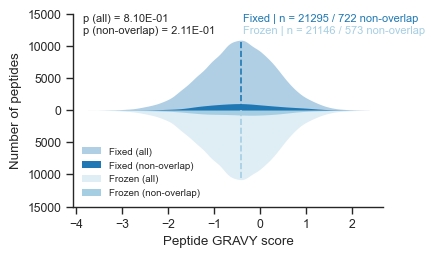

In [101]:
from scipy.stats import gaussian_kde

palette_ab = sns.color_palette("Paired")[0:2]
colors = [palette_ab[1], palette_ab[0]]
groups = ["fixed", "frozen"]
labels = ["Fixed", "Frozen"]

fig, ax = plt.subplots(figsize=(4, 2.5))

x_min = gravy_df_unique["gravy"].min()
x_max = gravy_df_unique["gravy"].max()
x_grid = np.linspace(x_min, x_max, 500)

lvl_max = 0
for i, group in enumerate(groups):
    vals_all = gravy_df_unique.loc[gravy_df_unique["group"] == group, "gravy"].to_numpy()
    vals_non = gravy_df_nonoverlap.loc[gravy_df_nonoverlap["group"] == group, "gravy"].to_numpy()
    sign = (-1) ** i

    # scale by n
    kde_all = gaussian_kde(vals_all)(x_grid) * len(vals_all)
    ax.fill_between(
        x_grid, kde_all * sign,
        color=colors[i], alpha=0.35, linewidth=0,
        label=f"{labels[i]} (all)",
    )

    # scale by n
    if len(vals_non) > 1 and np.std(vals_non) > 0:
        kde_non = gaussian_kde(vals_non)(x_grid) * len(vals_non) * 3
        ax.fill_between(
            x_grid, kde_non * sign,
            color=colors[i], alpha=1.0, linewidth=0, zorder=2,
            label=f"{labels[i]} (non-overlap)",
        )
        lvl_max = max(lvl_max, np.max(kde_non))
        
    mode_x = x_grid[np.argmax(kde_all)]
    ax.vlines(mode_x, 0, np.max(kde_all) * sign, color=colors[i], linestyle="--", linewidth=1.2)
    lvl_max = max(lvl_max, np.max(kde_all))

ax.text(
    0.15, 0.85,
    f"p (all) = {'%.2E' % Decimal(p_value)}",
    fontsize=8,
    transform=fig.transFigure,
)
ax.text(
    0.15, 0.8,
    f"p (non-overlap) = {'%.2E' % Decimal(p_value_non)}",
    fontsize=8,
    transform=fig.transFigure,
)
ax.text(
    0.55, 0.85,
    f"Fixed | n = {len(fixed_gravy)} / {len(fixed_gravy_non)} non-overlap",
    fontsize=8,
    transform=fig.transFigure,
    color=colors[0],
)
ax.text(
    0.55, 0.8,
    f"Frozen | n = {len(frozen_gravy)} / {len(frozen_gravy_non)} non-overlap",
    fontsize=8,
    transform=fig.transFigure,
    color=colors[1],
)
ax.set_ylim(-lvl_max * 1.05, lvl_max * 1.05)
yticks = ax.get_yticks()
ax.set_yticks(yticks)
ax.set_yticklabels([int(abs(y)) for y in yticks])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlabel("Peptide GRAVY score")
ax.set_ylabel("Number of peptides")
ax.legend(frameon=False, fontsize=7)

plt.savefig('MANUSCRIPT_revision/REVISION_FigS1-GRAVY_FF.png', dpi=450, bbox_inches='tight')


## marker - sc

In [27]:
pdata_fig1_supplementary = pAnnData.import_data(source_type='diann', report_file = 'data/2512_Ab-HCR/report.parquet')

🧭 [USER] Importing data of type [diann]
      Auto-detecting '_' as delimiter from first filename.
     ⚠️ [WARN] 2 different filename formats detected. Proceeding with fallback `.obs` structure... (File Number, Parsing Type)
--------------------------
Starting import [DIA-NN]

Source file: data/2512_Ab-HCR/report.parquet
Number of files: 81
Proteins: 8565
Peptides: 67553

     ℹ️ [INFO] Using sample-specific q-values for 'prot' significance annotation.
     ℹ️ [INFO] Using sample-specific q-values for 'pep' significance annotation.

ℹ️ RS matrix: (8565, 67553) (proteins × peptides), sparsity: 99.99%
   - Proteins with ≥2 *unique* linked peptides: 4378/8565
   - Peptides linked to ≥2 proteins: 9515/67553
   - Mean peptides per protein: 9.52
   - Mean proteins per peptide: 1.21
     ✅ [OK] pAnnData object is valid.
     ✅ [OK] Import complete. Use `print(pdata)` to view the object.
--------------------------


g:\Users\marion\miniconda3\envs\scpviz_dev\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
g:\Users\marion\miniconda3\envs\scpviz_dev\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [28]:
pdata_fig1_supplementary.summary = scutils.parse_filename_index(pdata_fig1_supplementary.summary, obs_columns=['date','acquisition','size','buffer','well_position'], condition='parsingType == "5-tokens"')
pdata_fig1_supplementary.summary = scutils.parse_filename_index(pdata_fig1_supplementary.summary, obs_columns=['date','acquisition','sample_id','size','confirmation','thickness','type','organism','region','well_position'], condition='parsingType == "10-tokens"')

mapping = {"800": "sc",}
pdata_fig1_supplementary.summary["size"] = pdata_fig1_supplementary.summary["size"].replace(mapping)
pdata_fig1_supplementary.update_summary()

pdata_fig1_supplementary_sc = pdata_fig1_supplementary.filter_sample(condition="size=='sc'")

# for dataset with single cell stained vs non-stained
# ab stained is april, pbs stained is november
summary = pdata_fig1_supplementary_sc.summary
summary.loc[summary["date"].astype(str).str.startswith("202404"), "type"] = "IF"
summary.loc[summary["date"].astype(str).str.startswith("202411"), "type"] = "Control"

pdata_fig1_supplementary_sc.summary = summary
pdata_fig1_supplementary_sc.update_summary()

pd.DataFrame(pdata_fig1_supplementary_sc.summary)

🔄 [UPDATE] Updating summary [sync_back]: pushed edits from `.summary` to `.obs`.
      Columns updated: buffer, well_position, date, size, acquisition.
🔄 [UPDATE] Updating summary [sync_back]: pushed edits from `.summary` to `.obs`.
      Columns updated: thickness, type, region, well_position, confirmation, date, size, organism, sample_id, acquisition.
🔄 [UPDATE] Updating summary [sync_back]: pushed edits from `.summary` to `.obs` (marked stale).
      Columns updated: size.
🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: size=='sc'
     ℹ️ Auto-cleanup: Removed 3866 empty proteins (all-NaN or all-zero). Proteins: O35226-4, Q80X85, E9Q4N7, Q8BIJ7, Q91ZP6, Q61941, P52795, Q921M4, Q921M4-2, Q8R3H9, ...
    → Samples kept: 68, Samples dropped: 13
    → Proteins kept: 4699

🔄 [UPDATE] Updating summary [sync_back]: pushed edits from `.summary` to `.obs`.
      Columns updated: type.


,File,parsingType,protein_quant,protein_count,protein_abundance_sum,date,acquisition,size,buffer,well_position,sample_id,confirmation,thickness,type,organism,region,peptide_quant,peptide_count,peptide_abundance_sum,unique_pep2_protein_count
20240418_Aur60minDIA_sc_T235_03,7,5-tokens,0.511173,2402,2.189993e+08,20240418,Aur60minDIA,sc,T235,03,<NA>,<NA>,<NA>,IF,<NA>,<NA>,0.160478,9460,7.481524e+08,1793
20250429_Aur60minDIA_H20_800_Y2_35um_GADHCR_Mus_Cortex_E12,11,10-tokens,0.545435,2563,4.029856e+08,20250429,Aur60minDIA,sc,<NA>,E12,H20,Y2,35um,GADHCR,Mus,Cortex,0.159646,9411,1.186234e+09,1897
20250429_Aur60minDIA_H22_800_Y3_35um_GADHCR_Mus_Cortex_E14,12,10-tokens,0.540966,2542,1.741961e+09,20250429,Aur60minDIA,sc,<NA>,E14,H22,Y3,35um,GADHCR,Mus,Cortex,0.146890,8659,4.892920e+09,1853
20241105_Aur60minDIA_sc_TEAB35_H10,13,5-tokens,0.499681,2348,2.521632e+08,20241105,Aur60minDIA,sc,TEAB35,H10,<NA>,<NA>,<NA>,Control,<NA>,<NA>,0.151572,8935,9.633217e+08,1729
20240418_Aur60minDIA_sc_H2O35_02,14,5-tokens,0.478187,2247,5.305662e+08,20240418,Aur60minDIA,sc,H2O35,02,<NA>,<NA>,<NA>,IF,<NA>,<NA>,0.147127,8673,1.468325e+09,1660
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20240425_Aur60minDIA_sc_TEAB35_04,77,5-tokens,0.031709,149,7.929352e+08,20240425,Aur60minDIA,sc,TEAB35,04,<NA>,<NA>,<NA>,IF,<NA>,<NA>,0.005293,312,2.923049e+09,117
20241105_Aur60minDIA_sc_TEAB35_I13,78,5-tokens,0.026814,126,1.817225e+09,20241105,Aur60minDIA,sc,TEAB35,I13,<NA>,<NA>,<NA>,Control,<NA>,<NA>,0.005530,326,4.610795e+09,101
20240418_Aur60minDIA_sc_H2O35_03,79,5-tokens,0.011279,53,3.540536e+08,20240418,Aur60minDIA,sc,H2O35,03,<NA>,<NA>,<NA>,IF,<NA>,<NA>,0.001866,110,1.096133e+09,43
20240418_Aur60minDIA_sc_H2O35_04,80,5-tokens,0.014684,69,3.835716e+08,20240418,Aur60minDIA,sc,H2O35,04,<NA>,<NA>,<NA>,IF,<NA>,<NA>,0.002816,166,1.071477e+09,47


#### IF (ab vs pbs)

In [29]:
pdata_ab_sc = pdata_fig1_supplementary_sc.filter_sample(condition = 'type in ("IF", "Control")')
pdata_ab_sc = pdata_ab_sc.filter_sample(min_prot = 1000)
pdata_ab_sc = pdata_ab_sc.filter_prot_significant()

pdata_ab_sc.summary.type.value_counts()

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: type in ("IF", "Control")
     ℹ️ Auto-cleanup: Removed 774 empty proteins (all-NaN or all-zero). Proteins: P62960, Q71RI9, Q71RI9-2, Q63829, P16675, Q78WZ7, Q5XKN4, Q9CZL5, Q8BG17, O55101, ...
    → Samples kept: 48, Samples dropped: 20
    → Proteins kept: 3925

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: protein_count >= 1000
     ℹ️ Auto-cleanup: Removed 76 empty proteins (all-NaN or all-zero). Proteins: Q91X52, Q8VCC1, Q9JIK5, Q9Z1W8, Q8BJS4, Q8BJS4-2, Q8BJS4-3, Q8BX17, Q5HZK2, Q9Z0U1, ...
    → Samples kept: 19, Samples dropped: 29
    → Proteins kept: 3849

🧭 [USER] Filtering proteins [Significance|File-mode]:
     ℹ️ [INFO] No group provided. Defaulting to sample-level significance filtering.
    Returning a copy of protein data based on significance thresholds:
     🔸 Files requested: All
     🔸 

type
IF         10
Control     9
Name: count, dtype: int64

In [30]:
ab_upset = scutils.get_upset_contents(pdata_ab_sc, classes = ['type'])

pdata_ab_only = pdata_ab_sc.filter_sample(query_mode=True, values = 'type == "IF"', return_copy=True)
pdata_pbs_only = pdata_ab_sc.filter_sample(query_mode=True, values ='type == "Control"', return_copy=True)

ab_only = scutils.get_upset_query(ab_upset, present='IF', absent='Control', fetch_uniprot=False, pdata=pdata_ab_sc)
pbs_only = scutils.get_upset_query(ab_upset, present='Control', absent='IF', fetch_uniprot=False, pdata=pdata_ab_sc)

ab_all = scutils.get_upset_query(ab_upset, present='IF', absent=[], fetch_uniprot=False, pdata=pdata_ab_sc)
pbs_all = scutils.get_upset_query(ab_upset, present='Control', absent=[], fetch_uniprot=False, pdata=pdata_ab_sc)

Classes: type, Values: IF
Filter query: ((adata.obs['type'] == 'IF'))
Classes: type, Values: Control
Filter query: ((adata.obs['type'] == 'Control'))
⚠️ [WARN] Advanced query mode enabled — interpreting string as a pandas-style expression.


g:\Users\marion\miniconda3\envs\scpviz_dev\Lib\site-packages\upsetplot\data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)


🧭 [USER] Filtering samples [query]:
    Returning a copy of sample data based on query string:
   🔸 Query: type == "IF"
     ℹ️ Auto-cleanup: Removed 135 empty proteins (all-NaN or all-zero). Proteins: Q9Z0V2, Q8R5F8, E9PY61, Q9EPW0, O08688, Q8K341, Q8K341-3, Q8K341-4, Q9JHK4, Q8CH09, ...
    → Samples kept: 10, Samples dropped: 9
    → Proteins kept: 2735

⚠️ [WARN] Advanced query mode enabled — interpreting string as a pandas-style expression.
🧭 [USER] Filtering samples [query]:
    Returning a copy of sample data based on query string:
   🔸 Query: type == "Control"
     ℹ️ Auto-cleanup: Removed 286 empty proteins (all-NaN or all-zero). Proteins: Q9QUR8, P28667, Q9D061, P28867, P27546-4, Q8CC86, Q99PL6, O54965, O54965-2, Q99NB9, ...
    → Samples kept: 9, Samples dropped: 10
    → Proteins kept: 2584



C:\Users\marion\AppData\Local\Temp\ipykernel_32440\3076452842.py:6: UserWarning:      ⚠️ [WARN] 4/287 feature(s) have missing gene names in .protein.var['Genes'].
  ab_only = scutils.get_upset_query(ab_upset, present='IF', absent='Control', fetch_uniprot=False, pdata=pdata_ab_sc)
C:\Users\marion\AppData\Local\Temp\ipykernel_32440\3076452842.py:9: UserWarning:      ⚠️ [WARN] 14/2735 feature(s) have missing gene names in .protein.var['Genes'].
  ab_all = scutils.get_upset_query(ab_upset, present='IF', absent=[], fetch_uniprot=False, pdata=pdata_ab_sc)
C:\Users\marion\AppData\Local\Temp\ipykernel_32440\3076452842.py:10: UserWarning:      ⚠️ [WARN] 10/2583 feature(s) have missing gene names in .protein.var['Genes'].
  pbs_all = scutils.get_upset_query(ab_upset, present='Control', absent=[], fetch_uniprot=False, pdata=pdata_ab_sc)


In [102]:
ab_acc_list = (
    ab_all["accession"].dropna().astype(str).str.strip()
    .loc[lambda s: (s != "") & (s != ",")].tolist()
)

pbs_acc_list = (
    pbs_all["accession"].dropna().astype(str).str.strip()
    .loc[lambda s: (s != "") & (s != ",")].tolist()
)

ab_gravy_df = pdata_ab_sc.get_peptide_properties(
    properties=["gravy"],
    accessions=ab_acc_list,
    return_copy=True,  # don't write to .pep.var unless you want that
)
ab_gravy_df["group"] = "ab"

pbs_gravy_df = pdata_ab_sc.get_peptide_properties(
    properties=["gravy"],
    accessions=pbs_acc_list,
    return_copy=True,
)
pbs_gravy_df["group"] = "pbs"

peptide_gravy_df = pd.concat(
    [ab_gravy_df, pbs_gravy_df],
    ignore_index=True,
)

gravy_df = peptide_gravy_df.dropna(subset=["gravy"]).copy()
gravy_df["gravy"] = gravy_df["gravy"].astype(float)
# one row per unique peptide sequence within each group
gravy_df_unique = gravy_df.drop_duplicates(subset=["group", "peptide_sequence"]).copy()

ab_gravy = gravy_df_unique.loc[gravy_df_unique["group"] == "ab", "gravy"]
pbs_gravy = gravy_df_unique.loc[gravy_df_unique["group"] == "pbs", "gravy"]

ab_seqs = set(gravy_df_unique.loc[gravy_df_unique["group"] == "ab", "peptide_sequence"])
pbs_seqs = set(gravy_df_unique.loc[gravy_df_unique["group"] == "pbs", "peptide_sequence"])

shared_seqs = ab_seqs & pbs_seqs
gravy_df_unique["overlap"] = gravy_df_unique["peptide_sequence"].isin(shared_seqs)
gravy_df_nonoverlap = gravy_df_unique.loc[~gravy_df_unique["overlap"]].copy()

ab_gravy = gravy_df_unique.loc[gravy_df_unique["group"] == "ab", "gravy"]
pbs_gravy = gravy_df_unique.loc[gravy_df_unique["group"] == "pbs", "gravy"]
ab_gravy_non = gravy_df_nonoverlap.loc[gravy_df_nonoverlap["group"] == "ab", "gravy"]
pbs_gravy_non = gravy_df_nonoverlap.loc[gravy_df_nonoverlap["group"] == "pbs", "gravy"]

from scipy.stats import ranksums

statistic, p_value = ranksums(ab_gravy, pbs_gravy)
_, p_value_non = ranksums(ab_gravy_non, pbs_gravy_non)
print(f"Ab n = {len(ab_gravy)} (non-overlap n = {len(ab_gravy_non)})")
print(f"PBS n = {len(pbs_gravy)} (non-overlap n = {len(pbs_gravy_non)})")
print(f"Shared peptide sequences = {len(shared_seqs)}")
print(f"p-value (all unique) = {p_value:.2e}")
print(f"p-value (non-overlap) = {p_value_non:.2e}")

Ab n = 37174 (non-overlap n = 1472)
PBS n = 36501 (non-overlap n = 799)
Shared peptide sequences = 35702
p-value (all unique) = 8.02e-01
p-value (non-overlap) = 7.61e-01


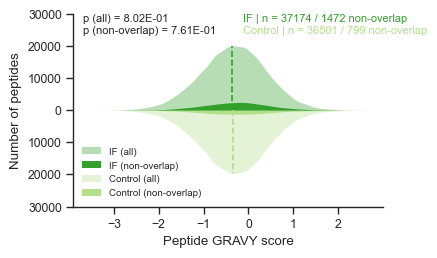

In [103]:
from scipy.stats import gaussian_kde

palette_ab = sns.color_palette("Paired")[2:4]
colors = [palette_ab[1], palette_ab[0]]
groups = ["ab", "pbs"]
labels = ["IF", "Control"]

fig, ax = plt.subplots(figsize=(4, 2.5))

x_min = gravy_df_unique["gravy"].min()
x_max = gravy_df_unique["gravy"].max()
x_grid = np.linspace(x_min, x_max, 500)

lvl_max = 0

for i, group in enumerate(groups):
    vals_all = gravy_df_unique.loc[gravy_df_unique["group"] == group, "gravy"].to_numpy()
    vals_non = gravy_df_nonoverlap.loc[gravy_df_nonoverlap["group"] == group, "gravy"].to_numpy()
    sign = (-1) ** i

    # scale by n
    kde_all = gaussian_kde(vals_all)(x_grid) * len(vals_all)
    ax.fill_between(
        x_grid, kde_all * sign,
        color=colors[i], alpha=0.35, linewidth=0,
        label=f"{labels[i]} (all)",
    )

    # scale by n
    if len(vals_non) > 1 and np.std(vals_non) > 0:
        kde_non = gaussian_kde(vals_non)(x_grid) * len(vals_non) * 3
        ax.fill_between(
            x_grid, kde_non * sign,
            color=colors[i], alpha=1.0, linewidth=0, zorder=2,
            label=f"{labels[i]} (non-overlap)",
        )
        lvl_max = max(lvl_max, np.max(kde_non))

    mode_x = x_grid[np.argmax(kde_all)]
    ax.vlines(mode_x, 0, np.max(kde_all) * sign, color=colors[i], linestyle="--", linewidth=1.2)
    lvl_max = max(lvl_max, np.max(kde_all))

ax.text(
    0.15, 0.85,
    f"p (all) = {'%.2E' % Decimal(p_value)}",
    fontsize=8,
    transform=fig.transFigure,
)
ax.text(
    0.15, 0.8,
    f"p (non-overlap) = {'%.2E' % Decimal(p_value_non)}",
    fontsize=8,
    transform=fig.transFigure,
)
ax.text(
    0.55, 0.85,
    f"IF | n = {len(ab_gravy)} / {len(ab_gravy_non)} non-overlap",
    fontsize=8,
    transform=fig.transFigure,
    color=colors[0],
)
ax.text(
    0.55, 0.8,
    f"Control | n = {len(pbs_gravy)} / {len(pbs_gravy_non)} non-overlap",
    fontsize=8,
    transform=fig.transFigure,
    color=colors[1],
)
ax.set_ylim(-lvl_max * 1.05, lvl_max * 1.05)
yticks = ax.get_yticks()
ax.set_yticks(yticks)
ax.set_yticklabels([int(abs(y)) for y in yticks])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlabel("Peptide GRAVY score")
ax.set_ylabel("Number of peptides")
ax.legend(frameon=False, fontsize=7)
# plt.show()
plt.savefig('MANUSCRIPT_revision/REVISION_FigS1-GRAVY_sc-IF.png', dpi=450, bbox_inches='tight')


In [32]:
pdata_ab_sc_processed = pdata_ab_sc.copy()
pdata_ab_sc_processed = pdata_ab_sc_processed.filter_prot_found(min_ratio=0.4, group = ['type'], match_any=True)
pdata_ab_sc_processed = pdata_ab_sc_processed.filter_prot(valid_genes=True, unique_profiles=True)

pdata_ab_sc_norm = pdata_ab_sc_processed.copy()
# pdata_ab_sc_norm.impute(method='min', min_scale=0.2)
# pdata_ab_sc_norm.normalize(method='median')

# pdata_ab_sc_norm2 = pdata_ab_sc_processed.copy()
# pdata_ab_sc_norm.normalize(method='directlfq')

🧭 [USER] Filtering proteins [Found|Group-mode|ANY]:
     ℹ️ [INFO] Found matching groups(s): ['IF', 'Control']. Automatically annotating detection by group values.
    Returning a copy of protein data based on detection thresholds:
     🔸 Groups requested: ['IF', 'Control']
     🔸 Minimum ratio: 0.4
     🔸 Logic: any (protein must be detected in ≥1 group(s))
    → Proteins kept: 1967, Proteins dropped: 903
     ✅ [OK] RS matrix filtered: 1967 proteins, 41992 peptides retained.

🧭 [USER] Filtering proteins [valid genes, unique profiles]:
    Returning a copy of protein data with the following filters applied:
     🔸 valid_genes — removed 10 proteins with invalid gene names
     🔸 valid_genes — resolved 180 duplicate gene names by appending numeric suffixes
     🔸 unique_profiles — removed 242 duplicate and 0 empty abundance profiles (242 total)
    → Proteins kept: 1715
    → Peptides kept (linked): 41983
     ✅ [OK] RS matrix filtered: 1715 proteins, 41983 peptides retained.


     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=2.48e+04). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: IF vs Control
   🔸 Group sizes: 10 vs 9 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 Adj p-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 37 proteins were not comparable (zero or NaN mean in one group).


g:\Users\marion\miniconda3\envs\scpviz_dev\Lib\site-packages\scpviz\pAnnData\analysis.py:356: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = ttest_ind(x1, x2, equal_var=equal_var, nan_policy='omit')


     ✅ DE complete. Results stored in:
       • .stats["IF vs Control"]
       • Columns: log2fc, p_value, adj_p_value, significance, etc.
       • Upregulated: 2 | Downregulated: 0 | Not significant: 1676 | Not comparable: 37


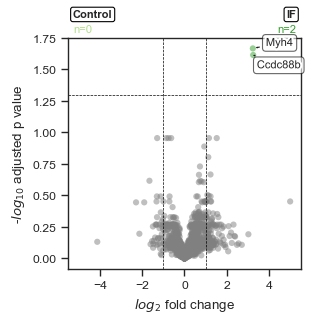

In [34]:
classes='type'
values=['IF','Control']

colors = sns.color_palette("Paired")[2:4]
color_dict = dict(zip(['downregulated', 'upregulated'], colors))

fig, ax = plt.subplots(1,1, figsize = (3,3))
scplt.plot_volcano(ax, pdata_ab_sc_norm, classes=classes, values=values, log2fc=1, pval=0.05, color=color_dict, correct_fdr=True,
                   group_annot_kwargs={"pos": {"group1_xy": (0.98, 1.08), "group2_xy": (0.02, 1.08)}},)
plt.savefig("MANUSCRIPT/MANUSCRIPT_FigS1-sc_IF_volcano.svg", bbox_inches="tight")
df_ab_norm = pdata_ab_sc_norm.stats["IF vs Control"]
df_ab_norm.to_csv('MANUSCRIPT_revision/REVISION_FigS1_DE-Ab-adjP.csv')

#### HCR (hcr vs pbs)

In [35]:
# obs_columns
pdata_hcr_sc = pdata_fig1_supplementary_sc.filter_sample(condition = 'type in ("GADHCR", "Control")')
pdata_hcr_sc = pdata_hcr_sc.filter_sample(min_prot = 1000)
pdata_hcr_sc = pdata_hcr_sc.filter_prot_significant()

mapping = {
    "GADHCR": "HCR",
}
pdata_hcr_sc.summary["type"] = pdata_hcr_sc.summary["type"].replace(mapping)
pdata_hcr_sc.update_summary()

pdata_hcr_sc.summary.type.value_counts()

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: type in ("GADHCR", "Control")
     ℹ️ Auto-cleanup: Removed 640 empty proteins (all-NaN or all-zero). Proteins: Q6PD26, P28667, P62960, Q8C196, P46662, P46662-2, Q0GA42, Q9JI39, Q8CC86, Q3UQ44, ...
    → Samples kept: 32, Samples dropped: 36
    → Proteins kept: 4059

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: protein_count >= 1000
     ℹ️ Auto-cleanup: Removed 13 empty proteins (all-NaN or all-zero). Proteins: Q8BJS4, Q8BJS4-2, Q8BJS4-3, Q5HZK2, Q61749, Q61749-2, E9Q3D4, A2BFL2, Q80X72, Q8CCX5, ...
    → Samples kept: 16, Samples dropped: 16
    → Proteins kept: 4046

🧭 [USER] Filtering proteins [Significance|File-mode]:
     ℹ️ [INFO] No group provided. Defaulting to sample-level significance filtering.
    Returning a copy of protein data based on significance thresholds:
     🔸 Files requested: All
 

type
Control    9
HCR        7
Name: count, dtype: int64

In [105]:
ab_upset = scutils.get_upset_contents(pdata_hcr_sc, classes = ['type'])

pdata_HCR_only = pdata_hcr_sc.filter_sample(query_mode=True, values='type == "HCR"', return_copy=True)
pdata_control_only = pdata_hcr_sc.filter_sample(query_mode=True, values='type == "Control"', return_copy=True)


HCR_only = scutils.get_upset_query(ab_upset, present='HCR', absent='Control', fetch_uniprot=False, pdata=pdata_hcr_sc)
Control_only = scutils.get_upset_query(ab_upset, present='Control', absent='HCR', fetch_uniprot=False, pdata=pdata_hcr_sc)

hcr_all = scutils.get_upset_query(ab_upset, present='HCR', absent=[], fetch_uniprot=False, pdata=pdata_hcr_sc)
Control_all = scutils.get_upset_query(ab_upset, present='Control', absent=[], fetch_uniprot=False, pdata=pdata_hcr_sc)

# export ab_only and pbs_only to csv
# ab_only.to_csv('sc_HCR+_only.csv')
# pbs_only.to_csv('sc_HCR-_only.csv')

Classes: type, Values: HCR
Filter query: ((adata.obs['type'] == 'HCR'))
Classes: type, Values: Control
Filter query: ((adata.obs['type'] == 'Control'))
⚠️ [WARN] Advanced query mode enabled — interpreting string as a pandas-style expression.


c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\upsetplot\data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)


🧭 [USER] Filtering samples [query]:
    Returning a copy of sample data based on query string:
   🔸 Query: type == "HCR"
     ℹ️ Auto-cleanup: Removed 112 empty proteins (all-NaN or all-zero). Proteins: Q61292, Q8CCB4, Q810U5, Q810U5-3, O08688, Q8K341, Q8K341-3, Q8K341-4, O08638, P02468, ...
    → Samples kept: 7, Samples dropped: 9
    → Proteins kept: 3071

⚠️ [WARN] Advanced query mode enabled — interpreting string as a pandas-style expression.
🧭 [USER] Filtering samples [query]:
    Returning a copy of sample data based on query string:
   🔸 Query: type == "Control"
     ℹ️ Auto-cleanup: Removed 482 empty proteins (all-NaN or all-zero). Proteins: Q9QUR8, P28867, P27546-4, Q63829, P16675, Q99PL6, Q61595-5, Q61595-6, O54965, O54965-2, ...
    → Samples kept: 9, Samples dropped: 7
    → Proteins kept: 2701



C:\Users\srpang\AppData\Local\Temp\ipykernel_41188\1938266488.py:7: UserWarning:      ⚠️ [WARN] 4/484 feature(s) have missing gene names in .protein.var['Genes'].
  HCR_only = scutils.get_upset_query(ab_upset, present='HCR', absent='Control', fetch_uniprot=False, pdata=pdata_hcr_sc)
C:\Users\srpang\AppData\Local\Temp\ipykernel_41188\1938266488.py:10: UserWarning:      ⚠️ [WARN] 14/3066 feature(s) have missing gene names in .protein.var['Genes'].
  hcr_all = scutils.get_upset_query(ab_upset, present='HCR', absent=[], fetch_uniprot=False, pdata=pdata_hcr_sc)
C:\Users\srpang\AppData\Local\Temp\ipykernel_41188\1938266488.py:11: UserWarning:      ⚠️ [WARN] 10/2698 feature(s) have missing gene names in .protein.var['Genes'].
  Control_all = scutils.get_upset_query(ab_upset, present='Control', absent=[], fetch_uniprot=False, pdata=pdata_hcr_sc)


In [106]:
hcr_acc_list = (
    hcr_all["accession"].dropna().astype(str).str.strip()
    .loc[lambda s: (s != "") & (s != ",")].tolist()
)

control_acc_list = (
    Control_all["accession"].dropna().astype(str).str.strip()
    .loc[lambda s: (s != "") & (s != ",")].tolist()
)

hcr_gravy_df = pdata_hcr_sc.get_peptide_properties(
    properties=["gravy"],
    accessions=hcr_acc_list,
    return_copy=True,  # don't write to .pep.var unless you want that
)
hcr_gravy_df["group"] = "hcr"

control_gravy_df = pdata_hcr_sc.get_peptide_properties(
    properties=["gravy"],
    accessions=control_acc_list,
    return_copy=True,
)
control_gravy_df["group"] = "control"

peptide_gravy_df = pd.concat(
    [hcr_gravy_df, control_gravy_df],
    ignore_index=True,
)

gravy_df = peptide_gravy_df.dropna(subset=["gravy"]).copy()
gravy_df["gravy"] = gravy_df["gravy"].astype(float)
# one row per unique peptide sequence within each group
gravy_df_unique = gravy_df.drop_duplicates(subset=["group", "peptide_sequence"]).copy()

hcr_gravy = gravy_df_unique.loc[gravy_df_unique["group"] == "hcr", "gravy"]
control_gravy = gravy_df_unique.loc[gravy_df_unique["group"] == "control", "gravy"]

hcr_seqs = set(gravy_df_unique.loc[gravy_df_unique["group"] == "hcr", "peptide_sequence"])
control_seqs = set(gravy_df_unique.loc[gravy_df_unique["group"] == "control", "peptide_sequence"])

shared_seqs = hcr_seqs & control_seqs
gravy_df_unique["overlap"] = gravy_df_unique["peptide_sequence"].isin(shared_seqs)
gravy_df_nonoverlap = gravy_df_unique.loc[~gravy_df_unique["overlap"]].copy()

hcr_gravy = gravy_df_unique.loc[gravy_df_unique["group"] == "hcr", "gravy"]
control_gravy = gravy_df_unique.loc[gravy_df_unique["group"] == "control", "gravy"]
hcr_gravy_non = gravy_df_nonoverlap.loc[gravy_df_nonoverlap["group"] == "hcr", "gravy"]
control_gravy_non = gravy_df_nonoverlap.loc[gravy_df_nonoverlap["group"] == "control", "gravy"]

from scipy.stats import ranksums

statistic, p_value = ranksums(hcr_gravy, control_gravy)
_, p_value_non = ranksums(hcr_gravy_non, control_gravy_non)
print(f"HCR n = {len(hcr_gravy)} (non-overlap n = {len(hcr_gravy_non)})")
print(f"Control n = {len(control_gravy)} (non-overlap n = {len(control_gravy_non)})")
print(f"Shared peptide sequences = {len(shared_seqs)}")
print(f"p-value (all unique) = {p_value:.2e}")
print(f"p-value (non-overlap) = {p_value_non:.2e}")

HCR n = 39396 (non-overlap n = 2529)
Control n = 37486 (non-overlap n = 619)
Shared peptide sequences = 36867
p-value (all unique) = 8.32e-01
p-value (non-overlap) = 5.16e-02


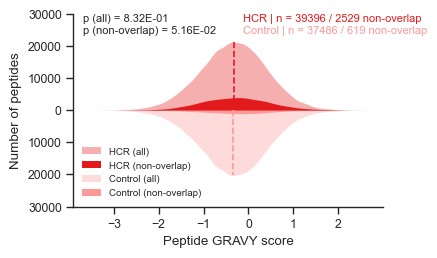

In [109]:
from scipy.stats import gaussian_kde

palette_ab = sns.color_palette("Paired")[4:6]
colors = [palette_ab[1], palette_ab[0]]
groups = ["hcr", "control"]
labels = ["HCR", "Control"]

fig, ax = plt.subplots(figsize=(4, 2.5))

x_min = gravy_df_unique["gravy"].min()
x_max = gravy_df_unique["gravy"].max()
x_grid = np.linspace(x_min, x_max, 500)

lvl_max = 0

for i, group in enumerate(groups):
    vals_all = gravy_df_unique.loc[gravy_df_unique["group"] == group, "gravy"].to_numpy()
    vals_non = gravy_df_nonoverlap.loc[gravy_df_nonoverlap["group"] == group, "gravy"].to_numpy()
    sign = (-1) ** i

    # scale by n
    kde_all = gaussian_kde(vals_all)(x_grid) * len(vals_all)
    ax.fill_between(
        x_grid, kde_all * sign,
        color=colors[i], alpha=0.35, linewidth=0,
        label=f"{labels[i]} (all)",
    )

    # scale by n
    if len(vals_non) > 1 and np.std(vals_non) > 0:
        kde_non = gaussian_kde(vals_non)(x_grid) * len(vals_non) * 3
        ax.fill_between(
            x_grid, kde_non * sign,
            color=colors[i], alpha=1.0, linewidth=0, zorder=2,
            label=f"{labels[i]} (non-overlap)",
        )
        lvl_max = max(lvl_max, np.max(kde_non))

    mode_x = x_grid[np.argmax(kde_all)]
    ax.vlines(mode_x, 0, np.max(kde_all) * sign, color=colors[i], linestyle="--", linewidth=1.2)
    lvl_max = max(lvl_max, np.max(kde_all))

ax.text(
    0.15, 0.85,
    f"p (all) = {'%.2E' % Decimal(p_value)}",
    fontsize=8,
    transform=fig.transFigure,
)
ax.text(
    0.15, 0.8,
    f"p (non-overlap) = {'%.2E' % Decimal(p_value_non)}",
    fontsize=8,
    transform=fig.transFigure,
)
ax.text(
    0.55, 0.85,
    f"HCR | n = {len(hcr_gravy)} / {len(hcr_gravy_non)} non-overlap",
    fontsize=8,
    transform=fig.transFigure,
    color=colors[0],
)
ax.text(
    0.55, 0.8,
    f"Control | n = {len(control_gravy)} / {len(control_gravy_non)} non-overlap",
    fontsize=8,
    transform=fig.transFigure,
    color=colors[1],
)

ax.set_ylim(-lvl_max * 1.05, lvl_max * 1.05)
yticks = ax.get_yticks()
ax.set_yticks(yticks)
ax.set_yticklabels([int(abs(y)) for y in yticks])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlabel("Peptide GRAVY score")
ax.set_ylabel("Number of peptides")
ax.legend(frameon=False, fontsize=7)

# plt.show()
plt.savefig('MANUSCRIPT_revision/REVISION_FigS1-GRAVY_sc-HCR.png', dpi=450, bbox_inches='tight')


In [36]:
pdata_hcr_sc_processed = pdata_hcr_sc.copy()
pdata_hcr_sc_processed = pdata_hcr_sc_processed.filter_prot_found(min_ratio=0.4, group = ['type'], match_any=True)
pdata_hcr_sc_processed = pdata_hcr_sc_processed.filter_prot(valid_genes=True, unique_profiles=True)

pdata_hcr_sc_norm = pdata_hcr_sc_processed.copy()
# pdata_ab_sc_norm.impute(method='min', min_scale=0.2)
# pdata_ab_sc_norm.normalize(method='median')

# pdata_ab_sc_norm2 = pdata_ab_sc_processed.copy()
# pdata_ab_sc_norm.normalize(method='directlfq')

🧭 [USER] Filtering proteins [Found|Group-mode|ANY]:
     ℹ️ [INFO] Found matching groups(s): ['HCR', 'Control']. Automatically annotating detection by group values.
    Returning a copy of protein data based on detection thresholds:
     🔸 Groups requested: ['HCR', 'Control']
     🔸 Minimum ratio: 0.4
     🔸 Logic: any (protein must be detected in ≥1 group(s))
    → Proteins kept: 2324, Proteins dropped: 859
     ✅ [OK] RS matrix filtered: 2324 proteins, 45523 peptides retained.

🧭 [USER] Filtering proteins [valid genes, unique profiles]:
    Returning a copy of protein data with the following filters applied:
     🔸 valid_genes — removed 9 proteins with invalid gene names
     🔸 valid_genes — resolved 234 duplicate gene names by appending numeric suffixes
     🔸 unique_profiles — removed 316 duplicate and 0 empty abundance profiles (316 total)
    → Proteins kept: 1999
    → Peptides kept (linked): 45511
     ✅ [OK] RS matrix filtered: 1999 proteins, 45511 peptides retained.


     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=1.98e+04). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: HCR vs Control
   🔸 Group sizes: 7 vs 9 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 Adj p-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 112 proteins were not comparable (zero or NaN mean in one group).


g:\Users\marion\miniconda3\envs\scpviz_dev\Lib\site-packages\scpviz\pAnnData\analysis.py:356: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = ttest_ind(x1, x2, equal_var=equal_var, nan_policy='omit')


     ✅ DE complete. Results stored in:
       • .stats["HCR vs Control"]
       • Columns: log2fc, p_value, adj_p_value, significance, etc.
       • Upregulated: 0 | Downregulated: 0 | Not significant: 1887 | Not comparable: 112


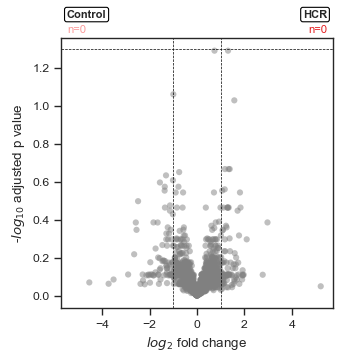

In [38]:
classes='type'
values=['HCR','Control']

colors = sns.color_palette("Paired")[4:6]
color_dict = dict(zip(['downregulated', 'upregulated'], colors))

fig, ax = plt.subplots(1,1, figsize = (3.5,3.5))
scplt.plot_volcano(ax, pdata_hcr_sc_norm, classes=classes, values=values, log2fc=1, pval=0.05, color=color_dict, correct_fdr=True)
# plt.savefig("MANUSCRIPT/MANUSCRIPT_FigS1-sc_HCR_volcano.svg", bbox_inches="tight")
df_hcr_norm = pdata_hcr_sc_norm.stats["HCR vs Control"]
df_hcr_norm.to_csv('MANUSCRIPT_revision/REVISION_FigS1_DE-HCR-adjP.csv')

# Fig 2 - region

## Cortex vs snpc

### pre-processing

In [3]:
pdata_fig2_region_filter = pdata_all_region_filtered.filter_prot_significant()
pdata_fig2_region_filter = pdata_fig2_region_filter.filter_sample(condition="Grouping != 'ast'")
pdata_fig2_region_filter = pdata_fig2_region_filter.filter_sample(min_prot=1000)

pdata_fig2_region_filter.summary["region"] = pdata_fig2_region_filter.summary["Grouping"].replace({
    "snpc": "SNpc",
    "ctx": "Cortex"
})
pdata_fig2_region_filter.update_summary()

pdata_fig2_region_processed = pdata_fig2_region_filter.copy()
pdata_fig2_region_processed = pdata_fig2_region_processed.filter_prot_found(min_ratio=0.4, group = ['Grouping'], match_any=True)
pdata_fig2_region_processed = pdata_fig2_region_processed.filter_prot(valid_genes=True, unique_profiles=True)

🧭 [USER] Filtering proteins [Significance|File-mode]:
     ℹ️ [INFO] No group provided. Defaulting to sample-level significance filtering.
    Returning a copy of protein data based on significance thresholds:
     🔸 Files requested: All
     🔸 FDR threshold: 0.01
     🔸 Logic: any (protein must be significant in ≥1 file(s))
    → Proteins kept: 4026, Proteins dropped: 88
     ✅ [OK] RS matrix filtered: 4026 proteins, 45593 peptides retained.

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: Grouping != 'ast'
     ℹ️ Auto-cleanup: Removed 21 empty proteins (all-NaN or all-zero). Proteins: Q6NZB0, Q80UK0, Q60714, P13864, Q8R502, Q8CI61, Q8VDS4, Q6DFY8, P50153, Q8R2T8, ...
    → Samples kept: 100, Samples dropped: 5
    → Proteins kept: 4005

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: protein_count >= 1000
     ℹ️ Auto-cleanup: No empty proteins found (a

In [4]:
pdata_fig2_region_norm = pdata_fig2_region_processed.copy()
pdata_fig2_region_norm.normalize(method='directlfq')

# pdata_fig2_region_norm_impute = pdata_fig2_region_processed.copy()
# pdata_fig2_region_norm_impute.impute(method='min', min_scale=0.2)
# pdata_fig2_region_norm_impute.normalize(method='median')

🧭 [USER] Running directlfq normalization on peptide-level data.
     ℹ️ Note: please be patient, directlfq can take a minute to run depending on data size. Output files will be produced.
     ℹ️ [INFO] No multi-protein peptide groups detected for directlfq input.


2026-09-17 12:12:33,338 - directlfq.lfq_manager - INFO - Starting directLFQ analysis.
2026-09-17 12:12:33,689 - directlfq.lfq_manager - INFO - Performing sample normalization.
2026-09-17 12:12:33,805 - directlfq.normalization - INFO - to few values for normalization without missing values. Including missing values
2026-09-17 12:12:36,057 - directlfq.lfq_manager - INFO - Estimating lfq intensities.
2026-09-17 12:12:36,062 - directlfq.protein_intensity_estimation - INFO - 2371 lfq-groups total
2026-09-17 12:12:36,834 - directlfq.protein_intensity_estimation - INFO - using 16 processes
2026-09-17 12:12:50,430 - directlfq.lfq_manager - INFO - Could not add additional columns to protein table, printing without additional columns.
2026-09-17 12:12:50,431 - directlfq.lfq_manager - INFO - Writing results files.
2026-09-17 12:12:52,095 - directlfq.lfq_manager - INFO - Analysis finished!


     ℹ️ Set protein data to layer X_norm_directlfq.
     ✅ directlfq normalization complete. Results are stored in layer 'X_norm_directlfq'.
          ⚠️ Downstream imputation should be performed with the flag `use_zeros_as_nan` set to True due to directlfq output format returning NaNs as 0s.


### plots

In [5]:
cns_color={
    "Cortex": "#D19DCB",
    "SNpc": "#85BE9E"
}

In [6]:
pdata_fig2_region_norm.summary

,File,parsingType,protein_quant,protein_count,protein_abundance_sum,File Name,Grouping,Sub grouping,Region,Batch,region,peptide_quant,peptide_count,peptide_abundance_sum,unique_pep2_protein_count
20240425_Aur60minDIA_sc_H2O35_02,10,5-tokens,0.549979,1304,9.605530e+08,ctx_6,ctx,none,Cortex,Apr-24,Cortex,0.142207,5721,2.370656e+09,1293
20240418_Aur60minDIA_sc_TEAB35_05,11,5-tokens,0.662590,1571,9.655015e+08,ctx_5,ctx,none,Cortex,Apr-24,Cortex,0.181407,7298,2.616650e+09,1558
20240418_Aur60minDIA_sc_T235_03,12,5-tokens,0.787010,1866,6.185267e+08,ctx_2,ctx,none,Cortex,Apr-24,Cortex,0.272359,10957,1.508482e+09,1847
20240824_Aur60minDIA_S18_TH+-Anxa1+_Y2_slide9-10_1b_Mus_SNpc_E5,13,10-tokens,0.735555,1744,3.556384e+09,snpc/anxa_B_2,snpc,anxaY,Anxa_B,Aug-24,SNpc,0.205692,8275,4.433745e+09,1717
20240601_Aur60minDIA_S1-8_Cortex_E17,17,5-tokens,0.883593,2095,1.316885e+09,ctx_15,ctx,none,Cortex,Jun-24,Cortex,0.296967,11947,5.044660e+09,2063
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20250429_Aur60minDIA_AA43_800_Y2_35um_GAD-_Mus_Cortex_G6,122,10-tokens,0.451286,1070,1.549744e+09,ctx/noGAD_6,ctx,GADN,GAD_no,Apr-25,Cortex,0.102585,4127,2.599687e+09,1045
20240824_Aur60minDIA_S11_TH+only_Y2_slide9-10_2b_Mus_SNpc_D6,125,10-tokens,0.502741,1192,2.650129e+09,snpc/non-anxa_B_2,snpc,anxaN,TH_B,Aug-24,SNpc,0.116431,4684,4.478059e+09,1173
20240824_Aur60minDIA_S4_TH+-Anxa1+_Y2_slide9-10_2b_Mus_SNpc_C7,129,10-tokens,0.578237,1371,5.998328e+09,snpc/anxa_B_8,snpc,anxaY,Anxa_B,Aug-24,SNpc,0.147775,5945,4.001038e+09,1346
20250429_Aur60minDIA_AA42_800_Y2_35um_GAD-_Mus_Cortex_G5,130,10-tokens,0.560523,1329,5.086528e+09,ctx/noGAD_5,ctx,GADN,GAD_no,Apr-25,Cortex,0.140194,5640,4.643567e+09,1302


     ⚠️ [WARN] `classes` is deprecated; use `color=` instead.
     ℹ️ [INFO] Computing PCA (force=True)...
     ℹ️ [INFO] Layer 'X' appears to contain non-log intensities (median=2.31e+04). PCA will proceed with z-scoring (standard practice). Optionally run pdata.log_transform() first for better low-abundance separation.
🧭 [USER] Performing PCA [protein] using layer: X, removing NaN features.
   🔸 BEFORE (samples × proteins): (100, 2371)
   🔸 AFTER  (samples × proteins): (100, 2371)
     ✅ PCA complete, fitted on X. Results stored in:
       • .prot.obsm['X_pca']
       • .prot.uns['pca'] (includes PCs, variance, variance ratio)
       • Variance explained by PC1/PC2: 20.75% , 5.49%


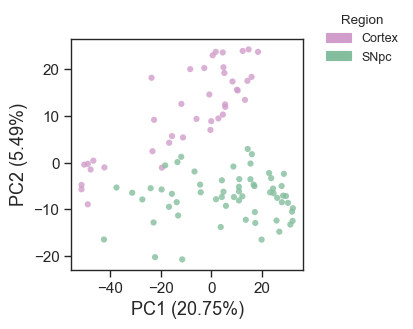

     ⚠️ [WARN] `classes` is deprecated; use `color=` instead.
     ℹ️ [INFO] Computing PCA (force=True)...
     ℹ️ [INFO] Layer 'X' appears to contain non-log intensities (median=2.31e+04). PCA will proceed with z-scoring (standard practice). Optionally run pdata.log_transform() first for better low-abundance separation.
🧭 [USER] Performing PCA [protein] using layer: X, removing NaN features.
   🔸 BEFORE (samples × proteins): (100, 2371)
   🔸 AFTER  (samples × proteins): (100, 2371)
     ✅ PCA complete, fitted on X. Results stored in:
       • .prot.obsm['X_pca']
       • .prot.uns['pca'] (includes PCs, variance, variance ratio)
       • Variance explained by PC1/PC2: 20.75% , 5.49%


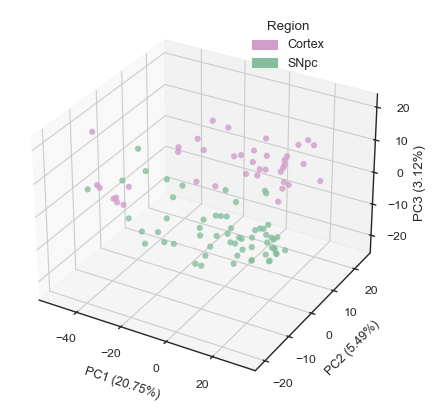

In [7]:
fig, ax = plt.subplots(1,1, figsize = (3,3))
ax, pca = scplt.plot_pca(ax, pdata_fig2_region_norm, classes='region', s=20, alpha=.8, return_fit=True, force=True, cmap=cns_color, add_ellipses=False)
scplt.shift_legend(ax)

# legend=ax.get_legend()
# for patch in legend.legend_handles:
#     patch.set_edgecolor('black')
# if legend is not None:
#     legend.remove()

ax.set_xlabel(ax.get_xlabel(), fontsize=13, labelpad=4)
ax.set_ylabel(ax.get_ylabel(), fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# plt.savefig("MANUSCRIPT/MANUSCRIPT_Fig2-CNS_PCA.svg", bbox_inches="tight")
plt.show()

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection='3d')
ax = scplt.plot_pca(ax, pdata_fig2_region_norm, classes=['region'], force=True, plot_pc = [1,2,3], cmap=cns_color)
zlab = ax.get_zlabel()
ax.set_zlabel("")
ax.text2D(1.05, 0.55, zlab,
          transform=ax.transAxes, rotation=90,
          ha='left', va='center', fontsize=9.5)


# plt.savefig("MANUSCRIPT/MANUSCRIPT_Fig2-CNS_PCA-3D.svg", bbox_inches="tight", pad_inches=0.1)
plt.show()

     ℹ️ [INFO] Computing PCA (force=True)...
     ℹ️ [INFO] Layer 'X' appears to contain non-log intensities (median=2.31e+04). PCA will proceed with z-scoring (standard practice). Optionally run pdata.log_transform() first for better low-abundance separation.
🧭 [USER] Performing PCA [protein] using layer: X, removing NaN features.
   🔸 BEFORE (samples × proteins): (100, 2371)
   🔸 AFTER  (samples × proteins): (100, 2371)
     ✅ PCA complete, fitted on X. Results stored in:
       • .prot.obsm['X_pca']
       • .prot.uns['pca'] (includes PCs, variance, variance ratio)
       • Variance explained by PC1/PC2: 20.75% , 5.49%


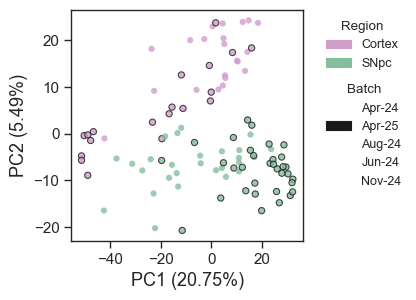

     ℹ️ [INFO] Computing PCA (force=True)...
     ℹ️ [INFO] Layer 'X' appears to contain non-log intensities (median=2.31e+04). PCA will proceed with z-scoring (standard practice). Optionally run pdata.log_transform() first for better low-abundance separation.
🧭 [USER] Performing PCA [protein] using layer: X, removing NaN features.
   🔸 BEFORE (samples × proteins): (100, 2371)
   🔸 AFTER  (samples × proteins): (100, 2371)
     ✅ PCA complete, fitted on X. Results stored in:
       • .prot.obsm['X_pca']
       • .prot.uns['pca'] (includes PCs, variance, variance ratio)
       • Variance explained by PC1/PC2: 20.75% , 5.49%


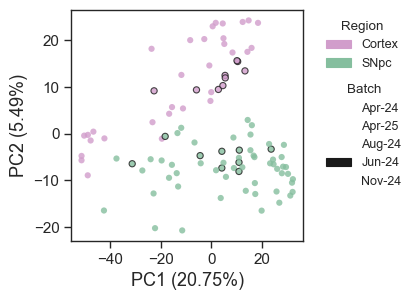

     ℹ️ [INFO] Computing PCA (force=True)...
     ℹ️ [INFO] Layer 'X' appears to contain non-log intensities (median=2.31e+04). PCA will proceed with z-scoring (standard practice). Optionally run pdata.log_transform() first for better low-abundance separation.
🧭 [USER] Performing PCA [protein] using layer: X, removing NaN features.
   🔸 BEFORE (samples × proteins): (100, 2371)
   🔸 AFTER  (samples × proteins): (100, 2371)
     ✅ PCA complete, fitted on X. Results stored in:
       • .prot.obsm['X_pca']
       • .prot.uns['pca'] (includes PCs, variance, variance ratio)
       • Variance explained by PC1/PC2: 20.75% , 5.49%


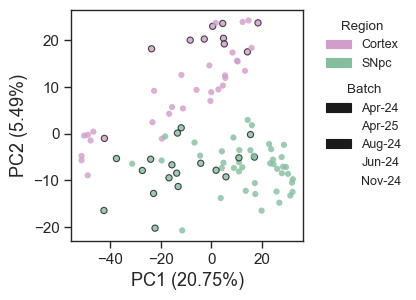

In [8]:
fig, ax = plt.subplots(1,1, figsize = (3,3))

edge_color={
    "Apr-25":"k",
    "Apr-24":"none",
    "Aug-24":"none",
    "Jun-24":"none",
    "Nov-24":"none"
}

ax, pca = scplt.plot_pca(ax, pdata_fig2_region_norm, edge_color='Batch', color='region', cmap=cns_color, edge_cmap=edge_color, s=20, alpha=.8, return_fit=True, force=True, add_ellipses=False)
# scplt.shift_legend(ax)

# legend=ax.get_legend()
# for patch in legend.legend_handles:
#     patch.set_edgecolor('black')
# if legend is not None:
#     legend.remove()

ax.set_xlabel(ax.get_xlabel(), fontsize=13, labelpad=4)
ax.set_ylabel(ax.get_ylabel(), fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

scplt.shift_legend(ax)
plt.show()

fig, ax = plt.subplots(1,1, figsize = (3,3))
edge_color={
    "Apr-25":"none",
    "Apr-24":"none",
    "Aug-24":"none",
    "Jun-24":"k",
    "Nov-24":"none"
}

ax, pca = scplt.plot_pca(ax, pdata_fig2_region_norm, edge_color='Batch', color='region', cmap=cns_color, edge_cmap=edge_color, s=20, alpha=.8, return_fit=True, force=True, add_ellipses=False)
# scplt.shift_legend(ax)

# legend=ax.get_legend()
# for patch in legend.legend_handles:
#     patch.set_edgecolor('black')
# if legend is not None:
#     legend.remove()

ax.set_xlabel(ax.get_xlabel(), fontsize=13, labelpad=4)
ax.set_ylabel(ax.get_ylabel(), fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

scplt.shift_legend(ax)
plt.show()

fig, ax = plt.subplots(1,1, figsize = (3,3))
edge_color={
    "Apr-25":"none",
    "Apr-24":"k",
    "Aug-24":"k",
    "Jun-24":"none",
    "Nov-24":"none"
}

ax, pca = scplt.plot_pca(ax, pdata_fig2_region_norm, edge_color='Batch', color='region', cmap=cns_color, edge_cmap=edge_color, s=20, alpha=.8, return_fit=True, force=True, add_ellipses=False)
# scplt.shift_legend(ax)

# legend=ax.get_legend()
# for patch in legend.legend_handles:
#     patch.set_edgecolor('black')
# if legend is not None:
#     legend.remove()

ax.set_xlabel(ax.get_xlabel(), fontsize=13, labelpad=4)
ax.set_ylabel(ax.get_ylabel(), fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

scplt.shift_legend(ax)
plt.show()

In [ ]:
batch_to_donor = {
    "Apr-25": "batch 1",
    "Jun-24": "batch 2",
    "Apr-24": "batch 3",
    "Aug-24": "batch 3",
    "Nov-24": "batch 4",
}

df = pdata_fig2_region_norm.summary

df["donor"] = df["Batch"].map(batch_to_donor)
assert df["donor"].notna().all(), f"Unmapped batches: {df.loc[df['donor'].isna(), 'Batch'].unique()}"


pdata_fig2_region_norm.summary = df

batch 1
🧭 [USER] Filtering samples [class match]:
    Returning a copy of sample data based on class match:
   🔸 Match samples where:
      - donor: batch 1
     ℹ️ Auto-cleanup: No empty proteins found (all-NaN or all-zero).
    → Samples kept: 52, Samples dropped: 48
    → Proteins kept: 2371

     ⚠️ [WARN] `classes` is deprecated; use `color=` instead.
     ℹ️ [INFO] Computing PCA (force=True)...
     ℹ️ [INFO] Layer 'X' appears to contain non-log intensities (median=2.36e+04). PCA will proceed with z-scoring (standard practice). Optionally run pdata.log_transform() first for better low-abundance separation.
🧭 [USER] Performing PCA [protein] using layer: X, removing NaN features.
   🔸 BEFORE (samples × proteins): (52, 2371)
   🔸 AFTER  (samples × proteins): (52, 2371)
     ✅ PCA complete, fitted on X. Results stored in:
       • .prot.obsm['X_pca']
       • .prot.uns['pca'] (includes PCs, variance, variance ratio)
       • Variance explained by PC1/PC2: 28.83% , 5.57%
batch 2


g:\Users\marion\miniconda3\envs\scpviz_dev\Lib\site-packages\scpviz\pAnnData\analysis.py:1738: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm['X_pca'] = pca_data[0]


🧭 [USER] Filtering samples [class match]:
    Returning a copy of sample data based on class match:
   🔸 Match samples where:
      - donor: batch 2
     ℹ️ Auto-cleanup: Removed 3 empty proteins (all-NaN or all-zero). Proteins: Q8BVY0, P01664, P01837
    → Samples kept: 18, Samples dropped: 82
    → Proteins kept: 2368

     ⚠️ [WARN] `classes` is deprecated; use `color=` instead.
     ℹ️ [INFO] Computing PCA (force=True)...
     ℹ️ [INFO] Layer 'X' appears to contain non-log intensities (median=2.58e+04). PCA will proceed with z-scoring (standard practice). Optionally run pdata.log_transform() first for better low-abundance separation.
🧭 [USER] Performing PCA [protein] using layer: X, removing NaN features.
   🔸 BEFORE (samples × proteins): (18, 2368)
   🔸 AFTER  (samples × proteins): (18, 2368)
     ✅ PCA complete, fitted on X. Results stored in:
       • .prot.obsm['X_pca']
       • .prot.uns['pca'] (includes PCs, variance, variance ratio)
       • Variance explained by PC1/PC2: 19

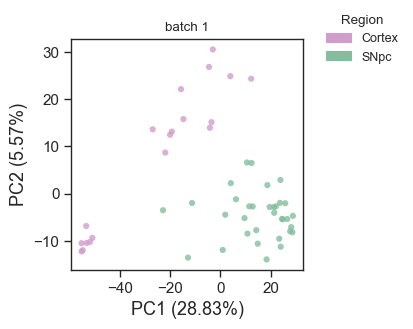

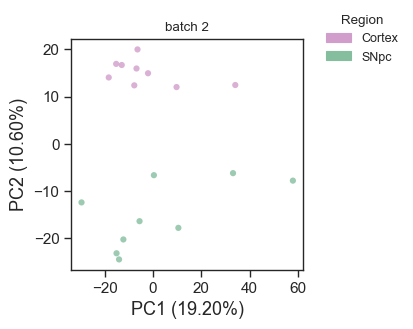

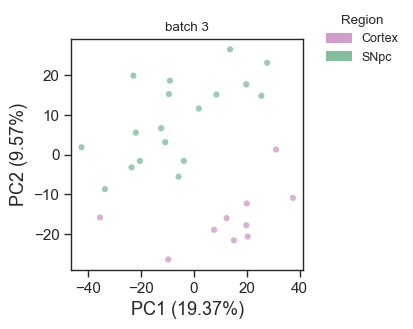

In [11]:
for batch in ['batch 1', 'batch 2', 'batch 3']:
    print(batch)
    pdata_batch = pdata_fig2_region_norm.filter_sample(values={'donor': batch})

    fig, ax = plt.subplots(1,1, figsize = (3,3))
    ax, pca = scplt.plot_pca(ax, pdata_batch, classes='region', s=20, alpha=.8, return_fit=True, force=True, cmap=cns_color, add_ellipses=False)
    scplt.shift_legend(ax)

    # legend=ax.get_legend()
    # for patch in legend.legend_handles:
    #     patch.set_edgecolor('black')
    # if legend is not None:
    #     legend.remove()

    ax.set_title(batch)
    ax.set_xlabel(ax.get_xlabel(), fontsize=13, labelpad=4)
    ax.set_ylabel(ax.get_ylabel(), fontsize=13, labelpad=4)
    ax.tick_params(axis='x', labelsize=11)
    ax.tick_params(axis='y', labelsize=11)

#### mixed DE

In [9]:
batch_to_donor = {
    "Apr-25": "batch 1",
    "Jun-24": "batch 2",
    "Apr-24": "batch 3",
    "Aug-24": "batch 3",
    "Nov-24": "batch 4",
}

df = pdata_fig2_region_norm.summary

df["donor"] = df["Batch"].map(batch_to_donor)
assert df["donor"].notna().all(), f"Unmapped batches: {df.loc[df['donor'].isna(), 'Batch'].unique()}"


pdata_fig2_region_norm.summary = df

[summary] ⚠️ Warning: .summary has been modified. Run `(pdata).update_summary()` to sync changes back to .obs.
🔄 [UPDATE] Updating summary [sync_back]: pushed edits from `.summary` to `.obs`.
      Columns updated: donor.


In [7]:
pdata_fig2_region_norm.summary.groupby("donor")["region"].value_counts()


donor    region
batch 1  SNpc      33
         Cortex    19
batch 2  Cortex     9
         SNpc       9
batch 3  SNpc      18
         Cortex    10
batch 4  Cortex     2
Name: count, dtype: int64

In [8]:
pdata_fig2_mixedeffect = pdata_fig2_region_norm.copy()
pdata_fig2_mixedeffect.log_transform(layer="X", base=2)

pdata_fig2_mixedeffect.show_layer_provenance()

🧭 [USER] Log-transforming [protein] layer: 'X' → 'X_log2'
     🔸 base: 2 log base (pseudocount 1.0)
     ✅ Log transform complete. Results stored in:
       • .prot.layers['X_log2']
       • .prot.X updated
       • .prot.uns['layer_provenance']['X_log2'] updated
     ℹ️ Set protein data to layer X_log2.
  Layer provenance  [protein]

  ● Current .X layer:

    'X_log2':
    [0]  'X_raw'  (raw input)
      [1]  'X_norm_directlfq'  ← normalize(X_raw, method=directlfq)
        [2]  'X_log2'  ← log_transform(X_norm_directlfq, base=2, pseudocount=1.0)

───────────────────────────────────────────────────────



In [9]:
df = pdata_fig2_mixedeffect.mixed_de(
    values = [{'region': 'Cortex'}, {'region': 'SNpc'}],
    donor_col="donor",
    random_effects="intercept",
)

🧭 [USER] Running mixed differential expression [protein]
   🔸 Comparing: Cortex vs SNpc | 40 vs 60 samples (before filter) | simple / specified
   🔸 Formula: expr ~ region + (1 | donor)
   🔸 Donor blocking: donor (intercept) | Fixed covariates: (none)
   🔸 Layer: 'X'→'X_log2' (log2-transformed) | Method: auto | Level: cells
   🔸 Adj p-value threshold: 0.05 | Log2FC threshold: 1.0
     ⚠️ [WARN] Cell-level mixed DE fits one model per feature and can take 5+ minutes depending on dataset size and CPU. For a faster run (especially with few donors), try observation_level='pseudobulk' or method='pseudobulk'.
     ℹ️ [INFO] Mixed DE design diagnostics
       🔸 Donors: 4 total | 3/4 paired (1 Cortex-only, 0 SNpc-only) | 98% cells from paired
       🔸 Features: 2371/2371 | Group sizes after filtering: 40 vs 60 samples
       🔸 Per-feature testing (auto): mixed model=2370, pseudobulk (paired)=1
       🔸 Failure details: mixed model returned invalid p-value=1
     ✅ Mixed DE complete. Results sto

In [10]:
pdata_fig2_mixedeffect.stats["mixed: Cortex vs SNpc | donor=donor"]

,log2fc,p_value,n_obs,converged,random_effect_var,de_method,de_failure_reason,mixedlm_failure_reason,n_donors_paired,contrast,Genes,-log10(p_value),significance_score,adj_p_value,-log10(adj_p_value),significance
Q9QVP9,3.214026,0.006420,100.0,NaN,NaN,mixedlm,None,None,3,Cortex vs SNpc,Ptk2b,2.192432,7.046535,0.021027,1.677223,upregulated
P01902,2.843619,0.014096,100.0,NaN,NaN,mixedlm,None,None,3,Cortex vs SNpc,H2-K1,1.850908,5.263278,0.037783,1.422702,upregulated
Q8BKX1,1.755094,0.005499,100.0,NaN,NaN,mixedlm,None,None,3,Cortex vs SNpc,Baiap2,2.259724,3.966028,0.018599,1.730511,upregulated
Q9R0N5,4.293387,0.000155,100.0,NaN,NaN,mixedlm,None,None,3,Cortex vs SNpc,Syt5,3.810536,16.360106,0.001125,2.948822,upregulated
Q0KL02,5.488912,0.000015,100.0,NaN,NaN,mixedlm,None,None,3,Cortex vs SNpc,Trio,4.825641,26.487520,0.000174,3.760340,upregulated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q6NV83,0.045541,0.973815,100.0,NaN,NaN,mixedlm,None,None,3,Cortex vs SNpc,U2surp,0.011524,0.000525,0.983412,0.007265,not significant
P39447,-1.030527,0.456400,100.0,NaN,NaN,mixedlm,None,None,3,Cortex vs SNpc,Tjp1,0.340655,-0.351054,0.550419,0.259307,not significant
Q9R1T4,-2.027864,0.081444,100.0,NaN,NaN,mixedlm,None,None,3,Cortex vs SNpc,Septin6,1.089141,-2.208629,0.140644,0.851880,not significant
Q6Q477,0.505292,0.607719,100.0,NaN,NaN,mixedlm,None,None,3,Cortex vs SNpc,Atp2b4,0.216297,0.109293,0.684189,0.164824,not significant


In [11]:
pdata_fig2_mixedeffect.stats["mixed: Cortex vs SNpc | donor=donor"].to_csv('MANUSCRIPT_revision/REVISION_Fig2-CNS_VOLCANO-directlfq-MixedModel.csv')

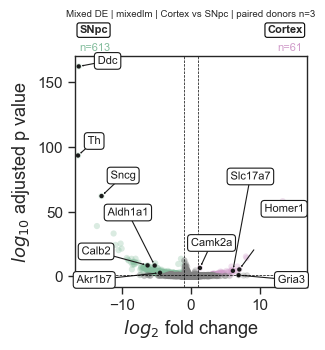

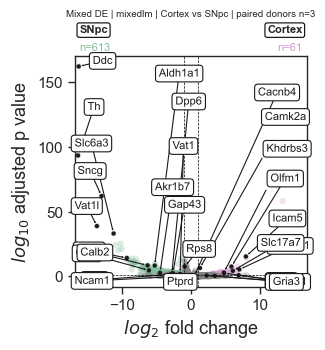

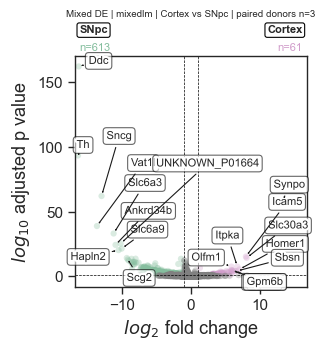

In [19]:
key = "mixed: Cortex vs SNpc | donor=donor"
color_dict={'upregulated':"#D19DCB", 'downregulated': "#85BE9E",'not_significant': "#FFFFFF6A"}

fig, ax = plt.subplots(figsize=(3, 3))
ax, volcano_df = scplt.plot_volcano(ax, de_data=pdata_fig2_mixedeffect.stats[key], correct_fdr=True,
                   threshold=0.05, alpha=0.3, color=color_dict, label=[0,0], return_df=True,
                   group_annot_kwargs={"pos": {"group1_xy": (0.98, 1.09), "group2_xy": (0.02, 1.09)}, 'mixed_xy':(0.5,1.25)},)


cortex_markers=["Nrgn","Celf2","Camk2a","Slc17a7","Homer1","Olfm1","Phactr1","Khdrbs3","Ptprd","Cacnb4","Gria3","Icam5"]
snpc_markers = ["Th","Ddc","Ncam1","Gap43","Vat1","Scg2","Chl1",'Dpp6',"Gaa","Rps8","Vat1l","Slc6a3","Sncg","Calb2","Aldh1a1","Akr1b7"]
ax, texts = scplt.mark_volcano(ax, volcano_df, label=["Sncg", "Ddc", "Th","Slc17a7", "Camk2a","Gria3", "Homer1", "Aldh1a1", "Calb2","Akr1b7"], label_color='k', return_texts=True)
scplt.volcano_adjust_and_outline_texts(texts, expand=(3,3))

ax.set_ylabel('$log_{10}$ adjusted p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

plt.savefig("MANUSCRIPT_revision/REVISION_Fig2-CNS_VOLCANO-directlfq-MixedModelLabeled.svg", bbox_inches="tight", pad_inches=0.1)
# plt.show()

key = "mixed: Cortex vs SNpc | donor=donor"
color_dict={'upregulated':"#D19DCB", 'downregulated': "#85BE9E",'not_significant': "#FFFFFF6A"}

fig, ax = plt.subplots(figsize=(3, 3))
ax, volcano_df = scplt.plot_volcano(ax, de_data=pdata_fig2_mixedeffect.stats[key], correct_fdr=True,
                   threshold=0.05, alpha=0.3, color=color_dict, label=[0,0], return_df=True,
                   group_annot_kwargs={"pos": {"group1_xy": (0.98, 1.09), "group2_xy": (0.02, 1.09)}, 'mixed_xy':(0.5,1.25)},)


cortex_markers=["Nrgn","Celf2","Camk2a","Slc17a7","Homer1","Olfm1","Phactr1","Khdrbs3","Ptprd","Cacnb4","Gria3","Icam5"]
snpc_markers = ["Th","Ddc","Ncam1","Gap43","Vat1","Scg2","Chl1",'Dpp6',"Gaa","Rps8","Vat1l","Slc6a3","Sncg","Calb2","Aldh1a1","Akr1b7"]
ax, texts = scplt.mark_volcano(ax, volcano_df, label=cortex_markers+snpc_markers, label_color='k', return_texts=True)
scplt.volcano_adjust_and_outline_texts(texts, expand=(3,3))

ax.set_ylabel('$log_{10}$ adjusted p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

plt.savefig("MANUSCRIPT_revision/REVISION_Fig2-CNS_VOLCANO-directlfq-MixedModelLabeledSupp.svg", bbox_inches="tight", pad_inches=0.1)

## top 10

fig, ax = plt.subplots(figsize=(3, 3))
ax, volcano_df = scplt.plot_volcano(ax, de_data=pdata_fig2_mixedeffect.stats[key], correct_fdr=True,
                   threshold=0.05, alpha=0.3, color=color_dict, label=[10,10], return_df=True,
                   group_annot_kwargs={"pos": {"group1_xy": (0.98, 1.09), "group2_xy": (0.02, 1.09)}, 'mixed_xy':(0.5,1.25)},)

ax.set_ylabel('$log_{10}$ adjusted p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

plt.savefig("MANUSCRIPT_revision/REVISION_Fig2-CNS_VOLCANO-directlfq-MixedModelTop10.svg", bbox_inches="tight", pad_inches=0.1)
# plt.show()



In [29]:
volcano_df.log2fc.describe()

count    2364.000000
mean       -0.320478
std         0.999850
min        -8.560060
25%        -0.715807
50%        -0.274959
75%         0.179554
max         7.460548
Name: log2fc, dtype: float64

#### adjusted p values

     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=1.92e+04). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: Cortex vs SNpc
   🔸 Group sizes: 40 vs 60 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 Adj p-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 7 proteins were not comparable (zero or NaN mean in one group).
     ✅ DE complete. Results stored in:
       • .stats["Cortex vs SNpc"]
       • Columns: log2fc, p_value, adj_p_value, significance, etc.
       • Upregulated: 84 | Downregulated: 309 | Not significant: 1971 | Not comparable: 7


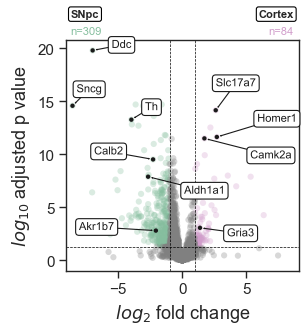

In [14]:
case_values = [{'region': 'Cortex'}, {'region': 'SNpc'}]

color_dict={'upregulated':"#D19DCB", 'downregulated': "#85BE9E",'not_significant': "#FFFFFF6A"}

fig, ax = plt.subplots(figsize=(3, 3))
ax, volcano_df = scplt.plot_volcano(ax, pdata_fig2_region_norm, values=case_values, threshold=0.05, return_df=True, alpha=0.3,
                                    fold_change_mode='mean', color=color_dict, label=[0,0], correct_fdr=True,
                                    group_annot_kwargs={"pos": {"group1_xy": (0.98, 1.09), "group2_xy": (0.02, 1.09)}},)

ax, texts = scplt.mark_volcano(ax, volcano_df, label=["Sncg", "Ddc", "Th","Slc17a7", "Camk2a","Gria3", "Homer1", "Aldh1a1", "Calb2","Akr1b7"], label_color='k', return_texts=True)

# scplt.mark_volcano_by_significance(ax, volcano_df, label=["Camk2a", "Gria3", "Icam5", "Homer1", "Slc17a7", "Th", "Ddc", "Sncg", "Slc6a3", "Calb2", "Aldh1a1", "Akr1b7"], color=color_dict)
scplt.volcano_adjust_and_outline_texts(texts, expand=(3,3))


ax.set_ylabel('$log_{10}$ adjusted p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

plt.show()
# plt.savefig("MANUSCRIPT_revision/REVISION_Fig2-CNS_VOLCANO-directlfq-adjP.svg", bbox_inches="tight")
volcano_df.to_csv("MANUSCRIPT_revision/REVISION_Fig2-CNS_DE-directlfq-adjP.csv")

     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=5.96e+04). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: Cortex vs SNpc
   🔸 Group sizes: 40 vs 60 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 Adj p-value threshold: 0.05 | Log2FC threshold: 1
     ✅ DE complete. Results stored in:
       • .stats["Cortex vs SNpc"]
       • Columns: log2fc, p_value, adj_p_value, significance, etc.
       • Upregulated: 416 | Downregulated: 123 | Not significant: 1832 | Not comparable: 0


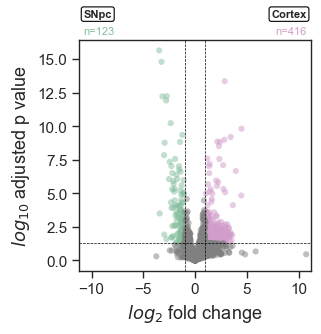

In [15]:
case_values = [{'region': 'Cortex'}, {'region': 'SNpc'}]

color_dict={'upregulated':"#D19DCB", 'downregulated': "#85BE9E",'not_significant': "#FFFFFF6A"}

fig, ax = plt.subplots(figsize=(3, 3))
ax, volcano_df = scplt.plot_volcano(ax, pdata_fig2_region_norm_impute,
                                    values=case_values,
                                    threshold=0.05, return_df=True, correct_fdr=True,
                                    fold_change_mode='mean', color=color_dict, label=[0,0],
                                    group_annot_kwargs={"pos": {"group1_xy": (0.98, 1.09), "group2_xy": (0.02, 1.09)}},)

# scplt.mark_volcano(ax, volcano_df, label=['Snca','Vamp2'], label_color='k')

ax.set_ylabel('$log_{10}$ adjusted p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# plt.show()
# plt.savefig("MANUSCRIPT_revision/REVISION_Fig2-CNS_VOLCANO-impute-adjP.svg", bbox_inches="tight", pad_inches=0.1)
volcano_df.to_csv("MANUSCRIPT_revision/REVISION_Fig2-CNS_DE-impute-adjP.csv")

# Fig 4 - non-neuronal cells

## astrocyte vs neuron

### pre-processing

In [16]:
# take subset of data from pdata_all_region_filtered

pdata_fig4_region_filtered = pdata_all_region_filtered.filter_prot_significant()
pdata_fig4_region_filtered = pdata_fig4_region_filtered.filter_sample(condition="Grouping != 'snpc'")
pdata_fig4_region_filtered = pdata_fig4_region_filtered.filter_sample(condition="Batch != 'Apr-25'")

mapping = {
    "ctx": "Neuron",
    "ast": "Astrocyte",
}
pdata_fig4_region_filtered.summary["cell_type"] = pdata_fig4_region_filtered.summary["Grouping"].replace(mapping)
pdata_fig4_region_filtered.update_summary()

🧭 [USER] Filtering proteins [Significance|File-mode]:
     ℹ️ [INFO] No group provided. Defaulting to sample-level significance filtering.
    Returning a copy of protein data based on significance thresholds:
     🔸 Files requested: All
     🔸 FDR threshold: 0.01
     🔸 Logic: any (protein must be significant in ≥1 file(s))
    → Proteins kept: 4026, Proteins dropped: 88
     ✅ [OK] RS matrix filtered: 4026 proteins, 45593 peptides retained.

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: Grouping != 'snpc'
     ℹ️ Auto-cleanup: Removed 239 empty proteins (all-NaN or all-zero). Proteins: Q9CWG9, B1AZI6, Q6P5G6, Q99PW4, A2ASI5, Q9D1F4, Q99L88, O70566, Q3V4B5, Q9R1J0, ...
    → Samples kept: 45, Samples dropped: 60
    → Proteins kept: 3787

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: Batch != 'Apr-25'
     ℹ️ Auto-cleanup: Removed 82 empty proteins (a

In [17]:
pdata_fig4_region_processed = pdata_fig4_region_filtered.copy()
pdata_fig4_region_processed = pdata_fig4_region_processed.filter_sample(min_prot=1800)

pdata_fig4_region_processed = pdata_fig4_region_processed.filter_prot_found(min_ratio=0.4, group = ['cell_type'], match_any=True)
pdata_fig4_region_processed = pdata_fig4_region_processed.filter_prot(valid_genes=True, unique_profiles=True)

pdata_fig4_region_norm = pdata_fig4_region_processed.copy()
pdata_fig4_region_norm.normalize(method='directlfq')

print(pdata_fig4_region_norm.summary['Grouping'].value_counts())
print(pdata_fig4_region_norm.summary['Batch'].value_counts())
print(pdata_fig4_region_norm.summary['cell_type'].value_counts())

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: protein_count >= 1800
     ℹ️ Auto-cleanup: Removed 13 empty proteins (all-NaN or all-zero). Proteins: Q6Y7W8, P13541, Q5SX39, G3UW82, P58742, Q91VS7, P06467, Q8CEC5, Q8R066, Q7TQG1, ...
    → Samples kept: 19, Samples dropped: 7
    → Proteins kept: 3692

🧭 [USER] Filtering proteins [Found|Group-mode|ANY]:
     ℹ️ [INFO] Found matching groups(s): ['Neuron', 'Astrocyte']. Automatically annotating detection by group values.
    Returning a copy of protein data based on detection thresholds:
     🔸 Groups requested: ['Neuron', 'Astrocyte']
     🔸 Minimum ratio: 0.4
     🔸 Logic: any (protein must be detected in ≥1 group(s))
    → Proteins kept: 2866, Proteins dropped: 826
     ✅ [OK] RS matrix filtered: 2866 proteins, 42452 peptides retained.

🧭 [USER] Filtering proteins [valid genes, unique profiles]:
    Returning a copy of protein data with the following filters applied:
 

2026-09-09 18:24:58,445 - directlfq.lfq_manager - INFO - Starting directLFQ analysis.
2026-09-09 18:24:58,610 - directlfq.lfq_manager - INFO - Performing sample normalization.
2026-09-09 18:24:58,621 - directlfq.lfq_manager - INFO - Estimating lfq intensities.
2026-09-09 18:24:58,624 - directlfq.protein_intensity_estimation - INFO - 2866 lfq-groups total
2026-09-09 18:24:59,567 - directlfq.protein_intensity_estimation - INFO - using 16 processes
2026-09-09 18:25:08,342 - directlfq.lfq_manager - INFO - Could not add additional columns to protein table, printing without additional columns.
2026-09-09 18:25:08,343 - directlfq.lfq_manager - INFO - Writing results files.
2026-09-09 18:25:08,655 - directlfq.lfq_manager - INFO - Analysis finished!


     ℹ️ Set protein data to layer X_norm_directlfq.
     ✅ directlfq normalization complete. Results are stored in layer 'X_norm_directlfq'.
          ⚠️ Downstream imputation should be performed with the flag `use_zeros_as_nan` set to True due to directlfq output format returning NaNs as 0s.
Grouping
ctx    14
ast     5
Name: count, dtype: int64
Batch
Jun-24    13
Apr-24     4
Nov-24     2
Name: count, dtype: int64
cell_type
Neuron       14
Astrocyte     5
Name: count, dtype: int64


### plots

In [18]:
cell_type_color={
    "Neuron": "#D19DCB",
    "Astrocyte": "#84C8D5" # "#CAEEFB"
}

     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=1.03e+04). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: [{'cell_type': 'Neuron'}] vs [{'cell_type': 'Astrocyte'}]
   🔸 Group sizes: 14 vs 5 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 Adj p-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 119 proteins were not comparable (zero or NaN mean in one group).


G:\Users\srpang\Dropbox (Personal)\4. Caltech Work\Research\Chou-Roukes Group\scpviz_main\src\scpviz\pAnnData\analysis.py:354: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = ttest_ind(x1, x2, equal_var=equal_var, nan_policy='omit')


     ✅ DE complete. Results stored in:
       • .stats["[{'cell_type': 'Neuron'}] vs [{'cell_type': 'Astrocyte'}]"]
       • Columns: log2fc, p_value, adj_p_value, significance, etc.
       • Upregulated: 44 | Downregulated: 69 | Not significant: 2634


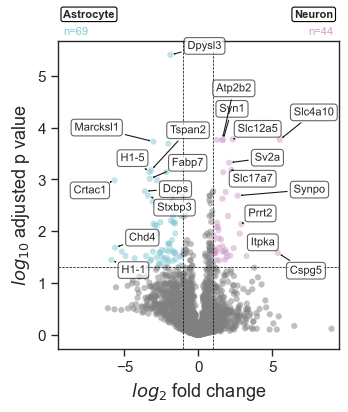

In [69]:
case1 = {'cell_type': 'Neuron'}
case2 = {'cell_type': 'Astrocyte'}
case_values = [case1, case2]

cell_type_color={
    "Neuron": "#D19DCB",
    "Astrocyte": "#84C8D5" # "#CAEEFB"
}
color_dict={'upregulated': cell_type_color['Neuron'], 'downregulated': cell_type_color['Astrocyte'],'not_significant': "#FFFFFF6A"}

fig, ax = plt.subplots(figsize=(3.63, 4))
ax, volcano_df = scplt.plot_volcano(ax, pdata_fig4_region_norm,
                                    values=case_values,
                                    threshold=0.05, return_df=True, correct_fdr=True,
                                    fold_change_mode='mean', color=color_dict, label=[10,10])

ax.set_ylabel('$log_{10}$ adjusted p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# plt.show()
plt.savefig("MANUSCRIPT_revision/REVISION_Fig4-non-neuron_VOLCANO-directlfq-top10-adjP.svg", bbox_inches="tight", pad_inches=0.1)
volcano_df.to_csv("MANUSCRIPT_revision/REVISION_Fig4-non-neuron_DE-directlfq-adjP.csv")


## SWI model

### pre-processing

In [19]:
obs_columns = ['date', 'acquisition', 'size', 'cell_type', 'replicate']

pdata_fig4_swi = pAnnData.import_data(source_type='diann', report_file = 'data/2511_ast-SWI-only/report.parquet', obs_columns=obs_columns)

🧭 [USER] Importing data of type [diann]
--------------------------
Starting import [DIA-NN]

Source file: data/2511_ast-SWI-only/report.parquet
Number of files: 20
Proteins: 8678
Peptides: 69299

     ℹ️ [INFO] Using sample-specific q-values for 'prot' significance annotation.
     ℹ️ [INFO] Using sample-specific q-values for 'pep' significance annotation.

ℹ️ RS matrix: (8678, 69299) (proteins × peptides), sparsity: 99.99%
   - Proteins with ≥2 *unique* linked peptides: 4452/8678
   - Peptides linked to ≥2 proteins: 9794/69299
   - Mean peptides per protein: 9.63
   - Mean proteins per peptide: 1.21
     ✅ [OK] pAnnData object is valid.
     ✅ [OK] Import complete. Use `print(pdata)` to view the object.
--------------------------


g:\Users\marion\miniconda3\envs\scpviz_dev\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
g:\Users\marion\miniconda3\envs\scpviz_dev\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [20]:
pdata_fig4_swi_filtered = pdata_fig4_swi.filter_sample(condition="cell_type not in ['T2','TEAB35']")
pdata_fig4_swi_filtered = pdata_fig4_swi_filtered.filter_prot_significant()
pdata_fig4_swi_filtered = pdata_fig4_swi_filtered.filter_sample(min_prot=1000)

mapping = {
    "scartissue": "SWI",
    "astrocyte": "Uninjured",
}
pdata_fig4_swi_filtered.summary["condition"] = pdata_fig4_swi_filtered.summary["cell_type"].replace(mapping)
pdata_fig4_swi_filtered.update_summary()

pdata_fig4_swi_filtered.prot.obs.condition.value_counts()

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: cell_type not in ['T2','TEAB35']
     ℹ️ Auto-cleanup: Removed 3228 empty proteins (all-NaN or all-zero). Proteins: O35226-4, E9Q4N7, Q6PD26, Q91ZP6, Q8R3H9, P97868, P97868-2, Q3U1F9, Q8C196, P46662, ...
    → Samples kept: 11, Samples dropped: 9
    → Proteins kept: 5450

🧭 [USER] Filtering proteins [Significance|File-mode]:
     ℹ️ [INFO] No group provided. Defaulting to sample-level significance filtering.
    Returning a copy of protein data based on significance thresholds:
     🔸 Files requested: All
     🔸 FDR threshold: 0.01
     🔸 Logic: any (protein must be significant in ≥1 file(s))
    → Proteins kept: 4637, Proteins dropped: 813
     ✅ [OK] RS matrix filtered: 4637 proteins, 59894 peptides retained.

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: protein_count >= 1000
     ℹ️ Auto-cleanup: No em

condition
Uninjured    5
SWI          5
Name: count, dtype: int64

In [21]:
pdata_fig4_swi_processed = pdata_fig4_swi_filtered.copy()
pdata_fig4_swi_processed = pdata_fig4_swi_processed.filter_prot_found(min_ratio=0.4, group = ['condition'], match_any=True)
pdata_fig4_swi_processed = pdata_fig4_swi_processed.filter_prot(valid_genes=True, unique_profiles=True)

pdata_fig4_swi_norm = pdata_fig4_swi_processed.copy()
pdata_fig4_swi_norm.normalize(method='directlfq')

🧭 [USER] Filtering proteins [Found|Group-mode|ANY]:
     ℹ️ [INFO] Found matching groups(s): ['Uninjured', 'SWI']. Automatically annotating detection by group values.
    Returning a copy of protein data based on detection thresholds:
     🔸 Groups requested: ['Uninjured', 'SWI']
     🔸 Minimum ratio: 0.4
     🔸 Logic: any (protein must be detected in ≥1 group(s))
    → Proteins kept: 3830, Proteins dropped: 807
     ✅ [OK] RS matrix filtered: 3830 proteins, 56666 peptides retained.

🧭 [USER] Filtering proteins [valid genes, unique profiles]:
    Returning a copy of protein data with the following filters applied:
     🔸 valid_genes — removed 16 proteins with invalid gene names
     🔸 valid_genes — resolved 455 duplicate gene names by appending numeric suffixes
     🔸 unique_profiles — removed 622 duplicate and 0 empty abundance profiles (622 total)
    → Proteins kept: 3192
    → Peptides kept (linked): 56641
     ✅ [OK] RS matrix filtered: 3192 proteins, 56641 peptides retained.
🧭 [U

2026-09-09 18:27:23,899 - directlfq.lfq_manager - INFO - Starting directLFQ analysis.
2026-09-09 18:27:24,085 - directlfq.lfq_manager - INFO - Performing sample normalization.
2026-09-09 18:27:24,091 - directlfq.lfq_manager - INFO - Estimating lfq intensities.
2026-09-09 18:27:24,093 - directlfq.protein_intensity_estimation - INFO - 3192 lfq-groups total
2026-09-09 18:27:24,920 - directlfq.protein_intensity_estimation - INFO - using 16 processes
2026-09-09 18:27:34,538 - directlfq.lfq_manager - INFO - Could not add additional columns to protein table, printing without additional columns.
2026-09-09 18:27:34,539 - directlfq.lfq_manager - INFO - Writing results files.
2026-09-09 18:27:34,736 - directlfq.lfq_manager - INFO - Analysis finished!


     ℹ️ Set protein data to layer X_norm_directlfq.
     ✅ directlfq normalization complete. Results are stored in layer 'X_norm_directlfq'.
          ⚠️ Downstream imputation should be performed with the flag `use_zeros_as_nan` set to True due to directlfq output format returning NaNs as 0s.


### plots

In [22]:
condition_color={
    "SWI": "#1F98B1",
    "Uninjured": "#ACDFE9" # "#CAEEFB"
}

     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=4.92e+04). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: SWI vs Uninjured
   🔸 Group sizes: 5 vs 5 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 Adj p-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 413 proteins were not comparable (zero or NaN mean in one group).


g:\Users\marion\miniconda3\envs\scpviz_dev\Lib\site-packages\scpviz\pAnnData\analysis.py:356: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = ttest_ind(x1, x2, equal_var=equal_var, nan_policy='omit')


     ✅ DE complete. Results stored in:
       • .stats["SWI vs Uninjured"]
       • Columns: log2fc, p_value, adj_p_value, significance, etc.
       • Upregulated: 2 | Downregulated: 3 | Not significant: 2774 | Not comparable: 413


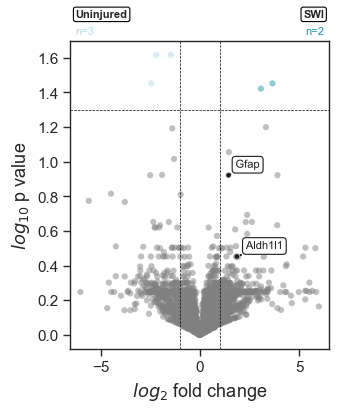

In [23]:
case_values = [{'condition': 'SWI'}, {'condition': 'Uninjured'}]

color_dict={'upregulated':condition_color['SWI'], 'downregulated': condition_color['Uninjured'],'not_significant': "#FFFFFF6A"}

fig, ax = plt.subplots(figsize=(3.34, 4))
ax, volcano_df = scplt.plot_volcano(ax, pdata_fig4_swi_norm, values = case_values, threshold = 0.05, return_df=True, correct_fdr=True, color=color_dict, label=[0,0])
scplt.mark_volcano(ax, volcano_df, label=['Aldh1l1','Gfap'], label_color='k')

ax.set_ylabel('$log_{10}$ p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

volcano_df.to_csv("MANUSCRIPT_revision/REVISION_Fig4-SWI_DE-directlfq-adjP.csv")


# Fig 5 - snpc subtypes

## anxa

### pre-processing

In [24]:
pdata_fig3_snpc_filter = pdata_all_region_filtered.filter_sample(condition ='Grouping == "snpc"')
pdata_fig3_snpc_filter = pdata_fig3_snpc_filter.filter_sample(condition = 'Batch == "Apr-25"')
pdata_fig3_snpc_filter = pdata_fig3_snpc_filter.filter_prot_significant()
pdata_fig3_snpc_filter = pdata_fig3_snpc_filter.filter_sample(min_prot=1000)

pdata_fig3_snpc_filter.summary["cell_type"] = pdata_fig3_snpc_filter.summary["Sub grouping"].replace({
    "anxaY": "Anxa+",
    "anxaN": "Anxa-"
})
pdata_fig3_snpc_filter.update_summary()

pdata_fig3_snpc_processed = pdata_fig3_snpc_filter.copy()
pdata_fig3_snpc_processed = pdata_fig3_snpc_processed.filter_prot_found(min_ratio=0.4, group = ['Sub grouping'], match_any=True)
pdata_fig3_snpc_processed = pdata_fig3_snpc_processed.filter_prot(valid_genes=True, unique_profiles=True)

pdata_fig3_snpc_norm = pdata_fig3_snpc_processed.copy()
pdata_fig3_snpc_norm.normalize(method='directlfq')

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: Grouping == "snpc"
     ℹ️ Auto-cleanup: Removed 128 empty proteins (all-NaN or all-zero). Proteins: Q9CPP0, Q6NZB0, Q9D289, Q80UK0, Q9DB75, P63024, Q5DU31, Q60847, Q80TL1, P11157, ...
    → Samples kept: 60, Samples dropped: 45
    → Proteins kept: 3986

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: Batch == "Apr-25"
     ℹ️ Auto-cleanup: Removed 134 empty proteins (all-NaN or all-zero). Proteins: B1AZI6, Q6P5G6, Q9CR41, Q99L88, Q9R1J0, Q9JKY0, Q8R1H0, Q9CQU3, Q7M753, Q8BJZ4, ...
    → Samples kept: 33, Samples dropped: 27
    → Proteins kept: 3852

🧭 [USER] Filtering proteins [Significance|File-mode]:
     ℹ️ [INFO] No group provided. Defaulting to sample-level significance filtering.
    Returning a copy of protein data based on significance thresholds:
     🔸 Files requested: All
     🔸 FDR threshold: 0

2026-09-09 18:29:33,711 - directlfq.lfq_manager - INFO - Starting directLFQ analysis.
2026-09-09 18:29:33,915 - directlfq.lfq_manager - INFO - Performing sample normalization.
2026-09-09 18:29:33,939 - directlfq.lfq_manager - INFO - Estimating lfq intensities.
2026-09-09 18:29:33,941 - directlfq.protein_intensity_estimation - INFO - 2729 lfq-groups total
2026-09-09 18:29:34,814 - directlfq.protein_intensity_estimation - INFO - using 16 processes
2026-09-09 18:29:44,442 - directlfq.lfq_manager - INFO - Could not add additional columns to protein table, printing without additional columns.
2026-09-09 18:29:44,442 - directlfq.lfq_manager - INFO - Writing results files.
2026-09-09 18:29:45,000 - directlfq.lfq_manager - INFO - Analysis finished!


     ℹ️ Set protein data to layer X_norm_directlfq.
     ✅ directlfq normalization complete. Results are stored in layer 'X_norm_directlfq'.
          ⚠️ Downstream imputation should be performed with the flag `use_zeros_as_nan` set to True due to directlfq output format returning NaNs as 0s.


In [14]:
pd.DataFrame(pdata_fig3_snpc_norm.summary)

,File,parsingType,protein_quant,protein_count,protein_abundance_sum,File Name,Grouping,Sub grouping,Region,Batch,cell_type,peptide_quant,peptide_count,peptide_abundance_sum,unique_pep2_protein_count
20250429_Aur60minDIA_F29_600_N1_35um_anxa_Mus_SNpc_I10,20,10-tokens,0.819348,2236,1.687024e+09,snpc/anxa_C_5,snpc,anxaY,Anxa_C,Apr-25,Anxa+,0.277627,11584,4.225355e+09,2183
20250429_Aur60minDIA_F30_600_N1_35um_anxa_Mus_SNpc_I11,25,10-tokens,0.730304,1993,1.484908e+09,snpc/anxa_C_6,snpc,anxaY,Anxa_C,Apr-25,Anxa+,0.228065,9516,4.564400e+09,1959
20250429_Aur60minDIA_K2_600_Y2_35um_anxa_Mus_snpc_M6,33,10-tokens,0.740564,2021,1.648469e+09,snpc/anxa_C_14,snpc,anxaY,Anxa_C,Apr-25,Anxa+,0.232379,9696,4.511680e+09,1974
20250429_Aur60minDIA_K23_600_Y2_35um_anxa-th_Mus_vta_K16,37,10-tokens,0.897032,2448,7.079586e+08,snpc/non-anxa_C_7,snpc,anxaN,TH_C,Apr-25,Anxa-,0.327837,13679,1.919768e+09,2384
20250429_Aur60minDIA_K26_600_Y3_35um_anxa-th_Mus_vta_K19_20250507144326,43,11-tokens,0.851228,2323,1.298623e+09,snpc/non-anxa_C_10,snpc,anxaN,TH_C,Apr-25,Anxa-,0.322588,13460,2.711343e+09,2267
20250429_Aur60minDIA_F28_600_Y2_35um_anxa_Mus_SNpc_I9,44,10-tokens,0.821913,2243,5.576947e+08,snpc/anxa_C_4,snpc,anxaY,Anxa_C,Apr-25,Anxa+,0.278826,11634,1.745808e+09,2198
20250429_Aur60minDIA_K15_600_Y4_35um_anxa-th_Mus_vta_M19,46,10-tokens,0.928912,2535,4.818490e+08,snpc/non-anxa_C_3,snpc,anxaN,TH_C,Apr-25,Anxa-,0.382457,15958,1.927522e+09,2465
20250429_Aur60minDIA_K3_600_Y2_35um_anxa_Mus_snpc_M7,47,10-tokens,0.688164,1878,9.690228e+08,snpc/anxa_C_16,snpc,anxaY,Anxa_C,Apr-25,Anxa+,0.206830,8630,1.824999e+09,1842
20250429_Aur60minDIA_K12_600_Y3_35um_anxa_Mus_snpc_M16,50,10-tokens,0.846830,2311,4.897637e+08,snpc/anxa_C_10,snpc,anxaY,Anxa_C,Apr-25,Anxa+,0.306794,12801,2.013594e+09,2260
20250429_Aur60minDIA_K28_600_Y1_35um_anxa-th_Mus_vta_K9_20250507180452,51,11-tokens,0.851228,2323,5.420910e+08,snpc/non-anxa_C_12,snpc,anxaN,TH_C,Apr-25,Anxa-,0.297496,12413,1.620946e+09,2259


### plots

In [25]:
anxa_color={
    "Anxa-": "#A0FFA0",
    "Anxa+": "white"
}

     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=2.72e+04). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: Anxa+ vs Anxa-
   🔸 Group sizes: 18 vs 15 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 Adj p-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 12 proteins were not comparable (zero or NaN mean in one group).
     ✅ DE complete. Results stored in:
       • .stats["Anxa+ vs Anxa-"]
       • Columns: log2fc, p_value, adj_p_value, significance, etc.
       • Upregulated: 4 | Downregulated: 22 | Not significant: 2691 | Not comparable: 12


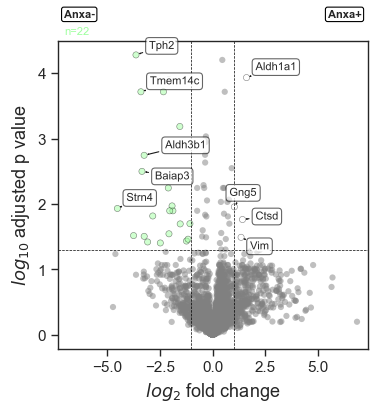

In [26]:
case_values = [{'cell_type': 'Anxa+'}, {'cell_type': 'Anxa-'}]

color_dict={'upregulated':anxa_color['Anxa+'], 'downregulated': anxa_color['Anxa-'],'not_significant': "#FFFFFF6A"}

fig, ax = plt.subplots(figsize=(4, 4))
ax, volcano_df = scplt.plot_volcano(ax, pdata_fig3_snpc_norm,
                                    values=case_values,
                                    threshold=0.05, return_df=True, correct_fdr=True,
                                    fold_change_mode='mean', color=color_dict, label=[5,5])

white = np.array([1.0, 1.0, 1.0])
green = np.array([160/255, 1.0, 160/255])  # #A0FFA0

for coll in ax.collections:
    fc = coll.get_facecolors()
    if fc is None or fc.size == 0:
        continue

    mask_white = (fc[:, :3] == white).all(axis=1)
    mask_green = (fc[:, :3] == green).all(axis=1)
    mask = mask_white | mask_green

    if mask.any():
        ec = np.zeros_like(fc)          # transparent edges by default
        ec[mask] = [0, 0, 0, 1]         # black outline
        coll.set_edgecolors(ec)

        lw = np.zeros(len(fc))
        lw[mask] = 0.4
        coll.set_linewidths(lw)

ax.set_ylabel('$log_{10}$ adjusted p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# plt.show()
# plt.savefig("MANUSCRIPT_revision/REVISION_Fig3-Anxa_VOLCANO-directlfq-top5_adj-p.svg", bbox_inches="tight", pad_inches=0.1)
volcano_df.to_csv("MANUSCRIPT_revision/REVISION_Fig3-Anxa_DE-directlfq-adjP.csv")

# Fig 6 - 6mo mouse (snpc)

### pre-processing

In [2]:
# pdata_6mo_diann_base = pAnnData.import_data(source_type='diann', report_file = 'data/2506_Mus1mo3mo6moAco/diann_6mo/report.parquet') #, obs_columns = obs_columns
pdata_6mo_diann_base = pAnnData.import_data(source_type='diann', report_file = 'data/2511_Mus6moSnpcONLY/report.parquet')

🧭 [USER] Importing data of type [diann]
      Auto-detecting '_' as delimiter from first filename.
     ⚠️ [WARN] 2 different filename formats detected. Proceeding with fallback `.obs` structure... (File Number, Parsing Type)
--------------------------
Starting import [DIA-NN]

Source file: data/2511_Mus6moSnpcONLY/report.parquet
Number of files: 36
Proteins: 7848
Peptides: 43076

     ℹ️ [INFO] Using sample-specific q-values for 'prot' significance annotation.
     ℹ️ [INFO] Using sample-specific q-values for 'pep' significance annotation.

ℹ️ RS matrix: (7848, 43076) (proteins × peptides), sparsity: 99.98%
   - Proteins with ≥2 *unique* linked peptides: 3666/7848
   - Peptides linked to ≥2 proteins: 7445/43076
   - Mean peptides per protein: 6.89
   - Mean proteins per peptide: 1.26
     ✅ [OK] pAnnData object is valid.
     ✅ [OK] Import complete. Use `print(pdata)` to view the object.
--------------------------


In [3]:
colnames = [
    'date',
    'gradient',
    'sample_id',
    'size',
    'confirmation',
    'thickness',
    'sample',
    'organism',
    'region',
    'well_position'
]

# ignore 11-token parsing type on both
pdata_6mo_diann = pdata_6mo_diann_base.filter_sample(condition='parsingType == "10-tokens"')
pdata_6mo_diann.summary = scutils.parse_filename_index(pdata_6mo_diann.summary, colnames)

pdata_6mo_processed = pdata_6mo_diann.filter_prot_significant()

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: parsingType == "10-tokens"
     ℹ️ Auto-cleanup: Removed 2560 empty proteins (all-NaN or all-zero). Proteins: Q80WW9, Q9D061, Q91ZM2, Q91ZM2-2, Q91ZM2-3, Q91ZM2-4, Q91ZM2-6, Q99MS8, Q68FF7, Q68FF7-2, ...
    → Samples kept: 32, Samples dropped: 4
    → Proteins kept: 5288

🔄 [UPDATE] Updating summary [sync_back]: pushed edits from `.summary` to `.obs`.
      Columns updated: date, organism, sample_id, well_position, confirmation, region, sample, size, gradient, thickness.
🧭 [USER] Filtering proteins [Significance|File-mode]:
     ℹ️ [INFO] No group provided. Defaulting to sample-level significance filtering.
    Returning a copy of protein data based on significance thresholds:
     🔸 Files requested: All
     🔸 FDR threshold: 0.01
     🔸 Logic: any (protein must be significant in ≥1 file(s))
    → Proteins kept: 4407, Proteins dropped: 881
     ✅ [OK] RS matrix filtered: 4

In [4]:
pdata_6mo_snpc = pdata_6mo_processed.filter_sample(condition='region == "snpc"')
pdata_6mo_snpc = pdata_6mo_snpc.filter_sample(min_prot=1000)
pdata_6mo_snpc.summary["sample"] = pdata_6mo_snpc.summary["sample"].replace({
    "6mo-aggY": "Agg+",
    "6mo-aggN": "Agg-"
})
pdata_6mo_snpc.update_summary()

pdata_6mo_snpc_filter = pdata_6mo_snpc.copy()
pdata_6mo_snpc_filter = pdata_6mo_snpc_filter.filter_prot_found(min_ratio=0.4, group=['sample'],match_any=True)
pdata_6mo_snpc_filter = pdata_6mo_snpc_filter.filter_prot(valid_genes=True, unique_profiles=True)
pdata_6mo_snpc_filter = pdata_6mo_snpc_filter.filter_sample(min_prot=1000)
# pdata_6mo_snpc.impute(method='min', min_scale=0.2)

pdata_6mo_snpc_norm = pdata_6mo_snpc_filter.copy()
pdata_6mo_snpc_norm.normalize(method='directlfq')
# pdata_6mo_snpc_norm = pdata_6mo_snpc_norm.filter_sample(min_prot=1000)

pdata_6mo_snpc_norm.summary['sample'].value_counts()

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: region == "snpc"
     ℹ️ Auto-cleanup: No empty proteins found (all-NaN or all-zero).
    → Samples kept: 32, Samples dropped: 0
    → Proteins kept: 4407

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: protein_count >= 1000
     ℹ️ Auto-cleanup: Removed 3 empty proteins (all-NaN or all-zero). Proteins: Q8VHG0, Q9D6H2, Q80Z25
    → Samples kept: 20, Samples dropped: 12
    → Proteins kept: 4404

🔄 [UPDATE] Updating summary [sync_back]: pushed edits from `.summary` to `.obs` (marked stale).
      Columns updated: sample.
🧭 [USER] Filtering proteins [Found|Group-mode|ANY]:
     ℹ️ [INFO] Found matching groups(s): ['Agg-', 'Agg+']. Automatically annotating detection by group values.
    Returning a copy of protein data based on detection thresholds:
     🔸 Groups requested: ['Agg-', 'Agg+']
     🔸 Minimum ratio

2026-08-03 17:49:24,574 - directlfq.lfq_manager - INFO - Starting directLFQ analysis.
2026-08-03 17:49:24,864 - directlfq.lfq_manager - INFO - Performing sample normalization.
2026-08-03 17:49:27,049 - directlfq.lfq_manager - INFO - Estimating lfq intensities.
2026-08-03 17:49:27,053 - directlfq.protein_intensity_estimation - INFO - 2350 lfq-groups total
2026-08-03 17:49:28,369 - directlfq.protein_intensity_estimation - INFO - using 12 processes
2026-08-03 17:49:40,974 - directlfq.lfq_manager - INFO - Could not add additional columns to protein table, printing without additional columns.
2026-08-03 17:49:40,974 - directlfq.lfq_manager - INFO - Writing results files.
2026-08-03 17:49:41,420 - directlfq.lfq_manager - INFO - Analysis finished!


     ℹ️ Set protein data to layer X_norm_directlfq.
     ✅ directlfq normalization complete. Results are stored in layer 'X_norm_directlfq'.
          ⚠️ Downstream imputation should be performed with the flag `use_zeros_as_nan` set to True due to directlfq output format returning NaNs as 0s.


sample
Agg+    12
Agg-     7
Name: count, dtype: int64

In [5]:
pdata_6mo_snpc_norm_RF = pdata_6mo_snpc_filter.copy()
pdata_6mo_snpc_norm_RF.normalize(method="reference_feature",
    reference_columns=["Tubb5", "Gapdh"]
)
# pdata_6mo_snpc_norm = pdata_6mo_snpc_norm.filter_sample(min_prot=1000)

🧭 [USER] Global normalization using 'reference_feature'. Layer will be saved as 'X_norm_reference_feature'.
     ℹ️ [INFO] Normalizing using found reference columns: ['P99024', 'P16858']
     ✅ Normalized all 19 samples.
     ℹ️ Set protein data to layer X_norm_reference_feature.


### plots

In [5]:
agg_color={
    "Agg+": "#C64D4A",
    "Agg-": "#BFBFBF"
}

[get_abundance] 4278 peptides could not be mapped to genes: ['AAAELLQSQGSQAGGSQTLK3', 'AAAELLQSQGSQAGGSQTLKR3', 'AAAEVNQEYGLDPK2', 'AAALVLQTIWGYK2', 'AAALVLQTIWGYK3', 'AAAMANNLQK2', 'AAAQLGVEELQK2', 'AAAQLLQSQAQQSGAQQTK3', 'AAAQVLNTLWQYR2', 'AAASEGVQVK2', 'AAATFNPELITHILDGSPENTR3', 'AAAVDFTAR2', 'AADEVAEGK2', 'AADFEDLLSSQGFNAHK3', 'AAEDSNLISGFGVAEGSEK3', 'AAEEAEEAR2', 'AAEEVGYPVMIK2', 'AAEGISSDSLLSVPGQK3', 'AAEQAASDLR2', 'AAEVYTR2', 'AAFFAER2', 'AAFIDNMNQYTR2', 'AAKPGANSTTDAVLLNK3', 'AALADVLR2', 'AALAHSEIATTQAASTK3', 'AALPLTTSDTK2', 'AALSEMVEYITHNR3', 'AALSSFQK2', 'AAMEALQSQALHATSQQPLR3', 'AAMEALQSQALHATSQQPLRK3', 'AAMEALQSQALHATSQQPLRK4', 'AAMIWIVGEYAER2', 'AAMIWIVGEYAER3', 'AANAASGAGGSSAAAGSR2', 'AAPPPPPPPPPPLGADR3', 'AAQLC(UniMod:4)GAGMAAVVEK2', 'AASQGYTVAR2', 'AAVESDTEFWDK2', 'AAYVLFYQR2', 'ADAATSFLR2', 'ADAGFVYSEAVASHYMR3', 'ADAVHLFSGSQFESSR3', 'ADFDNTVAIHPTSSEELVTLR3', 'ADGSDLISADAEQR2', 'ADILEDKDGK2', 'ADLGALELWR2', 'ADNEKLEEQPGEQAPR3', 'ADPPQAMNALMR2', 'ADSEEEGAVELAA2', 'ADTIDT

C:\Users\srpang\AppData\Local\Temp\ipykernel_14476\2539405596.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


Peptide abundance: Agg+ median=5.795 (n=12), Agg- median=5.736 (n=7), t=0.693, p=0.4980


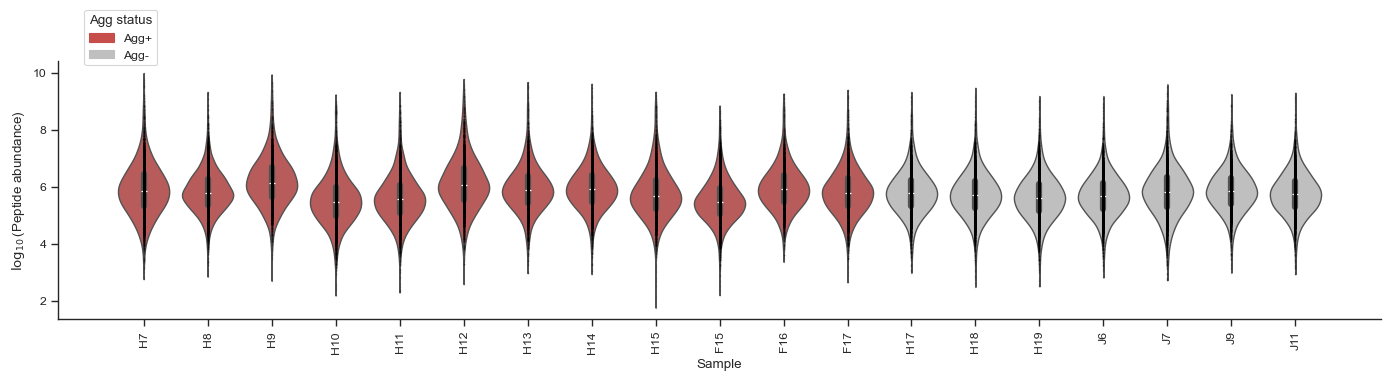

In [ ]:
# PEPTIDE ABUNDANCE DIST

import matplotlib.patches as mpatches
from scipy import stats

agg_color = {"Agg+": "#C64D4A", "Agg-": "#BFBFBF"}
agg_order = ["Agg+", "Agg-"]

df_raw = pdata_6mo_snpc_filter.get_abundance(on="peptide", classes="sample", log=False)
df_raw = df_raw[df_raw["abundance"] > 0].copy()
df_raw["log10_abundance"] = np.log10(df_raw["abundance"])

sample_meta = df_raw.groupby("cell")["class"].first()
sample_order = (
    sample_meta[sample_meta == "Agg+"].index.tolist()
    + sample_meta[sample_meta == "Agg-"].index.tolist()
)
short_labels = [s.split("_")[-1] for s in sample_order]
violin_colors = [agg_color[sample_meta[s]] for s in sample_order]

fig, ax = plt.subplots(figsize=(14, 4))

sns.violinplot(
    data=df_raw,
    x="cell",
    y="log10_abundance",
    order=sample_order,
    palette=violin_colors,
    inner="box",
    cut=0,
    linewidth=1,
    bw_adjust=1.5,
    gridsize=200,
    ax=ax,
)

xs = [sample_order.index(c) for c in df_raw["cell"]]
ax.scatter(xs, df_raw["log10_abundance"], color="black", s=1.3**2, alpha=0.12, linewidths=0, zorder=3)

ax.set_xlabel("Sample")
ax.set_ylabel(r"$\log_{10}$(Peptide abundance)")
ax.set_xticks(range(len(sample_order)))
ax.set_xticklabels(short_labels, rotation=90)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

handles = [mpatches.Patch(color=agg_color[k], label=k) for k in agg_order]
ax.legend(handles=handles, title="Agg status", frameon=True,
          bbox_to_anchor=(0.02, 1.2), loc="upper left", borderaxespad=0)

plt.tight_layout()
plt.savefig("MANUSCRIPT_revision/REVISION_Fig6-Abundance_Peptide_Violin.svg", bbox_inches="tight", pad_inches=0.1)

# t-test on per-sample medians
medians = df_raw.groupby("cell")["log10_abundance"].median()
agg_plus  = medians[sample_meta[medians.index] == "Agg+"]
agg_minus = medians[sample_meta[medians.index] == "Agg-"]
t, p = stats.ttest_ind(agg_plus, agg_minus)
print(f"Peptide abundance: Agg+ median={agg_plus.mean():.3f} (n={len(agg_plus)}), "
      f"Agg- median={agg_minus.mean():.3f} (n={len(agg_minus)}), t={t:.3f}, p={p:.4f}")

Raw (pre-normalization): Agg+ median=5.872 (n=12 cells), Agg- median=5.813 (n=7 cells), t=1.014, p=0.3249
Normalized: Agg+ median=5.981 (n=12 cells), Agg- median=6.026 (n=7 cells), t=-0.759, p=0.4580


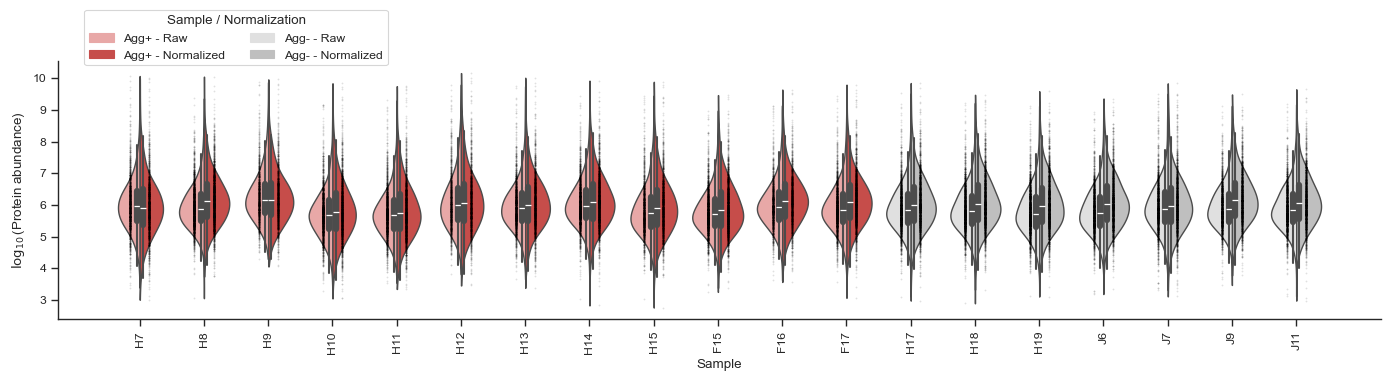

In [27]:
# PROTEIN ABUNDANCE DIST (directLFQ)

import matplotlib.patches as mpatches

agg_color = {"Agg+": "#C64D4A", "Agg-": "#BFBFBF"}
agg_color_raw = {"Agg+": "#E8A8A7", "Agg-": "#E0E0E0"}  # lighter versions for raw

agg_order = ["Agg+", "Agg-"]

# --- load both datasets and tag them ---
df_raw = pdata_6mo_snpc_filter.get_abundance(on="protein", classes="sample", log=False)
df_raw = df_raw[df_raw["abundance"] > 0].copy()
df_raw["log10_abundance"] = np.log10(df_raw["abundance"])
df_raw["norm_status"] = "Raw"

df_norm = pdata_6mo_snpc_norm.get_abundance(on="protein", classes="sample", log=False)
df_norm = df_norm[df_norm["abundance"] > 0].copy()
df_norm["log10_abundance"] = np.log10(df_norm["abundance"])
df_norm["norm_status"] = "Normalized"

df = pd.concat([df_raw, df_norm], ignore_index=True)

sample_meta = df_raw.groupby("cell")["class"].first()
sample_order = (
    sample_meta[sample_meta == "Agg+"].index.tolist()
    + sample_meta[sample_meta == "Agg-"].index.tolist()
)

fig, ax = plt.subplots(figsize=(14, 4))

sns.violinplot(
    data=df,
    x="cell",
    y="log10_abundance",
    hue="norm_status",
    hue_order=["Raw", "Normalized"],
    order=sample_order,
    split=True,
    inner="box",
    cut=0,
    linewidth=1,
    bw_adjust=1.5,
    gridsize=200,
    ax=ax,
)

# re-color violin halves: left=Raw (light), right=Normalized (dark)
for i, sample in enumerate(sample_order):
    agg = sample_meta[sample]
    ax.collections[i * 2].set_facecolor(agg_color_raw[agg])      # left half = raw
    ax.collections[i * 2 + 1].set_facecolor(agg_color[agg])      # right half = normalized

# stripplot offsets
for norm_status, offset in [("Raw", -0.15), ("Normalized", 0.15)]:
    sub = df[df["norm_status"] == norm_status]
    xs = [sample_order.index(c) + offset for c in sub["cell"]]
    ax.scatter(xs, sub["log10_abundance"], color="black", s=1.3**2, alpha=0.12, linewidths=0, zorder=3)

short_labels = [s.split("_")[-1] for s in sample_order]
ax.set_xlabel("Sample")
ax.set_ylabel(r"$\log_{10}$(Protein abundance)")
ax.set_xticks(range(len(sample_order)))
ax.set_xticklabels(short_labels, rotation=90)
ax.tick_params(axis="x", rotation=90)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# legend: one row per Agg status, showing light (raw) and dark (norm) patches
legend_handles = []
for agg in agg_order:
    legend_handles += [
        mpatches.Patch(color=agg_color_raw[agg], label=f"{agg} - Raw"),
        mpatches.Patch(color=agg_color[agg],     label=f"{agg} - Normalized"),
    ]

ax.legend(
    handles=legend_handles,
    title="Sample / Normalization",
    frameon=True,
    ncol=2,
    bbox_to_anchor=(0.02, 1.2),
    loc="upper left",
    borderaxespad=0,
)

plt.tight_layout()
plt.savefig("MANUSCRIPT_revision/REVISION_Fig6-Abundance_SplitViolin.svg", bbox_inches="tight", pad_inches=0.1)

from scipy import stats

for label, data in [("Raw (pre-normalization)", df_raw), ("Normalized", df_norm)]:
    medians = data.groupby("cell")["log10_abundance"].median()
    agg_plus  = medians[sample_meta[medians.index] == "Agg+"]
    agg_minus = medians[sample_meta[medians.index] == "Agg-"]
    t, p = stats.ttest_ind(agg_plus, agg_minus)
    print(f"{label}: Agg+ median={agg_plus.mean():.3f} (n={len(agg_plus)} cells), Agg- median={agg_minus.mean():.3f} (n={len(agg_minus)} cells), t={t:.3f}, p={p:.4f}")

In [32]:
pdata_6mo_snpc_norm.prot.var

,Genes,Global_Q_value,peptides_per_protein,unique_peptides,Found In: 20250708_Aur25minDIA_Th24_800_Y1_35_6mo-aggN_Mus_snpc_H19,Found In: 20250708_Aur25minDIA_Th23_800_Y1_35_6mo-aggN_Mus_snpc_H18,Found In: 20250708_Aur25minDIA_Th13_800_Y1_35_6mo-aggY_Mus_snpc_H8,Found In: 20250708_Aur25minDIA_Th32_800_Y1_35_6mo-aggN_Mus_snpc_J11,Found In: 20250708_Aur25minDIA_Th30_800_Y1_35_6mo-aggN_Mus_snpc_J9,Found In: 20250708_Aur25minDIA_Th6_800_Y1_35_6mo-aggY_Mus_snpc_F17,...,Significant In: 20250708_Aur25minDIA_Th26_800_Y2_35_6mo-aggN_Mus_snpc_J5,Significant In: 20250708_Aur25minDIA_Th25_800_Y2_35_6mo-aggN_Mus_snpc_J4,Significant In: 20250708_Aur25minDIA_Th7_800_Y1_35_6mo-aggY_Mus_snpc_F18,Significant In: 20250708_Aur25minDIA_Th2_800_Y1_35_6mo-aggY_Mus_snpc_F13,Significant In: 20250708_Aur25minDIA_Th1_800_Y1_35_6mo-aggY_Mus_snpc_F12,Significant In: 20250708_Aur25minDIA_Th3_800_Y2_35_6mo-aggY_Mus_snpc_F14,Found In: Agg-,Found In: Agg- ratio,Found In: Agg+,Found In: Agg+ ratio
P55012,Slc12a2,0.000231,27,27,True,True,True,True,True,True,...,False,False,False,False,False,False,True,7/8,True,5/12
P28352,Apex1,0.000231,6,6,True,True,True,False,True,False,...,False,False,False,False,False,False,True,5/8,True,5/12
Q9R1T4,Septin6,0.000231,6,6,True,True,False,True,True,True,...,False,False,False,False,False,False,True,7/8,True,10/12
Q9ESJ4,Nckipsd,0.000231,14,14,True,True,True,False,False,False,...,False,False,False,False,False,False,True,3/8,True,5/12
P97807,Fh,0.000231,22,22,True,True,True,True,True,True,...,True,False,False,True,False,False,True,8/8,True,11/12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q8BI08,Mal2,0.000231,1,1,True,True,True,True,True,True,...,True,True,False,True,False,False,True,7/8,True,11/12
Q64434,Ptk6,0.000231,2,2,True,False,False,False,False,True,...,False,False,False,False,False,False,True,1/8,True,7/12
P14901,Hmox1,0.000231,1,1,True,True,True,False,False,True,...,False,True,True,True,False,False,True,6/8,True,10/12
P17918,Pcna,0.000231,1,1,True,False,False,True,True,True,...,False,False,False,True,False,False,True,6/8,True,5/12


     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=2.89e+05). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: Agg+ vs Agg-
   🔸 Group sizes: 12 vs 7 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 P-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 104 proteins were not comparable (zero or NaN mean in one group).
     ✅ DE complete. Results stored in:
       • .stats["Agg+ vs Agg-"]
       • Columns: log2fc, p_value, significance, etc.
       • Upregulated: 137 | Downregulated: 607 | Not significant: 1502 | Not comparable: 104


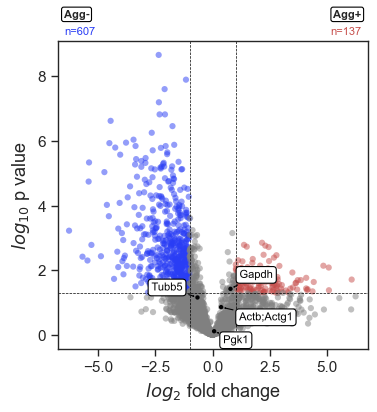

In [7]:
case_values = [{'sample': 'Agg+'}, {'sample': 'Agg-'}]

color_dict={'upregulated':"#C64D4A", 'downregulated': "#293DF5",'not_significant': "#FFFFFF6A"}

fig, ax = plt.subplots(figsize=(4, 4))
ax, volcano_df = scplt.plot_volcano(ax, pdata_6mo_snpc_norm,
                                    values=case_values,
                                    pval=0.05, return_df=True,
                                    fold_change_mode='mean', color=color_dict, label=[0,0])

scplt.mark_volcano(ax, volcano_df, label=['Gapdh','Tubb5','Actb;Actg1','Pgk1'], label_color="#030304")

ax.set_ylabel('$log_{10}$ p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# plt.show()
plt.savefig("MANUSCRIPT_revision/REVISION_Fig5_VOLCANO-directlfq-Housekeeping.svg", bbox_inches="tight", pad_inches=0.1)

In [13]:
volcano_df

,Genes,[{'sample': 'Agg+'}],[{'sample': 'Agg-'}],log2fc,p_value,test_statistic,-log10(p_value),significance_score,significance
Q9QUM9,Psma6,2.699874e+07,1.055356e+07,1.355162,0.020425,2.556728,1.689838,2.290004,upregulated
Q6P542,Abcf1,6.500183e+04,8.175694e+03,2.991067,0.036982,2.263458,1.432007,4.283228,upregulated
Q61781,Krt14,2.297299e+08,1.034705e+08,1.150720,0.022349,2.512910,1.650742,1.899542,upregulated
Q91VW3,Sh3bgrl3,1.326460e+06,3.096115e+05,2.099050,0.030740,2.355953,1.512299,3.174391,upregulated
Q9R1P0,Psma4,2.212191e+07,9.663399e+06,1.194874,0.016916,2.647844,1.771696,2.116952,upregulated
...,...,...,...,...,...,...,...,...,...
Q924W7,Dennd2b,6.164895e+05,0.000000e+00,NaN,0.106897,1.702383,0.971034,NaN,not comparable
Q9JK38,Gnpnat1,1.544254e+04,0.000000e+00,NaN,0.024838,2.461233,1.604876,NaN,not comparable
Q8R2U4,Ntmt1,1.065813e+04,0.000000e+00,NaN,0.160238,1.468467,0.795235,NaN,not comparable
Q8CGF1,Arhgap29,7.458405e+04,0.000000e+00,NaN,0.103445,1.720744,0.985290,NaN,not comparable


In [9]:
pdata_6mo_snpc_norm.export_layer("X", f"MANUSCRIPT_revision/REVISION_Fig6-mus6moSNpc_normalized.csv", transpose=True, var_names='Genes', obs_names='sample')

In [10]:
vol_list = volcano_df[volcano_df['significance'].isin(["upregulated", "downregulated","not comparable"])].Genes.to_list()

mus6mosnpc_sample = pd.read_csv("MANUSCRIPT_revision/REVISION_Fig6-mus6moSNpc_normalized.csv")
mus6mosnpc_sample_filtered = mus6mosnpc_sample[mus6mosnpc_sample['Genes'].isin(vol_list)].copy()

values=['Agg+','Agg-']
mus6mosnpc_sample_filtered = mus6mosnpc_sample_filtered.filter(regex='Agg+|Agg-|^Genes$')

# map significance from df_YHC onto the filtered df via Genes
sig_map = volcano_df.set_index('Genes')['significance']
mus6mosnpc_sample_filtered['significance'] = mus6mosnpc_sample_filtered['Genes'].map(sig_map)

# sort columns, keeping the first column first and significance last
first_col = mus6mosnpc_sample_filtered.columns[0]
other_cols = sorted(c for c in mus6mosnpc_sample_filtered.columns if c not in [first_col, 'significance'])
mus6mosnpc_sample_filtered = mus6mosnpc_sample_filtered[[first_col] + other_cols + ['significance']]

mus6mosnpc_sample_filtered.to_csv("MANUSCRIPT_revision/REVISION_Fig6-mus6moSNpc_volcano-only.csv", index=False)

     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=2.89e+05). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: Agg+ vs Agg-
   🔸 Group sizes: 12 vs 7 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 P-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 104 proteins were not comparable (zero or NaN mean in one group).
     ✅ DE complete. Results stored in:
       • .stats["Agg+ vs Agg-"]
       • Columns: log2fc, p_value, significance, etc.
       • Upregulated: 137 | Downregulated: 607 | Not significant: 1502 | Not comparable: 104


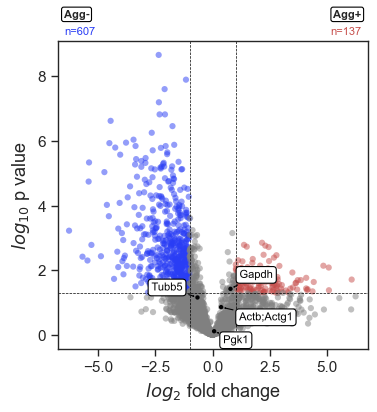

In [6]:
case_values = [{'sample': 'Agg+'}, {'sample': 'Agg-'}]

color_dict={'upregulated':"#C64D4A", 'downregulated': "#293DF5",'not_significant': "#FFFFFF6A"}

fig, ax = plt.subplots(figsize=(4, 4))
ax, volcano_df = scplt.plot_volcano(ax, pdata_6mo_snpc_norm,
                                    values=case_values,
                                    pval=0.05, return_df=True,
                                    fold_change_mode='mean', color=color_dict, label=[0,0])

scplt.mark_volcano(ax, volcano_df, label=['Gapdh','Tubb5','Actb;Actg1','Pgk1','Sqstm1'], label_color="#030304")

ax.set_ylabel('$log_{10}$ p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxpl

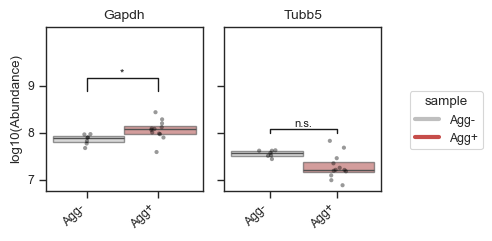

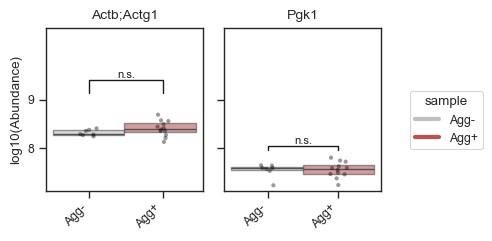

In [21]:

scplt.plot_abundance_boxgrid(pdata=pdata_6mo_snpc_norm, namelist=['Gapdh','Tubb5'], classes='sample', palette=agg_color, sig_pairs=True, figsize=(2,2.5), sig_kwargs={"fontsize":8}, log_scale=True)
plt.savefig("MANUSCRIPT_revision/REVISION_Fig5_ABUNDANCE-GapdhTubb5.svg", bbox_inches="tight", pad_inches=0.1)

scplt.plot_abundance_boxgrid(pdata=pdata_6mo_snpc_norm, namelist=['Actb;Actg1','Pgk1'], classes='sample', palette=agg_color, sig_pairs=True, figsize=(2,2.5), sig_kwargs={"fontsize":8}, log_scale=True)
plt.savefig("MANUSCRIPT_revision/REVISION_Fig5_ABUNDANCE-ActbPgk1.svg", bbox_inches="tight", pad_inches=0.1)


     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=2.89e+05). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: [{'sample': 'Agg+'}] vs [{'sample': 'Agg-'}]
   🔸 Group sizes: 12 vs 7 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 Adj p-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 104 proteins were not comparable (zero or NaN mean in one group).
     ✅ DE complete. Results stored in:
       • .stats["[{'sample': 'Agg+'}] vs [{'sample': 'Agg-'}]"]
       • Columns: log2fc, p_value, adj_p_value, significance, etc.
       • Upregulated: 25 | Downregulated: 391 | Not significant: 1830


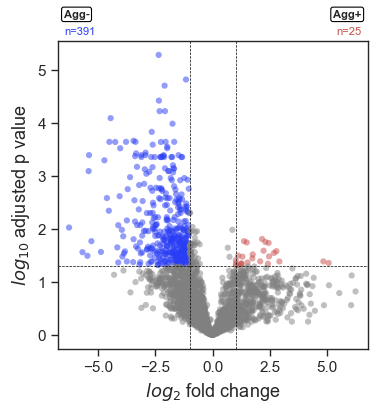

In [ ]:
# with ADJUSTED P VALUE
 
case_values = [{'sample': 'Agg+'}, {'sample': 'Agg-'}]

color_dict={'upregulated':"#C64D4A", 'downregulated': "#293DF5",'not_significant': "#FFFFFF6A"}

fig, ax = plt.subplots(figsize=(4, 4))
ax, volcano_df = scplt.plot_volcano(ax, pdata_6mo_snpc_norm,
                                    values=case_values,
                                    pval=0.05, return_df=True, correct_fdr=True,
                                    fold_change_mode='mean', color=color_dict, label=[0,0])

ax.set_ylabel('$log_{10}$ adjusted p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# plt.show()
plt.savefig("MANUSCRIPT_revision/REVISION_Fig5_VOLCANO-adjP.svg", bbox_inches="tight", pad_inches=0.1)
volcano_df.to_csv("MANUSCRIPT_revision/MANUSCRIPT_Fig5_DE-directlfq-adjP.csv")

In [7]:
def extract_gene_group(volcano_df, prefixes, top_n=5):
    """
    prefixes: list of lowercase prefixes, e.g. ['atp5']
    """
    mask_prefix = volcano_df["Genes"].str.lower().apply(
        lambda g: any(g.startswith(p) for p in prefixes)
    )
    sig_mask = (volcano_df["significance"] == 'upregulated') | \
               (volcano_df["significance"] == 'downregulated')

    gene_list = volcano_df.loc[mask_prefix & sig_mask, "Genes"].unique().tolist()

    if len(gene_list) == 0:
        return [], [], []

    top = (
        volcano_df[volcano_df["Genes"].isin(gene_list)]
        .sort_values("significance_score", ascending=True)
        .head(top_n)["Genes"]
        .tolist()
    )
    others = [g for g in gene_list if g not in top]

    return gene_list, top, others

rpl_list:  29
rps_list:  21
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=2.89e+05). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: [{'sample': 'Agg+'}] vs [{'sample': 'Agg-'}]
   🔸 Group sizes: 12 vs 7 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 Adj p-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 104 proteins were not comparable (zero or NaN mean in one group).
     ✅ DE complete. Results stored in:
       • .stats["[{'sample': 'Agg+'}] vs [{'sample': 'Agg-'}]"]
       • Columns: log2fc, p_value, adj_p_value, significance, etc.
       • Upregulated: 25 | Downregulated: 391 | Not significant: 1830


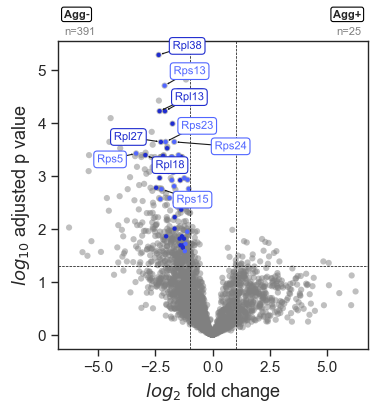

In [28]:
## RPL/RPS
rpl_list, rpl_top5, rpl_others = extract_gene_group(volcano_df, prefixes=["rpl"])
rps_list, rps_top5, rps_others = extract_gene_group(volcano_df, prefixes=["rps"])

print("rpl_list: ", len(rpl_list))
print("rps_list: ", len(rps_list))

case_values = [{'sample': 'Agg+'}, {'sample': 'Agg-'}]

color_dict={'upregulated':"#C64D4A", 'downregulated': "#293DF5",'not_significant': "#FFFFFF6A"}
rps_dict={'downregulated': '#5166FF'}
rpl_dict={'downregulated': '#1F2CCF'}

fig, ax = plt.subplots(figsize=(4, 4))
ax, volcano_df = scplt.plot_volcano(ax, pdata_6mo_snpc_norm,
                                    values=case_values,
                                    threshold=0.05, return_df=True, correct_fdr=True,
                                    fold_change_mode='mean', no_marks=True)

texts = []
ax, t = scplt.mark_volcano(ax, volcano_df, label=rpl_top5, label_color='#1F2CCF',return_texts=True)
texts.extend(t)
ax, t = scplt.mark_volcano_by_significance(ax, volcano_df, label=rps_top5, color=rps_dict,return_texts=True)
texts.extend(t)
scplt.mark_volcano_by_significance(ax, volcano_df, label=rpl_others, color=rpl_dict, show_names=False)
scplt.mark_volcano_by_significance(ax, volcano_df, label=rps_others, color=rps_dict, show_names=False)

scplt.volcano_adjust_and_outline_texts(texts, expand=(2,2))

ax.set_ylabel('$log_{10}$ adjusted p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# plt.show()
plt.savefig("MANUSCRIPT_revision/REVISION_Fig5_VOLCANO-directlfq-RplRps.svg", bbox_inches="tight", pad_inches=0.1)

proteasome_list:  3
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=2.89e+05). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: [{'sample': 'Agg+'}] vs [{'sample': 'Agg-'}]
   🔸 Group sizes: 12 vs 7 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 Adj p-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 104 proteins were not comparable (zero or NaN mean in one group).
     ✅ DE complete. Results stored in:
       • .stats["[{'sample': 'Agg+'}] vs [{'sample': 'Agg-'}]"]
       • Columns: log2fc, p_value, adj_p_value, significance, etc.
       • Upregulated: 25 | Downregulated: 391 | Not significant: 1830


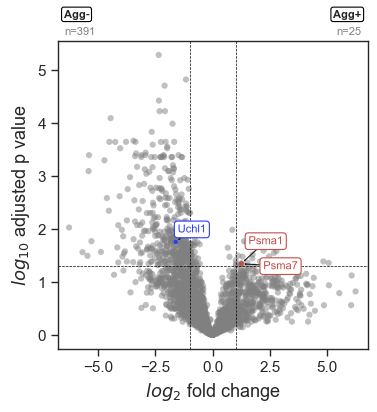

In [29]:
## Proteasome
proteasome_list, proteasome_top5, proteasome_others = extract_gene_group(volcano_df, prefixes=["psm"])
proteasome_list.append('Uchl1')

print("proteasome_list: ", len(proteasome_list))

case_values = [{'sample': 'Agg+'}, {'sample': 'Agg-'}]

color_dict={'upregulated':"#C64D4A", 'downregulated': "#293DF5",'not_significant': "#FFFFFF6A"}

fig, ax = plt.subplots(figsize=(4, 4))
ax, volcano_df = scplt.plot_volcano(ax, pdata_6mo_snpc_norm,
                                    values=case_values,
                                    threshold=0.05, return_df=True, correct_fdr=True,
                                    fold_change_mode='mean', no_marks=True)

texts = []
ax, t = scplt.mark_volcano_by_significance(ax, volcano_df, label=proteasome_list, color=color_dict, return_texts=True)
texts.extend(t)
scplt.volcano_adjust_and_outline_texts(texts, expand=(2, 2))
# scplt.mark_volcano_by_significance(ax, volcano_df, label=proteasome_top5, color=color_dict)
# scplt.mark_volcano_by_significance(ax, volcano_df, label=proteasome_others, color=color_dict, show_names=False)

ax.set_ylabel('$log_{10}$ adjusted p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

plt.savefig("MANUSCRIPT_revision/REVISION_Fig5_VOLCANO-directlfq-Proteasome.svg", bbox_inches="tight", pad_inches=0.1)

     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=2.89e+05). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: [{'sample': 'Agg+'}] vs [{'sample': 'Agg-'}]
   🔸 Group sizes: 12 vs 7 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 Adj p-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 104 proteins were not comparable (zero or NaN mean in one group).
     ✅ DE complete. Results stored in:
       • .stats["[{'sample': 'Agg+'}] vs [{'sample': 'Agg-'}]"]
       • Columns: log2fc, p_value, adj_p_value, significance, etc.
       • Upregulated: 25 | Downregulated: 391 | Not significant: 1830


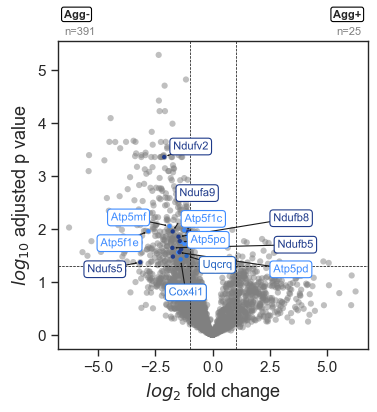

In [30]:
## Mitochondria

mito_groups = {
    "complex5":   ["atp5"],
    "complex4":   ["cox"],
    "complex1":   ["nduf"],
    "complex2":   ["sdh"],
    "complex3":   ["uqcr"],
    "mito_other": ["cyc1", "cycs", "pgk", "vdac"],
}

mito_results = {}

for group_name, prefixes in mito_groups.items():
    gene_list, top5, others = extract_gene_group(volcano_df, prefixes)
    mito_results[group_name] = {
        "list": gene_list,
        "top5": top5,
        "others": others,
    }

mito_color_dict = {
    "complex1": {     # NDUF*
        "upregulated":   "#D64545",   # strong red
        "downregulated": "#1E3A8A",   # deep indigo blue
    },
    "complex2": {     # SDH*
        "upregulated":   "#C03636",   # darker red
        "downregulated": "#1F4DA0",   # strong royal blue
    },
    "complex3": {     # UQCR*
        "upregulated":   "#B42E2E",   # deep cherry
        "downregulated": "#2665C2",   # vivid blue
    },
    "complex4": {     # COX*
        "upregulated":   "#A82828",   # wine red
        "downregulated": "#2D7AE6",   # bright azure
    },
    "complex5": {     # ATP5*
        "upregulated":   "#9E2020",   # maroon
        "downregulated": "#3D8BFF",   # clear blue
    },
    "mito_other": {
        "upregulated":   "#8C1A1A",   # dark brick red
        "downregulated": "#4C9CFF",   # lighter but still strong blue
    },
}

## Mitochondria, all together

case_values = [{'sample': 'Agg+'}, {'sample': 'Agg-'}]

color_dict={'upregulated':"#C64D4A", 'downregulated': "#293DF5",'not_significant': "#FFFFFF6A"}

fig, ax = plt.subplots(figsize=(4, 4))
ax, volcano_df = scplt.plot_volcano(ax, pdata_6mo_snpc_norm,
                                    values=case_values,
                                    threshold=0.05, return_df=True, correct_fdr=True,
                                    fold_change_mode='mean', no_marks=True)

texts = []
for group_name, d in mito_results.items():
    colors = mito_color_dict[group_name]

    if len(d["top5"]) > 0:
        # highlight top 5 (with names)
        ax, t = scplt.mark_volcano_by_significance(
            ax, volcano_df,
            label=d["top5"],
            color=colors,
            return_texts=True,
        )

        texts.extend(t)

    if len(d["others"]) > 0:
        # highlight the others (no names)
        scplt.mark_volcano_by_significance(
            ax, volcano_df,
            label=d["others"],
            color=colors,
            show_names=False,
        )

scplt.volcano_adjust_and_outline_texts(texts, expand=(2,2))

ax.set_ylabel('$log_{10}$ adjusted p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

plt.savefig("MANUSCRIPT_revision/REVISION_Fig5_VOLCANO-directlfq-MitoAll.svg", bbox_inches="tight", pad_inches=0.1)

### heatmap

     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=2.89e+05). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: Agg+ vs Agg-
   🔸 Group sizes: 12 vs 7 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 P-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 104 proteins were not comparable (zero or NaN mean in one group).
     ✅ DE complete. Results stored in:
       • .stats["Agg+ vs Agg-"]
       • Columns: log2fc, p_value, significance, etc.
       • Upregulated: 137 | Downregulated: 607 | Not significant: 1502 | Not comparable: 104


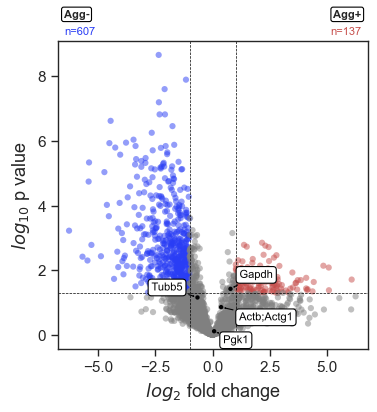

In [5]:
case_values = [{'sample': 'Agg+'}, {'sample': 'Agg-'}]

color_dict={'upregulated':"#C64D4A", 'downregulated': "#293DF5",'not_significant': "#FFFFFF6A"}

fig, ax = plt.subplots(figsize=(4, 4))
ax, volcano_df = scplt.plot_volcano(ax, pdata_6mo_snpc_norm,
                                    values=case_values,
                                    pval=0.05, return_df=True,
                                    fold_change_mode='mean', color=color_dict, label=[0,0])

scplt.mark_volcano(ax, volcano_df, label=['Gapdh','Tubb5','Actb;Actg1','Pgk1','Sqstm1'], label_color="#030304")

ax.set_ylabel('$log_{10}$ p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

In [6]:
def extract_gene_group(volcano_df, prefixes, top_n=5):
    """
    prefixes: list of lowercase prefixes, e.g. ['atp5']
    """
    mask_prefix = volcano_df["Genes"].str.lower().apply(
        lambda g: any(g.startswith(p) for p in prefixes)
    )
    sig_mask = (volcano_df["significance"] == 'upregulated') | \
               (volcano_df["significance"] == 'downregulated')

    gene_list = volcano_df.loc[mask_prefix & sig_mask, "Genes"].unique().tolist()

    if len(gene_list) == 0:
        return [], [], []

    top = (
        volcano_df[volcano_df["Genes"].isin(gene_list)]
        .sort_values("significance_score", ascending=True)
        .head(top_n)["Genes"]
        .tolist()
    )
    others = [g for g in gene_list if g not in top]

    return gene_list, top, others

rpl_list, rpl_top5, rpl_others = extract_gene_group(volcano_df, prefixes=["rpl"])
rps_list, rps_top5, rps_others = extract_gene_group(volcano_df, prefixes=["rps"])

proteasome_list, proteasome_top5, proteasome_others = extract_gene_group(volcano_df, prefixes=["psm"])
proteasome_list.append('Uchl1')

mito_groups = {
    "complex5":   ["atp5"],
    "complex4":   ["cox"],
    "complex1":   ["nduf"],
    "complex2":   ["sdh"],
    "complex3":   ["uqcr"],
    "mito_other": ["cyc1", "cycs", "pgk", "vdac"],
}

mito_results = {}
for group_name, prefixes in mito_groups.items():
    gene_list, top5, others = extract_gene_group(volcano_df, prefixes)
    mito_results[group_name] = {
        "list": gene_list,
        "top5": top5,
        "others": others,
    }

print(len(rpl_list))
print(len(rps_list))
print(len(proteasome_list))
for group_name, d in mito_results.items():
    print(len(d['list']))


protein_groups = {
    "Ribosome": rpl_list + rps_list, 
    "Proteasome": proteasome_list,
    "Mitochondria": [gene for d in mito_results.values() for gene in d["list"]]
    }

31
24
11
9
3
16
1
2
1


     ℹ️ [INFO] display_scale='zscore' (auto: upregulated/downregulated in significance_categories).
     ℹ️ [INFO] Dropping 646 unassigned feature(s) (show_unassigned=False).
     ⚠️ [WARN] Layer 'X' appears non-log (median=3.8e+05). Applying log2(x + 1.0) in memory for this heatmap only. To persist: `pdata.log_transform(layer='X', base=2)` then `layer='X_log2'`.


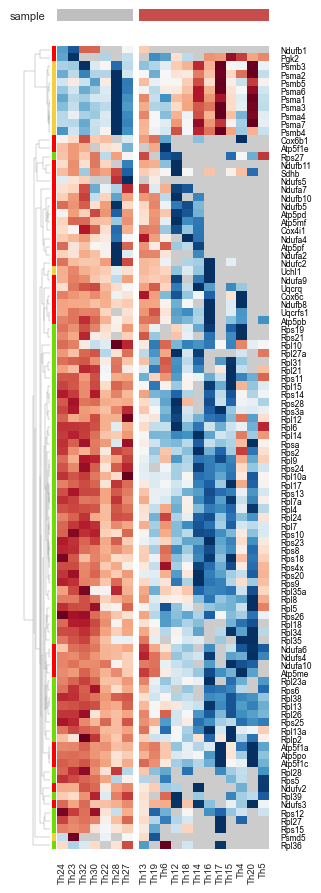

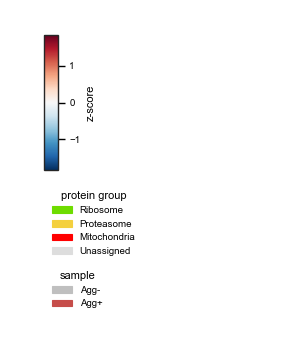

In [7]:
agg_color={
    "Agg+": "#C64D4A",
    "Agg-": "#BFBFBF"
}

fig, fig_legend = pdata_6mo_snpc_norm.plot_clustered_heatmap(
    classes=["sample"],
    stats_key="Agg+ vs Agg-",
    significance_categories=["upregulated", "downregulated"],  # default
    sort_by={"sample": ["Agg-", "Agg+"]},
    # optional annotation overlay:
    protein_groups=protein_groups,
    group_colors={"Ribosome": "#6EDC00", "Proteasome": "#F4D03F", "Mitochondria": "#FF0000",},
    header_colors=agg_color,
    show_unassigned=False,
    sample_label_col="sample_id",
    label_color="Black",
    # text_size=7,
    separate_legend=True,
    figsize=(3,10),
    dendrogram_linewidth=0.3
)

fig.savefig("MANUSCRIPT_revision/REVISION_Fig5_Heatmap.svg", bbox_inches="tight", pad_inches=0.1)
fig_legend.savefig("MANUSCRIPT_revision/REVISION_Fig5_Heatmap_legend.svg", bbox_inches="tight", pad_inches=0.1)

# ax_dendro = fig.axes[1]  # first non-header axes is the dendrogram
# for line in ax_dendro.get_lines():
#     line.set_linewidth(0.2)

In [33]:
fig.axes

[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >]

# Fig X - mouse (1mo/3mo/6mo cortex + snpc)

## pre-processing

In [2]:
pdata_mus1mo3mo6mo_diann_cortex_base = pAnnData.import_data(source_type='diann', report_file = 'data/2511_MusCORTEX-1mo-3mo-6mo-combined/report.parquet')
pdata_mus1mo3mo6mo_diann_snpc_base = pAnnData.import_data(source_type='diann', report_file = 'data/2511_MusSNPC-1mo-3mo-6mo-combined/report.parquet')

🧭 [USER] Importing data of type [diann]
      Auto-detecting '_' as delimiter from first filename.
     ⚠️ [WARN] 2 different filename formats detected. Proceeding with fallback `.obs` structure... (File Number, Parsing Type)
--------------------------
Starting import [DIA-NN]

Source file: data/2511_MusCORTEX-1mo-3mo-6mo-combined/report.parquet
Number of files: 80
Proteins: 9559
Peptides: 61557

     ℹ️ [INFO] Using sample-specific q-values for 'prot' significance annotation.
     ℹ️ [INFO] Using sample-specific q-values for 'pep' significance annotation.

ℹ️ RS matrix: (9559, 61557) (proteins × peptides), sparsity: 99.99%
   - Proteins with ≥2 *unique* linked peptides: 4777/9559
   - Peptides linked to ≥2 proteins: 10011/61557
   - Mean peptides per protein: 7.94
   - Mean proteins per peptide: 1.23
     ✅ [OK] pAnnData object is valid.
     ✅ [OK] Import complete. Use `print(pdata)` to view the object.
--------------------------
🧭 [USER] Importing data of type [diann]
      Auto-det

In [3]:
colnames = [
    'date',
    'gradient',
    'sample_id',
    'size',
    'confirmation',
    'thickness',
    'sample',
    'organism',
    'region',
    'well_position'
]

#### SNPC

pdata_mus1mo3mo6mo_diann_snpc = pdata_mus1mo3mo6mo_diann_snpc_base.filter_sample(condition='parsingType == "10-tokens"')
pdata_mus1mo3mo6mo_diann_snpc.summary = scutils.parse_filename_index(pdata_mus1mo3mo6mo_diann_snpc.summary, colnames)

pdata_mus1mo3mo6mo_processed_snpc = pdata_mus1mo3mo6mo_diann_snpc.filter_prot_significant()

pdata_mus1mo3mo6mo_processed_snpc = pdata_mus1mo3mo6mo_processed_snpc.filter_sample(condition='region == "snpc"')
pdata_mus1mo3mo6mo_processed_snpc.summary[["timepoint", "sample"]] = pdata_mus1mo3mo6mo_processed_snpc.summary["sample"].str.extract(r"(\d+mo)-(agg[YN])")
pdata_mus1mo3mo6mo_processed_snpc.summary["sample"] = pdata_mus1mo3mo6mo_processed_snpc.summary["sample"].map({"aggY": "Agg+", "aggN": "Agg-"})
pdata_mus1mo3mo6mo_processed_snpc.update_summary()
pdata_mus1mo3mo6mo_processed_snpc = pdata_mus1mo3mo6mo_processed_snpc.filter_sample(min_prot=1000)


🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: parsingType == "10-tokens"
     ℹ️ Auto-cleanup: Removed 1108 empty proteins (all-NaN or all-zero). Proteins: Q80WW9, Q99MS8, Q68FF7, Q68FF7-2, Q08509, Q6PB90, Q91XZ4, Q6A0D4, Q61249, Q8BGV8, ...
    → Samples kept: 96, Samples dropped: 4
    → Proteins kept: 7235

🔄 [UPDATE] Updating summary [sync_back]: pushed edits from `.summary` to `.obs`.
      Columns updated: sample, well_position, date, confirmation, sample_id, size, thickness, organism, gradient, region.
🧭 [USER] Filtering proteins [Significance|File-mode]:
     ℹ️ [INFO] No group provided. Defaulting to sample-level significance filtering.
    Returning a copy of protein data based on significance thresholds:
     🔸 Files requested: All
     🔸 FDR threshold: 0.01
     🔸 Logic: any (protein must be significant in ≥1 file(s))
    → Proteins kept: 6414, Proteins dropped: 821
     ✅ [OK] RS matrix filtered: 6414 prot

In [48]:
pd.DataFrame(pdata_mus1mo3mo6mo_processed_snpc.summary.groupby(['timepoint','sample']).count())

[summary] ⚠️ Warning: .summary has been modified. Run `(pdata).update_summary()` to sync changes back to .obs.


File  parsingType  protein_quant  protein_count  \
timepoint sample                                                    
1mo       Agg+      12           12             12             12   
          Agg-      11           11             11             11   
3mo       Agg+      20           20             20             20   
          Agg-       8            8              8              8   
6mo       Agg+      12           12             12             12   
          Agg-       8            8              8              8   

                  protein_abundance_sum  date  gradient  sample_id  size  \
timepoint sample                                                           
1mo       Agg+                       12    12        12         12    12   
          Agg-                       11    11        11         11    11   
3mo       Agg+                       20    20        20         20    20   
          Agg-                        8     8         8          8     8   
6mo       Agg+                       12    12        12         12    12   
          Agg-                        8     8         8          8     8   

                  confirmation  thickness  organism  region  well_position  \
timepoint sample                                                             
1mo       Agg+              12         12        12      12             12   
          Agg-              11         11        11      11             11   
3mo       Agg+              20         20        20      20             20   
          Agg-               8          8         8       8              8   
6mo       Agg+              12         12        12      12             12   
          Agg-               8          8         8       8              8   

                  peptide_quant  peptide_count  peptide_abundance_sum  \
timepoint sample                                                        
1mo       Agg+               12             12                     12   
          Agg-               11             11                     11   
3mo       Agg+               20             20                     20   
          Agg-                8              8                      8   
6mo       Agg+               12             12                     12   
          Agg-                8              8                      8   

                  unique_pep2_protein_count  
timepoint sample                             
1mo       Agg+                           12  
          Agg-                           11  
3mo       Agg+                           20  
          Agg-                            8  
6mo       Agg+                           12  
          Agg-                            8

In [7]:
pdata_3mo_snpc_filter = pdata_mus1mo3mo6mo_processed_snpc.filter_sample(condition='timepoint == "3mo"')
pdata_3mo_snpc_filter = pdata_3mo_snpc_filter.filter_prot_found(min_ratio=0.4, group=['sample'],match_any=True)
pdata_3mo_snpc_filter = pdata_3mo_snpc_filter.filter_prot(valid_genes=True, unique_profiles=True)
pdata_3mo_snpc_filter = pdata_3mo_snpc_filter.filter_sample(min_prot=1000)
# pdata_6mo_snpc.impute(method='min', min_scale=0.2)

pdata_3mo_snpc_norm = pdata_3mo_snpc_filter.copy()
pdata_3mo_snpc_norm.normalize(method='directlfq')

pdata_3mo_snpc_norm.summary['sample'].value_counts()

g:\Users\marion\miniconda3\envs\scpviz_dev\Lib\site-packages\multiprocess\pool.py:268: ResourceWarning: unclosed running multiprocessing pool <multiprocess.pool.Pool state=RUN pool_size=16>
  _warn(f"unclosed running multiprocessing pool {self!r}",


🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: timepoint == "3mo"
     ℹ️ Auto-cleanup: Removed 1255 empty proteins (all-NaN or all-zero). Proteins: Q8BIJ7, Q61941, O35855, Q9DCD2, Q8BTI9, Q8R0G9, Q91YR5, Q99JR8, Q99JR8-2, Q91X52, ...
    → Samples kept: 28, Samples dropped: 43
    → Proteins kept: 5158

🧭 [USER] Filtering proteins [Found|Group-mode|ANY]:
     ℹ️ [INFO] Found matching groups(s): ['Agg+', 'Agg-']. Automatically annotating detection by group values.
    Returning a copy of protein data based on detection thresholds:
     🔸 Groups requested: ['Agg+', 'Agg-']
     🔸 Minimum ratio: 0.4
     🔸 Logic: any (protein must be detected in ≥1 group(s))
    → Proteins kept: 3003, Proteins dropped: 2155
     ✅ [OK] RS matrix filtered: 3003 proteins, 35422 peptides retained.

🧭 [USER] Filtering proteins [valid genes, unique profiles]:
    Returning a copy of protein data with the following filters applied:
     🔸 valid

2026-09-10 15:00:21,925 - directlfq.lfq_manager - INFO - Starting directLFQ analysis.
2026-09-10 15:00:22,072 - directlfq.lfq_manager - INFO - Performing sample normalization.
2026-09-10 15:00:22,074 - directlfq.normalization - INFO - to few values for normalization without missing values. Including missing values
2026-09-10 15:00:22,197 - directlfq.lfq_manager - INFO - Estimating lfq intensities.
2026-09-10 15:00:22,199 - directlfq.protein_intensity_estimation - INFO - 2487 lfq-groups total
2026-09-10 15:00:23,060 - directlfq.protein_intensity_estimation - INFO - using 16 processes
2026-09-10 15:00:31,052 - directlfq.lfq_manager - INFO - Could not add additional columns to protein table, printing without additional columns.
2026-09-10 15:00:31,053 - directlfq.lfq_manager - INFO - Writing results files.
2026-09-10 15:00:31,325 - directlfq.lfq_manager - INFO - Analysis finished!


     ℹ️ Set protein data to layer X_norm_directlfq.
     ✅ directlfq normalization complete. Results are stored in layer 'X_norm_directlfq'.
          ⚠️ Downstream imputation should be performed with the flag `use_zeros_as_nan` set to True due to directlfq output format returning NaNs as 0s.


sample
Agg+    14
Agg-     8
Name: count, dtype: int64

In [8]:
pdata_6mo_snpc_filter = pdata_mus1mo3mo6mo_processed_snpc.filter_sample(condition='timepoint == "6mo"')
pdata_6mo_snpc_filter = pdata_6mo_snpc_filter.filter_prot_found(min_ratio=0.4, group=['sample'],match_any=True)
pdata_6mo_snpc_filter = pdata_6mo_snpc_filter.filter_prot(valid_genes=True, unique_profiles=True)
pdata_6mo_snpc_filter = pdata_6mo_snpc_filter.filter_sample(min_prot=1000)
# pdata_6mo_snpc.impute(method='min', min_scale=0.2)

pdata_6mo_snpc_norm = pdata_6mo_snpc_filter.copy()
pdata_6mo_snpc_norm.normalize(method='directlfq')
# pdata_6mo_snpc_norm = pdata_6mo_snpc_norm.filter_sample(min_prot=1000)

pdata_6mo_snpc_norm.summary['sample'].value_counts()

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: timepoint == "6mo"
     ℹ️ Auto-cleanup: Removed 1299 empty proteins (all-NaN or all-zero). Proteins: Q9D061, Q91ZM2, Q91ZM2-2, Q91ZM2-3, Q91ZM2-4, Q91ZM2-6, Q7M753, Q14BI2, Q8R0G9, Q91YR5, ...
    → Samples kept: 20, Samples dropped: 51
    → Proteins kept: 5114

🧭 [USER] Filtering proteins [Found|Group-mode|ANY]:
     ℹ️ [INFO] Found matching groups(s): ['Agg-', 'Agg+']. Automatically annotating detection by group values.
    Returning a copy of protein data based on detection thresholds:
     🔸 Groups requested: ['Agg-', 'Agg+']
     🔸 Minimum ratio: 0.4
     🔸 Logic: any (protein must be detected in ≥1 group(s))
    → Proteins kept: 2957, Proteins dropped: 2157
     ✅ [OK] RS matrix filtered: 2957 proteins, 34259 peptides retained.

🧭 [USER] Filtering proteins [valid genes, unique profiles]:
    Returning a copy of protein data with the following filters applied:
     🔸

2026-09-10 15:02:23,903 - directlfq.lfq_manager - INFO - Starting directLFQ analysis.
2026-09-10 15:02:24,039 - directlfq.lfq_manager - INFO - Performing sample normalization.
2026-09-10 15:02:24,049 - directlfq.lfq_manager - INFO - Estimating lfq intensities.
2026-09-10 15:02:24,051 - directlfq.protein_intensity_estimation - INFO - 2471 lfq-groups total
2026-09-10 15:02:24,866 - directlfq.protein_intensity_estimation - INFO - using 16 processes
2026-09-10 15:02:32,868 - directlfq.lfq_manager - INFO - Could not add additional columns to protein table, printing without additional columns.
2026-09-10 15:02:32,868 - directlfq.lfq_manager - INFO - Writing results files.
2026-09-10 15:02:33,116 - directlfq.lfq_manager - INFO - Analysis finished!


     ℹ️ Set protein data to layer X_norm_directlfq.
     ✅ directlfq normalization complete. Results are stored in layer 'X_norm_directlfq'.
          ⚠️ Downstream imputation should be performed with the flag `use_zeros_as_nan` set to True due to directlfq output format returning NaNs as 0s.


sample
Agg+    12
Agg-     7
Name: count, dtype: int64

In [49]:
colnames = [
    'date',
    'gradient',
    'sample_id',
    'size',
    'confirmation',
    'thickness',
    'sample',
    'organism',
    'region',
    'well_position'
]

#### cortex
pdata_mus1mo3mo6mo_diann_cortex = pdata_mus1mo3mo6mo_diann_cortex_base.filter_sample(condition='parsingType == "10-tokens"')
pdata_mus1mo3mo6mo_diann_cortex.summary = scutils.parse_filename_index(pdata_mus1mo3mo6mo_diann_cortex.summary, colnames)

pdata_mus1mo3mo6mo_processed_cortex = pdata_mus1mo3mo6mo_diann_cortex.filter_prot_significant()

pdata_mus1mo3mo6mo_processed_cortex = pdata_mus1mo3mo6mo_processed_cortex.filter_sample(condition='region == "Cortex"')
pdata_mus1mo3mo6mo_processed_cortex.summary[["timepoint", "sample"]] = pdata_mus1mo3mo6mo_processed_cortex.summary["sample"].str.extract(r"(\d+mo)-(agg[YN])")
pdata_mus1mo3mo6mo_processed_cortex.summary["sample"] = pdata_mus1mo3mo6mo_processed_cortex.summary["sample"].map({"aggY": "Agg+", "aggN": "Agg-"})
pdata_mus1mo3mo6mo_processed_cortex.update_summary()
pdata_mus1mo3mo6mo_processed_cortex = pdata_mus1mo3mo6mo_processed_cortex.filter_sample(min_prot=1000)

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: parsingType == "10-tokens"
     ℹ️ Auto-cleanup: Removed 512 empty proteins (all-NaN or all-zero). Proteins: Q68FF7, Q68FF7-2, Q6P9J5, J9SQF3, J9SQF3-10, J9SQF3-11, J9SQF3-12, J9SQF3-2, J9SQF3-3, J9SQF3-4, ...
    → Samples kept: 76, Samples dropped: 4
    → Proteins kept: 9047

🔄 [UPDATE] Updating summary [sync_back]: pushed edits from `.summary` to `.obs`.
      Columns updated: date, organism, sample_id, well_position, confirmation, region, sample, size, gradient, thickness.
🧭 [USER] Filtering proteins [Significance|File-mode]:
     ℹ️ [INFO] No group provided. Defaulting to sample-level significance filtering.
    Returning a copy of protein data based on significance thresholds:
     🔸 Files requested: All
     🔸 FDR threshold: 0.01
     🔸 Logic: any (protein must be significant in ≥1 file(s))
    → Proteins kept: 8293, Proteins dropped: 754
     ✅ [OK] RS matrix filte

In [50]:
pdata_6mo_cortex_filter = pdata_mus1mo3mo6mo_processed_cortex.filter_sample(condition='timepoint == "6mo"')
pdata_6mo_cortex_filter = pdata_6mo_cortex_filter.filter_prot_found(min_ratio=0.4, group=['sample'],match_any=True)
pdata_6mo_cortex_filter = pdata_6mo_cortex_filter.filter_prot(valid_genes=True, unique_profiles=True)
pdata_6mo_cortex_filter = pdata_6mo_cortex_filter.filter_sample(min_prot=1000)
# pdata_6mo_snpc.impute(method='min', min_scale=0.2)

pdata_6mo_cortex_norm = pdata_6mo_cortex_filter.copy()
pdata_6mo_cortex_norm.normalize(method='directlfq')
# pdata_6mo_snpc_norm = pdata_6mo_snpc_norm.filter_sample(min_prot=1000)

pdata_6mo_cortex_norm.summary['sample'].value_counts()

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: timepoint == "6mo"
     ℹ️ Auto-cleanup: Removed 645 empty proteins (all-NaN or all-zero). Proteins: A2A6Q5-2, O70423, Q61249, Q99N57, Q99N57-2, Q5NBY9, P58137, P97449, Q8R3I2, Q8R3I2-2, ...
    → Samples kept: 23, Samples dropped: 44
    → Proteins kept: 7648

🧭 [USER] Filtering proteins [Found|Group-mode|ANY]:
     ℹ️ [INFO] Found matching groups(s): ['Agg-', 'Agg+']. Automatically annotating detection by group values.
    Returning a copy of protein data based on detection thresholds:
     🔸 Groups requested: ['Agg-', 'Agg+']
     🔸 Minimum ratio: 0.4
     🔸 Logic: any (protein must be detected in ≥1 group(s))
    → Proteins kept: 5378, Proteins dropped: 2270
     ✅ [OK] RS matrix filtered: 5378 proteins, 54259 peptides retained.

🧭 [USER] Filtering proteins [valid genes, unique profiles]:
    Returning a copy of protein data with the following filters applied:
     🔸 va

2026-08-03 22:07:29,565 - directlfq.lfq_manager - INFO - Starting directLFQ analysis.
2026-08-03 22:07:29,981 - directlfq.lfq_manager - INFO - Performing sample normalization.
2026-08-03 22:07:30,013 - directlfq.lfq_manager - INFO - Estimating lfq intensities.
2026-08-03 22:07:30,018 - directlfq.protein_intensity_estimation - INFO - 4393 lfq-groups total
2026-08-03 22:07:32,681 - directlfq.protein_intensity_estimation - INFO - using 12 processes
2026-08-03 22:07:53,151 - directlfq.lfq_manager - INFO - Could not add additional columns to protein table, printing without additional columns.
2026-08-03 22:07:53,152 - directlfq.lfq_manager - INFO - Writing results files.
2026-08-03 22:07:54,284 - directlfq.lfq_manager - INFO - Analysis finished!


     ℹ️ Set protein data to layer X_norm_directlfq.
     ✅ directlfq normalization complete. Results are stored in layer 'X_norm_directlfq'.
          ⚠️ Downstream imputation should be performed with the flag `use_zeros_as_nan` set to True due to directlfq output format returning NaNs as 0s.


sample
Agg+    12
Agg-    11
Name: count, dtype: int64

In [11]:
pdata_1mo_cortex_filter = pdata_mus1mo3mo6mo_processed_cortex.filter_sample(condition='timepoint == "1mo"')
pdata_1mo_cortex_filter = pdata_1mo_cortex_filter.filter_prot_found(min_ratio=0.4, group=['sample'],match_any=True)
pdata_1mo_cortex_filter = pdata_1mo_cortex_filter.filter_prot(valid_genes=True, unique_profiles=True)
pdata_1mo_cortex_filter = pdata_1mo_cortex_filter.filter_sample(min_prot=1000)
# pdata_6mo_snpc.impute(method='min', min_scale=0.2)

pdata_1mo_cortex_norm = pdata_1mo_cortex_filter.copy()
pdata_1mo_cortex_norm.normalize(method='directlfq')
# pdata_6mo_snpc_norm = pdata_6mo_snpc_norm.filter_sample(min_prot=1000)

pdata_1mo_cortex_norm.summary['sample'].value_counts()

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: timepoint == "1mo"
     ℹ️ Auto-cleanup: Removed 269 empty proteins (all-NaN or all-zero). Proteins: O70423, Q9CXK9, Q7TQN3, Q8R3I2, Q8R3I2-2, Q8R3I2-3, Q8BQ48, Q8BQ48-2, Q8BQ48-5, Q8BQ48-3, ...
    → Samples kept: 22, Samples dropped: 45
    → Proteins kept: 8024



🧭 [USER] Filtering proteins [Found|Group-mode|ANY]:
     ℹ️ [INFO] Found matching groups(s): ['Agg-', 'Agg+']. Automatically annotating detection by group values.
    Returning a copy of protein data based on detection thresholds:
     🔸 Groups requested: ['Agg-', 'Agg+']
     🔸 Minimum ratio: 0.4
     🔸 Logic: any (protein must be detected in ≥1 group(s))
    → Proteins kept: 4181, Proteins dropped: 3843
     ✅ [OK] RS matrix filtered: 4181 proteins, 49530 peptides retained.

🧭 [USER] Filtering proteins [valid genes, unique profiles]:
    Returning a copy of protein data with the following filters applied:
     🔸 valid_genes — removed 7 proteins with invalid gene names
     🔸 valid_genes — resolved 511 duplicate gene names by appending numeric suffixes
     🔸 unique_profiles — removed 713 duplicate and 0 empty abundance profiles (713 total)
    → Proteins kept: 3461
    → Peptides kept (linked): 49518
     ✅ [OK] RS matrix filtered: 3461 proteins, 49518 peptides retained.
🧭 [USER] Fil

2026-07-29 14:23:30,551 - directlfq.lfq_manager - INFO - Starting directLFQ analysis.
2026-07-29 14:23:31,106 - directlfq.lfq_manager - INFO - Performing sample normalization.
2026-07-29 14:23:31,112 - directlfq.normalization - INFO - to few values for normalization without missing values. Including missing values
2026-07-29 14:23:31,492 - directlfq.lfq_manager - INFO - Estimating lfq intensities.
2026-07-29 14:23:31,497 - directlfq.protein_intensity_estimation - INFO - 3461 lfq-groups total
2026-07-29 14:23:33,649 - directlfq.protein_intensity_estimation - INFO - using 12 processes
2026-07-29 14:23:53,825 - directlfq.lfq_manager - INFO - Could not add additional columns to protein table, printing without additional columns.
2026-07-29 14:23:53,826 - directlfq.lfq_manager - INFO - Writing results files.
2026-07-29 14:23:54,914 - directlfq.lfq_manager - INFO - Analysis finished!


     ℹ️ Set protein data to layer X_norm_directlfq.
     ✅ directlfq normalization complete. Results are stored in layer 'X_norm_directlfq'.
          ⚠️ Downstream imputation should be performed with the flag `use_zeros_as_nan` set to True due to directlfq output format returning NaNs as 0s.


sample
Agg+    12
Agg-    10
Name: count, dtype: int64

### plots

In [5]:
agg_color={
    "Agg+": "#C64D4A",
    "Agg-": "#BFBFBF"
}

### abundance exploration

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: timepoint == "3mo"
     ℹ️ Auto-cleanup: Removed 1255 empty proteins (all-NaN or all-zero). Proteins: Q8BIJ7, Q61941, O35855, Q9DCD2, Q8BTI9, Q8R0G9, Q91YR5, Q99JR8, Q99JR8-2, Q91X52, ...
    → Samples kept: 28, Samples dropped: 43
    → Proteins kept: 5158

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: timepoint == "6mo"
     ℹ️ Auto-cleanup: Removed 1299 empty proteins (all-NaN or all-zero). Proteins: Q9D061, Q91ZM2, Q91ZM2-2, Q91ZM2-3, Q91ZM2-4, Q91ZM2-6, Q7M753, Q14BI2, Q8R0G9, Q91YR5, ...
    → Samples kept: 20, Samples dropped: 51
    → Proteins kept: 5114

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: timepoint == "3mo"
     ℹ️ Auto-cleanup: Removed 1496 empty proteins (all-NaN or all-zero). Proteins: Q80WW9, A2A6Q5-2, Q3ULF4, Q6ZQ89

c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxpl

     ⚠️ [WARN] Psmd10: group 'Agg-' has no detectable abundance ('ND').


c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxpl

     ⚠️ [WARN] Psmd10: skipping comparison 'Agg+' vs 'Agg-' — ND group(s): ['Agg-'].
     ⚠️ [WARN] Psmb8: skipping comparison 'Agg+' vs 'Agg-' — need ≥2 valid replicates per group (n1=6, n2=1).
1
6mo snpc


...

     ⚠️ [WARN] Rpl7l1: skipping comparison 'Agg+' vs 'Agg-' — ND group(s): ['Agg-'].
     ⚠️ [WARN] Rpl37a: skipping comparison 'Agg+' vs 'Agg-' — need ≥2 valid replicates per group (n1=8, n2=1).
     ⚠️ [WARN] Cdk1: skipping comparison 'Agg+' vs 'Agg-' — need ≥2 valid replicates per group (n1=7, n2=1).
     ⚠️ [WARN] Cdk2: skipping comparison 'Agg+' vs 'Agg-' — ND group(s): ['Agg-'].
     ⚠️ [WARN] Marcksl1: skipping comparison 'Agg+' vs 'Agg-' — ND group(s): ['Agg-'].
     ⚠️ [WARN] Tgm2: skipping comparison 'Agg+' vs 'Agg-' — need ≥2 valid replicates per group (n1=3, n2=1).
1
6mo snpc


c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxpl

     ⚠️ [WARN] Marcksl1: group 'Agg-' has no detectable abundance ('ND').
     ⚠️ [WARN] Tgm2: group 'Agg-' has no detectable abundance ('ND').


c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxpl

     ⚠️ [WARN] Rpl7l1: skipping comparison 'Agg-' vs 'Agg+' — need ≥2 valid replicates per group (n1=1, n2=11).
     ⚠️ [WARN] Rpl37a: skipping comparison 'Agg-' vs 'Agg+' — need ≥2 valid replicates per group (n1=1, n2=12).
     ⚠️ [WARN] Psmd10: skipping comparison 'Agg-' vs 'Agg+' — need ≥2 valid replicates per group (n1=1, n2=11).
     ⚠️ [WARN] Cdk2: skipping comparison 'Agg-' vs 'Agg+' — need ≥2 valid replicates per group (n1=1, n2=12).
     ⚠️ [WARN] Hspb8: skipping comparison 'Agg-' vs 'Agg+' — need ≥2 valid replicates per group (n1=1, n2=8).
     ⚠️ [WARN] Marcksl1: skipping comparison 'Agg-' vs 'Agg+' — ND group(s): ['Agg-'].
     ⚠️ [WARN] Tgm2: skipping comparison 'Agg-' vs 'Agg+' — ND group(s): ['Agg-'].


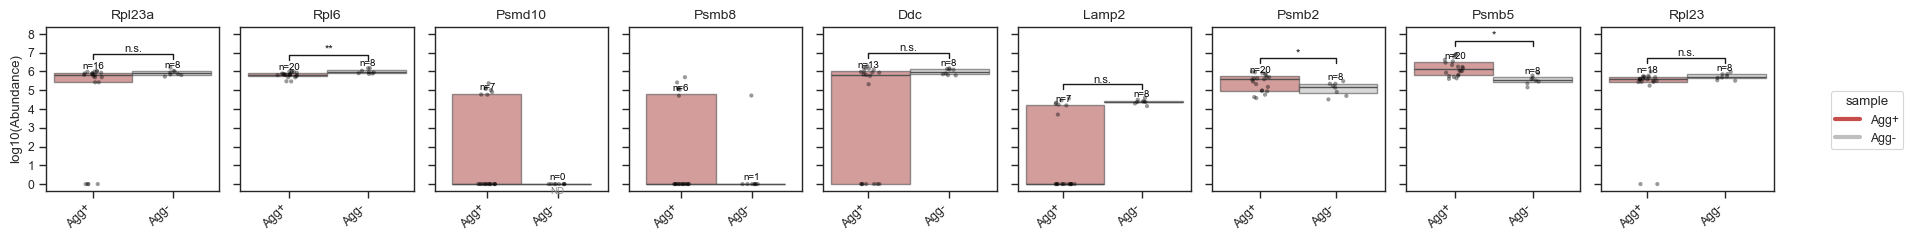

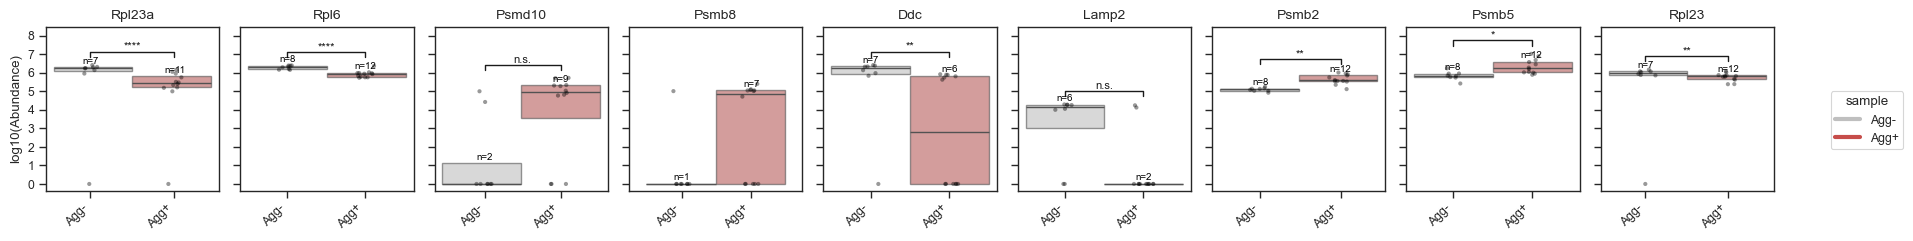

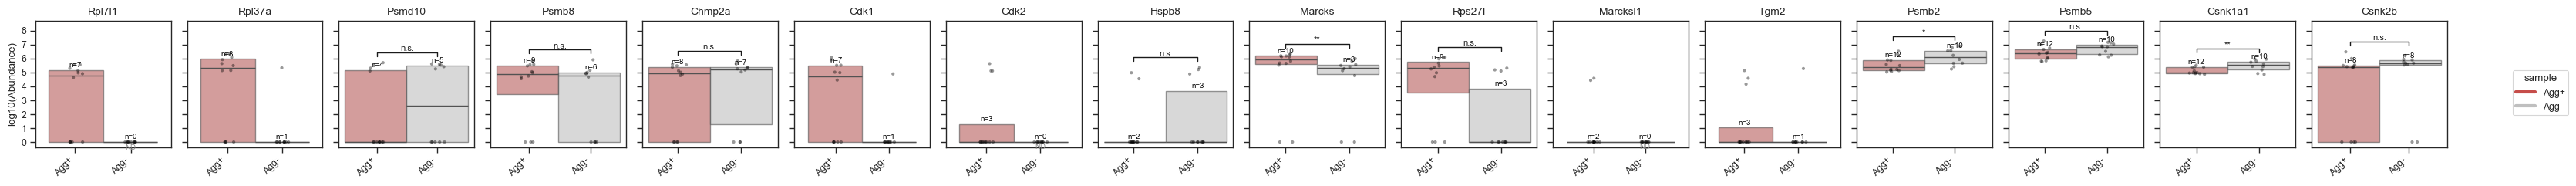

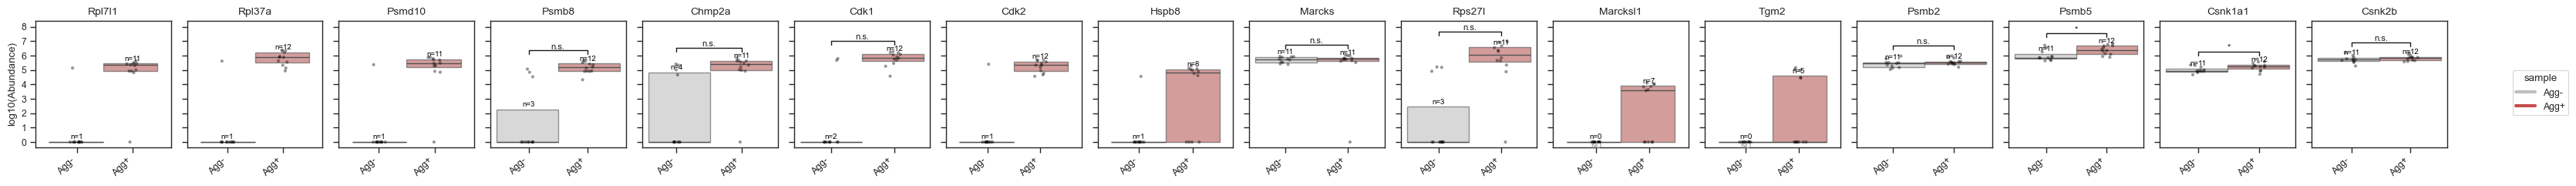

In [51]:
plot_cortex=['RPL7L1', 'RPL37A', 'PSMD10', 'PSMB8', 'CHMP2A', 'CDK1', 'CDK2', 'HSPB8', 'MARCKS', 'RPS27L', 'MARCKSL1', 'TGM2', 'PSMB2', 'PSMB5', 'CSNK1A1', 'CSNK2B']
plot_snpc=['RPL23A', 'RPL6', 'PSMD10', 'PSMB8', 'DDC', 'LAMP2', 'PSMB2', 'PSMB5', 'RPL23']

def to_camel_case(gene):
    return gene[0].upper() + gene[1:].lower()

plot_cortex = [to_camel_case(n) for n in plot_cortex]
plot_snpc = [to_camel_case(n) for n in plot_snpc]

pdata_plot_3mo_snpc = pdata_mus1mo3mo6mo_processed_snpc.filter_sample(condition='timepoint == "3mo"')
pdata_plot_6mo_snpc = pdata_mus1mo3mo6mo_processed_snpc.filter_sample(condition='timepoint == "6mo"')
pdata_plot_3mo_cortex = pdata_mus1mo3mo6mo_processed_cortex.filter_sample(condition='timepoint == "3mo"')
pdata_plot_6mo_cortex = pdata_mus1mo3mo6mo_processed_cortex.filter_sample(condition='timepoint == "6mo"')

plot_names={0:"3mo snpc", 1: "6mo snpc", 2: "3mo cortex", 3: "6mo cortex"}

for i, pdata in enumerate([pdata_plot_3mo_snpc,pdata_plot_6mo_snpc]):
    print(i)
    print(plot_names[i])
    scplt.plot_abundance_boxgrid(pdata=pdata, namelist=plot_snpc, classes='sample', palette=agg_color, sig_pairs=True, figsize=(2,2.5), sig_kwargs={"fontsize":8}, log_scale=True, show_n=True)

for i, pdata in enumerate([pdata_plot_3mo_cortex,pdata_plot_6mo_cortex]):
    print(i)
    print(plot_names[i])
    scplt.plot_abundance_boxgrid(pdata=pdata, namelist=plot_cortex, classes='sample', palette=agg_color, sig_pairs=True, figsize=(2,2.5), sig_kwargs={"fontsize":8}, log_scale=True, show_n=True)



### 6mo cortex

[get_abundance] 8306 peptides could not be mapped to genes: ['AAADTLQGPMQAAYR2', 'AAAEGLMSLLR2', 'AAAELLQSQGSQAGGSQTLK3', 'AAAELLQSQGSQAGGSQTLKR3', 'AAAEVNQEYGLDPK2', 'AAAGPLPPISADTR2', 'AAAMANNLQK2', 'AAAQLGVEELQK2', 'AAAQLLQSQAQQSGAQQTK3', 'AAAQVLNTLWQYR2', 'AAASEGVQVK2', 'AAASLAWVLR2', 'AAATFNPELITHILDGSPENTR3', 'AAAVDFTAR2', 'AADAAAEPYPEDK2', 'AADEVAEGK2', 'AADFEDLLSSQGFNAHK3', 'AADIHTFSSVLEK3', 'AADIIDGLR2', 'AADISLDNLVEGK2', 'AADLLYAMC(UniMod:4)DR2', 'AADTNEVVK2', 'AAEDPVSEVTVGVSVLAER3', 'AAEDSNLISGFGVAEGSEK3', 'AAEEAEEAR2', 'AAEEAEEAREQAER3', 'AAEEVGYPVMIK2', 'AAELYER2', 'AAEMLLFGK2', 'AAESIDQK2', 'AAEVWMDEYK2', 'AAFGISDSYVDGSSFDPQR3', 'AAFGISDSYVDGSSFDPQRR3', 'AAFIDNMNQYTR2', 'AAFLSEQLQPLSR2', 'AAFYHQPWAQEAVGR3', 'AAGISLIVPGK2', 'AAGQSFSQGTTGR2', 'AAIVYHTK2', 'AAKPGANSTTDAVLLNK3', 'AALADVLR2', 'AALAHPFFQDVTK2', 'AALAHPFFQDVTK3', 'AALAHSEIATTQAASTK3', 'AALEALGSC(UniMod:4)LNNK2', 'AALEAQNALHNIK2', 'AALEAQNALHNIK3', 'AALEAQNALHNMK2', 'AALEAQNALHNMK3', 'AALEEVYPDLTPEENRR3', 'AALESG

C:\Users\srpang\AppData\Local\Temp\ipykernel_15148\2046377255.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


Peptide abundance: Agg+ median=5.188 (n=12), Agg- median=5.229 (n=11), t=-0.343, p=0.7353


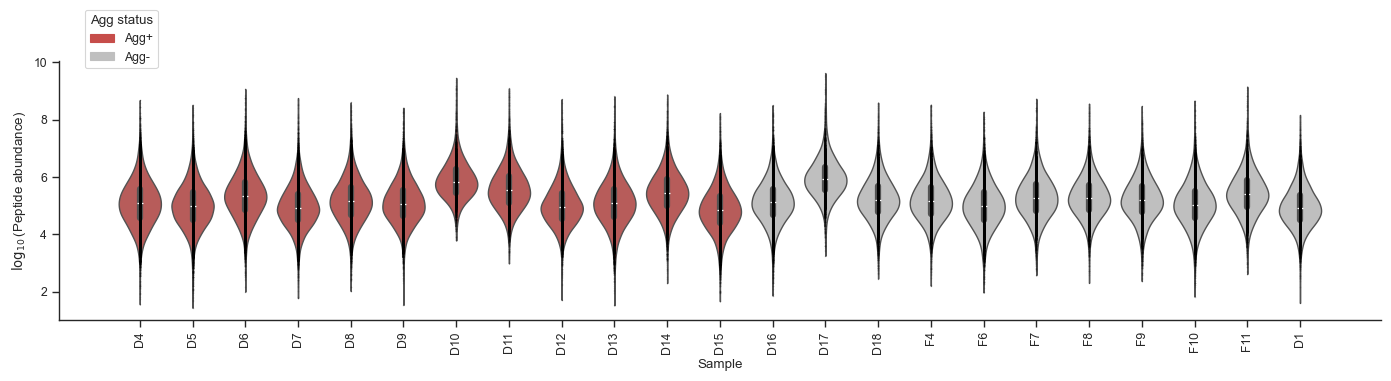

In [40]:
# CORTEX PEPTIDE ABUNDANCE DIST

import matplotlib.patches as mpatches
from scipy import stats

agg_color = {"Agg+": "#C64D4A", "Agg-": "#BFBFBF"}
agg_order = ["Agg+", "Agg-"]

df_raw = pdata_6mo_cortex_filter.get_abundance(on="peptide", classes="sample", log=False)
df_raw = df_raw[df_raw["abundance"] > 0].copy()
df_raw["log10_abundance"] = np.log10(df_raw["abundance"])

sample_meta = df_raw.groupby("cell")["class"].first()
sample_order = (
    sample_meta[sample_meta == "Agg+"].index.tolist()
    + sample_meta[sample_meta == "Agg-"].index.tolist()
)
short_labels = [s.split("_")[-1] for s in sample_order]
violin_colors = [agg_color[sample_meta[s]] for s in sample_order]

fig, ax = plt.subplots(figsize=(14, 4))

sns.violinplot(
    data=df_raw,
    x="cell",
    y="log10_abundance",
    order=sample_order,
    palette=violin_colors,
    inner="box",
    cut=0,
    linewidth=1,
    bw_adjust=1.5,
    gridsize=200,
    ax=ax,
)

xs = [sample_order.index(c) for c in df_raw["cell"]]
ax.scatter(xs, df_raw["log10_abundance"], color="black", s=1.3**2, alpha=0.12, linewidths=0, zorder=3)

ax.set_xlabel("Sample")
ax.set_ylabel(r"$\log_{10}$(Peptide abundance)")
ax.set_xticks(range(len(sample_order)))
ax.set_xticklabels(short_labels, rotation=90)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

handles = [mpatches.Patch(color=agg_color[k], label=k) for k in agg_order]
ax.legend(handles=handles, title="Agg status", frameon=True,
          bbox_to_anchor=(0.02, 1.2), loc="upper left", borderaxespad=0)

plt.tight_layout()
plt.savefig("MANUSCRIPT_revision/REVISION_FigX6moCortex-Abundance_Peptide_Violin.svg", bbox_inches="tight", pad_inches=0.1)

# t-test on per-sample medians
medians = df_raw.groupby("cell")["log10_abundance"].median()
agg_plus  = medians[sample_meta[medians.index] == "Agg+"]
agg_minus = medians[sample_meta[medians.index] == "Agg-"]
t, p = stats.ttest_ind(agg_plus, agg_minus)
print(f"Peptide abundance: Agg+ median={agg_plus.mean():.3f} (n={len(agg_plus)}), "
      f"Agg- median={agg_minus.mean():.3f} (n={len(agg_minus)}), t={t:.3f}, p={p:.4f}")

Raw (pre-normalization): Agg+ median=5.248 (n=12 cells), Agg- median=5.278 (n=11 cells), t=-0.420, p=0.6786
Normalized: Agg+ median=5.604 (n=12 cells), Agg- median=5.862 (n=11 cells), t=-3.055, p=0.0060


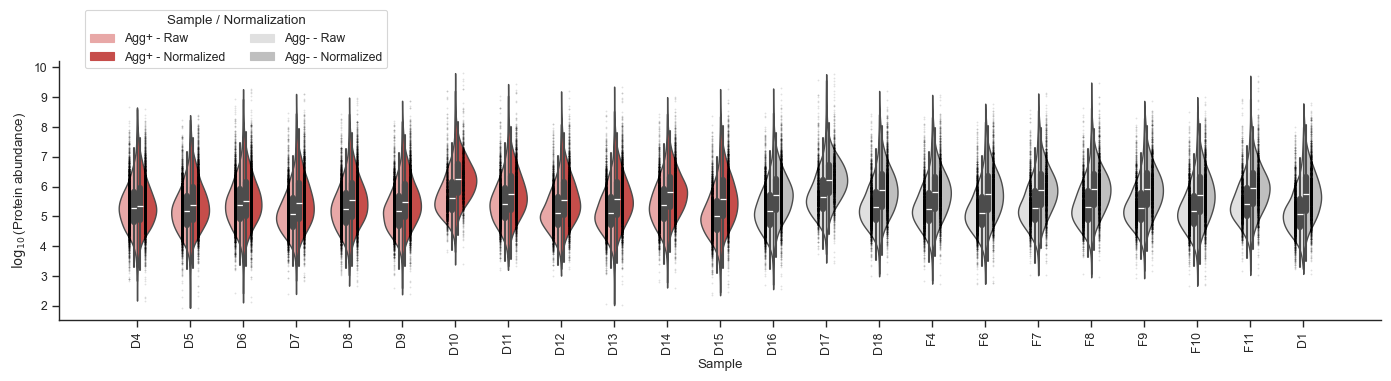

In [41]:
# CORTEX PROTEIN ABUNDANCE DIST (directLFQ)

import matplotlib.patches as mpatches

agg_color = {"Agg+": "#C64D4A", "Agg-": "#BFBFBF"}
agg_color_raw = {"Agg+": "#E8A8A7", "Agg-": "#E0E0E0"}  # lighter versions for raw

agg_order = ["Agg+", "Agg-"]

# --- load both datasets and tag them ---
df_raw = pdata_6mo_cortex_filter.get_abundance(on="protein", classes="sample", log=False)
df_raw = df_raw[df_raw["abundance"] > 0].copy()
df_raw["log10_abundance"] = np.log10(df_raw["abundance"])
df_raw["norm_status"] = "Raw"

df_norm = pdata_6mo_cortex_norm.get_abundance(on="protein", classes="sample", log=False)
df_norm = df_norm[df_norm["abundance"] > 0].copy()
df_norm["log10_abundance"] = np.log10(df_norm["abundance"])
df_norm["norm_status"] = "Normalized"

df = pd.concat([df_raw, df_norm], ignore_index=True)

sample_meta = df_raw.groupby("cell")["class"].first()
sample_order = (
    sample_meta[sample_meta == "Agg+"].index.tolist()
    + sample_meta[sample_meta == "Agg-"].index.tolist()
)

fig, ax = plt.subplots(figsize=(14, 4))

sns.violinplot(
    data=df,
    x="cell",
    y="log10_abundance",
    hue="norm_status",
    hue_order=["Raw", "Normalized"],
    order=sample_order,
    split=True,
    inner="box",
    cut=0,
    linewidth=1,
    bw_adjust=1.5,
    gridsize=200,
    ax=ax,
)

# re-color violin halves: left=Raw (light), right=Normalized (dark)
for i, sample in enumerate(sample_order):
    agg = sample_meta[sample]
    ax.collections[i * 2].set_facecolor(agg_color_raw[agg])      # left half = raw
    ax.collections[i * 2 + 1].set_facecolor(agg_color[agg])      # right half = normalized

# stripplot offsets
for norm_status, offset in [("Raw", -0.15), ("Normalized", 0.15)]:
    sub = df[df["norm_status"] == norm_status]
    xs = [sample_order.index(c) + offset for c in sub["cell"]]
    ax.scatter(xs, sub["log10_abundance"], color="black", s=1.3**2, alpha=0.12, linewidths=0, zorder=3)

short_labels = [s.split("_")[-1] for s in sample_order]
ax.set_xlabel("Sample")
ax.set_ylabel(r"$\log_{10}$(Protein abundance)")
ax.set_xticks(range(len(sample_order)))
ax.set_xticklabels(short_labels, rotation=90)
ax.tick_params(axis="x", rotation=90)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# legend: one row per Agg status, showing light (raw) and dark (norm) patches
legend_handles = []
for agg in agg_order:
    legend_handles += [
        mpatches.Patch(color=agg_color_raw[agg], label=f"{agg} - Raw"),
        mpatches.Patch(color=agg_color[agg],     label=f"{agg} - Normalized"),
    ]

ax.legend(
    handles=legend_handles,
    title="Sample / Normalization",
    frameon=True,
    ncol=2,
    bbox_to_anchor=(0.02, 1.2),
    loc="upper left",
    borderaxespad=0,
)

plt.tight_layout()
plt.savefig("MANUSCRIPT_revision/REVISION_FigX6moCortex-Abundance_SplitViolin.svg", bbox_inches="tight", pad_inches=0.1)

from scipy import stats

for label, data in [("Raw (pre-normalization)", df_raw), ("Normalized", df_norm)]:
    medians = data.groupby("cell")["log10_abundance"].median()
    agg_plus  = medians[sample_meta[medians.index] == "Agg+"]
    agg_minus = medians[sample_meta[medians.index] == "Agg-"]
    t, p = stats.ttest_ind(agg_plus, agg_minus)
    print(f"{label}: Agg+ median={agg_plus.mean():.3f} (n={len(agg_plus)} cells), Agg- median={agg_minus.mean():.3f} (n={len(agg_minus)} cells), t={t:.3f}, p={p:.4f}")

In [47]:
pdata_6mo_cortex_norm.export_layer("X", f"MANUSCRIPT_revision/REVISION_FigX-6moCortex_normalized.csv", transpose=True, var_names='Genes', obs_names='sample')

     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=1.95e+05). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: [{'sample': 'Agg+'}] vs [{'sample': 'Agg-'}]
   🔸 Group sizes: 12 vs 11 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 P-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 419 proteins were not comparable (zero or NaN mean in one group).
     ✅ DE complete. Results stored in:
       • .stats["[{'sample': 'Agg+'}] vs [{'sample': 'Agg-'}]"]
       • Columns: log2fc, p_value, significance, etc.
       • Upregulated: 734 | Downregulated: 385 | Not significant: 2855


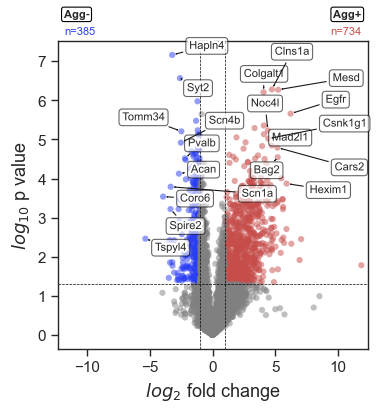

In [56]:
case_values = [{'sample': 'Agg+'}, {'sample': 'Agg-'}]

color_dict={'upregulated':"#C64D4A", 'downregulated': "#293DF5",'not_significant': "#FFFFFF6A"}

fig, ax = plt.subplots(figsize=(4, 4))
ax, volcano_df = scplt.plot_volcano(ax, pdata_6mo_cortex_norm,
                                    values=case_values,
                                    pval=0.05, return_df=True,
                                    fold_change_mode='mean', color=color_dict, label=[10,10])

ax.set_ylabel('$log_{10}$ p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# plt.show()
plt.savefig("MANUSCRIPT_revision/REVISION_FigX6moCortex_VOLCANO-directlfq.svg", bbox_inches="tight", pad_inches=0.1)
volcano_df.to_csv("MANUSCRIPT_revision/REVISION_FigX6moCortex-DE-directlfq.csv")

     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=1.95e+05). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: Agg+ vs Agg-
   🔸 Group sizes: 12 vs 11 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 P-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 419 proteins were not comparable (zero or NaN mean in one group).
     ✅ DE complete. Results stored in:
       • .stats["Agg+ vs Agg-"]
       • Columns: log2fc, p_value, significance, etc.
       • Upregulated: 734 | Downregulated: 385 | Not significant: 2855 | Not comparable: 419


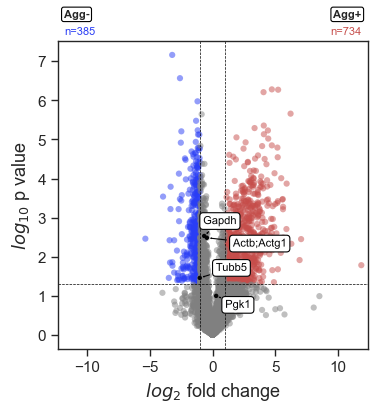

In [10]:
case_values = [{'sample': 'Agg+'}, {'sample': 'Agg-'}]

color_dict={'upregulated':"#C64D4A", 'downregulated': "#293DF5",'not_significant': "#FFFFFF6A"}

fig, ax = plt.subplots(figsize=(4, 4))
ax, volcano_df = scplt.plot_volcano(ax, pdata_6mo_cortex_norm,
                                    values=case_values,
                                    pval=0.05, return_df=True,
                                    fold_change_mode='mean', color=color_dict, label=[0,0])

scplt.mark_volcano(ax, volcano_df, label=['Gapdh','Tubb5','Actb;Actg1','Pgk1'], label_color="#030304")

ax.set_ylabel('$log_{10}$ p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# plt.show()
plt.savefig("MANUSCRIPT_revision/REVISION_FigX6moCortex_VOLCANO-directlfq-Housekeeping.svg", bbox_inches="tight", pad_inches=0.1)

     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=1.70e+05). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: Agg+ vs Agg-
   🔸 Group sizes: 12 vs 11 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 P-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 361 proteins were not comparable (zero or NaN mean in one group).


G:\Users\srpang\Dropbox (Personal)\4. Caltech Work\Research\Chou-Roukes Group\scviz_git\src\scpviz\pAnnData\analysis.py:356: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = ttest_ind(x1, x2, equal_var=equal_var, nan_policy='omit')


     ✅ DE complete. Results stored in:
       • .stats["Agg+ vs Agg-"]
       • Columns: log2fc, p_value, significance, etc.
       • Upregulated: 492 | Downregulated: 129 | Not significant: 3411 | Not comparable: 361


c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxpl

(<Figure size 400x250 with 2 Axes>,
 array([<Axes: title={'center': 'Actb;Actg1'}, ylabel='log10(Abundance)'>,
        <Axes: title={'center': 'Pgk1'}>], dtype=object))

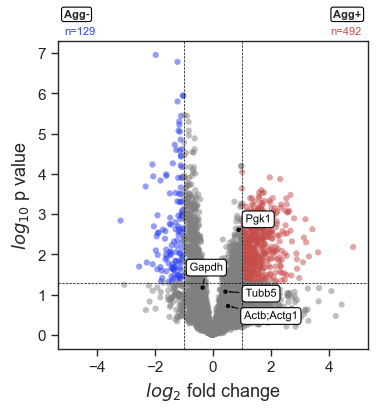

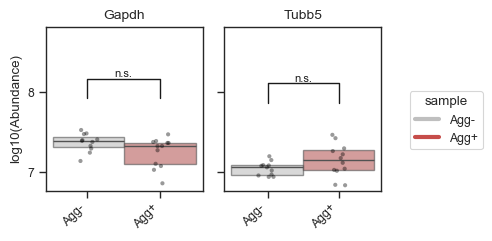

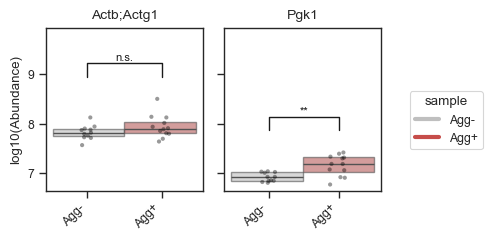

In [8]:
case_values = [{'sample': 'Agg+'}, {'sample': 'Agg-'}]

color_dict={'upregulated':"#C64D4A", 'downregulated': "#293DF5",'not_significant': "#FFFFFF6A"}

fig, ax = plt.subplots(figsize=(4, 4))
ax, volcano_df = scplt.plot_volcano(ax, pdata_6mo_cortex_filter,
                                    values=case_values,
                                    pval=0.05, return_df=True,
                                    fold_change_mode='mean', color=color_dict, label=[0,0])

scplt.mark_volcano(ax, volcano_df, label=['Gapdh','Tubb5','Actb;Actg1','Pgk1'], label_color="#030304")

ax.set_ylabel('$log_{10}$ p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# plt.show()
# plt.savefig("MANUSCRIPT_revision/REVISION_FigX6moCortex_VOLCANO-directlfq-Housekeeping.svg", bbox_inches="tight", pad_inches=0.1)

agg_color = {"Agg+": "#C64D4A", "Agg-": "#BFBFBF"}
agg_order = ["Agg+", "Agg-"]

scplt.plot_abundance_boxgrid(pdata=pdata_6mo_cortex_filter, namelist=['Gapdh','Tubb5'], classes='sample', palette=agg_color, sig_pairs=True, figsize=(2,2.5), sig_kwargs={"fontsize":8}, log_scale=True)
# plt.savefig("MANUSCRIPT_revision/REVISION_FigX6moCortex_ABUNDANCE-GapdhTubb5.svg", bbox_inches="tight", pad_inches=0.1)

scplt.plot_abundance_boxgrid(pdata=pdata_6mo_cortex_filter, namelist=['Actb;Actg1','Pgk1'], classes='sample', palette=agg_color, sig_pairs=True, figsize=(2,2.5), sig_kwargs={"fontsize":8}, log_scale=True)
# plt.savefig("MANUSCRIPT_revision/REVISION_FigX6moCortex_ABUNDANCE-ActbPgk1.svg", bbox_inches="tight", pad_inches=0.1)


c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxpl

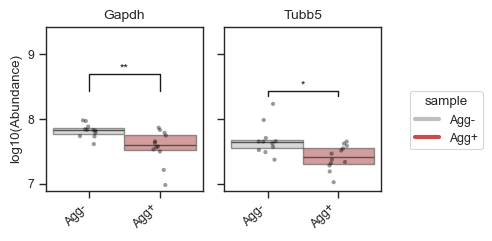

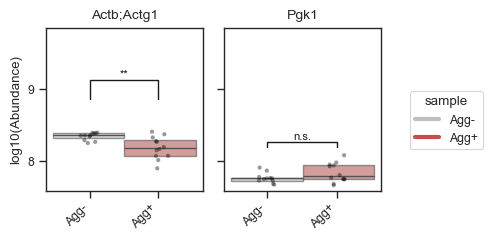

In [11]:
agg_color = {"Agg+": "#C64D4A", "Agg-": "#BFBFBF"}
agg_order = ["Agg+", "Agg-"]

scplt.plot_abundance_boxgrid(pdata=pdata_6mo_cortex_norm, namelist=['Gapdh','Tubb5'], classes='sample', palette=agg_color, sig_pairs=True, figsize=(2,2.5), sig_kwargs={"fontsize":8}, log_scale=True)
plt.savefig("MANUSCRIPT_revision/REVISION_FigX6moCortex_ABUNDANCE-GapdhTubb5.svg", bbox_inches="tight", pad_inches=0.1)

scplt.plot_abundance_boxgrid(pdata=pdata_6mo_cortex_norm, namelist=['Actb;Actg1','Pgk1'], classes='sample', palette=agg_color, sig_pairs=True, figsize=(2,2.5), sig_kwargs={"fontsize":8}, log_scale=True)
plt.savefig("MANUSCRIPT_revision/REVISION_FigX6moCortex_ABUNDANCE-ActbPgk1.svg", bbox_inches="tight", pad_inches=0.1)


In [57]:
vol_list = volcano_df[volcano_df['significance'].isin(["upregulated", "downregulated","not comparable"])].Genes.to_list()

m6_sample = pd.read_csv("MANUSCRIPT_revision/REVISION_FigX-6moCortex_normalized.csv")
m6_sample_filtered = m6_sample[m6_sample['Genes'].isin(vol_list)].copy()

# map significance from volcano_df onto the filtered df via Genes
sig_map = volcano_df.set_index('Genes')['significance']
m6_sample_filtered['significance'] = m6_sample_filtered['Genes'].map(sig_map)

# sort columns, keeping the first column first and significance last
first_col = m6_sample_filtered.columns[0]
other_cols = sorted(c for c in m6_sample_filtered.columns if c not in [first_col, 'significance'])
m6_sample_filtered = m6_sample_filtered[[first_col] + other_cols + ['significance']]

m6_sample_filtered.to_csv("MANUSCRIPT_revision/REVISION_FigX-6moCortex_volcano-only.csv", index=False)

rpl_list:  9
rps_list:  13
     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=1.95e+05). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: [{'sample': 'Agg+'}] vs [{'sample': 'Agg-'}]
   🔸 Group sizes: 12 vs 11 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 P-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 419 proteins were not comparable (zero or NaN mean in one group).
     ✅ DE complete. Results stored in:
       • .stats["[{'sample': 'Agg+'}] vs [{'sample': 'Agg-'}]"]
       • Columns: log2fc, p_value, significance, etc.
       • Upregulated: 734 | Downregulated: 385 | Not significant: 2855


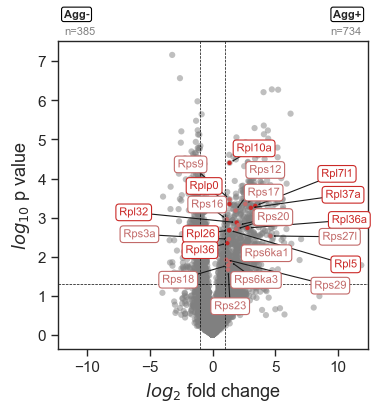

In [51]:
## RPL/RPS
rpl_list, rpl_top5, rpl_others = extract_gene_group(volcano_df, prefixes=["rpl"])
rps_list, rps_top5, rps_others = extract_gene_group(volcano_df, prefixes=["rps"])

print("rpl_list: ", len(rpl_list))
print("rps_list: ", len(rps_list))

case_values = [{'sample': 'Agg+'}, {'sample': 'Agg-'}]

color_dict={'upregulated':"#C64D4A", 'downregulated': "#293DF5",'not_significant': "#FFFFFF6A"}
rps_dict={'downregulated': '#5166FF', 'upregulated': "#C26A69"}
rpl_dict={'downregulated': '#1F2CCF', 'upregulated': "#CA2927"}

fig, ax = plt.subplots(figsize=(4, 4))
ax, volcano_df = scplt.plot_volcano(ax, pdata_6mo_cortex_norm,
                                    values=case_values,
                                    pval=0.05, return_df=True,
                                    fold_change_mode='mean', no_marks=True)

texts = []
ax, t = scplt.mark_volcano_by_significance(ax, volcano_df, label=rpl_list, color=rpl_dict,return_texts=True)
texts.extend(t)
ax, t = scplt.mark_volcano_by_significance(ax, volcano_df, label=rps_list, color=rps_dict,return_texts=True)
texts.extend(t)

scplt.volcano_adjust_and_outline_texts(texts, expand=(2,2))

ax.set_ylabel('$log_{10}$ p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# plt.show()
plt.savefig("MANUSCRIPT_revision/REVISION_FigX6moCortex_VOLCANO-directlfq-RplRps.svg", bbox_inches="tight", pad_inches=0.1)

proteasome_list:  8
     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=1.95e+05). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: [{'sample': 'Agg+'}] vs [{'sample': 'Agg-'}]
   🔸 Group sizes: 12 vs 11 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 P-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 419 proteins were not comparable (zero or NaN mean in one group).
     ✅ DE complete. Results stored in:
       • .stats["[{'sample': 'Agg+'}] vs [{'sample': 'Agg-'}]"]
       • Columns: log2fc, p_value, significance, etc.
       • Upregulated: 734 | Downregulated: 385 | Not significant: 2855


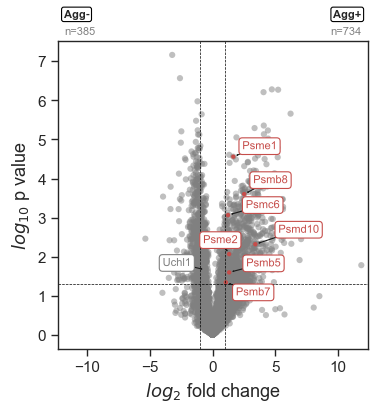

In [52]:
## Proteasome
proteasome_list, proteasome_top5, proteasome_others = extract_gene_group(volcano_df, prefixes=["psm"])
proteasome_list.append('Uchl1')

print("proteasome_list: ", len(proteasome_list))

case_values = [{'sample': 'Agg+'}, {'sample': 'Agg-'}]

color_dict={'upregulated':"#C64D4A", 'downregulated': "#293DF5",'not_significant': "#FFFFFF6A"}

fig, ax = plt.subplots(figsize=(4, 4))
ax, volcano_df = scplt.plot_volcano(ax, pdata_6mo_cortex_norm,
                                    values=case_values,
                                    pval=0.05, return_df=True,
                                    fold_change_mode='mean', no_marks=True)

texts = []
ax, t = scplt.mark_volcano_by_significance(ax, volcano_df, label=proteasome_list, color=color_dict, return_texts=True)
texts.extend(t)
scplt.volcano_adjust_and_outline_texts(texts, expand=(2, 2))
# scplt.mark_volcano_by_significance(ax, volcano_df, label=proteasome_top5, color=color_dict)
# scplt.mark_volcano_by_significance(ax, volcano_df, label=proteasome_others, color=color_dict, show_names=False)

ax.set_ylabel('$log_{10}$ p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

plt.savefig("MANUSCRIPT_revision/REVISION_FigX6moCortex_VOLCANO-directlfq-Proteasome.svg", bbox_inches="tight", pad_inches=0.1)

     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=1.95e+05). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: [{'sample': 'Agg+'}] vs [{'sample': 'Agg-'}]
   🔸 Group sizes: 12 vs 11 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 P-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 419 proteins were not comparable (zero or NaN mean in one group).
     ✅ DE complete. Results stored in:
       • .stats["[{'sample': 'Agg+'}] vs [{'sample': 'Agg-'}]"]
       • Columns: log2fc, p_value, significance, etc.
       • Upregulated: 734 | Downregulated: 385 | Not significant: 2855


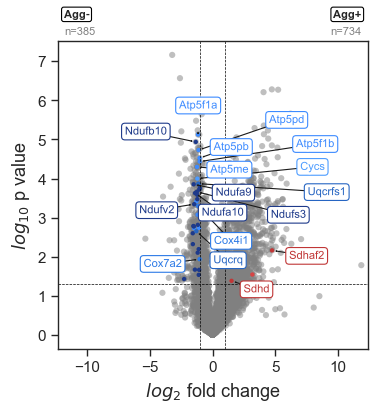

In [53]:
## Mitochondria

mito_groups = {
    "complex5":   ["atp5"],
    "complex4":   ["cox"],
    "complex1":   ["nduf"],
    "complex2":   ["sdh"],
    "complex3":   ["uqcr"],
    "mito_other": ["cyc1", "cycs", "pgk", "vdac"],
}

mito_results = {}

for group_name, prefixes in mito_groups.items():
    gene_list, top5, others = extract_gene_group(volcano_df, prefixes)
    mito_results[group_name] = {
        "list": gene_list,
        "top5": top5,
        "others": others,
    }

mito_color_dict = {
    "complex1": {     # NDUF*
        "upregulated":   "#D64545",   # strong red
        "downregulated": "#1E3A8A",   # deep indigo blue
    },
    "complex2": {     # SDH*
        "upregulated":   "#C03636",   # darker red
        "downregulated": "#1F4DA0",   # strong royal blue
    },
    "complex3": {     # UQCR*
        "upregulated":   "#B42E2E",   # deep cherry
        "downregulated": "#2665C2",   # vivid blue
    },
    "complex4": {     # COX*
        "upregulated":   "#A82828",   # wine red
        "downregulated": "#2D7AE6",   # bright azure
    },
    "complex5": {     # ATP5*
        "upregulated":   "#9E2020",   # maroon
        "downregulated": "#3D8BFF",   # clear blue
    },
    "mito_other": {
        "upregulated":   "#8C1A1A",   # dark brick red
        "downregulated": "#4C9CFF",   # lighter but still strong blue
    },
}

## Mitochondria, all together

case_values = [{'sample': 'Agg+'}, {'sample': 'Agg-'}]

color_dict={'upregulated':"#C64D4A", 'downregulated': "#293DF5",'not_significant': "#FFFFFF6A"}

fig, ax = plt.subplots(figsize=(4, 4))
ax, volcano_df = scplt.plot_volcano(ax, pdata_6mo_cortex_norm,
                                    values=case_values,
                                    pval=0.05, return_df=True,
                                    fold_change_mode='mean', no_marks=True)

texts = []
for group_name, d in mito_results.items():
    colors = mito_color_dict[group_name]

    if len(d["top5"]) > 0:
        # highlight top 5 (with names)
        ax, t = scplt.mark_volcano_by_significance(
            ax, volcano_df,
            label=d["top5"],
            color=colors,
            return_texts=True,
        )

        texts.extend(t)

    if len(d["others"]) > 0:
        # highlight the others (no names)
        scplt.mark_volcano_by_significance(
            ax, volcano_df,
            label=d["others"],
            color=colors,
            show_names=False,
        )

scplt.volcano_adjust_and_outline_texts(texts, expand=(2,2))

ax.set_ylabel('$log_{10}$ p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

plt.savefig("MANUSCRIPT_revision/REVISION_FigX6moCortex_VOLCANO-directlfq-MitoAll.svg", bbox_inches="tight", pad_inches=0.1)

#### testing volcano for raw

rpl_list:  18
rps_list:  19
     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=1.70e+05). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: Agg+ vs Agg-
   🔸 Group sizes: 12 vs 11 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 P-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 361 proteins were not comparable (zero or NaN mean in one group).


G:\Users\srpang\Dropbox (Personal)\4. Caltech Work\Research\Chou-Roukes Group\scviz_git\src\scpviz\pAnnData\analysis.py:356: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = ttest_ind(x1, x2, equal_var=equal_var, nan_policy='omit')


     ✅ DE complete. Results stored in:
       • .stats["Agg+ vs Agg-"]
       • Columns: log2fc, p_value, significance, etc.
       • Upregulated: 492 | Downregulated: 129 | Not significant: 3411 | Not comparable: 361


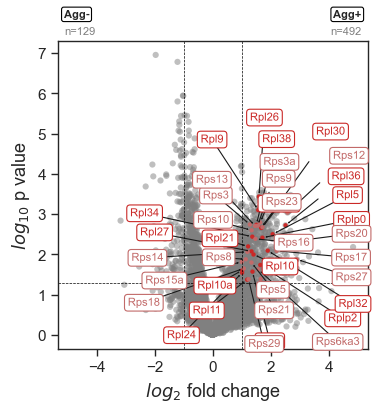

In [11]:
## RPL/RPS
rpl_list, rpl_top5, rpl_others = extract_gene_group(volcano_df, prefixes=["rpl"])
rps_list, rps_top5, rps_others = extract_gene_group(volcano_df, prefixes=["rps"])

print("rpl_list: ", len(rpl_list))
print("rps_list: ", len(rps_list))

case_values = [{'sample': 'Agg+'}, {'sample': 'Agg-'}]

color_dict={'upregulated':"#C64D4A", 'downregulated': "#293DF5",'not_significant': "#FFFFFF6A"}
rps_dict={'downregulated': '#5166FF', 'upregulated': "#C26A69"}
rpl_dict={'downregulated': '#1F2CCF', 'upregulated': "#CA2927"}

fig, ax = plt.subplots(figsize=(4, 4))
ax, volcano_df = scplt.plot_volcano(ax, pdata_6mo_cortex_filter,
                                    values=case_values,
                                    pval=0.05, return_df=True,
                                    fold_change_mode='mean', no_marks=True)

texts = []
ax, t = scplt.mark_volcano_by_significance(ax, volcano_df, label=rpl_list, color=rpl_dict,return_texts=True)
texts.extend(t)
ax, t = scplt.mark_volcano_by_significance(ax, volcano_df, label=rps_list, color=rps_dict,return_texts=True)
texts.extend(t)

scplt.volcano_adjust_and_outline_texts(texts, expand=(2,2))

ax.set_ylabel('$log_{10}$ p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# plt.show()
# plt.savefig("MANUSCRIPT_revision/REVISION_FigX6moCortex_VOLCANO-directlfq-RplRps.svg", bbox_inches="tight", pad_inches=0.1)

proteasome_list:  18
     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=1.70e+05). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: Agg+ vs Agg-
   🔸 Group sizes: 12 vs 11 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 P-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 361 proteins were not comparable (zero or NaN mean in one group).


G:\Users\srpang\Dropbox (Personal)\4. Caltech Work\Research\Chou-Roukes Group\scviz_git\src\scpviz\pAnnData\analysis.py:356: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = ttest_ind(x1, x2, equal_var=equal_var, nan_policy='omit')


     ✅ DE complete. Results stored in:
       • .stats["Agg+ vs Agg-"]
       • Columns: log2fc, p_value, significance, etc.
       • Upregulated: 492 | Downregulated: 129 | Not significant: 3411 | Not comparable: 361


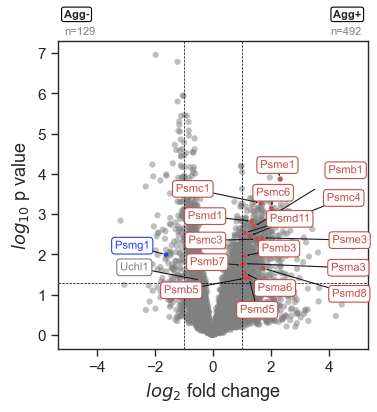

In [13]:
## Proteasome
proteasome_list, proteasome_top5, proteasome_others = extract_gene_group(volcano_df, prefixes=["psm"])
proteasome_list.append('Uchl1')

print("proteasome_list: ", len(proteasome_list))

case_values = [{'sample': 'Agg+'}, {'sample': 'Agg-'}]

color_dict={'upregulated':"#C64D4A", 'downregulated': "#293DF5",'not_significant': "#FFFFFF6A"}

fig, ax = plt.subplots(figsize=(4, 4))
ax, volcano_df = scplt.plot_volcano(ax, pdata_6mo_cortex_filter,
                                    values=case_values,
                                    pval=0.05, return_df=True,
                                    fold_change_mode='mean', no_marks=True)

texts = []
ax, t = scplt.mark_volcano_by_significance(ax, volcano_df, label=proteasome_list, color=color_dict, return_texts=True)
texts.extend(t)
scplt.volcano_adjust_and_outline_texts(texts, expand=(2, 2))
# scplt.mark_volcano_by_significance(ax, volcano_df, label=proteasome_top5, color=color_dict)
# scplt.mark_volcano_by_significance(ax, volcano_df, label=proteasome_others, color=color_dict, show_names=False)

ax.set_ylabel('$log_{10}$ p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

plt.show()
# plt.savefig("MANUSCRIPT_revision/REVISION_FigX6moCortex_VOLCANO-directlfq-Proteasome.svg", bbox_inches="tight", pad_inches=0.1)

     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=1.70e+05). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: Agg+ vs Agg-
   🔸 Group sizes: 12 vs 11 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 P-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 361 proteins were not comparable (zero or NaN mean in one group).


G:\Users\srpang\Dropbox (Personal)\4. Caltech Work\Research\Chou-Roukes Group\scviz_git\src\scpviz\pAnnData\analysis.py:356: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = ttest_ind(x1, x2, equal_var=equal_var, nan_policy='omit')


     ✅ DE complete. Results stored in:
       • .stats["Agg+ vs Agg-"]
       • Columns: log2fc, p_value, significance, etc.
       • Upregulated: 492 | Downregulated: 129 | Not significant: 3411 | Not comparable: 361


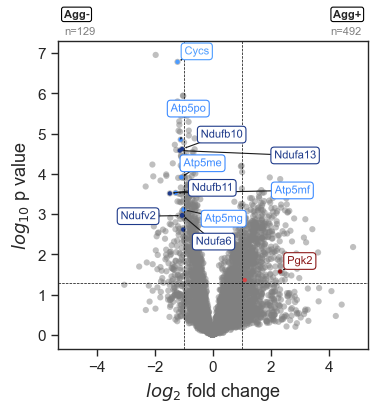

In [14]:
## Mitochondria

mito_groups = {
    "complex5":   ["atp5"],
    "complex4":   ["cox"],
    "complex1":   ["nduf"],
    "complex2":   ["sdh"],
    "complex3":   ["uqcr"],
    "mito_other": ["cyc1", "cycs", "pgk", "vdac"],
}

mito_results = {}

for group_name, prefixes in mito_groups.items():
    gene_list, top5, others = extract_gene_group(volcano_df, prefixes)
    mito_results[group_name] = {
        "list": gene_list,
        "top5": top5,
        "others": others,
    }

mito_color_dict = {
    "complex1": {     # NDUF*
        "upregulated":   "#D64545",   # strong red
        "downregulated": "#1E3A8A",   # deep indigo blue
    },
    "complex2": {     # SDH*
        "upregulated":   "#C03636",   # darker red
        "downregulated": "#1F4DA0",   # strong royal blue
    },
    "complex3": {     # UQCR*
        "upregulated":   "#B42E2E",   # deep cherry
        "downregulated": "#2665C2",   # vivid blue
    },
    "complex4": {     # COX*
        "upregulated":   "#A82828",   # wine red
        "downregulated": "#2D7AE6",   # bright azure
    },
    "complex5": {     # ATP5*
        "upregulated":   "#9E2020",   # maroon
        "downregulated": "#3D8BFF",   # clear blue
    },
    "mito_other": {
        "upregulated":   "#8C1A1A",   # dark brick red
        "downregulated": "#4C9CFF",   # lighter but still strong blue
    },
}

## Mitochondria, all together

case_values = [{'sample': 'Agg+'}, {'sample': 'Agg-'}]

color_dict={'upregulated':"#C64D4A", 'downregulated': "#293DF5",'not_significant': "#FFFFFF6A"}

fig, ax = plt.subplots(figsize=(4, 4))
ax, volcano_df = scplt.plot_volcano(ax, pdata_6mo_cortex_filter,
                                    values=case_values,
                                    pval=0.05, return_df=True,
                                    fold_change_mode='mean', no_marks=True)

texts = []
for group_name, d in mito_results.items():
    colors = mito_color_dict[group_name]

    if len(d["top5"]) > 0:
        # highlight top 5 (with names)
        ax, t = scplt.mark_volcano_by_significance(
            ax, volcano_df,
            label=d["top5"],
            color=colors,
            return_texts=True,
        )

        texts.extend(t)

    if len(d["others"]) > 0:
        # highlight the others (no names)
        scplt.mark_volcano_by_significance(
            ax, volcano_df,
            label=d["others"],
            color=colors,
            show_names=False,
        )

scplt.volcano_adjust_and_outline_texts(texts, expand=(2,2))

ax.set_ylabel('$log_{10}$ p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

plt.show()
# plt.savefig("MANUSCRIPT_revision/REVISION_FigX6moCortex_VOLCANO-directlfq-MitoAll.svg", bbox_inches="tight", pad_inches=0.1)

### 1mo cortex

[get_abundance] 7507 peptides could not be mapped to genes: ['AAADTLQGPMQAAYR2', 'AAAELLQSQGSQAGGSQTLK3', 'AAAELLQSQGSQAGGSQTLKR3', 'AAAEVNQEYGLDPK2', 'AAAGPLPPISADTR2', 'AAAMANNLQK2', 'AAAQLGVEELQK2', 'AAAQLLQSQAQQSGAQQTK3', 'AAAQVLNTLWQYR2', 'AAASEGVQVK2', 'AAASLAWVLR2', 'AAATFNPELITHILDGSPENTR3', 'AAAVDFTAR2', 'AADAAAEPYPEDK2', 'AADEVAEGK2', 'AADFEDLLSSQGFNAHK3', 'AADIHTFSSVLEK3', 'AADIIDGLR2', 'AADISLDNLVEGK2', 'AADLLYAMC(UniMod:4)DR2', 'AADTNEVVK2', 'AAEDPVSEVTVGVSVLAER3', 'AAEDSNLISGFGVAEGSEK3', 'AAEEAEEAR2', 'AAEEAEEAREQAER3', 'AAEEVGYPVMIK2', 'AAELYER2', 'AAEMLLFGK2', 'AAESIDQK2', 'AAEVWMDEYK2', 'AAFGISDSYVDGSSFDPQR3', 'AAFGISDSYVDGSSFDPQRR3', 'AAGISLIVPGK2', 'AAGQSFSQGTTGR2', 'AAKPGANSTTDAVLLNK3', 'AALADVLR2', 'AALAHSEIATTQAASTK3', 'AALEALGSC(UniMod:4)LNNK2', 'AALEAQNALHNIK2', 'AALEAQNALHNIK3', 'AALEAQNALHNMK2', 'AALEAQNALHNMK3', 'AALEEVYPDLTPEENRR3', 'AALESGVSTK2', 'AALESQLR2', 'AALEYLGSFDHYAT2', 'AALPLTTSDTK2', 'AALPTPALTPEDK2', 'AALSEMVEYITHNR3', 'AALSSFQK2', 'AAMEALQSQALHA

C:\Users\srpang\AppData\Local\Temp\ipykernel_25924\3216525867.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


Peptide abundance: Agg+ median=5.270 (n=12), Agg- median=5.211 (n=10), t=0.357, p=0.7251


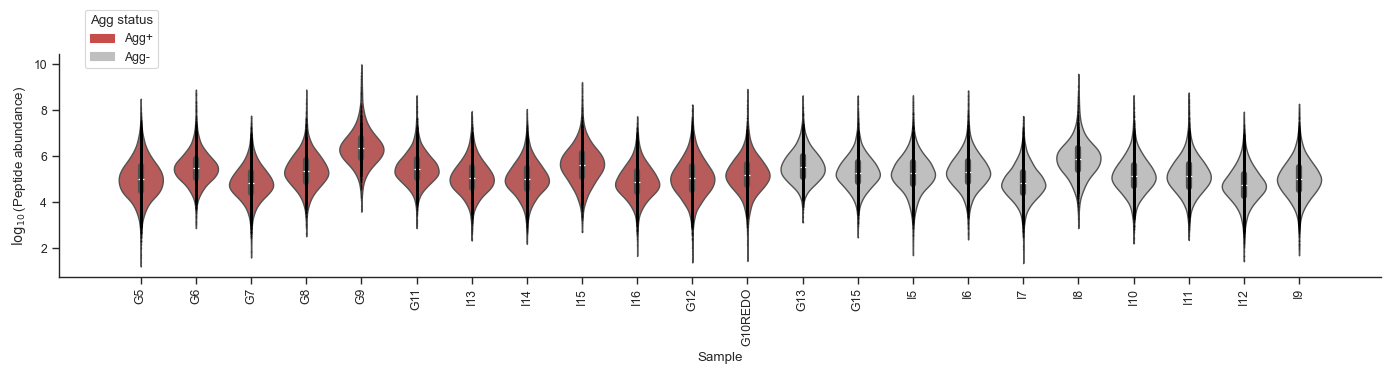

In [18]:
# CORTEX PEPTIDE ABUNDANCE DIST

import matplotlib.patches as mpatches
from scipy import stats

agg_color = {"Agg+": "#C64D4A", "Agg-": "#BFBFBF"}
agg_order = ["Agg+", "Agg-"]

df_raw = pdata_1mo_cortex_filter.get_abundance(on="peptide", classes="sample", log=False)
df_raw = df_raw[df_raw["abundance"] > 0].copy()
df_raw["log10_abundance"] = np.log10(df_raw["abundance"])

sample_meta = df_raw.groupby("cell")["class"].first()
sample_order = (
    sample_meta[sample_meta == "Agg+"].index.tolist()
    + sample_meta[sample_meta == "Agg-"].index.tolist()
)
short_labels = [s.split("_")[-1] for s in sample_order]
violin_colors = [agg_color[sample_meta[s]] for s in sample_order]

fig, ax = plt.subplots(figsize=(14, 4))

sns.violinplot(
    data=df_raw,
    x="cell",
    y="log10_abundance",
    order=sample_order,
    palette=violin_colors,
    inner="box",
    cut=0,
    linewidth=1,
    bw_adjust=1.5,
    gridsize=200,
    ax=ax,
)

xs = [sample_order.index(c) for c in df_raw["cell"]]
ax.scatter(xs, df_raw["log10_abundance"], color="black", s=1.3**2, alpha=0.12, linewidths=0, zorder=3)

ax.set_xlabel("Sample")
ax.set_ylabel(r"$\log_{10}$(Peptide abundance)")
ax.set_xticks(range(len(sample_order)))
ax.set_xticklabels(short_labels, rotation=90)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

handles = [mpatches.Patch(color=agg_color[k], label=k) for k in agg_order]
ax.legend(handles=handles, title="Agg status", frameon=True,
          bbox_to_anchor=(0.02, 1.2), loc="upper left", borderaxespad=0)

plt.tight_layout()
plt.savefig("MANUSCRIPT_revision/REVISION_FigX1moCortex-Abundance_Peptide_Violin.svg", bbox_inches="tight", pad_inches=0.1)

# t-test on per-sample medians
medians = df_raw.groupby("cell")["log10_abundance"].median()
agg_plus  = medians[sample_meta[medians.index] == "Agg+"]
agg_minus = medians[sample_meta[medians.index] == "Agg-"]
t, p = stats.ttest_ind(agg_plus, agg_minus)
print(f"Peptide abundance: Agg+ median={agg_plus.mean():.3f} (n={len(agg_plus)}), "
      f"Agg- median={agg_minus.mean():.3f} (n={len(agg_minus)}), t={t:.3f}, p={p:.4f}")

Raw (pre-normalization): Agg+ median=5.306 (n=12 cells), Agg- median=5.282 (n=10 cells), t=0.235, p=0.8166
Normalized: Agg+ median=5.558 (n=12 cells), Agg- median=5.461 (n=10 cells), t=1.075, p=0.2950


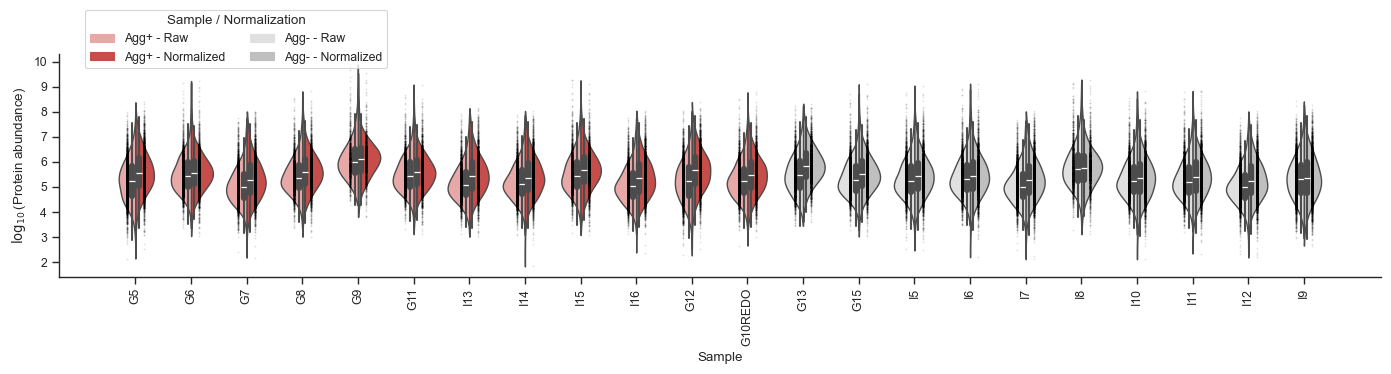

In [ ]:
# CORTEX PROTEIN ABUNDANCE DIST (directLFQ)

import matplotlib.patches as mpatches

agg_color = {"Agg+": "#C64D4A", "Agg-": "#BFBFBF"}
agg_color_raw = {"Agg+": "#E8A8A7", "Agg-": "#E0E0E0"}  # lighter versions for raw

agg_order = ["Agg+", "Agg-"]

# --- load both datasets and tag them ---
df_raw = pdata_1mo_cortex_filter.get_abundance(on="protein", classes="sample", log=False)
df_raw = df_raw[df_raw["abundance"] > 0].copy()
df_raw["log10_abundance"] = np.log10(df_raw["abundance"])
df_raw["norm_status"] = "Raw"

df_norm = pdata_1mo_cortex_norm.get_abundance(on="protein", classes="sample", log=False)
df_norm = df_norm[df_norm["abundance"] > 0].copy()
df_norm["log10_abundance"] = np.log10(df_norm["abundance"])
df_norm["norm_status"] = "Normalized"

df = pd.concat([df_raw, df_norm], ignore_index=True)

sample_meta = df_raw.groupby("cell")["class"].first()
sample_order = (
    sample_meta[sample_meta == "Agg+"].index.tolist()
    + sample_meta[sample_meta == "Agg-"].index.tolist()
)

fig, ax = plt.subplots(figsize=(14, 4))

sns.violinplot(
    data=df,
    x="cell",
    y="log10_abundance",
    hue="norm_status",
    hue_order=["Raw", "Normalized"],
    order=sample_order,
    split=True,
    inner="box",
    cut=0,
    linewidth=1,
    bw_adjust=1.5,
    gridsize=200,
    ax=ax,
)

# re-color violin halves: left=Raw (light), right=Normalized (dark)
for i, sample in enumerate(sample_order):
    agg = sample_meta[sample]
    ax.collections[i * 2].set_facecolor(agg_color_raw[agg])      # left half = raw
    ax.collections[i * 2 + 1].set_facecolor(agg_color[agg])      # right half = normalized

# stripplot offsets
for norm_status, offset in [("Raw", -0.15), ("Normalized", 0.15)]:
    sub = df[df["norm_status"] == norm_status]
    xs = [sample_order.index(c) + offset for c in sub["cell"]]
    ax.scatter(xs, sub["log10_abundance"], color="black", s=1.3**2, alpha=0.12, linewidths=0, zorder=3)

short_labels = [s.split("_")[-1] for s in sample_order]
ax.set_xlabel("Sample")
ax.set_ylabel(r"$\log_{10}$(Protein abundance)")
ax.set_xticks(range(len(sample_order)))
ax.set_xticklabels(short_labels, rotation=90)
ax.tick_params(axis="x", rotation=90)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# legend: one row per Agg status, showing light (raw) and dark (norm) patches
legend_handles = []
for agg in agg_order:
    legend_handles += [
        mpatches.Patch(color=agg_color_raw[agg], label=f"{agg} - Raw"),
        mpatches.Patch(color=agg_color[agg],     label=f"{agg} - Normalized"),
    ]

ax.legend(
    handles=legend_handles,
    title="Sample / Normalization",
    frameon=True,
    ncol=2,
    bbox_to_anchor=(0.02, 1.2),
    loc="upper left",
    borderaxespad=0,
)

plt.tight_layout()
plt.savefig("MANUSCRIPT_revision/REVISION_FigX1moCortex-Abundance_SplitViolin.svg", bbox_inches="tight", pad_inches=0.1)

from scipy import stats

for label, data in [("Raw (pre-normalization)", df_raw), ("Normalized", df_norm)]:
    medians = data.groupby("cell")["log10_abundance"].median()
    agg_plus  = medians[sample_meta[medians.index] == "Agg+"]
    agg_minus = medians[sample_meta[medians.index] == "Agg-"]
    t, p = stats.ttest_ind(agg_plus, agg_minus)
    print(f"{label}: Agg+ median={agg_plus.mean():.3f} (n={len(agg_plus)} cells), Agg- median={agg_minus.mean():.3f} (n={len(agg_minus)} cells), t={t:.3f}, p={p:.4f}")

     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=1.10e+05). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: [{'sample': 'Agg+'}] vs [{'sample': 'Agg-'}]
   🔸 Group sizes: 12 vs 10 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 P-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 9 proteins were not comparable (zero or NaN mean in one group).
     ✅ DE complete. Results stored in:
       • .stats["[{'sample': 'Agg+'}] vs [{'sample': 'Agg-'}]"]
       • Columns: log2fc, p_value, significance, etc.
       • Upregulated: 12 | Downregulated: 45 | Not significant: 3395


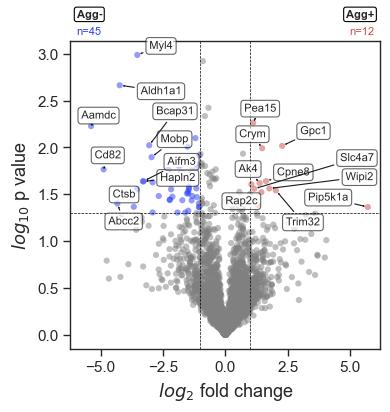

In [19]:
case_values = [{'sample': 'Agg+'}, {'sample': 'Agg-'}]

color_dict={'upregulated':"#C64D4A", 'downregulated': "#293DF5",'not_significant': "#FFFFFF6A"}

fig, ax = plt.subplots(figsize=(4, 4))
ax, volcano_df = scplt.plot_volcano(ax, pdata_1mo_cortex_norm,
                                    values=case_values,
                                    pval=0.05, return_df=True,
                                    fold_change_mode='mean', color=color_dict, label=[10,10])

ax.set_ylabel('$log_{10}$ p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# plt.show()
plt.savefig("MANUSCRIPT_revision/REVISION_FigX1moCortex_VOLCANO-directlfq.svg", bbox_inches="tight", pad_inches=0.1)
volcano_df.to_csv("MANUSCRIPT_revision/REVISION_FigX1moCortex-DE-directlfq.csv")

In [27]:
volcano_df.significance.value_counts()

significance
not significant    3395
downregulated        45
upregulated          12
not comparable        9
Name: count, dtype: int64

In [ ]:
vol_list = volcano_df[volcano_df['significance'].isin(["upregulated", "downregulated"])].Genes.to_list()

m1_sample = pd.read_csv("MANUSCRIPT_revision/REVISION_FigX-1moCortex_normalized.csv")
m1_sample_filtered = m1_sample[m1_sample['Genes'].isin(vol_list)].copy()

# map significance from volcano_df onto the filtered df via Genes
sig_map = volcano_df.set_index('Genes')['significance']
m1_sample_filtered['significance'] = m1_sample_filtered['Genes'].map(sig_map)

# sort columns, keeping the first column first and significance last
first_col = m1_sample_filtered.columns[0]
other_cols = sorted(c for c in m1_sample_filtered.columns if c not in [first_col, 'significance'])
m1_sample_filtered = m1_sample_filtered[[first_col] + other_cols + ['significance']]

m1_sample_filtered.to_csv("MANUSCRIPT_revision/REVISION_FigX-1moCortex_volcano-only.csv", index=False)

In [48]:
pdata_1mo_cortex_norm.export_layer("X", f"MANUSCRIPT_revision/REVISION_FigX-1moCortex_normalized.csv", transpose=True, var_names='Genes', obs_names='sample')

### 3mo snpc

     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=1.18e+05). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: Agg+ vs Agg-
   🔸 Group sizes: 14 vs 8 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 P-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 26 proteins were not comparable (zero or NaN mean in one group).
     ✅ DE complete. Results stored in:
       • .stats["Agg+ vs Agg-"]
       • Columns: log2fc, p_value, significance, etc.
       • Upregulated: 115 | Downregulated: 410 | Not significant: 1936 | Not comparable: 26


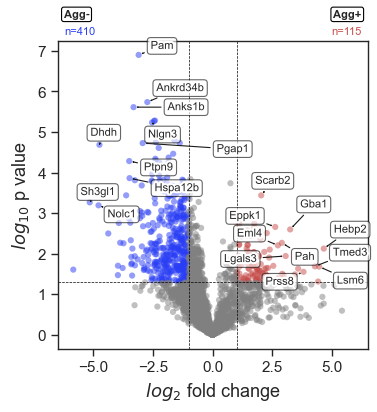

In [20]:
case_values = [{'sample': 'Agg+'}, {'sample': 'Agg-'}]

color_dict={'upregulated':"#C64D4A", 'downregulated': "#293DF5",'not_significant': "#FFFFFF6A"}

fig, ax = plt.subplots(figsize=(4, 4))
ax, volcano_df = scplt.plot_volcano(ax, pdata_3mo_snpc_norm,
                                    values=case_values,
                                    pval=0.05, return_df=True,
                                    fold_change_mode='mean', color=color_dict, label=[10,10])

ax.set_ylabel('$log_{10}$ p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# plt.show()
plt.savefig("MANUSCRIPT_revision/REVISION_FigX3moSnpc_VOLCANO-directlfq.svg", bbox_inches="tight", pad_inches=0.1)
volcano_df.to_csv("MANUSCRIPT_revision/REVISION_FigX3moSnpc-DE-directlfq.csv")

     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=1.18e+05). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: Agg+ vs Agg-
   🔸 Group sizes: 14 vs 8 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 Adj p-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 26 proteins were not comparable (zero or NaN mean in one group).
     ✅ DE complete. Results stored in:
       • .stats["Agg+ vs Agg-"]
       • Columns: log2fc, p_value, adj_p_value, significance, etc.
       • Upregulated: 16 | Downregulated: 170 | Not significant: 2275 | Not comparable: 26


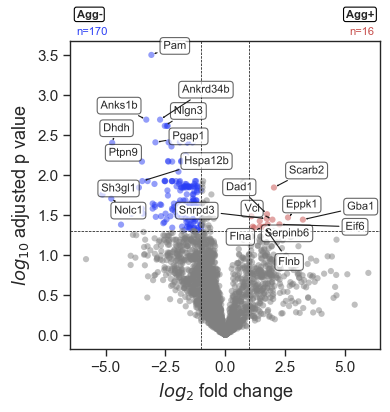

In [9]:
case_values = [{'sample': 'Agg+'}, {'sample': 'Agg-'}]

color_dict={'upregulated':"#C64D4A", 'downregulated': "#293DF5",'not_significant': "#FFFFFF6A"}

fig, ax = plt.subplots(figsize=(4, 4))
ax, volcano_df = scplt.plot_volcano(ax, pdata_3mo_snpc_norm,
                                    values=case_values,
                                    pval=0.05, return_df=True, correct_fdr=True,
                                    fold_change_mode='mean', color=color_dict, label=[10,10])

ax.set_ylabel('$log_{10}$ adjusted p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# plt.show()
# plt.savefig("MANUSCRIPT_revision/REVISION_FigX3moSnpc_VOLCANO-directlfq.svg", bbox_inches="tight", pad_inches=0.1)
volcano_df.to_csv("MANUSCRIPT_revision/REVISION_FigX3moSnpc-DE-directlfq-adjP.csv")

In [21]:
pdata_3mo_snpc_norm.export_layer("X", f"MANUSCRIPT_revision/REVISION_FigX-3moSnpc_normalized.csv", transpose=True, var_names='Genes', obs_names='sample')

In [22]:
vol_list = volcano_df[volcano_df['significance'].isin(["upregulated", "downregulated"])].Genes.to_list()

m3_sample = pd.read_csv("MANUSCRIPT_revision/REVISION_FigX-3moSnpc_normalized.csv")
m3_sample_filtered = m3_sample[m3_sample['Genes'].isin(vol_list)].copy()

# map significance from volcano_df onto the filtered df via Genes
sig_map = volcano_df.set_index('Genes')['significance']
m3_sample_filtered['significance'] = m3_sample_filtered['Genes'].map(sig_map)

# sort columns, keeping the first column first and significance last
first_col = m3_sample_filtered.columns[0]
other_cols = sorted(c for c in m3_sample_filtered.columns if c not in [first_col, 'significance'])
m3_sample_filtered = m3_sample_filtered[[first_col] + other_cols + ['significance']]

m3_sample_filtered.to_csv("MANUSCRIPT_revision/REVISION_FigX-3moSnpc_volcano-only.csv", index=False)

### 6mo snpc

     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=2.06e+05). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: Agg+ vs Agg-
   🔸 Group sizes: 12 vs 7 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 P-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 106 proteins were not comparable (zero or NaN mean in one group).
     ✅ DE complete. Results stored in:
       • .stats["Agg+ vs Agg-"]
       • Columns: log2fc, p_value, significance, etc.
       • Upregulated: 144 | Downregulated: 670 | Not significant: 1551 | Not comparable: 106


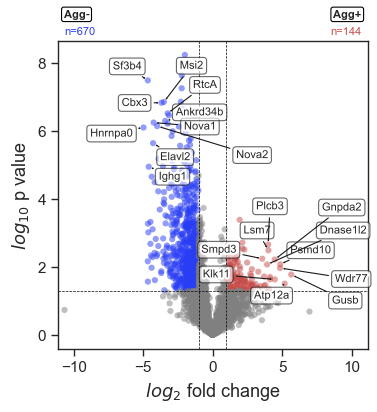

In [23]:
case_values = [{'sample': 'Agg+'}, {'sample': 'Agg-'}]

color_dict={'upregulated':"#C64D4A", 'downregulated': "#293DF5",'not_significant': "#FFFFFF6A"}

fig, ax = plt.subplots(figsize=(4, 4))
ax, volcano_df = scplt.plot_volcano(ax, pdata_6mo_snpc_norm,
                                    values=case_values,
                                    pval=0.05, return_df=True,
                                    fold_change_mode='mean', color=color_dict, label=[10,10])

ax.set_ylabel('$log_{10}$ p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# plt.show()
plt.savefig("MANUSCRIPT_revision/REVISION_FigX6moSnpc_VOLCANO-directlfq.svg", bbox_inches="tight", pad_inches=0.1)
volcano_df.to_csv("MANUSCRIPT_revision/REVISION_FigX6moSnpc-DE-directlfq.csv")

     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=2.06e+05). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: Agg+ vs Agg-
   🔸 Group sizes: 12 vs 7 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 Adj p-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 106 proteins were not comparable (zero or NaN mean in one group).
     ✅ DE complete. Results stored in:
       • .stats["Agg+ vs Agg-"]
       • Columns: log2fc, p_value, adj_p_value, significance, etc.
       • Upregulated: 38 | Downregulated: 471 | Not significant: 1856 | Not comparable: 106


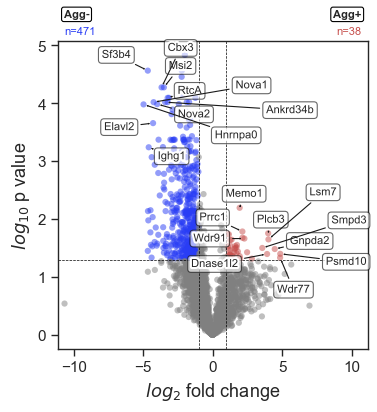

In [10]:
case_values = [{'sample': 'Agg+'}, {'sample': 'Agg-'}]

color_dict={'upregulated':"#C64D4A", 'downregulated': "#293DF5",'not_significant': "#FFFFFF6A"}

fig, ax = plt.subplots(figsize=(4, 4))
ax, volcano_df = scplt.plot_volcano(ax, pdata_6mo_snpc_norm,
                                    values=case_values,
                                    pval=0.05, return_df=True, correct_fdr=True,
                                    fold_change_mode='mean', color=color_dict, label=[10,10])

ax.set_ylabel('$log_{10}$ p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# plt.show()
# plt.savefig("MANUSCRIPT_revision/REVISION_FigX6moSnpc_VOLCANO-directlfq.svg", bbox_inches="tight", pad_inches=0.1)
volcano_df.to_csv("MANUSCRIPT_revision/REVISION_FigX6moSnpc-DE-directlfq-adjP.csv")

In [24]:
pdata_6mo_snpc_norm.export_layer("X", f"MANUSCRIPT_revision/REVISION_FigX-6moSnpc_normalized.csv", transpose=True, var_names='Genes', obs_names='sample')

In [25]:
vol_list = volcano_df[volcano_df['significance'].isin(["upregulated", "downregulated"])].Genes.to_list()

m6_sample = pd.read_csv("MANUSCRIPT_revision/REVISION_FigX-6moSnpc_normalized.csv")
m6_sample_filtered = m6_sample[m6_sample['Genes'].isin(vol_list)].copy()

# map significance from volcano_df onto the filtered df via Genes
sig_map = volcano_df.set_index('Genes')['significance']
m6_sample_filtered['significance'] = m6_sample_filtered['Genes'].map(sig_map)

# sort columns, keeping the first column first and significance last
first_col = m6_sample_filtered.columns[0]
other_cols = sorted(c for c in m6_sample_filtered.columns if c not in [first_col, 'significance'])
m6_sample_filtered = m6_sample_filtered[[first_col] + other_cols + ['significance']]

m6_sample_filtered.to_csv("MANUSCRIPT_revision/REVISION_FigX-6moSnpc_volcano-only.csv", index=False)

### DE

In [29]:
volcano_df

,Genes,Agg+,Agg-,log2fc,p_value,test_statistic,-log10(p_value),significance_score,significance
Q9JK81,Myg1,4.014739e+05,1.659699e+05,1.274384,0.023263,2.675728,1.633340,2.081504,upregulated
P97477,Aurka,4.542457e+05,1.454083e+05,1.643363,0.041249,2.589323,1.384582,2.275371,upregulated
Q9WTX2,Prkra,1.749932e+05,6.378148e+04,1.456089,0.002605,4.559971,2.584192,3.762815,upregulated
Q61239,Fnta,1.505516e+05,3.920877e+04,1.941010,0.017697,2.896454,1.752094,3.400831,upregulated
Q9D164,Fxyd6,1.383290e+05,6.102054e+04,1.180737,0.005835,3.488786,2.233971,2.637732,upregulated
...,...,...,...,...,...,...,...,...,...
Q91VM5,Rbmxl1,1.176664e+06,1.783671e+06,-0.600146,0.282451,-1.106199,0.549058,-0.329515,not significant
P47955,Rplp1,NaN,4.321081e+03,NaN,NaN,NaN,NaN,NaN,not comparable
Q6P3A8,Bckdhb,NaN,1.871333e+04,NaN,NaN,NaN,NaN,NaN,not comparable
P70671,Irf3,NaN,5.369760e+02,NaN,NaN,NaN,NaN,NaN,not comparable


In [34]:
rpl_list, rpl_top5, rpl_others = extract_gene_group(volcano_df, prefixes=["R"])

rpl_list

[]

rpl_list:  0
rps_list:  0
     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=1.80e+05). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: Agg+ vs Agg-
   🔸 Group sizes: 12 vs 10 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 P-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 4 proteins were not comparable (zero or NaN mean in one group).


G:\Users\srpang\Dropbox (Personal)\4. Caltech Work\Research\Chou-Roukes Group\scviz_git\src\scpviz\pAnnData\analysis.py:356: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = ttest_ind(x1, x2, equal_var=equal_var, nan_policy='omit')


     ✅ DE complete. Results stored in:
       • .stats["Agg+ vs Agg-"]
       • Columns: log2fc, p_value, significance, etc.
       • Upregulated: 22 | Downregulated: 26 | Not significant: 3409 | Not comparable: 4


IndexError: list index out of range

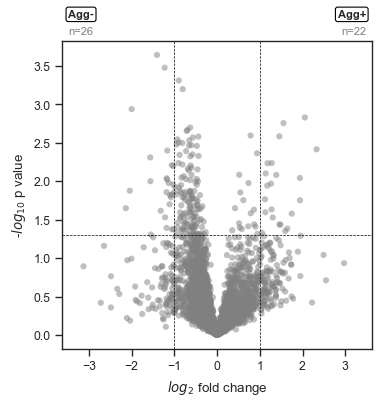

In [30]:
## RPL/RPS
rpl_list, rpl_top5, rpl_others = extract_gene_group(volcano_df, prefixes=["Rpl"])
rps_list, rps_top5, rps_others = extract_gene_group(volcano_df, prefixes=["Rps"])

print("rpl_list: ", len(rpl_list))
print("rps_list: ", len(rps_list))

case_values = [{'sample': 'Agg+'}, {'sample': 'Agg-'}]

color_dict={'upregulated':"#C64D4A", 'downregulated': "#293DF5",'not_significant': "#FFFFFF6A"}
rps_dict={'downregulated': '#5166FF', 'upregulated': "#C26A69"}
rpl_dict={'downregulated': '#1F2CCF', 'upregulated': "#CA2927"}

fig, ax = plt.subplots(figsize=(4, 4))
ax, volcano_df = scplt.plot_volcano(ax, pdata_1mo_cortex_filter,
                                    values=case_values,
                                    pval=0.05, return_df=True,
                                    fold_change_mode='mean', no_marks=True)

texts = []
ax, t = scplt.mark_volcano_by_significance(ax, volcano_df, label=rpl_list, color=rpl_dict,return_texts=True)
texts.extend(t)
ax, t = scplt.mark_volcano_by_significance(ax, volcano_df, label=rps_list, color=rps_dict,return_texts=True)
texts.extend(t)

scplt.volcano_adjust_and_outline_texts(texts, expand=(2,2))

ax.set_ylabel('$log_{10}$ p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# plt.show()
# plt.savefig("MANUSCRIPT_revision/REVISION_FigX6moCortex_VOLCANO-directlfq-RplRps.svg", bbox_inches="tight", pad_inches=0.1)


proteasome_list:  1
     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=1.80e+05). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: Agg+ vs Agg-
   🔸 Group sizes: 12 vs 10 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 P-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 4 proteins were not comparable (zero or NaN mean in one group).


G:\Users\srpang\Dropbox (Personal)\4. Caltech Work\Research\Chou-Roukes Group\scviz_git\src\scpviz\pAnnData\analysis.py:356: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = ttest_ind(x1, x2, equal_var=equal_var, nan_policy='omit')


     ✅ DE complete. Results stored in:
       • .stats["Agg+ vs Agg-"]
       • Columns: log2fc, p_value, significance, etc.
       • Upregulated: 22 | Downregulated: 26 | Not significant: 3409 | Not comparable: 4


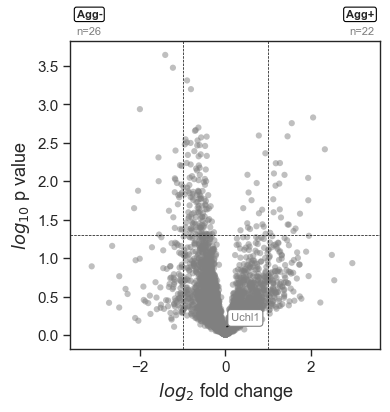

In [36]:
## Proteasome
proteasome_list, proteasome_top5, proteasome_others = extract_gene_group(volcano_df, prefixes=["psm"])
proteasome_list.append('Uchl1')

print("proteasome_list: ", len(proteasome_list))

case_values = [{'sample': 'Agg+'}, {'sample': 'Agg-'}]

color_dict={'upregulated':"#C64D4A", 'downregulated': "#293DF5",'not_significant': "#FFFFFF6A"}

fig, ax = plt.subplots(figsize=(4, 4))
ax, volcano_df = scplt.plot_volcano(ax, pdata_1mo_cortex_filter,
                                    values=case_values,
                                    pval=0.05, return_df=True,
                                    fold_change_mode='mean', no_marks=True)

texts = []
ax, t = scplt.mark_volcano_by_significance(ax, volcano_df, label=proteasome_list, color=color_dict, return_texts=True)
texts.extend(t)
scplt.volcano_adjust_and_outline_texts(texts, expand=(2, 2))
# scplt.mark_volcano_by_significance(ax, volcano_df, label=proteasome_top5, color=color_dict)
# scplt.mark_volcano_by_significance(ax, volcano_df, label=proteasome_others, color=color_dict, show_names=False)

ax.set_ylabel('$log_{10}$ p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

plt.show()
# plt.savefig("MANUSCRIPT_revision/REVISION_FigX6moCortex_VOLCANO-directlfq-Proteasome.svg", bbox_inches="tight", pad_inches=0.1)

     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=1.70e+05). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: Agg+ vs Agg-
   🔸 Group sizes: 12 vs 11 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 P-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 361 proteins were not comparable (zero or NaN mean in one group).


G:\Users\srpang\Dropbox (Personal)\4. Caltech Work\Research\Chou-Roukes Group\scviz_git\src\scpviz\pAnnData\analysis.py:356: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = ttest_ind(x1, x2, equal_var=equal_var, nan_policy='omit')


     ✅ DE complete. Results stored in:
       • .stats["Agg+ vs Agg-"]
       • Columns: log2fc, p_value, significance, etc.
       • Upregulated: 492 | Downregulated: 129 | Not significant: 3411 | Not comparable: 361


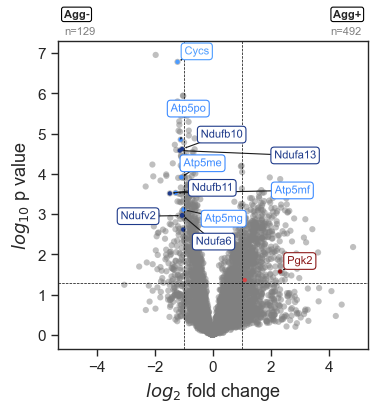

In [ ]:
## Mitochondria

mito_groups = {
    "complex5":   ["atp5"],
    "complex4":   ["cox"],
    "complex1":   ["nduf"],
    "complex2":   ["sdh"],
    "complex3":   ["uqcr"],
    "mito_other": ["cyc1", "cycs", "pgk", "vdac"],
}

mito_results = {}

for group_name, prefixes in mito_groups.items():
    gene_list, top5, others = extract_gene_group(volcano_df, prefixes)
    mito_results[group_name] = {
        "list": gene_list,
        "top5": top5,
        "others": others,
    }

mito_color_dict = {
    "complex1": {     # NDUF*
        "upregulated":   "#D64545",   # strong red
        "downregulated": "#1E3A8A",   # deep indigo blue
    },
    "complex2": {     # SDH*
        "upregulated":   "#C03636",   # darker red
        "downregulated": "#1F4DA0",   # strong royal blue
    },
    "complex3": {     # UQCR*
        "upregulated":   "#B42E2E",   # deep cherry
        "downregulated": "#2665C2",   # vivid blue
    },
    "complex4": {     # COX*
        "upregulated":   "#A82828",   # wine red
        "downregulated": "#2D7AE6",   # bright azure
    },
    "complex5": {     # ATP5*
        "upregulated":   "#9E2020",   # maroon
        "downregulated": "#3D8BFF",   # clear blue
    },
    "mito_other": {
        "upregulated":   "#8C1A1A",   # dark brick red
        "downregulated": "#4C9CFF",   # lighter but still strong blue
    },
}

## Mitochondria, all together

case_values = [{'sample': 'Agg+'}, {'sample': 'Agg-'}]

color_dict={'upregulated':"#C64D4A", 'downregulated': "#293DF5",'not_significant': "#FFFFFF6A"}

fig, ax = plt.subplots(figsize=(4, 4))
ax, volcano_df = scplt.plot_volcano(ax, pdata_6mo_cortex_filter,
                                    values=case_values,
                                    pval=0.05, return_df=True,
                                    fold_change_mode='mean', no_marks=True)

texts = []
for group_name, d in mito_results.items():
    colors = mito_color_dict[group_name]

    if len(d["top5"]) > 0:
        # highlight top 5 (with names)
        ax, t = scplt.mark_volcano_by_significance(
            ax, volcano_df,
            label=d["top5"],
            color=colors,
            return_texts=True,
        )

        texts.extend(t)

    if len(d["others"]) > 0:
        # highlight the others (no names)
        scplt.mark_volcano_by_significance(
            ax, volcano_df,
            label=d["others"],
            color=colors,
            show_names=False,
        )

scplt.volcano_adjust_and_outline_texts(texts, expand=(2,2))

ax.set_ylabel('$log_{10}$ p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

plt.show()
# plt.savefig("MANUSCRIPT_revision/REVISION_FigX6moCortex_VOLCANO-directlfq-MitoAll.svg", bbox_inches="tight", pad_inches=0.1)

# power analysis

## for current manuscript

### dataset prep

In [3]:
import os

# obs_columns = ['date', 'acquisition', 'sample_id','size','confirmation','thickness','type','organism','region','well_position']
pdata_all_region = pAnnData.import_data(source_type='diann',report_file = 'data/2505_rna_prot_full/report.tsv')

# data clean-up | uses file_annotation.csv to help with annotations

file_annotation = pd.read_csv('abc_analysis/file_annotation.csv')

file_annotation["parsed_filename"] = (
    file_annotation["RAW FILE"]
    .apply(os.path.basename)
    .str.replace(".raw", "", regex=False)
)

summary = pdata_all_region.summary

summary_files = set(summary.index)
annotation_files = set(file_annotation["parsed_filename"])
missing_in_summary = annotation_files - summary_files
missing_in_annotation = summary_files - annotation_files
pdata_all_region_filtered = pdata_all_region.filter_sample(exclude_file_list=list(missing_in_annotation))

fa_sub = file_annotation[["parsed_filename", "File Name", "Grouping", "Sub grouping", "Region", "Batch"]]
fa_sub = fa_sub.set_index("parsed_filename")
fa_aligned = fa_sub.reindex(pdata_all_region_filtered.summary.index)
cols_to_add = ["File Name", "Grouping", "Sub grouping", "Region", "Batch"]
pdata_all_region_filtered.summary[cols_to_add] = fa_aligned[cols_to_add]

pdata_all_region_filtered.update_summary()

pd.DataFrame(pdata_all_region_filtered.summary)

🧭 [USER] Importing data of type [diann]
      Auto-detecting '_' as delimiter from first filename.
     ⚠️ [WARN] 3 different filename formats detected. Proceeding with fallback `.obs` structure... (File Number, Parsing Type)
--------------------------
Starting import [DIA-NN]

Source file: data/2505_rna_prot_full/report.tsv
Number of files: 138
Proteins: 4465
Peptides: 46332

ℹ️ 13 proteins with missing gene names.
     🌐 [API] Querying UniProt for batch 1/1 (13 proteins) [fields: accession, gene_primary]
     ✅ Retrieved UniProt metadata for 2 entries.
     ⚠️ [WARN] 13 gene name(s) still missing. Assigned as 'UNKNOWN_<accession>' for:
         Q8R092, Q8C3W1, P01664, Q9CYI0, Q91V76...
     💡 Tip: You can update these using `pdata.update_identifier_maps({'GENE': 'ACCESSION'}, on='protein', direction='reverse', overwrite=True)`

     ℹ️ [INFO] Using sample-specific q-values for 'prot' significance annotation.
     ℹ️ [INFO] Using sample-specific q-values for 'pep' significance annotat

,File,parsingType,protein_quant,protein_count,protein_abundance_sum,File Name,Grouping,Sub grouping,Region,Batch,peptide_quant,peptide_count,peptide_abundance_sum,unique_pep2_protein_count
20240425_Aur60minDIA_sc_H2O35_02,10,5-tokens,0.329849,1357,1.244563e+09,ctx_6,ctx,none,Cortex,Apr-24,0.125902,5774,2.375132e+09,1337
20240418_Aur60minDIA_sc_TEAB35_05,11,5-tokens,0.404473,1664,1.138149e+09,ctx_5,ctx,none,Cortex,Apr-24,0.161423,7403,2.624281e+09,1641
20240418_Aur60minDIA_sc_T235_03,12,5-tokens,0.521147,2144,5.282213e+08,ctx_2,ctx,none,Cortex,Apr-24,0.245873,11276,1.525687e+09,2092
20240824_Aur60minDIA_S18_TH+-Anxa1+_Y2_slide9-10_1b_Mus_SNpc_E5,13,10-tokens,0.466942,1921,1.629439e+09,snpc/anxa_B_2,snpc,anxaY,Anxa_B,Aug-24,0.184536,8463,4.437718e+09,1852
20240601_Aur60minDIA_S12_astrocyte_J15,16,5-tokens,0.630044,2592,1.581879e+09,ast_5,ast,none,Astrocyte,Jun-24,0.296984,13620,5.241523e+09,2501
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20240824_Aur60minDIA_S11_TH+only_Y2_slide9-10_2b_Mus_SNpc_D6,125,10-tokens,0.297764,1225,2.139126e+09,snpc/non-anxa_B_2,snpc,anxaN,TH_B,Aug-24,0.102876,4718,4.483924e+09,1198
20240601_Aur60minDIA_S12_astrocyte_J11,127,5-tokens,0.479582,1973,2.441936e+09,ast_2,ast,none,Astrocyte,Jun-24,0.190423,8733,4.660247e+09,1920
20240824_Aur60minDIA_S4_TH+-Anxa1+_Y2_slide9-10_2b_Mus_SNpc_C7,129,10-tokens,0.363636,1496,2.375438e+09,snpc/anxa_B_8,snpc,anxaY,Anxa_B,Aug-24,0.132705,6086,4.003753e+09,1442
20250429_Aur60minDIA_AA42_800_Y2_35um_GAD-_Mus_Cortex_G5,130,10-tokens,0.351240,1445,2.133190e+09,ctx/noGAD_5,ctx,GADN,GAD_no,Apr-25,0.125662,5763,4.646348e+09,1401


In [4]:
pdata_6mo_diann_base = pAnnData.import_data(source_type='diann', report_file = 'data/2511_Mus6moSnpcONLY/report.parquet')

colnames = [
    'date',
    'gradient',
    'sample_id',
    'size',
    'confirmation',
    'thickness',
    'sample',
    'organism',
    'region',
    'well_position'
]

# ignore 11-token parsing type on both
pdata_6mo_diann = pdata_6mo_diann_base.filter_sample(condition='parsingType == "10-tokens"')
pdata_6mo_diann.summary = scutils.parse_filename_index(pdata_6mo_diann.summary, colnames)

pdata_6mo_processed = pdata_6mo_diann.filter_prot_significant()

pdata_6mo_snpc = pdata_6mo_processed.filter_sample(condition='region == "snpc"')
pdata_6mo_snpc = pdata_6mo_snpc.filter_sample(min_prot=1000)
pdata_6mo_snpc.summary["sample"] = pdata_6mo_snpc.summary["sample"].replace({
    "6mo-aggY": "Agg+",
    "6mo-aggN": "Agg-"
})
pdata_6mo_snpc.update_summary()

pdata_6mo_snpc_filter = pdata_6mo_snpc.copy()
pdata_6mo_snpc_filter = pdata_6mo_snpc_filter.filter_prot_found(min_ratio=0.4, group=['sample'],match_any=True)
pdata_6mo_snpc_filter = pdata_6mo_snpc_filter.filter_prot(valid_genes=True, unique_profiles=True)
pdata_6mo_snpc_filter = pdata_6mo_snpc_filter.filter_sample(min_prot=1000)
# pdata_6mo_snpc.impute(method='min', min_scale=0.2)

pdata_6mo_snpc_norm = pdata_6mo_snpc_filter.copy()
pdata_6mo_snpc_norm.normalize(method='directlfq')
# pdata_6mo_snpc_norm = pdata_6mo_snpc_norm.filter_sample(min_prot=1000)

pdata_6mo_snpc_norm.summary['sample'].value_counts()

🧭 [USER] Importing data of type [diann]
      Auto-detecting '_' as delimiter from first filename.
     ⚠️ [WARN] 2 different filename formats detected. Proceeding with fallback `.obs` structure... (File Number, Parsing Type)
--------------------------
Starting import [DIA-NN]

Source file: data/2511_Mus6moSnpcONLY/report.parquet
Number of files: 36
Proteins: 7848
Peptides: 43076

     ℹ️ [INFO] Using sample-specific q-values for 'prot' significance annotation.
     ℹ️ [INFO] Using sample-specific q-values for 'pep' significance annotation.

ℹ️ RS matrix: (7848, 43076) (proteins × peptides), sparsity: 99.98%
   - Proteins with ≥2 *unique* linked peptides: 3666/7848
   - Peptides linked to ≥2 proteins: 7445/43076
   - Mean peptides per protein: 6.89
   - Mean proteins per peptide: 1.26
     ✅ [OK] pAnnData object is valid.
     ✅ [OK] Import complete. Use `print(pdata)` to view the object.
--------------------------
🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample 

2026-07-28 00:18:53,770 - directlfq.lfq_manager - INFO - Starting directLFQ analysis.
2026-07-28 00:18:54,001 - directlfq.lfq_manager - INFO - Performing sample normalization.
2026-07-28 00:18:56,694 - directlfq.lfq_manager - INFO - Estimating lfq intensities.
2026-07-28 00:18:56,698 - directlfq.protein_intensity_estimation - INFO - 2350 lfq-groups total
2026-07-28 00:18:58,008 - directlfq.protein_intensity_estimation - INFO - using 12 processes
2026-07-28 00:19:11,811 - directlfq.lfq_manager - INFO - Could not add additional columns to protein table, printing without additional columns.
2026-07-28 00:19:11,812 - directlfq.lfq_manager - INFO - Writing results files.
2026-07-28 00:19:12,306 - directlfq.lfq_manager - INFO - Analysis finished!


     ℹ️ Set protein data to layer X_norm_directlfq.
     ✅ directlfq normalization complete. Results are stored in layer 'X_norm_directlfq'.
          ⚠️ Downstream imputation should be performed with the flag `use_zeros_as_nan` set to True due to directlfq output format returning NaNs as 0s.


sample
Agg+    12
Agg-     7
Name: count, dtype: int64

In [15]:
pdata_fig2_region_filter = pdata_all_region_filtered.filter_prot_significant()
pdata_fig2_region_filter = pdata_fig2_region_filter.filter_sample(condition="Grouping != 'ast'")
pdata_fig2_region_filter = pdata_fig2_region_filter.filter_sample(min_prot=1000)

pdata_fig2_region_filter.summary["region"] = pdata_fig2_region_filter.summary["Grouping"].replace({
    "snpc": "SNpc",
    "ctx": "Cortex"
})
pdata_fig2_region_filter.update_summary()

pdata_fig2_region_processed = pdata_fig2_region_filter.copy()
pdata_fig2_region_processed = pdata_fig2_region_processed.filter_prot_found(min_ratio=0.4, group = ['Grouping'], match_any=True)
pdata_fig2_region_processed = pdata_fig2_region_processed.filter_prot(valid_genes=True, unique_profiles=True)

pdata_fig2_region_norm = pdata_fig2_region_processed.copy()
pdata_fig2_region_norm.normalize(method='directlfq')

🧭 [USER] Filtering proteins [Significance|File-mode]:
     ℹ️ [INFO] No group provided. Defaulting to sample-level significance filtering.
    Returning a copy of protein data based on significance thresholds:
     🔸 Files requested: All
     🔸 FDR threshold: 0.01
     🔸 Logic: any (protein must be significant in ≥1 file(s))
    → Proteins kept: 4026, Proteins dropped: 88
     ✅ [OK] RS matrix filtered: 4026 proteins, 45593 peptides retained.

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: Grouping != 'ast'
     ℹ️ Auto-cleanup: Removed 21 empty proteins (all-NaN or all-zero). Proteins: Q6NZB0, Q80UK0, Q60714, P13864, Q8R502, Q8CI61, Q8VDS4, Q6DFY8, P50153, Q8R2T8, ...
    → Samples kept: 100, Samples dropped: 5
    → Proteins kept: 4005

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: protein_count >= 1000
     ℹ️ Auto-cleanup: No empty proteins found (a

2026-07-28 00:40:55,727 - directlfq.lfq_manager - INFO - Starting directLFQ analysis.
2026-07-28 00:40:56,252 - directlfq.lfq_manager - INFO - Performing sample normalization.
2026-07-28 00:40:56,412 - directlfq.normalization - INFO - to few values for normalization without missing values. Including missing values
2026-07-28 00:40:57,940 - directlfq.lfq_manager - INFO - Estimating lfq intensities.
2026-07-28 00:40:57,944 - directlfq.protein_intensity_estimation - INFO - 2371 lfq-groups total
2026-07-28 00:40:59,099 - directlfq.protein_intensity_estimation - INFO - using 12 processes
2026-07-28 00:41:26,425 - directlfq.lfq_manager - INFO - Could not add additional columns to protein table, printing without additional columns.
2026-07-28 00:41:26,426 - directlfq.lfq_manager - INFO - Writing results files.
2026-07-28 00:41:29,749 - directlfq.lfq_manager - INFO - Analysis finished!


     ℹ️ Set protein data to layer X_norm_directlfq.
     ✅ directlfq normalization complete. Results are stored in layer 'X_norm_directlfq'.
          ⚠️ Downstream imputation should be performed with the flag `use_zeros_as_nan` set to True due to directlfq output format returning NaNs as 0s.


In [5]:
pdata_fig3_snpc_filter = pdata_all_region_filtered.filter_sample(condition ='Grouping == "snpc"')
pdata_fig3_snpc_filter = pdata_fig3_snpc_filter.filter_sample(condition = 'Batch == "Apr-25"')
pdata_fig3_snpc_filter = pdata_fig3_snpc_filter.filter_prot_significant()
pdata_fig3_snpc_filter = pdata_fig3_snpc_filter.filter_sample(min_prot=1000)

pdata_fig3_snpc_filter.summary["cell_type"] = pdata_fig3_snpc_filter.summary["Sub grouping"].replace({
    "anxaY": "Anxa+",
    "anxaN": "Anxa-"
})
pdata_fig3_snpc_filter.update_summary()

pdata_fig3_snpc_processed = pdata_fig3_snpc_filter.copy()
pdata_fig3_snpc_processed = pdata_fig3_snpc_processed.filter_prot_found(min_ratio=0.4, group = ['Sub grouping'], match_any=True)
pdata_fig3_snpc_processed = pdata_fig3_snpc_processed.filter_prot(valid_genes=True, unique_profiles=True)

pdata_fig3_snpc_norm = pdata_fig3_snpc_processed.copy()
pdata_fig3_snpc_norm.normalize(method='directlfq')

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: Grouping == "snpc"
     ℹ️ Auto-cleanup: Removed 128 empty proteins (all-NaN or all-zero). Proteins: Q9CPP0, Q6NZB0, Q9D289, Q80UK0, Q9DB75, P63024, Q5DU31, Q60847, Q80TL1, P11157, ...
    → Samples kept: 60, Samples dropped: 45
    → Proteins kept: 3986

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: Batch == "Apr-25"
     ℹ️ Auto-cleanup: Removed 134 empty proteins (all-NaN or all-zero). Proteins: B1AZI6, Q6P5G6, Q9CR41, Q99L88, Q9R1J0, Q9JKY0, Q8R1H0, Q9CQU3, Q7M753, Q8BJZ4, ...
    → Samples kept: 33, Samples dropped: 27
    → Proteins kept: 3852

🧭 [USER] Filtering proteins [Significance|File-mode]:
     ℹ️ [INFO] No group provided. Defaulting to sample-level significance filtering.
    Returning a copy of protein data based on significance thresholds:
     🔸 Files requested: All
     🔸 FDR threshold: 0

2026-07-28 00:19:16,309 - directlfq.lfq_manager - INFO - Starting directLFQ analysis.
2026-07-28 00:19:16,640 - directlfq.lfq_manager - INFO - Performing sample normalization.
2026-07-28 00:19:16,682 - directlfq.lfq_manager - INFO - Estimating lfq intensities.
2026-07-28 00:19:16,686 - directlfq.protein_intensity_estimation - INFO - 2729 lfq-groups total
2026-07-28 00:19:18,457 - directlfq.protein_intensity_estimation - INFO - using 12 processes
2026-07-28 00:19:36,749 - directlfq.lfq_manager - INFO - Could not add additional columns to protein table, printing without additional columns.
2026-07-28 00:19:36,750 - directlfq.lfq_manager - INFO - Writing results files.
2026-07-28 00:19:37,855 - directlfq.lfq_manager - INFO - Analysis finished!


     ℹ️ Set protein data to layer X_norm_directlfq.
     ✅ directlfq normalization complete. Results are stored in layer 'X_norm_directlfq'.
          ⚠️ Downstream imputation should be performed with the flag `use_zeros_as_nan` set to True due to directlfq output format returning NaNs as 0s.


In [6]:
# take subset of data from pdata_all_region_filtered

pdata_fig4_region_filtered = pdata_all_region_filtered.filter_prot_significant()
pdata_fig4_region_filtered = pdata_fig4_region_filtered.filter_sample(condition="Grouping != 'snpc'")
pdata_fig4_region_filtered = pdata_fig4_region_filtered.filter_sample(condition="Batch != 'Apr-25'")

mapping = {
    "ctx": "Neuron",
    "ast": "Astrocyte",
}
pdata_fig4_region_filtered.summary["cell_type"] = pdata_fig4_region_filtered.summary["Grouping"].replace(mapping)
pdata_fig4_region_filtered.update_summary()

pdata_fig4_region_processed = pdata_fig4_region_filtered.copy()
pdata_fig4_region_processed = pdata_fig4_region_processed.filter_sample(min_prot=1800)

pdata_fig4_region_processed = pdata_fig4_region_processed.filter_prot_found(min_ratio=0.4, group = ['cell_type'], match_any=True)
pdata_fig4_region_processed = pdata_fig4_region_processed.filter_prot(valid_genes=True, unique_profiles=True)

pdata_fig4_region_norm = pdata_fig4_region_processed.copy()
pdata_fig4_region_norm.normalize(method='directlfq')

print(pdata_fig4_region_norm.summary['Grouping'].value_counts())
print(pdata_fig4_region_norm.summary['Batch'].value_counts())
print(pdata_fig4_region_norm.summary['cell_type'].value_counts())

🧭 [USER] Filtering proteins [Significance|File-mode]:
     ℹ️ [INFO] No group provided. Defaulting to sample-level significance filtering.
    Returning a copy of protein data based on significance thresholds:
     🔸 Files requested: All
     🔸 FDR threshold: 0.01
     🔸 Logic: any (protein must be significant in ≥1 file(s))
    → Proteins kept: 4026, Proteins dropped: 88
     ✅ [OK] RS matrix filtered: 4026 proteins, 45593 peptides retained.

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: Grouping != 'snpc'
     ℹ️ Auto-cleanup: Removed 239 empty proteins (all-NaN or all-zero). Proteins: Q9CWG9, B1AZI6, Q6P5G6, Q99PW4, A2ASI5, Q9D1F4, Q99L88, O70566, Q3V4B5, Q9R1J0, ...
    → Samples kept: 45, Samples dropped: 60
    → Proteins kept: 3787

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: Batch != 'Apr-25'
     ℹ️ Auto-cleanup: Removed 82 empty proteins (a

2026-07-28 00:19:41,946 - directlfq.lfq_manager - INFO - Starting directLFQ analysis.
2026-07-28 00:19:42,261 - directlfq.lfq_manager - INFO - Performing sample normalization.
2026-07-28 00:19:42,282 - directlfq.lfq_manager - INFO - Estimating lfq intensities.
2026-07-28 00:19:42,287 - directlfq.protein_intensity_estimation - INFO - 2866 lfq-groups total
2026-07-28 00:19:44,062 - directlfq.protein_intensity_estimation - INFO - using 12 processes
2026-07-28 00:19:59,030 - directlfq.lfq_manager - INFO - Could not add additional columns to protein table, printing without additional columns.
2026-07-28 00:19:59,031 - directlfq.lfq_manager - INFO - Writing results files.
2026-07-28 00:20:00,045 - directlfq.lfq_manager - INFO - Analysis finished!


     ℹ️ Set protein data to layer X_norm_directlfq.
     ✅ directlfq normalization complete. Results are stored in layer 'X_norm_directlfq'.
          ⚠️ Downstream imputation should be performed with the flag `use_zeros_as_nan` set to True due to directlfq output format returning NaNs as 0s.
Grouping
ctx    14
ast     5
Name: count, dtype: int64
Batch
Jun-24    13
Apr-24     4
Nov-24     2
Name: count, dtype: int64
cell_type
Neuron       14
Astrocyte     5
Name: count, dtype: int64


In [7]:
obs_columns = ['date', 'acquisition', 'size', 'cell_type', 'replicate']

pdata_fig4_swi = pAnnData.import_data(source_type='diann', report_file = 'data/2511_ast-SWI-only/report.parquet', obs_columns=obs_columns)
pdata_fig4_swi_filtered = pdata_fig4_swi.filter_sample(condition="cell_type not in ['T2','TEAB35']")
pdata_fig4_swi_filtered = pdata_fig4_swi_filtered.filter_prot_significant()
pdata_fig4_swi_filtered = pdata_fig4_swi_filtered.filter_sample(min_prot=1000)

mapping = {
    "scartissue": "SWI",
    "astrocyte": "Uninjured",
}
pdata_fig4_swi_filtered.summary["condition"] = pdata_fig4_swi_filtered.summary["cell_type"].replace(mapping)
pdata_fig4_swi_filtered.update_summary()

pdata_fig4_swi_processed = pdata_fig4_swi_filtered.copy()
pdata_fig4_swi_processed = pdata_fig4_swi_processed.filter_prot_found(min_ratio=0.4, group = ['condition'], match_any=True)
pdata_fig4_swi_processed = pdata_fig4_swi_processed.filter_prot(valid_genes=True, unique_profiles=True)

pdata_fig4_swi_norm = pdata_fig4_swi_processed.copy()
pdata_fig4_swi_norm.normalize(method='directlfq')

🧭 [USER] Importing data of type [diann]
--------------------------
Starting import [DIA-NN]

Source file: data/2511_ast-SWI-only/report.parquet
Number of files: 20
Proteins: 8678
Peptides: 69299



c:\Users\srpang\anaconda3\envs\py311-dev\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


     ℹ️ [INFO] Using sample-specific q-values for 'prot' significance annotation.
     ℹ️ [INFO] Using sample-specific q-values for 'pep' significance annotation.

ℹ️ RS matrix: (8678, 69299) (proteins × peptides), sparsity: 99.99%
   - Proteins with ≥2 *unique* linked peptides: 4452/8678
   - Peptides linked to ≥2 proteins: 9794/69299
   - Mean peptides per protein: 9.63
   - Mean proteins per peptide: 1.21
     ✅ [OK] pAnnData object is valid.
     ✅ [OK] Import complete. Use `print(pdata)` to view the object.
--------------------------
🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: cell_type not in ['T2','TEAB35']
     ℹ️ Auto-cleanup: Removed 3228 empty proteins (all-NaN or all-zero). Proteins: O35226-4, E9Q4N7, Q6PD26, Q91ZP6, Q8R3H9, P97868, P97868-2, Q3U1F9, Q8C196, P46662, ...
    → Samples kept: 11, Samples dropped: 9
    → Proteins kept: 5450

🧭 [USER] Filtering proteins [Significance|File-mode]:
     ℹ️ [INFO

2026-07-28 00:20:06,057 - directlfq.lfq_manager - INFO - Starting directLFQ analysis.
2026-07-28 00:20:06,376 - directlfq.lfq_manager - INFO - Performing sample normalization.
2026-07-28 00:20:06,385 - directlfq.lfq_manager - INFO - Estimating lfq intensities.
2026-07-28 00:20:06,389 - directlfq.protein_intensity_estimation - INFO - 3192 lfq-groups total
2026-07-28 00:20:07,771 - directlfq.protein_intensity_estimation - INFO - using 12 processes
2026-07-28 00:20:22,476 - directlfq.lfq_manager - INFO - Could not add additional columns to protein table, printing without additional columns.
2026-07-28 00:20:22,477 - directlfq.lfq_manager - INFO - Writing results files.
2026-07-28 00:20:22,831 - directlfq.lfq_manager - INFO - Analysis finished!


     ℹ️ Set protein data to layer X_norm_directlfq.
     ✅ directlfq normalization complete. Results are stored in layer 'X_norm_directlfq'.
          ⚠️ Downstream imputation should be performed with the flag `use_zeros_as_nan` set to True due to directlfq output format returning NaNs as 0s.


### analysis

c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Agg+ vs Agg- (n=12 vs 7): 2071 proteins with valid within-group SD  | median SD = 0.839  | IQR = [0.678, 1.054]  | median obs = 9/12, 7/7
Anxa1+ vs Anxa1- (n=18 vs 15): 2693 proteins with valid within-group SD  | median SD = 0.634  | IQR = [0.476, 0.832]  | median obs = 15/18, 14/15
Neuron vs Astrocyte (n=14 vs 5): 2540 proteins with valid within-group SD  | median SD = 0.717  | IQR = [0.533, 0.992]  | median obs = 12/14, 5/5
SWI vs Control Astrocyte (n=5 vs 5): 2195 proteins with valid within-group SD  | median SD = 0.622  | IQR = [0.463, 0.867]  | median obs = 4/5, 5/5
Cortex vs SNpc (n=40 vs 60): 2354 proteins with valid within-group SD  | median SD = 0.789  | IQR = [0.653, 0.987]  | median obs = 29/40, 49/60

Agg+ vs Agg-
  log2FC = 0.25  →  power = 0.038
  log2FC = 0.50  →  power = 0.085
  log2FC = 0.75  →  power = 0.201
  log2FC = 1.00  →  power = 0.385
  log2FC = 1.50  →  power = 0.735
  log2FC = 2.00  →  power = 0.871

Anxa1+ vs Anxa1-
  log2FC = 0.25  →  power = 0.011
  log2FC

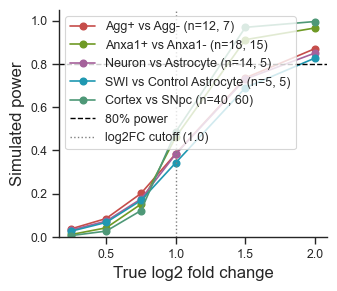

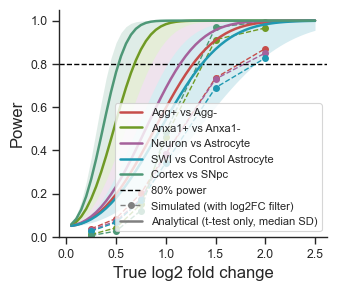

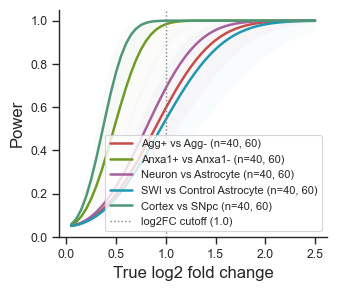

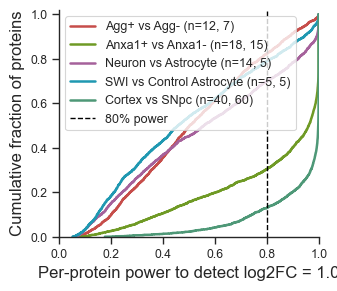


── Reviewer summary ──
Agg+ vs Agg- (n=12 vs 7): simulated power ≥ 80% from log2FC ≈ 2.0  |  power at log2FC=1.0: 0.38  |  power at log2FC=2.0: 0.87  |  17.7% of proteins ≥80% powered (t-test only) at log2FC=1.0
Anxa1+ vs Anxa1- (n=18 vs 15): simulated power ≥ 80% from log2FC ≈ 1.5  |  power at log2FC=1.0: 0.46  |  power at log2FC=2.0: 0.97  |  69.6% of proteins ≥80% powered (t-test only) at log2FC=1.0
Neuron vs Astrocyte (n=14 vs 5): simulated power ≥ 80% from log2FC ≈ 2.0  |  power at log2FC=1.0: 0.38  |  power at log2FC=2.0: 0.85  |  30.2% of proteins ≥80% powered (t-test only) at log2FC=1.0
SWI vs Control Astrocyte (n=5 vs 5): simulated power ≥ 80% from log2FC ≈ 2.0  |  power at log2FC=1.0: 0.34  |  power at log2FC=2.0: 0.83  |  21.2% of proteins ≥80% powered (t-test only) at log2FC=1.0
Cortex vs SNpc (n=40 vs 60): simulated power ≥ 80% from log2FC ≈ 1.5  |  power at log2FC=1.0: 0.49  |  power at log2FC=2.0: 1.00  |  87.1% of proteins ≥80% powered (t-test only) at log2FC=1.0


In [ ]:
from scipy import stats
from scipy.sparse import issparse
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.stats.power import TTestIndPower

COMPARISONS = {
    "Agg+ vs Agg-": (
        pdata_6mo_snpc_norm,   # pdata object
        "sample",              # obs column
        "Agg+",                # group 1 label
        "Agg-",                # group 2 label
    ),
    "Anxa1+ vs Anxa1-": (
        pdata_fig3_snpc_norm,     
        "cell_type",           
        "Anxa+",              
        "Anxa-",              
    ),
    "Neuron vs Astrocyte": (
        pdata_fig4_region_norm,  
        "cell_type",           
        "Neuron",             
        "Astrocyte",          
    ),
    "SWI vs Control Astrocyte": (
        pdata_fig4_swi_norm,        
        "condition",           
        "SWI",                
        "Uninjured",           
    ),
    "Cortex vs SNpc": (
        pdata_fig2_region_norm,        
        "region",           
        "Cortex",                
        "SNpc",           
    ),
}

EFFECT_SIZES  = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
FC_GRID       = np.linspace(0.05, 2.5, 50)
N_SIM         = 5000
P_THRESH      = 0.05
LOG2FC_CUTOFF = 1.0
POWER_TARGET  = 0.80
RNG           = np.random.default_rng(42)

EQUAL_VAR = True   # pooled variance – matches the analytical power model

analysis = TTestIndPower()

# Helpers 

from dataclasses import dataclass

@dataclass
class CompVar:
    """Per-comparison variance structure for power analysis.

    Attributes:
    - sd: Pooled within-group SD, retained proteins only.
    - n1_prot: Observed count in group 1, per retained protein.
    - n2_prot: Observed count in group 2, per retained protein.
    - n1: Design size of group 1, i.e. all samples in the group.
    - n2: Design size of group 2.
    """
    sd: np.ndarray
    n1_prot: np.ndarray
    n2_prot: np.ndarray
    n1: int
    n2: int

def extract_dense(pdata_obj, sample_mask):
    """Log2 abundance matrix (n_samples, n_proteins); zeros → NaN."""
    X = pdata_obj.prot.X[sample_mask, :]
    if issparse(X):
        X = X.toarray()
    X = X.astype(float)
    X[X == 0] = np.nan
    return np.log2(X)

def pooled_within_sd(X1, X2):
    """Pooled within-group SD per protein, so between-group signal does not
    inflate sigma. Per-protein n accounts for differing missingness.

    Args:
        X1: (n1, n_proteins) log2 array for group 1.
        X2: (n2, n_proteins) log2 array for group 2.

    Returns:
        Tuple of (sd, n1, n2), each a 1-D array of length n_proteins.
        sd is NaN where either group has fewer than 2 observations.
    """
    n1 = np.sum(~np.isnan(X1), axis=0)
    n2 = np.sum(~np.isnan(X2), axis=0)
    with np.errstate(invalid="ignore", divide="ignore"):
        s1 = np.nanstd(X1, axis=0, ddof=1)
        s2 = np.nanstd(X2, axis=0, ddof=1)
        num = (n1 - 1) * s1**2 + (n2 - 1) * s2**2
        sd  = np.sqrt(num / (n1 + n2 - 2))
    sd[(n1 < 2) | (n2 < 2)] = np.nan   # undefined without ≥2 obs per group
    return sd, n1, n2                  # ← was: return sd

def analytical_power(fc, sd, n1, n2, alpha=P_THRESH):
    """Two-sample t-test power at a given log2FC and SD (no fold-change filter)."""
    p = analysis.power(effect_size=fc / sd, nobs1=n1, ratio=n2 / n1, alpha=alpha)    
    if not np.isfinite(p):                      # scipy nctdtr fails at large nc
        nc = (fc / sd) * np.sqrt(n1 * n2 / (n1 + n2))
        crit = stats.t.ppf(1 - alpha / 2, n1 + n2 - 2)
        p = stats.norm.sf(crit - nc) + stats.norm.cdf(-crit - nc)
    return float(np.clip(p, 0.0, 1.0))

def comparison_curves(name):
    """Median and IQR analytical power curves for one comparison, effective n."""
    c = obs_sd_per_comp[name]
    n1e, n2e = int(np.median(c.n1_prot)), int(np.median(c.n2_prot))
    sd_lo, sd_med, sd_hi = np.percentile(c.sd, [25, 50, 75])
    pw_med = [analytical_power(fc, sd_med, n1e, n2e) for fc in FC_GRID]
    pw_lo  = [analytical_power(fc, sd_hi,  n1e, n2e) for fc in FC_GRID]
    pw_hi  = [analytical_power(fc, sd_lo,  n1e, n2e) for fc in FC_GRID]
    return pw_med, pw_lo, pw_hi

def blend_white(hex_color, alpha):
    """Blend a color toward white to emulate transparency without an alpha channel."""
    rgb = np.array(mcolors.to_rgb(hex_color))
    return tuple(alpha * rgb + (1 - alpha) * np.ones(3))

# Variance extraction (per comparison) 

obs_sd_per_comp = {}

for name, (pdata_obj, col, g1, g2) in COMPARISONS.items():
    obs   = pdata_obj.prot.obs
    m1    = (obs[col] == g1).values
    m2    = (obs[col] == g2).values
    n1, n2 = int(m1.sum()), int(m2.sum())

    X1 = extract_dense(pdata_obj, m1)
    X2 = extract_dense(pdata_obj, m2)

    sds, k1, k2 = pooled_within_sd(X1, X2)
    keep = ~np.isnan(sds) & (sds > 0)
    obs_sd_per_comp[name] = CompVar(sds[keep], k1[keep], k2[keep], n1, n2)

    c = obs_sd_per_comp[name]
    print(f"{name} (n={n1} vs {n2}): {len(c.sd)} proteins with valid within-group SD  "
          f"| median SD = {np.median(c.sd):.3f}  "
          f"| IQR = [{np.percentile(c.sd, 25):.3f}, {np.percentile(c.sd, 75):.3f}]  "
          f"| median obs = {np.median(c.n1_prot):.0f}/{n1}, {np.median(c.n2_prot):.0f}/{n2}")
    
# Simulation-based power (full DE decision rule)

power_results = {}   # {comparison_name: {effect_size: power}}

for name in COMPARISONS:
    c = obs_sd_per_comp[name]
    comp_powers = {}

    for es in EFFECT_SIZES:
        n_sig = 0
        idx = RNG.integers(len(c.sd), size=N_SIM)   # one draw → (sd, n1, n2) together
        for j in idx:
            sigma = c.sd[j]
            sim1  = RNG.normal(loc=es,  scale=sigma, size=c.n1_prot[j])
            sim2  = RNG.normal(loc=0.0, scale=sigma, size=c.n2_prot[j])

            _, p = stats.ttest_ind(sim1, sim2, equal_var=EQUAL_VAR)
            lfc  = np.mean(sim1) - np.mean(sim2)
            if p < P_THRESH and abs(lfc) >= LOG2FC_CUTOFF:
                n_sig += 1

        comp_powers[es] = n_sig / N_SIM

    power_results[name] = comp_powers

    print(f"\n{name}")
    for es, pw in comp_powers.items():
        print(f"  log2FC = {es:.2f}  →  power = {pw:.3f}")

# Analytical MDES table (t-test only)
# MDES is optimistic relative to the simulation (no log2fc)

mdes_rows = []

for name in COMPARISONS:
    c = obs_sd_per_comp[name]
    n1e, n2e = int(np.median(c.n1_prot)), int(np.median(c.n2_prot))
    d = analysis.solve_power(
        effect_size=None, nobs1=n1e, ratio=n2e / n1e,
        alpha=P_THRESH, power=POWER_TARGET,
    )
    for pct, label in [(25, "25th pct SD"), (50, "Median SD"), (75, "75th pct SD")]:
        sd_val = np.percentile(c.sd, pct)
        mdes_rows.append({
            "Comparison": name,
            "n1": n1e, "n2": n2e,                    
            "SD percentile": label,
            "SD value": round(sd_val, 3),
            "Cohen's d": round(d, 3),
            "MDES (log2FC)": round(d * sd_val, 3),
        })

mdes_df = pd.DataFrame(mdes_rows)
print("\n── Analytical MDES table ──")
print(mdes_df.to_string(index=False))

# ---------
# figures

CURVE_COLORS = {
    "Agg+ vs Agg-":             "#C64D4A",
    "Anxa1+ vs Anxa1-":         "#6F9A25",
    "Neuron vs Astrocyte":      "#A5619B",
    "SWI vs Control Astrocyte": "#1F98B1",
    "Cortex vs SNpc":           "#4E9877",
}

# Simulated power curves (full DE rule)
fig_a, ax_a = plt.subplots(figsize=(3.46, 3))

for name, comp_powers in power_results.items():
    c = obs_sd_per_comp[name]
    ax_a.plot(list(comp_powers.keys()), list(comp_powers.values()),
              marker="o", color=CURVE_COLORS[name],
              label=f"{name} (n={c.n1}, {c.n2})")

ax_a.axhline(POWER_TARGET, color="black", linestyle="--", linewidth=1,
             label=f"{int(POWER_TARGET*100)}% power")
ax_a.axvline(LOG2FC_CUTOFF, color="grey", linestyle=":", linewidth=1,
             label=f"log2FC cutoff ({LOG2FC_CUTOFF})")
ax_a.set_xlabel("True log2 fold change", fontsize=12)
ax_a.set_ylabel("Simulated power", fontsize=12)
ax_a.set_ylim(0, 1.05)
ax_a.legend(fontsize=9, loc="upper left")
ax_a.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig_a.savefig("PowerAnalysis_simulation_power_curves.svg",
              bbox_inches="tight")
plt.show()

# Analytical and simulation power curves 
fig_b, ax_b = plt.subplots(figsize=(3.46, 3))

for name in COMPARISONS:
    c, col = obs_sd_per_comp[name], CURVE_COLORS[name]
    pw_med, pw_lo, pw_hi = comparison_curves(name)

    ax_b.fill_between(FC_GRID, pw_lo, pw_hi, color=blend_white(col, 0.18),
                      linewidth=0, zorder=1)
    ax_b.plot(FC_GRID, pw_med, color=col, linewidth=1.8, zorder=3, label=name)

    sim = power_results[name]
    ax_b.plot(list(sim.keys()), list(sim.values()), "o--", color=col,
              markersize=4, linewidth=1, zorder=2)

ax_b.axhline(POWER_TARGET, color="black", linestyle="--", linewidth=1,
             label=f"{int(POWER_TARGET*100)}% power")
ax_b.plot([], [], "o--", color="grey", markersize=4, linewidth=1,
          label="Simulated (with log2FC filter)")
ax_b.plot([], [], color="grey", linewidth=1.8,
          label="Analytical (t-test only, median SD)")
ax_b.set_xlabel("True log2 fold change", fontsize=12)
ax_b.set_ylabel("Power", fontsize=12)
ax_b.set_ylim(0, 1.05)
ax_b.legend(fontsize=8, loc="lower right")
ax_b.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig_b.savefig("PowerAnalysis_simulation-analytical_power_curves.svg",
              bbox_inches="tight")
plt.show()

# Analytical power curves, median SD with IQR band 
fig_b, ax_b = plt.subplots(figsize=(3.46, 3))

for name in COMPARISONS:
    color = CURVE_COLORS[name]
    pw_med, pw_lo, pw_hi = comparison_curves(name)

    ax_b.plot(FC_GRID, pw_med, color=color, linewidth=1.8,
              label=f"{name} (n={n1}, {n2})")
    ax_b.fill_between(FC_GRID, pw_lo, pw_hi, color=blend_white(color, 0.18), alpha=0.13, linewidth=0)

ax_b.set_xlabel("True log2 fold change", fontsize=12)
ax_b.axvline(LOG2FC_CUTOFF, color="grey", linestyle=":", linewidth=1,
             label=f"log2FC cutoff ({LOG2FC_CUTOFF})")
ax_b.set_ylabel("Power", fontsize=12)
ax_b.set_ylim(0, 1.05)
ax_b.legend(fontsize=8, loc="lower right")
ax_b.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig_b.savefig("PowerAnalysis_analytical_power_curves.svg",
              bbox_inches="tight")
plt.show()

# ECDF of per-protein analytical power at the log2FC cutoff 
fig_c, ax_c = plt.subplots(figsize=(3.46, 3))
frac_powered = {}

for name in COMPARISONS:
    c = obs_sd_per_comp[name]
    color = CURVE_COLORS[name]
    pw = np.array([
        analytical_power(LOG2FC_CUTOFF, s, n1k, n2k)
        for s, n1k, n2k in zip(c.sd, c.n1_prot, c.n2_prot)
    ])

    xs = np.sort(pw)
    ys = np.arange(1, len(xs) + 1) / len(xs)
    ax_c.step(xs, ys, where="post", color=color, linewidth=1.8,
              label=f"{name} (n={c.n1}, {c.n2})")

    frac_powered[name] = float((pw >= POWER_TARGET).mean())

ax_c.axvline(POWER_TARGET, color="black", linestyle="--", linewidth=1,
             label=f"{int(POWER_TARGET*100)}% power")
ax_c.set_xlabel(f"Per-protein power to detect log2FC = {LOG2FC_CUTOFF}", fontsize=12)
ax_c.set_ylabel("Cumulative fraction of proteins", fontsize=12)
ax_c.set_xlim(0, 1.0)
ax_c.set_ylim(0, 1.02)
ax_c.legend(fontsize=9, loc="upper left")
ax_c.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig_c.savefig("PowerAnalysis_analytical_power_ecdf.svg",
              bbox_inches="tight")
plt.show()

# summary

print("\n── summary ──")
for name, comp_powers in power_results.items():
    c = obs_sd_per_comp[name]
    powered  = [es for es, pw in comp_powers.items() if pw >= POWER_TARGET]
    mdes_sim = min(powered) if powered else "> 2.0"
    print(
        f"{name} (n={c.n1} vs {c.n2}): "
        f"simulated power ≥ 80% from log2FC ≈ {mdes_sim}  |  "
        f"power at log2FC=1.0: {comp_powers.get(1.0, float('nan')):.2f}  |  "
        f"power at log2FC=2.0: {comp_powers.get(2.0, float('nan')):.2f}  |  "
        f"{frac_powered[name]*100:.1f}% of proteins ≥80% powered (t-test only) "
        f"at log2FC=1.0"
    )

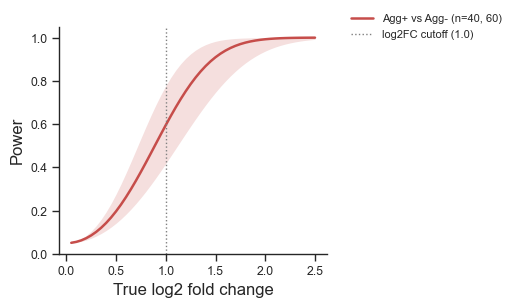

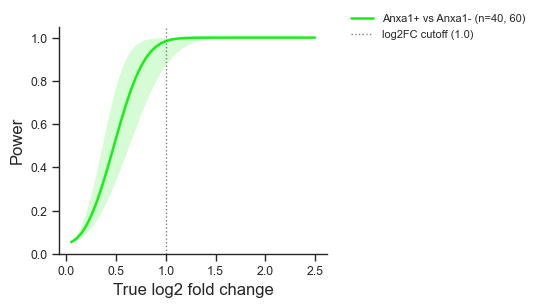

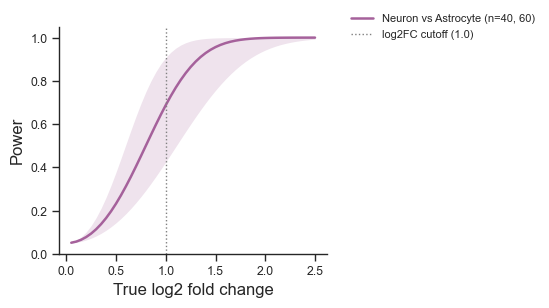

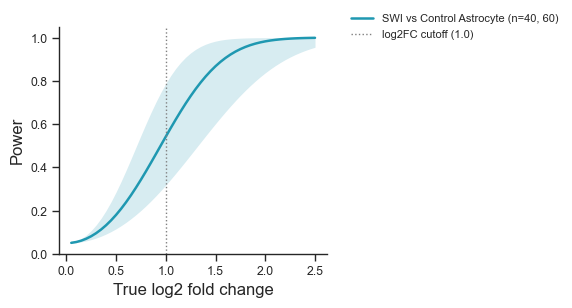

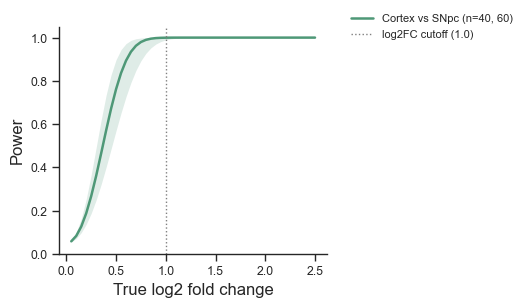

In [35]:
# Analytical power curves, median SD with IQR band 

CURVE_COLORS = {
    "Agg+ vs Agg-":             "#C64D4A",
    "Anxa1+ vs Anxa1-":         "#13F113",
    "Neuron vs Astrocyte":      "#A5619B",
    "SWI vs Control Astrocyte": "#1F98B1",
    "Cortex vs SNpc":           "#4E9877",
}

for name in COMPARISONS:
    color = CURVE_COLORS[name]
    pw_med, pw_lo, pw_hi = comparison_curves(name)

    fig_b, ax_b = plt.subplots(figsize=(3.46, 3))
    ax_b.fill_between(FC_GRID, pw_lo, pw_hi, color=blend_white(color, 0.18), linewidth=0)
    ax_b.plot(FC_GRID, pw_med, color=color, linewidth=1.8,
              label=f"{name} (n={c.n1}, {c.n2})")

    ax_b.axvline(LOG2FC_CUTOFF, color="grey", linestyle=":", linewidth=1,
                 label=f"log2FC cutoff ({LOG2FC_CUTOFF})")
    ax_b.set_xlabel("True log2 fold change", fontsize=12)
    ax_b.set_ylabel("Power", fontsize=12)
    ax_b.set_ylim(0, 1.05)
    ax_b.legend(fontsize=8, loc="lower right", frameon=False)
    ax_b.spines[["top", "right"]].set_visible(False)
    fig_b.tight_layout()
    scplt.shift_legend(ax_b)
    fig_b.savefig(f"PowerAnalysis_analytical_power_curves_{name}.svg", bbox_inches="tight")
    plt.show()

In [ ]:
# export plotted data
rows = []
for name in COMPARISONS:
    sds, n1, n2 = obs_sd_per_comp[name]
    sd_25, sd_50, sd_75 = np.percentile(sds, [25, 50, 75])
    for fc in FC_GRID:
        for pct_label, sd_val in [("25th", sd_25), ("median", sd_50), ("75th", sd_75)]:
            rows.append({
                "comparison":    name,
                "n1":            n1,
                "n2":            n2,
                "alpha":         P_THRESH,
                "log2FC":        fc,
                "sd_percentile": pct_label,
                "sd_value":      sd_val,
                "power":         analytical_power(fc, sd_val, n1, n2),
            })

power_curve_df = pd.DataFrame(rows)
power_curve_df.to_csv(
    "PowerAnalysis_analytical_power_curve_data.csv",
    index=False,
)

# old stuff

# simulation curve
fig_a_rows = []
for name, comp_powers in power_results.items():
    _, n1, n2 = obs_sd_per_comp[name]
    for log2fc, power in comp_powers.items():
        fig_a_rows.append({
            "Comparison": name,
            "n1": n1,
            "n2": n2,
            "log2FC": log2fc,
            "Simulated power": power,
        })
fig_a_data = pd.DataFrame(fig_a_rows)
fig_a_data.to_csv("MANUSCRIPT_revision/REVISION_PowerAnalysis_power_curves_data.csv", index=False)

# Figure B data: median MDES bar values, in plotted order
fig_b_data = median_mdes.rename("MDES (log2FC)").reset_index()
fig_b_data.to_csv("MANUSCRIPT_revision/REVISION_PowerAnalysis_mdes_data.csv", index=False)

fig_a_data.head(), fig_b_data.head()


(     Comparison  n1  n2  log2FC  Simulated power
 0  Agg+ vs Agg-  12   7    0.25           0.0350
 1  Agg+ vs Agg-  12   7    0.50           0.0912
 2  Agg+ vs Agg-  12   7    0.75           0.2068
 3  Agg+ vs Agg-  12   7    1.00           0.4092
 4  Agg+ vs Agg-  12   7    1.50           0.7798,
                  Comparison  MDES (log2FC)
 0              Agg+ vs Agg-          1.303
 1          Anxa1+ vs Anxa1-          0.660
 2       Neuron vs Astrocyte          1.160
 3  SWI vs Control Astrocyte          1.288)

In [70]:
volcano_configs = {
    name: {
        "pdata": pdata_obj,
        "case_values": [{col: g1}, {col: g2}],
    }
    for name, (pdata_obj, col, g1, g2) in COMPARISONS.items()
}

color_dict = {
    "upregulated":   "#C64D4A",
    "downregulated": "#293DF5",
    "not_significant": "#FFFFFF6A",
}

volcano_dfs = {}

for name, cfg in volcano_configs.items():
    fig, ax = plt.subplots(figsize=(4, 4))
    ax, vdf = scplt.plot_volcano(
        ax, cfg["pdata"],
        values=cfg["case_values"],
        pval=0.05,
        return_df=True,
        fold_change_mode="mean",
        color=color_dict,
        label=[0, 0],        # suppress labels — we just want the df
    )
    plt.close(fig)           # don't display the plots
    volcano_dfs[name] = vdf


# ── Summary statistics ────────────────────────────────────────────────────────

print("── DE hit summary ──\n")
for name, vdf in volcano_dfs.items():
    sig = vdf[vdf["significance"].isin(["upregulated", "downregulated"])]
    up  = (vdf["significance"] == "upregulated").sum()
    dn  = (vdf["significance"] == "downregulated").sum()
    median_lfc = sig["log2fc"].abs().median() if len(sig) > 0 else float("nan")
    pct_above_2 = (sig["log2fc"].abs() >= 2.0).mean() * 100 if len(sig) > 0 else float("nan")

    print(f"{name}")
    print(f"  Hits: {len(sig)} total ({up} up, {dn} down)")
    print(f"  Median |log2FC| of hits: {median_lfc:.2f}")
    print(f"  % hits with |log2FC| ≥ 2.0: {pct_above_2:.1f}%\n")

     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=2.89e+05). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: [{'sample': 'Agg+'}] vs [{'sample': 'Agg-'}]
   🔸 Group sizes: 12 vs 7 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 P-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 104 proteins were not comparable (zero or NaN mean in one group).
     ✅ DE complete. Results stored in:
       • .stats["[{'sample': 'Agg+'}] vs [{'sample': 'Agg-'}]"]
       • Columns: log2fc, p_value, significance, etc.
       • Upregulated: 137 | Downregulated: 607 | Not significant: 1502
     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears t

G:\Users\srpang\Dropbox (Personal)\4. Caltech Work\Research\Chou-Roukes Group\scviz_git\src\scpviz\pAnnData\analysis.py:354: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = ttest_ind(x1, x2, equal_var=equal_var, nan_policy='omit')


     ✅ DE complete. Results stored in:
       • .stats["[{'cell_type': 'Neuron'}] vs [{'cell_type': 'Astrocyte'}]"]
       • Columns: log2fc, p_value, significance, etc.
       • Upregulated: 100 | Downregulated: 245 | Not significant: 2402
     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=4.92e+04). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: [{'condition': 'SWI'}] vs [{'condition': 'Uninjured'}]
   🔸 Group sizes: 5 vs 5 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 P-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 413 proteins were not comparable (zero or NaN mean in one group).


G:\Users\srpang\Dropbox (Personal)\4. Caltech Work\Research\Chou-Roukes Group\scviz_git\src\scpviz\pAnnData\analysis.py:354: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = ttest_ind(x1, x2, equal_var=equal_var, nan_policy='omit')


     ✅ DE complete. Results stored in:
       • .stats["[{'condition': 'SWI'}] vs [{'condition': 'Uninjured'}]"]
       • Columns: log2fc, p_value, significance, etc.
       • Upregulated: 86 | Downregulated: 88 | Not significant: 2605
── DE hit summary ──

Agg+ vs Agg-
  Hits: 744 total (137 up, 607 down)
  Median |log2FC| of hits: 1.70
  % hits with |log2FC| ≥ 2.0: 37.2%

Anxa1+ vs Anxa1-
  Hits: 278 total (176 up, 102 down)
  Median |log2FC| of hits: 1.90
  % hits with |log2FC| ≥ 2.0: 45.0%

Neuron vs Astrocyte
  Hits: 345 total (100 up, 245 down)
  Median |log2FC| of hits: 1.85
  % hits with |log2FC| ≥ 2.0: 44.1%

SWI vs Control Astrocyte
  Hits: 174 total (86 up, 88 down)
  Median |log2FC| of hits: 1.88
  % hits with |log2FC| ≥ 2.0: 48.3%



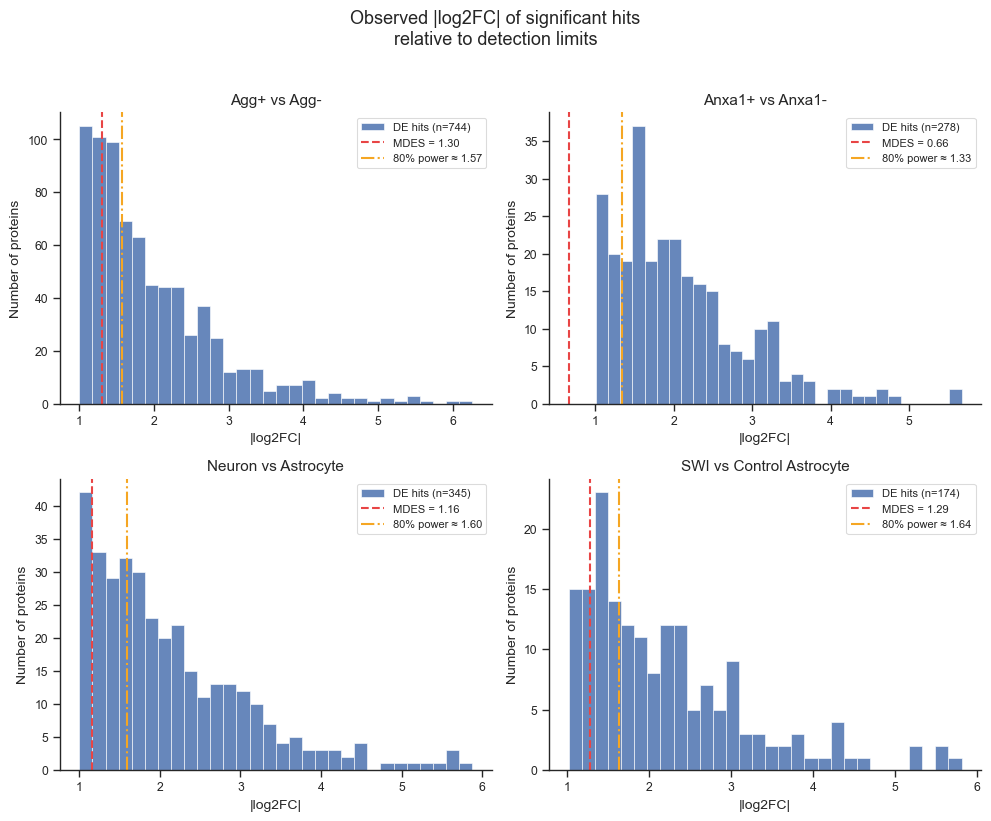

In [74]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, (name, vdf) in enumerate(volcano_dfs.items()):
    ax = axes[i]
    sds, n1, n2 = obs_sd_per_comp[name]

    # Significant hits
    sig = vdf[vdf["significance"].isin(["upregulated", "downregulated"])]
    abs_lfc = sig["log2fc"].abs()

    # MDES (median SD, analytical)
    median_sd = np.median(sds)
    _, n1_, n2_ = obs_sd_per_comp[name]
    try:
        d = TTestIndPower().solve_power(
            effect_size=None, nobs1=n1, ratio=n2/n1,
            alpha=P_THRESH, power=POWER_TARGET,
        )
        mdes = d * median_sd
    except Exception:
        mdes = np.nan

    # 80% power threshold from simulation (interpolate crossing)
    comp_powers = power_results[name]
    xs = np.array(list(comp_powers.keys()))
    ys = np.array(list(comp_powers.values()))
    # Linear interpolation to find where power crosses 0.8
    if ys[-1] >= POWER_TARGET:
        idx = np.searchsorted(ys, POWER_TARGET)
        if idx == 0:
            power_80_lfc = xs[0]
        else:
            x0, x1 = xs[idx-1], xs[idx]
            y0, y1 = ys[idx-1], ys[idx]
            power_80_lfc = x0 + (POWER_TARGET - y0) * (x1 - x0) / (y1 - y0)
    else:
        power_80_lfc = np.nan

    # Histogram
    ax.hist(abs_lfc, bins=30, color="#4C72B0", edgecolor="white",
            linewidth=0.5, alpha=0.85, label=f"DE hits (n={len(sig)})")

    # Vertical lines
    if not np.isnan(mdes):
        ax.axvline(mdes, color="#E84545", linestyle="--", linewidth=1.5,
                   label=f"MDES = {mdes:.2f}")
    if not np.isnan(power_80_lfc):
        ax.axvline(power_80_lfc, color="#F5A623", linestyle="-.", linewidth=1.5,
                   label=f"80% power ≈ {power_80_lfc:.2f}")

    ax.set_title(name, fontsize=11)
    ax.set_xlabel("|log2FC|", fontsize=10)
    ax.set_ylabel("Number of proteins", fontsize=10)
    ax.legend(fontsize=8, framealpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Observed |log2FC| of significant hits\nrelative to detection limits",
    fontsize=13, y=1.02
)
plt.tight_layout()
fig.savefig("MANUSCRIPT_revision/REVISION_PowerAnalysis_lfc_histogram.svg", bbox_inches="tight")
plt.show()

## for mouse cortex, human

### dataset prep

In [3]:
pdata_mus1mo3mo6mo_diann_base = pAnnData.import_data(source_type='diann', report_file = 'data/2511_MusCORTEX-1mo-3mo-6mo-combined/report.parquet')

🧭 [USER] Importing data of type [diann]
      Auto-detecting '_' as delimiter from first filename.
     ⚠️ [WARN] 2 different filename formats detected. Proceeding with fallback `.obs` structure... (File Number, Parsing Type)
--------------------------
Starting import [DIA-NN]

Source file: data/2511_MusCORTEX-1mo-3mo-6mo-combined/report.parquet
Number of files: 80
Proteins: 9559
Peptides: 61557

     ℹ️ [INFO] Using sample-specific q-values for 'prot' significance annotation.
     ℹ️ [INFO] Using sample-specific q-values for 'pep' significance annotation.

ℹ️ RS matrix: (9559, 61557) (proteins × peptides), sparsity: 99.99%
   - Proteins with ≥2 *unique* linked peptides: 4777/9559
   - Peptides linked to ≥2 proteins: 10011/61557
   - Mean peptides per protein: 7.94
   - Mean proteins per peptide: 1.23
     ✅ [OK] pAnnData object is valid.
     ✅ [OK] Import complete. Use `print(pdata)` to view the object.
--------------------------


In [4]:
colnames = [
    'date',
    'gradient',
    'sample_id',
    'size',
    'confirmation',
    'thickness',
    'sample',
    'organism',
    'region',
    'well_position'
]

# ignore 11-token parsing type on both
pdata_mus1mo3mo6mo_diann = pdata_mus1mo3mo6mo_diann_base.filter_sample(condition='parsingType == "10-tokens"')
pdata_mus1mo3mo6mo_diann.summary = scutils.parse_filename_index(pdata_mus1mo3mo6mo_diann.summary, colnames)

pdata_mus1mo3mo6mo_processed = pdata_mus1mo3mo6mo_diann.filter_prot_significant()

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: parsingType == "10-tokens"
     ℹ️ Auto-cleanup: Removed 512 empty proteins (all-NaN or all-zero). Proteins: Q68FF7, Q68FF7-2, Q6P9J5, J9SQF3, J9SQF3-10, J9SQF3-11, J9SQF3-12, J9SQF3-2, J9SQF3-3, J9SQF3-4, ...
    → Samples kept: 76, Samples dropped: 4
    → Proteins kept: 9047

🔄 [UPDATE] Updating summary [sync_back]: pushed edits from `.summary` to `.obs`.
      Columns updated: sample_id, gradient, organism, region, size, well_position, confirmation, sample, thickness, date.
🧭 [USER] Filtering proteins [Significance|File-mode]:
     ℹ️ [INFO] No group provided. Defaulting to sample-level significance filtering.
    Returning a copy of protein data based on significance thresholds:
     🔸 Files requested: All
     🔸 FDR threshold: 0.01
     🔸 Logic: any (protein must be significant in ≥1 file(s))
    → Proteins kept: 8293, Proteins dropped: 754
     ✅ [OK] RS matrix filte

In [ ]:
pd.DataFrame(pdata_mus1mo3mo6mo_processed.summary)

,File,parsingType,protein_quant,protein_count,protein_abundance_sum,date,gradient,sample_id,size,confirmation,thickness,sample,organism,region,well_position,peptide_quant,peptide_count,peptide_abundance_sum,unique_pep2_protein_count
20250701_Aur25minDIA_Th57_800_Y1_35_3mo-aggY_Mus_Cortex_D14,3,10-tokens,0.488484,4051,2.389971e+09,20250701,Aur25minDIA,Th57,800,Y1,35,3mo-aggY,Mus,Cortex,D14,0.278893,16793,6.301347e+09,2769
20250701_Aur25minDIA_Th56_800_Y2_35_3mo-aggY_Mus_Cortex_D13,4,10-tokens,0.548414,4548,3.147371e+09,20250701,Aur25minDIA,Th56,800,Y2,35,3mo-aggY,Mus,Cortex,D13,0.351270,21151,8.772817e+09,3052
20250701_Aur25minDIA_Th54_800_Y2_35_3mo-aggY_Mus_Cortex_D11,5,10-tokens,0.445195,3692,2.892848e+09,20250701,Aur25minDIA,Th54,800,Y2,35,3mo-aggY,Mus,Cortex,D11,0.227210,13681,7.580850e+09,2582
20250701_Aur25minDIA_Th50_800_Y1_35_3mo-aggY_Mus_Cortex_D7,6,10-tokens,0.402026,3334,4.367686e+09,20250701,Aur25minDIA,Th50,800,Y1,35,3mo-aggY,Mus,Cortex,D7,0.188697,11362,1.123807e+10,2326
20250625_Aur25minDIA_G33_800_Y3_35um_1mo-aggN_Mus_Cortex_I10,7,10-tokens,0.412396,3420,5.749754e+09,20250625,Aur25minDIA,G33,800,Y3,35um,1mo-aggN,Mus,Cortex,I10,0.237424,14296,1.333091e+10,2351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20250708_Aur25minDIA_J36_800_Y1_35_6mo-aggN_Mus_Cortex_F5,76,10-tokens,0.098034,813,2.228753e+10,20250708,Aur25minDIA,J36,800,Y1,35,6mo-aggN,Mus,Cortex,F5,0.033564,2021,5.664980e+10,642
20250701_Aur25minDIA_Th58_800_Y1_35_3mo-aggY_Mus_Cortex_D15,77,10-tokens,0.008441,70,2.284083e+09,20250701,Aur25minDIA,Th58,800,Y1,35,3mo-aggY,Mus,Cortex,D15,0.001694,102,9.558274e+09,52
20250701_Aur25minDIA_Th58_800_Y1_35_3mo-aggY_Mus_Cortex_D15REDO,78,10-tokens,0.010250,85,1.020359e+10,20250701,Aur25minDIA,Th58,800,Y1,35,3mo-aggY,Mus,Cortex,D15REDO,0.002973,179,4.844810e+10,68
20250625_Aur25minDIA_G23_800_Y1_35um_1mo-aggY_Mus_Cortex_G12,79,10-tokens,0.008561,71,6.458422e+09,20250625,Aur25minDIA,G23,800,Y1,35um,1mo-aggY,Mus,Cortex,G12,0.002259,136,2.311787e+10,58


In [5]:
pdata_6mo_cortex = pdata_mus1mo3mo6mo_processed.filter_sample(condition='region == "Cortex"')
pdata_6mo_cortex.summary[["timepoint", "sample"]] = pdata_6mo_cortex.summary["sample"].str.extract(r"(\d+mo)-(agg[YN])")
pdata_6mo_cortex.summary["sample"] = pdata_6mo_cortex.summary["sample"].map({"aggY": "Agg+", "aggN": "Agg-"})
pdata_6mo_cortex.update_summary()
pdata_6mo_cortex = pdata_6mo_cortex.filter_sample(min_prot=1000)
pdata_6mo_cortex = pdata_6mo_cortex.filter_sample(condition='timepoint == "6mo"')

pdata_6mo_cortex_filter = pdata_6mo_cortex.copy()
pdata_6mo_cortex_filter = pdata_6mo_cortex_filter.filter_prot_found(min_ratio=0.4, group=['sample'],match_any=True)
pdata_6mo_cortex_filter = pdata_6mo_cortex_filter.filter_prot(valid_genes=True, unique_profiles=True)
pdata_6mo_cortex_filter = pdata_6mo_cortex_filter.filter_sample(min_prot=1000)
# pdata_6mo_snpc.impute(method='min', min_scale=0.2)

pdata_6mo_cortex_norm = pdata_6mo_cortex_filter.copy()
pdata_6mo_cortex_norm.normalize(method='directlfq')
# pdata_6mo_snpc_norm = pdata_6mo_snpc_norm.filter_sample(min_prot=1000)

pdata_6mo_cortex_norm.summary['sample'].value_counts()

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: region == "Cortex"
     ℹ️ Auto-cleanup: No empty proteins found (all-NaN or all-zero).
    → Samples kept: 76, Samples dropped: 0
    → Proteins kept: 8293

[summary] ⚠️ Warning: .summary has been modified. Run `(pdata).update_summary()` to sync changes back to .obs.
[summary] ⚠️ Warning: .summary has been modified. Run `(pdata).update_summary()` to sync changes back to .obs.
🔄 [UPDATE] Updating summary [sync_back]: pushed edits from `.summary` to `.obs` (marked stale).
      Columns updated: timepoint, sample.
🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: protein_count >= 1000
     ℹ️ Auto-cleanup: No empty proteins found (all-NaN or all-zero).
    → Samples kept: 67, Samples dropped: 9
    → Proteins kept: 8293

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on conditio

2026-09-10 14:57:29,934 - directlfq.lfq_manager - INFO - Starting directLFQ analysis.
2026-09-10 14:57:30,175 - directlfq.lfq_manager - INFO - Performing sample normalization.
2026-09-10 14:57:31,656 - directlfq.lfq_manager - INFO - Estimating lfq intensities.
2026-09-10 14:57:31,660 - directlfq.protein_intensity_estimation - INFO - 4393 lfq-groups total
2026-09-10 14:57:32,870 - directlfq.protein_intensity_estimation - INFO - using 16 processes
2026-09-10 14:57:43,830 - directlfq.lfq_manager - INFO - Could not add additional columns to protein table, printing without additional columns.
2026-09-10 14:57:43,831 - directlfq.lfq_manager - INFO - Writing results files.
2026-09-10 14:57:44,401 - directlfq.lfq_manager - INFO - Analysis finished!


     ℹ️ Set protein data to layer X_norm_directlfq.
     ✅ directlfq normalization complete. Results are stored in layer 'X_norm_directlfq'.
          ⚠️ Downstream imputation should be performed with the flag `use_zeros_as_nan` set to True due to directlfq output format returning NaNs as 0s.


sample
Agg+    12
Agg-    11
Name: count, dtype: int64

In [ ]:
pdata_1mo_cortex = pdata_mus1mo3mo6mo_processed.filter_sample(condition='region == "Cortex"')
pdata_1mo_cortex.summary[["timepoint", "sample"]] = pdata_1mo_cortex.summary["sample"].str.extract(r"(\d+mo)-(agg[YN])")
pdata_1mo_cortex.summary["sample"] = pdata_1mo_cortex.summary["sample"].map({"aggY": "Agg+", "aggN": "Agg-"})
pdata_1mo_cortex.update_summary()
pdata_1mo_cortex = pdata_1mo_cortex.filter_sample(min_prot=1000)
pdata_1mo_cortex = pdata_1mo_cortex.filter_sample(condition='timepoint == "1mo"')

pdata_1mo_cortex_filter = pdata_1mo_cortex.copy()
pdata_1mo_cortex_filter = pdata_1mo_cortex_filter.filter_prot_found(min_ratio=0.4, group=['sample'],match_any=True)
pdata_1mo_cortex_filter = pdata_1mo_cortex_filter.filter_prot(valid_genes=True, unique_profiles=True)
pdata_1mo_cortex_filter = pdata_1mo_cortex_filter.filter_sample(min_prot=1000)
# pdata_6mo_snpc.impute(method='min', min_scale=0.2)

pdata_1mo_cortex_norm = pdata_1mo_cortex_filter.copy()
pdata_1mo_cortex_norm.normalize(method='directlfq')
# pdata_6mo_snpc_norm = pdata_6mo_snpc_norm.filter_sample(min_prot=1000)

pdata_1mo_cortex_norm.summary['sample'].value_counts()

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: region == "Cortex"
     ℹ️ Auto-cleanup: No empty proteins found (all-NaN or all-zero).
    → Samples kept: 76, Samples dropped: 0
    → Proteins kept: 8293

[summary] ⚠️ Warning: .summary has been modified. Run `(pdata).update_summary()` to sync changes back to .obs.
[summary] ⚠️ Warning: .summary has been modified. Run `(pdata).update_summary()` to sync changes back to .obs.
🔄 [UPDATE] Updating summary [sync_back]: pushed edits from `.summary` to `.obs` (marked stale).
      Columns updated: timepoint, sample.
🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: protein_count >= 1000
     ℹ️ Auto-cleanup: No empty proteins found (all-NaN or all-zero).
    → Samples kept: 67, Samples dropped: 9
    → Proteins kept: 8293

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on conditio

2026-07-10 10:17:52,240 - directlfq.lfq_manager - INFO - Starting directLFQ analysis.
2026-07-10 10:17:52,738 - directlfq.lfq_manager - INFO - Performing sample normalization.
2026-07-10 10:17:52,743 - directlfq.normalization - INFO - to few values for normalization without missing values. Including missing values
2026-07-10 10:17:53,118 - directlfq.lfq_manager - INFO - Estimating lfq intensities.
2026-07-10 10:17:53,126 - directlfq.protein_intensity_estimation - INFO - 3461 lfq-groups total
2026-07-10 10:17:55,853 - directlfq.protein_intensity_estimation - INFO - using 12 processes
2026-07-10 10:18:20,357 - directlfq.lfq_manager - INFO - Could not add additional columns to protein table, printing without additional columns.
2026-07-10 10:18:20,358 - directlfq.lfq_manager - INFO - Writing results files.
2026-07-10 10:18:21,802 - directlfq.lfq_manager - INFO - Analysis finished!


     ℹ️ Set protein data to layer X_norm_directlfq.
     ✅ directlfq normalization complete. Results are stored in layer 'X_norm_directlfq'.
          ⚠️ Downstream imputation should be performed with the flag `use_zeros_as_nan` set to True due to directlfq output format returning NaNs as 0s.


sample
Agg+    12
Agg-    10
Name: count, dtype: int64

In [6]:
# 20240902_Aur60minDIA_5k_TEAB35_D17

obs_columns = ['date', 'acquisition', 'sample_id','size','confirmation','thickness','type','organism','region','well_position']

# pdata_old = pAnnData.import_data(source_type='diann',report_file = 'data/2509_human/251003_LBDAggN/report.parquet', obs_columns=obs_columns)
pdata_human_cortex = pAnnData.import_data(source_type='diann',report_file = 'data/2509_human/251013_CtrlAggN/report.parquet', obs_columns=obs_columns)

pdata_human_cortex_filter = pdata_human_cortex.filter_sample(values={'acquisition': 'Aur25minDIA'})

# forgot to rename acquisition for 20250925_Aur25minDIA_AA86_800_Y1_35um_LBD-aggN_Human_Cortex_L6-Desalt, manually remove
keep_list = pdata_human_cortex_filter.summary.index.tolist()
keep_list.remove('20250925_Aur25minDIA_AA86_800_Y1_35um_LBD-aggN_Human_Cortex_L6-Desalt')

pdata_human_cortex_filter = pdata_human_cortex_filter.filter_sample(file_list = keep_list)
pdata_human_cortex_filter = pdata_human_cortex_filter.filter_sample(condition="protein_count < 3500")
pdata_human_cortex_filter = pdata_human_cortex_filter.filter_prot_significant()
pdata_human_cortex_filter = pdata_human_cortex_filter.filter_sample(min_prot=1000)

pdata_human_cortex_filter.summary["type"] = pdata_human_cortex_filter.summary["type"].map({"LBD-aggY": "LBD Agg+", "LBD-aggN": "LBD Agg-", "Ctrl-aggN": "Ctrl Agg-"})
pdata_human_cortex_filter.update_summary()

pdata_human_cortex_filter = pdata_human_cortex_filter.filter_prot_found(min_ratio=0.4, group=['type'],match_any=True)
pdata_human_cortex_filter = pdata_human_cortex_filter.filter_prot(valid_genes=True, unique_profiles=True)

pdata_human_cortex_norm = pdata_human_cortex_filter.copy()
pdata_human_cortex_norm.normalize(method='directlfq')

🧭 [USER] Importing data of type [diann]
--------------------------
Starting import [DIA-NN]

Source file: data/2509_human/251013_CtrlAggN/report.parquet
Number of files: 75
Proteins: 6009
Peptides: 39784



c:\Users\srpang\anaconda3\envs\py311-dev\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


     ℹ️ [INFO] Using sample-specific q-values for 'prot' significance annotation.
     ℹ️ [INFO] Using sample-specific q-values for 'pep' significance annotation.

ℹ️ RS matrix: (6009, 39784) (proteins × peptides), sparsity: 99.98%
   - Proteins with ≥2 *unique* linked peptides: 4148/6009
   - Peptides linked to ≥2 proteins: 296/39784
   - Mean peptides per protein: 6.70
   - Mean proteins per peptide: 1.01
     ✅ [OK] pAnnData object is valid.
     ✅ [OK] Import complete. Use `print(pdata)` to view the object.
--------------------------
🧭 [USER] Filtering samples [class match]:
    Returning a copy of sample data based on class match:
   🔸 Match samples where:
      - acquisition: Aur25minDIA
     ℹ️ Auto-cleanup: Removed 32 empty proteins (all-NaN or all-zero). Proteins: Q7Z465, Q7Z739, P08473, Q8IUR7, Q8WVJ2, Q66K74, P98173, Q15172, Q8WW22, P57076, ...
    → Samples kept: 71, Samples dropped: 4
    → Proteins kept: 5977

🧭 [USER] Filtering samples [file list]:
    Returning a copy o

2026-07-10 10:20:31,716 - directlfq.lfq_manager - INFO - Starting directLFQ analysis.
2026-07-10 10:20:32,218 - directlfq.lfq_manager - INFO - Performing sample normalization.
2026-07-10 10:20:32,710 - directlfq.lfq_manager - INFO - Estimating lfq intensities.
2026-07-10 10:20:32,716 - directlfq.protein_intensity_estimation - INFO - 2283 lfq-groups total
2026-07-10 10:20:34,094 - directlfq.protein_intensity_estimation - INFO - using 12 processes
2026-07-10 10:21:04,323 - directlfq.lfq_manager - INFO - Could not add additional columns to protein table, printing without additional columns.
2026-07-10 10:21:04,324 - directlfq.lfq_manager - INFO - Writing results files.
2026-07-10 10:21:07,309 - directlfq.lfq_manager - INFO - Analysis finished!


     ℹ️ Set protein data to layer X_norm_directlfq.
     ✅ directlfq normalization complete. Results are stored in layer 'X_norm_directlfq'.
          ⚠️ Downstream imputation should be performed with the flag `use_zeros_as_nan` set to True due to directlfq output format returning NaNs as 0s.


### analysis

6mo Agg+ vs 6mo Agg- (n=12 vs 11): 4393 proteins with valid SD  | median SD = 0.845  | IQR = [0.660, 1.071]
1mo Agg+ vs 1mo Agg- (n=12 vs 10): 3461 proteins with valid SD  | median SD = 0.868  | IQR = [0.649, 1.229]
LBD Agg+ vs LBD Agg- (n=25 vs 19): 2283 proteins with valid SD  | median SD = 1.179  | IQR = [0.867, 1.554]
LBD Agg+ vs Ctrl Agg- (n=25 vs 23): 2283 proteins with valid SD  | median SD = 1.216  | IQR = [0.875, 1.557]

6mo Agg+ vs 6mo Agg-
  log2FC = 0.25  →  power = 0.028
  log2FC = 0.50  →  power = 0.072
  log2FC = 0.75  →  power = 0.207
  log2FC = 1.00  →  power = 0.457
  log2FC = 1.50  →  power = 0.876
  log2FC = 2.00  →  power = 0.968

1mo Agg+ vs 1mo Agg-
  log2FC = 0.25  →  power = 0.025
  log2FC = 0.50  →  power = 0.074
  log2FC = 0.75  →  power = 0.193
  log2FC = 1.00  →  power = 0.438
  log2FC = 1.50  →  power = 0.823
  log2FC = 2.00  →  power = 0.932

LBD Agg+ vs LBD Agg-
  log2FC = 0.25  →  power = 0.031
  log2FC = 0.50  →  power = 0.075
  log2FC = 0.75  →  power

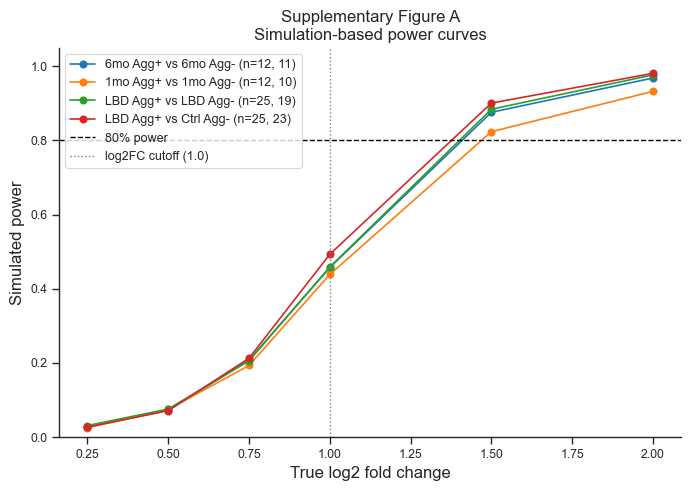

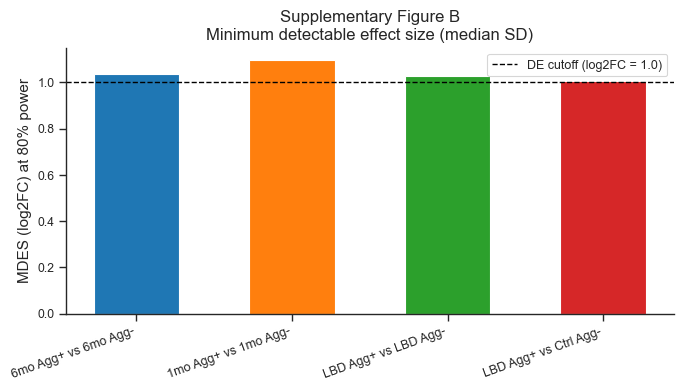


── Reviewer summary ──
6mo Agg+ vs 6mo Agg- (n=12 vs 11): power ≥ 80% from log2FC ≈ 1.5  |  power at log2FC=1.0: 0.46  |  power at log2FC=2.0: 0.97
1mo Agg+ vs 1mo Agg- (n=12 vs 10): power ≥ 80% from log2FC ≈ 1.5  |  power at log2FC=1.0: 0.44  |  power at log2FC=2.0: 0.93
LBD Agg+ vs LBD Agg- (n=25 vs 19): power ≥ 80% from log2FC ≈ 1.5  |  power at log2FC=1.0: 0.46  |  power at log2FC=2.0: 0.98
LBD Agg+ vs Ctrl Agg- (n=25 vs 23): power ≥ 80% from log2FC ≈ 1.5  |  power at log2FC=1.0: 0.49  |  power at log2FC=2.0: 0.98


In [7]:
from scipy import stats
from scipy.sparse import issparse
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.stats.power import TTestIndPower

# ── 0. Configuration ──────────────────────────────────────────────────────────

# Each entry:
#   "Display name": (pdata_object, obs_column, group1_label, group2_label)
#
# n1 and n2 are inferred automatically from the pdata obs column.
# group1 = "numerator" (positive fold change = higher in group1)

COMPARISONS = {
    "6mo Agg+ vs 6mo Agg-": (
        pdata_6mo_cortex_norm,   # pdata object
        "sample",              # obs column
        "Agg+",                # group 1 label
        "Agg-",                # group 2 label
    ),
    "1mo Agg+ vs 1mo Agg-": (
        pdata_1mo_cortex_norm,     
        "sample",           
        "Agg+",              
        "Agg-",              
    ),
    "LBD Agg+ vs LBD Agg-": (
        pdata_human_cortex_norm,  
        "type",           
        "LBD Agg+",             
        "LBD Agg-",          
    ),
    "LBD Agg+ vs Ctrl Agg-": (
        pdata_human_cortex_norm,        
        "type",           
        "LBD Agg+",                
        "Ctrl Agg-",           
    ),
}

EFFECT_SIZES  = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
N_SIM         = 5000
P_THRESH      = 0.05
LOG2FC_CUTOFF = 1.0
POWER_TARGET  = 0.80
RNG           = np.random.default_rng(42)


# ── 1. Helpers ────────────────────────────────────────────────────────────────

def extract_dense(pdata_obj, sample_mask):
    X = pdata_obj.prot.X[sample_mask, :]
    if issparse(X):
        X = X.toarray()
    X = X.astype(float)
    X[X == 0] = np.nan
    X = np.log2(X)
    return X

def observed_sds(X):
    """Per-protein SD ignoring NaN; returns 1-D array of length n_proteins."""
    return np.nanstd(X, axis=0, ddof=1)

def run_de_on_arrays(X1, X2):
    """
    Mimics the scpviz DE decision rule on two (n_samples, n_proteins) arrays.
    Returns boolean mask of significant proteins.
    """
    n_prot = X1.shape[1]
    sig    = np.zeros(n_prot, dtype=bool)

    for j in range(n_prot):
        g1 = X1[:, j][~np.isnan(X1[:, j])]
        g2 = X2[:, j][~np.isnan(X2[:, j])]
        if len(g1) < 2 or len(g2) < 2:
            continue
        _, p = stats.ttest_ind(g1, g2, equal_var=False)
        lfc  = np.nanmean(g1) - np.nanmean(g2)   # already log2 space
        if p < P_THRESH and abs(lfc) >= LOG2FC_CUTOFF:
            sig[j] = True

    return sig

# ── 2. Variance extraction (per comparison) ───────────────────────────────────

obs_sd_per_comp = {}

for name, (pdata_obj, col, g1, g2) in COMPARISONS.items():
    obs   = pdata_obj.prot.obs
    mask  = obs[col].isin([g1, g2]).values
    n1    = (obs[col] == g1).sum()
    n2    = (obs[col] == g2).sum()

    X_all = extract_dense(pdata_obj, mask)
    sds   = observed_sds(X_all)
    sds   = sds[~np.isnan(sds) & (sds > 0)]
    obs_sd_per_comp[name] = (sds, n1, n2)    # store n1/n2 here for later

    print(f"{name} (n={n1} vs {n2}): {len(sds)} proteins with valid SD  "
          f"| median SD = {np.median(sds):.3f}  "
          f"| IQR = [{np.percentile(sds,25):.3f}, {np.percentile(sds,75):.3f}]")


# ── 3. Analysis 1 — Simulation-based power curves ────────────────────────────

power_results = {}   # {comparison_name: {effect_size: power}}

for name in COMPARISONS:
    sds, n1, n2 = obs_sd_per_comp[name]
    comp_powers = {}

    for es in EFFECT_SIZES:
        n_sig = 0

        for _ in range(N_SIM):
            # Sample one protein's SD from the observed distribution
            sigma = RNG.choice(sds)

            # Simulate abundance in log2 space
            sim1 = RNG.normal(loc=0.0,  scale=sigma, size=n1)
            sim2 = RNG.normal(loc=es,   scale=sigma, size=n2)

            # Introduce NaN randomly at the rate seen in the real data
            # (optional: skip if you want a clean power estimate)

            # Apply DE decision rule
            if len(sim1) < 2 or len(sim2) < 2:
                continue
            _, p = stats.ttest_ind(sim1, sim2, equal_var=False)
            lfc  = np.mean(sim1) - np.mean(sim2)
            if p < P_THRESH and abs(lfc) >= LOG2FC_CUTOFF:
                n_sig += 1

        comp_powers[es] = n_sig / N_SIM

    power_results[name] = comp_powers
    print(f"\n{name}")
    for es, pw in comp_powers.items():
        print(f"  log2FC = {es:.2f}  →  power = {pw:.3f}")

# ── 4. Analysis 2 — Analytical MDES ──────────────────────────────────────────
# Note: analytical MDES uses the t-test power formula only (no log2FC cutoff),
# so it is a lower bound; the simulation above is the primary result.

analysis    = TTestIndPower()
mdes_rows   = []

for name in COMPARISONS:
    sds, n1, n2 = obs_sd_per_comp[name]
    for pct, label in [(25, "25th pct SD"), (50, "Median SD"), (75, "75th pct SD")]:
        sd_val = np.percentile(sds, pct)
        try:
            d = analysis.solve_power(
                effect_size=None,
                nobs1=n1,
                ratio=n2 / n1,
                alpha=P_THRESH,
                power=POWER_TARGET,
            )
            mdes_log2fc = d * sd_val
        except Exception:
            d, mdes_log2fc = np.nan, np.nan
        mdes_rows.append({
            "Comparison": name,
            "n1": n1, "n2": n2,
            "SD percentile": label,
            "SD value": round(sd_val, 3),
            "Cohen's d": round(d, 3),
            "MDES (log2FC)": round(mdes_log2fc, 3),
        })

mdes_df = pd.DataFrame(mdes_rows)
print("\n── Analytical MDES table ──")
print(mdes_df.to_string(index=False))


# ── 5. Figures ────────────────────────────────────────────────────────────────

colors = plt.cm.tab10.colors

# ── Figure A: Power curves (primary) ─────────────────────────────────────────
fig_a, ax_a = plt.subplots(figsize=(7, 5))

for i, (name, comp_powers) in enumerate(power_results.items()):
    _, n1, n2 = obs_sd_per_comp[name]
    xs = list(comp_powers.keys())
    ys = list(comp_powers.values())
    ax_a.plot(xs, ys, marker="o", color=colors[i],
              label=f"{name} (n={n1}, {n2})")

ax_a.axhline(POWER_TARGET, color="black", linestyle="--", linewidth=1,
             label=f"{int(POWER_TARGET*100)}% power")
ax_a.axvline(LOG2FC_CUTOFF, color="grey", linestyle=":", linewidth=1,
             label=f"log2FC cutoff ({LOG2FC_CUTOFF})")
ax_a.set_xlabel("True log2 fold change", fontsize=12)
ax_a.set_ylabel("Simulated power", fontsize=12)
ax_a.set_title("Supplementary Figure A\nSimulation-based power curves", fontsize=12)
ax_a.set_ylim(0, 1.05)
ax_a.legend(fontsize=9, loc="upper left")
ax_a.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig_a.savefig("MANUSCRIPT_revision/REVISION_extra_PowerAnalysis_power_curves.svg", bbox_inches="tight")
plt.show()

# ── Figure B: MDES bar chart (supplementary) ─────────────────────────────────
median_mdes = (
    mdes_df[mdes_df["SD percentile"] == "Median SD"]
    .set_index("Comparison")["MDES (log2FC)"]
)

fig_b, ax_b = plt.subplots(figsize=(7, 4))
bars = ax_b.bar(
    range(len(median_mdes)),
    median_mdes.values,
    color=[colors[i] for i in range(len(median_mdes))],
    width=0.55,
    edgecolor="white",
)
ax_b.axhline(LOG2FC_CUTOFF, color="black", linestyle="--", linewidth=1,
             label=f"DE cutoff (log2FC = {LOG2FC_CUTOFF})")
ax_b.set_xticks(range(len(median_mdes)))
ax_b.set_xticklabels(median_mdes.index, rotation=20, ha="right", fontsize=9)
ax_b.set_ylabel("MDES (log2FC) at 80% power", fontsize=11)
ax_b.set_title("Supplementary Figure B\nMinimum detectable effect size (median SD)",
               fontsize=12)
ax_b.legend(fontsize=9)
ax_b.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig_b.savefig("MANUSCRIPT_revision/REVISION_extra_PowerAnalysis_mdes.svg", bbox_inches="tight")
plt.show()


# ── 6. Reviewer-facing summary text ──────────────────────────────────────────

print("\n── Reviewer summary ──")
for name, comp_powers in power_results.items():
    _, n1, n2 = obs_sd_per_comp[name]
    # Find smallest ES with power >= 0.8
    powered = [es for es, pw in comp_powers.items() if pw >= POWER_TARGET]
    mdes_sim = min(powered) if powered else "> 2.0"
    print(
        f"{name} (n={n1} vs {n2}): "
        f"power ≥ 80% from log2FC ≈ {mdes_sim}  |  "
        f"power at log2FC=1.0: {comp_powers.get(1.0, 'n/a'):.2f}  |  "
        f"power at log2FC=2.0: {comp_powers.get(2.0, 'n/a'):.2f}"
    )

In [8]:
# ── 5b. Export plotted data ──────────────────────────────────────────────────

# Figure A data: one row per (comparison, log2FC) point on the power curves
fig_a_rows = []
for name, comp_powers in power_results.items():
    _, n1, n2 = obs_sd_per_comp[name]
    for log2fc, power in comp_powers.items():
        fig_a_rows.append({
            "Comparison": name,
            "n1": n1,
            "n2": n2,
            "log2FC": log2fc,
            "Simulated power": power,
        })
fig_a_data = pd.DataFrame(fig_a_rows)
fig_a_data.to_csv("MANUSCRIPT_revision/REVISION_extra_PowerAnalysis_power_curves_data.csv", index=False)

# Figure B data: median MDES bar values, in plotted order
fig_b_data = median_mdes.rename("MDES (log2FC)").reset_index()
fig_b_data.to_csv("MANUSCRIPT_revision/REVISION_extra_PowerAnalysis_mdes_data.csv", index=False)

fig_a_data.head(), fig_b_data.head()


(             Comparison  n1  n2  log2FC  Simulated power
 0  6mo Agg+ vs 6mo Agg-  12  11    0.25           0.0276
 1  6mo Agg+ vs 6mo Agg-  12  11    0.50           0.0716
 2  6mo Agg+ vs 6mo Agg-  12  11    0.75           0.2072
 3  6mo Agg+ vs 6mo Agg-  12  11    1.00           0.4570
 4  6mo Agg+ vs 6mo Agg-  12  11    1.50           0.8758,
               Comparison  MDES (log2FC)
 0   6mo Agg+ vs 6mo Agg-          1.036
 1   1mo Agg+ vs 1mo Agg-          1.095
 2   LBD Agg+ vs LBD Agg-          1.029
 3  LBD Agg+ vs Ctrl Agg-          1.006)

## 3mo snpc, NHP

g:\Users\marion\miniconda3\envs\scpviz_dev\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


6mo Agg+ vs 6mo Agg- (n=12 vs 7): 2172 proteins with valid within-group SD  | median SD = 0.756  | IQR = [0.614, 0.970]  | median obs = 9/12, 7/7
3mo Agg+ vs 3mo Agg- (n=14 vs 8): 2394 proteins with valid within-group SD  | median SD = 0.698  | IQR = [0.544, 0.929]  | median obs = 10/14, 8/8

6mo Agg+ vs 6mo Agg-
  log2FC = 0.25  →  power = 0.034
  log2FC = 0.50  →  power = 0.079
  log2FC = 0.75  →  power = 0.196
  log2FC = 1.00  →  power = 0.409
  log2FC = 1.50  →  power = 0.771
  log2FC = 2.00  →  power = 0.905

3mo Agg+ vs 3mo Agg-
  log2FC = 0.25  →  power = 0.030
  log2FC = 0.50  →  power = 0.068
  log2FC = 0.75  →  power = 0.190
  log2FC = 1.00  →  power = 0.440
  log2FC = 1.50  →  power = 0.830
  log2FC = 2.00  →  power = 0.935

── Analytical MDES table ──
          Comparison  n1  n2 SD percentile  SD value  Cohen's d  MDES (log2FC)
6mo Agg+ vs 6mo Agg-   9   7   25th pct SD     0.614      1.519          0.932
6mo Agg+ vs 6mo Agg-   9   7     Median SD     0.756      1.519     

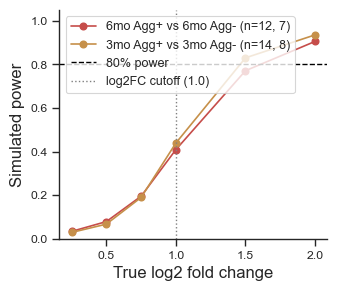

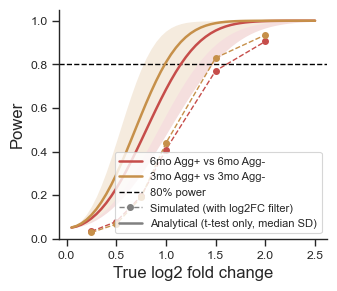

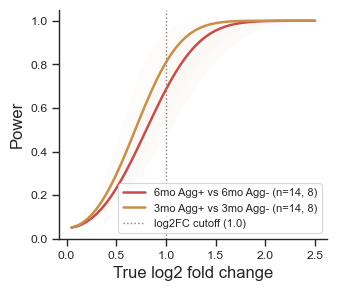

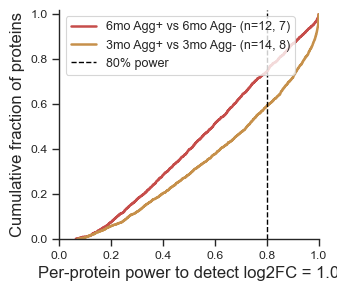


── summary ──
6mo Agg+ vs 6mo Agg- (n=12 vs 7): simulated power ≥ 80% from log2FC ≈ 2.0  |  power at log2FC=1.0: 0.41  |  power at log2FC=2.0: 0.91  |  25.6% of proteins ≥80% powered (t-test only) at log2FC=1.0
3mo Agg+ vs 3mo Agg- (n=14 vs 8): simulated power ≥ 80% from log2FC ≈ 1.5  |  power at log2FC=1.0: 0.44  |  power at log2FC=2.0: 0.94  |  40.9% of proteins ≥80% powered (t-test only) at log2FC=1.0


In [11]:
from scipy import stats
from scipy.sparse import issparse
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.stats.power import TTestIndPower

# ── 0. Configuration ──────────────────────────────────────────────────────────

# Each entry:
#   "Display name": (pdata_object, obs_column, group1_label, group2_label)
#
# n1 and n2 are inferred automatically from the pdata obs column.
# group1 = "numerator" (positive fold change = higher in group1)

COMPARISONS = {
    "6mo Agg+ vs 6mo Agg-": (
        pdata_6mo_snpc_norm,   # pdata object
        "sample",              # obs column
        "Agg+",                # group 1 label
        "Agg-",                # group 2 label
    ),
    "3mo Agg+ vs 3mo Agg-": (
        pdata_3mo_snpc_norm,     
        "sample",           
        "Agg+",              
        "Agg-",              
    ),
}

EFFECT_SIZES  = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
FC_GRID       = np.linspace(0.05, 2.5, 50)
N_SIM         = 5000
P_THRESH      = 0.05
LOG2FC_CUTOFF = 1.0
POWER_TARGET  = 0.80
RNG           = np.random.default_rng(42)

EQUAL_VAR = True   # pooled variance – matches the analytical power model

analysis = TTestIndPower()

# Helpers 

from dataclasses import dataclass

@dataclass
class CompVar:
    """Per-comparison variance structure for power analysis.

    Attributes:
    - sd: Pooled within-group SD, retained proteins only.
    - n1_prot: Observed count in group 1, per retained protein.
    - n2_prot: Observed count in group 2, per retained protein.
    - n1: Design size of group 1, i.e. all samples in the group.
    - n2: Design size of group 2.
    """
    sd: np.ndarray
    n1_prot: np.ndarray
    n2_prot: np.ndarray
    n1: int
    n2: int

def extract_dense(pdata_obj, sample_mask):
    """Log2 abundance matrix (n_samples, n_proteins); zeros → NaN."""
    X = pdata_obj.prot.X[sample_mask, :]
    if issparse(X):
        X = X.toarray()
    X = X.astype(float)
    X[X == 0] = np.nan
    return np.log2(X)

def pooled_within_sd(X1, X2):
    """Pooled within-group SD per protein, so between-group signal does not
    inflate sigma. Per-protein n accounts for differing missingness.

    Args:
        X1: (n1, n_proteins) log2 array for group 1.
        X2: (n2, n_proteins) log2 array for group 2.

    Returns:
        Tuple of (sd, n1, n2), each a 1-D array of length n_proteins.
        sd is NaN where either group has fewer than 2 observations.
    """
    n1 = np.sum(~np.isnan(X1), axis=0)
    n2 = np.sum(~np.isnan(X2), axis=0)
    with np.errstate(invalid="ignore", divide="ignore"):
        s1 = np.nanstd(X1, axis=0, ddof=1)
        s2 = np.nanstd(X2, axis=0, ddof=1)
        num = (n1 - 1) * s1**2 + (n2 - 1) * s2**2
        sd  = np.sqrt(num / (n1 + n2 - 2))
    sd[(n1 < 2) | (n2 < 2)] = np.nan   # undefined without ≥2 obs per group
    return sd, n1, n2                  # ← was: return sd

def analytical_power(fc, sd, n1, n2, alpha=P_THRESH):
    """Two-sample t-test power at a given log2FC and SD (no fold-change filter)."""
    p = analysis.power(effect_size=fc / sd, nobs1=n1, ratio=n2 / n1, alpha=alpha)    
    if not np.isfinite(p):                      # scipy nctdtr fails at large nc
        nc = (fc / sd) * np.sqrt(n1 * n2 / (n1 + n2))
        crit = stats.t.ppf(1 - alpha / 2, n1 + n2 - 2)
        p = stats.norm.sf(crit - nc) + stats.norm.cdf(-crit - nc)
    return float(np.clip(p, 0.0, 1.0))

def comparison_curves(name):
    """Median and IQR analytical power curves for one comparison, effective n."""
    c = obs_sd_per_comp[name]
    n1e, n2e = int(np.median(c.n1_prot)), int(np.median(c.n2_prot))
    sd_lo, sd_med, sd_hi = np.percentile(c.sd, [25, 50, 75])
    pw_med = [analytical_power(fc, sd_med, n1e, n2e) for fc in FC_GRID]
    pw_lo  = [analytical_power(fc, sd_hi,  n1e, n2e) for fc in FC_GRID]
    pw_hi  = [analytical_power(fc, sd_lo,  n1e, n2e) for fc in FC_GRID]
    return pw_med, pw_lo, pw_hi

def blend_white(hex_color, alpha):
    """Blend a color toward white to emulate transparency without an alpha channel."""
    rgb = np.array(mcolors.to_rgb(hex_color))
    return tuple(alpha * rgb + (1 - alpha) * np.ones(3))

# Variance extraction (per comparison) 

obs_sd_per_comp = {}

for name, (pdata_obj, col, g1, g2) in COMPARISONS.items():
    obs   = pdata_obj.prot.obs
    m1    = (obs[col] == g1).values
    m2    = (obs[col] == g2).values
    n1, n2 = int(m1.sum()), int(m2.sum())

    X1 = extract_dense(pdata_obj, m1)
    X2 = extract_dense(pdata_obj, m2)

    sds, k1, k2 = pooled_within_sd(X1, X2)
    keep = ~np.isnan(sds) & (sds > 0)
    obs_sd_per_comp[name] = CompVar(sds[keep], k1[keep], k2[keep], n1, n2)

    c = obs_sd_per_comp[name]
    print(f"{name} (n={n1} vs {n2}): {len(c.sd)} proteins with valid within-group SD  "
          f"| median SD = {np.median(c.sd):.3f}  "
          f"| IQR = [{np.percentile(c.sd, 25):.3f}, {np.percentile(c.sd, 75):.3f}]  "
          f"| median obs = {np.median(c.n1_prot):.0f}/{n1}, {np.median(c.n2_prot):.0f}/{n2}")
    
# Simulation-based power (full DE decision rule)

power_results = {}   # {comparison_name: {effect_size: power}}

for name in COMPARISONS:
    c = obs_sd_per_comp[name]
    comp_powers = {}

    for es in EFFECT_SIZES:
        n_sig = 0
        idx = RNG.integers(len(c.sd), size=N_SIM)   # one draw → (sd, n1, n2) together
        for j in idx:
            sigma = c.sd[j]
            sim1  = RNG.normal(loc=es,  scale=sigma, size=c.n1_prot[j])
            sim2  = RNG.normal(loc=0.0, scale=sigma, size=c.n2_prot[j])

            _, p = stats.ttest_ind(sim1, sim2, equal_var=EQUAL_VAR)
            lfc  = np.mean(sim1) - np.mean(sim2)
            if p < P_THRESH and abs(lfc) >= LOG2FC_CUTOFF:
                n_sig += 1

        comp_powers[es] = n_sig / N_SIM

    power_results[name] = comp_powers

    print(f"\n{name}")
    for es, pw in comp_powers.items():
        print(f"  log2FC = {es:.2f}  →  power = {pw:.3f}")

# Analytical MDES table (t-test only)
# MDES is optimistic relative to the simulation (no log2fc)

mdes_rows = []

for name in COMPARISONS:
    c = obs_sd_per_comp[name]
    n1e, n2e = int(np.median(c.n1_prot)), int(np.median(c.n2_prot))
    d = analysis.solve_power(
        effect_size=None, nobs1=n1e, ratio=n2e / n1e,
        alpha=P_THRESH, power=POWER_TARGET,
    )
    for pct, label in [(25, "25th pct SD"), (50, "Median SD"), (75, "75th pct SD")]:
        sd_val = np.percentile(c.sd, pct)
        mdes_rows.append({
            "Comparison": name,
            "n1": n1e, "n2": n2e,                    
            "SD percentile": label,
            "SD value": round(sd_val, 3),
            "Cohen's d": round(d, 3),
            "MDES (log2FC)": round(d * sd_val, 3),
        })

mdes_df = pd.DataFrame(mdes_rows)
print("\n── Analytical MDES table ──")
print(mdes_df.to_string(index=False))

# ---------
# figures

CURVE_COLORS = {
    "6mo Agg+ vs 6mo Agg-":             "#C64D4A",
    "3mo Agg+ vs 3mo Agg-":         "#C6904A",
}

# Simulated power curves (full DE rule)
fig_a, ax_a = plt.subplots(figsize=(3.46, 3))

for name, comp_powers in power_results.items():
    c = obs_sd_per_comp[name]
    ax_a.plot(list(comp_powers.keys()), list(comp_powers.values()),
              marker="o", color=CURVE_COLORS[name],
              label=f"{name} (n={c.n1}, {c.n2})")

ax_a.axhline(POWER_TARGET, color="black", linestyle="--", linewidth=1,
             label=f"{int(POWER_TARGET*100)}% power")
ax_a.axvline(LOG2FC_CUTOFF, color="grey", linestyle=":", linewidth=1,
             label=f"log2FC cutoff ({LOG2FC_CUTOFF})")
ax_a.set_xlabel("True log2 fold change", fontsize=12)
ax_a.set_ylabel("Simulated power", fontsize=12)
ax_a.set_ylim(0, 1.05)
ax_a.legend(fontsize=9, loc="upper left")
ax_a.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
# fig_a.savefig("MANUSCRIPT_revision/REVISION_FigX6mo3moSnpc_PowerAnalysis_simulation_power_curves.svg",
#               bbox_inches="tight")
plt.show()

# Analytical and simulation power curves 
fig_b, ax_b = plt.subplots(figsize=(3.46, 3))

for name in COMPARISONS:
    c, col = obs_sd_per_comp[name], CURVE_COLORS[name]
    pw_med, pw_lo, pw_hi = comparison_curves(name)

    ax_b.fill_between(FC_GRID, pw_lo, pw_hi, color=blend_white(col, 0.18),
                      linewidth=0, zorder=1)
    ax_b.plot(FC_GRID, pw_med, color=col, linewidth=1.8, zorder=3, label=name)

    sim = power_results[name]
    ax_b.plot(list(sim.keys()), list(sim.values()), "o--", color=col,
              markersize=4, linewidth=1, zorder=2)

ax_b.axhline(POWER_TARGET, color="black", linestyle="--", linewidth=1,
             label=f"{int(POWER_TARGET*100)}% power")
ax_b.plot([], [], "o--", color="grey", markersize=4, linewidth=1,
          label="Simulated (with log2FC filter)")
ax_b.plot([], [], color="grey", linewidth=1.8,
          label="Analytical (t-test only, median SD)")
ax_b.set_xlabel("True log2 fold change", fontsize=12)
ax_b.set_ylabel("Power", fontsize=12)
ax_b.set_ylim(0, 1.05)
ax_b.legend(fontsize=8, loc="lower right")
ax_b.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
# fig_b.savefig("MANUSCRIPT_revision/REVISION_FigX6mo3moSnpc_PowerAnalysis_simulation-analytical_power_curves.svg",
#               bbox_inches="tight")
plt.show()

# Analytical power curves, median SD with IQR band 
fig_b, ax_b = plt.subplots(figsize=(3.46, 3))

for name in COMPARISONS:
    color = CURVE_COLORS[name]
    pw_med, pw_lo, pw_hi = comparison_curves(name)

    ax_b.plot(FC_GRID, pw_med, color=color, linewidth=1.8,
              label=f"{name} (n={n1}, {n2})")
    ax_b.fill_between(FC_GRID, pw_lo, pw_hi, color=blend_white(color, 0.18), alpha=0.13, linewidth=0)

ax_b.set_xlabel("True log2 fold change", fontsize=12)
ax_b.axvline(LOG2FC_CUTOFF, color="grey", linestyle=":", linewidth=1,
             label=f"log2FC cutoff ({LOG2FC_CUTOFF})")
ax_b.set_ylabel("Power", fontsize=12)
ax_b.set_ylim(0, 1.05)
ax_b.legend(fontsize=8, loc="lower right")
ax_b.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
# fig_b.savefig("MANUSCRIPT_revision/REVISION_FigX6mo3moSnpc_PowerAnalysis_analytical_power_curves.svg",
#               bbox_inches="tight")
plt.show()

# ECDF of per-protein analytical power at the log2FC cutoff 
fig_c, ax_c = plt.subplots(figsize=(3.46, 3))
frac_powered = {}

for name in COMPARISONS:
    c = obs_sd_per_comp[name]
    color = CURVE_COLORS[name]
    pw = np.array([
        analytical_power(LOG2FC_CUTOFF, s, n1k, n2k)
        for s, n1k, n2k in zip(c.sd, c.n1_prot, c.n2_prot)
    ])

    xs = np.sort(pw)
    ys = np.arange(1, len(xs) + 1) / len(xs)
    ax_c.step(xs, ys, where="post", color=color, linewidth=1.8,
              label=f"{name} (n={c.n1}, {c.n2})")

    frac_powered[name] = float((pw >= POWER_TARGET).mean())

ax_c.axvline(POWER_TARGET, color="black", linestyle="--", linewidth=1,
             label=f"{int(POWER_TARGET*100)}% power")
ax_c.set_xlabel(f"Per-protein power to detect log2FC = {LOG2FC_CUTOFF}", fontsize=12)
ax_c.set_ylabel("Cumulative fraction of proteins", fontsize=12)
ax_c.set_xlim(0, 1.0)
ax_c.set_ylim(0, 1.02)
ax_c.legend(fontsize=9, loc="upper left")
ax_c.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
# fig_c.savefig("MANUSCRIPT_revision/REVISION_FigX6mo3moSnpc_PowerAnalysis_analytical_power_ecdf.svg",
#               bbox_inches="tight")
plt.show()

# summary

print("\n── summary ──")
for name, comp_powers in power_results.items():
    c = obs_sd_per_comp[name]
    powered  = [es for es, pw in comp_powers.items() if pw >= POWER_TARGET]
    mdes_sim = min(powered) if powered else "> 2.0"
    print(
        f"{name} (n={c.n1} vs {c.n2}): "
        f"simulated power ≥ 80% from log2FC ≈ {mdes_sim}  |  "
        f"power at log2FC=1.0: {comp_powers.get(1.0, float('nan')):.2f}  |  "
        f"power at log2FC=2.0: {comp_powers.get(2.0, float('nan')):.2f}  |  "
        f"{frac_powered[name]*100:.1f}% of proteins ≥80% powered (t-test only) "
        f"at log2FC=1.0"
    )

# Fig X - human

In [23]:
# 20240902_Aur60minDIA_5k_TEAB35_D17

obs_columns = ['date', 'acquisition', 'sample_id','size','confirmation','thickness','type','organism','region','well_position']

# pdata_old = pAnnData.import_data(source_type='diann',report_file = 'data/2509_human/251003_LBDAggN/report.parquet', obs_columns=obs_columns)
pdata = pAnnData.import_data(source_type='diann',report_file = 'data/2509_human/251013_CtrlAggN/report.parquet', obs_columns=obs_columns)


🧭 [USER] Importing data of type [diann]
--------------------------
Starting import [DIA-NN]

Source file: data/2509_human/251013_CtrlAggN/report.parquet
Number of files: 75
Proteins: 6009
Peptides: 39784

     ℹ️ [INFO] Using sample-specific q-values for 'prot' significance annotation.
     ℹ️ [INFO] Using sample-specific q-values for 'pep' significance annotation.

ℹ️ RS matrix: (6009, 39784) (proteins × peptides), sparsity: 99.98%
   - Proteins with ≥2 *unique* linked peptides: 4148/6009
   - Peptides linked to ≥2 proteins: 296/39784
   - Mean peptides per protein: 6.70
   - Mean proteins per peptide: 1.01
     ✅ [OK] pAnnData object is valid.
     ✅ [OK] Import complete. Use `print(pdata)` to view the object.
--------------------------


In [24]:
pdata_directinject = pdata.filter_sample(values={'acquisition': 'Aur25minDIA'})

# forgot to rename acquisition for 20250925_Aur25minDIA_AA86_800_Y1_35um_LBD-aggN_Human_Cortex_L6-Desalt, manually remove
keep_list = pdata_directinject.summary.index.tolist()
keep_list.remove('20250925_Aur25minDIA_AA86_800_Y1_35um_LBD-aggN_Human_Cortex_L6-Desalt')

pdata_directinject = pdata_directinject.filter_sample(file_list = keep_list)
pdata_directinject = pdata_directinject.filter_sample(condition="protein_count < 3500")
pdata_directinject = pdata_directinject.filter_prot_significant()
pdata_directinject = pdata_directinject.filter_sample(min_prot=1000)

pdata_directinject.summary["type"] = pdata_directinject.summary["type"].map({"LBD-aggY": "LBD Agg+", "LBD-aggN": "LBD Agg-", "Ctrl-aggN": "Ctrl Agg-"})
pdata_directinject.update_summary()

pdata_directinject = pdata_directinject.filter_prot_found(min_ratio=0.4, group=['type'],match_any=True)
pdata_directinject = pdata_directinject.filter_prot(valid_genes=True, unique_profiles=True)

🧭 [USER] Filtering samples [class match]:
    Returning a copy of sample data based on class match:
   🔸 Match samples where:
      - acquisition: Aur25minDIA
     ℹ️ Auto-cleanup: Removed 32 empty proteins (all-NaN or all-zero). Proteins: Q7Z465, Q7Z739, P08473, Q8IUR7, Q8WVJ2, Q66K74, P98173, Q15172, Q8WW22, P57076, ...
    → Samples kept: 71, Samples dropped: 4
    → Proteins kept: 5977

🧭 [USER] Filtering samples [file list]:
    Returning a copy of sample data based on file list:
     🔸 Files requested (including): 70
     ℹ️ Auto-cleanup: Removed 29 empty proteins (all-NaN or all-zero). Proteins: P19388, Q8NFH5, P01133, Q96C01, Q9NY26, A0A024R1R8, Q9Y2S6, Q969Z3, Q8NB25, P01138, ...
    → Samples kept: 70, Samples dropped: 1
    → Proteins kept: 5948

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: protein_count < 3500
     ℹ️ Auto-cleanup: Removed 690 empty proteins (all-NaN or all-zero). Proteins: Q8IXQ3, Q9BY42,

In [11]:
pdata_normDirectLFQ = pdata_directinject.copy()
pdata_normDirectLFQ.normalize(method='directlfq')

🧭 [USER] Running directlfq normalization on peptide-level data.
     ℹ️ Note: please be patient, directlfq can take a minute to run depending on data size. Output files will be produced.
     ℹ️ [INFO] Expanded multi-protein peptide groups: 29814 → 30155 rows.


2026-08-07 02:20:13,648 - directlfq.lfq_manager - INFO - Starting directLFQ analysis.
2026-08-07 02:20:14,035 - directlfq.lfq_manager - INFO - Performing sample normalization.
2026-08-07 02:20:14,417 - directlfq.lfq_manager - INFO - Estimating lfq intensities.
2026-08-07 02:20:14,421 - directlfq.protein_intensity_estimation - INFO - 2283 lfq-groups total
2026-08-07 02:20:15,502 - directlfq.protein_intensity_estimation - INFO - using 12 processes
2026-08-07 02:20:36,890 - directlfq.lfq_manager - INFO - Could not add additional columns to protein table, printing without additional columns.
2026-08-07 02:20:36,890 - directlfq.lfq_manager - INFO - Writing results files.
2026-08-07 02:20:38,894 - directlfq.lfq_manager - INFO - Analysis finished!


     ℹ️ Set protein data to layer X_norm_directlfq.
     ✅ directlfq normalization complete. Results are stored in layer 'X_norm_directlfq'.
          ⚠️ Downstream imputation should be performed with the flag `use_zeros_as_nan` set to True due to directlfq output format returning NaNs as 0s.


In [29]:
pd.DataFrame(pdata_normDirectLFQ.summary)

,date,acquisition,sample_id,size,confirmation,thickness,type,organism,region,well_position,protein_quant,protein_count,protein_abundance_sum,peptide_quant,peptide_count,peptide_abundance_sum,unique_pep2_protein_count
20250827_Aur25minDIA_AA12_800_N1_35um_LBD-aggY_Human_Cortex_H4,20250827,Aur25minDIA,AA12,800,N1,35um,LBD Agg+,Human,Cortex,H4,0.827858,1890,4.089790e+11,0.329275,9817,1.095050e+11,1834
20250827_Aur25minDIA_AA13_800_N1_35um_LBD-aggY_Human_Cortex_H5,20250827,Aur25minDIA,AA13,800,N1,35um,LBD Agg+,Human,Cortex,H5,0.852387,1946,6.275097e+11,0.374891,11177,1.685913e+11,1873
20250827_Aur25minDIA_AA16_800_N1_35um_LBD-aggY_Human_Cortex_H8,20250827,Aur25minDIA,AA16,800,N1,35um,LBD Agg+,Human,Cortex,H8,0.839247,1916,4.724498e+11,0.331086,9871,1.847842e+11,1862
20250827_Aur25minDIA_AA20_800_Y1_35um_LBD-aggY_Human_Cortex_H12,20250827,Aur25minDIA,AA20,800,Y1,35um,LBD Agg+,Human,Cortex,H12,0.794569,1814,5.473856e+11,0.307607,9171,1.183229e+11,1757
20250910_Aur25minDIA_AA24_800_Y2_35um_LBD-aggY_Human_Cortex_H16,20250910,Aur25minDIA,AA24,800,Y2,35um,LBD Agg+,Human,Cortex,H16,0.846255,1932,4.893164e+11,0.394848,11772,1.113893e+11,1856
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20250930_Aur25minDIA_AA88_800_Y3_35um_LBD-aggN_Human_Cortex_L8,20250930,Aur25minDIA,AA88,800,Y3,35um,LBD Agg-,Human,Cortex,L8,0.583881,1333,5.995998e+11,0.237640,7085,9.676068e+10,1274
20250930_Aur25minDIA_AA87_800_Y1_35um_LBD-aggN_Human_Cortex_L7,20250930,Aur25minDIA,AA87,800,Y1,35um,LBD Agg-,Human,Cortex,L7,0.669295,1528,4.802418e+11,0.278963,8317,9.792489e+10,1471
20251009_Aur25minDIA_AA31_800_Y2_35um_Ctrl-aggN_Human_Cortex_M11,20251009,Aur25minDIA,AA31,800,Y2,35um,Ctrl Agg-,Human,Cortex,M11,0.600526,1371,5.692640e+11,0.260180,7757,1.601502e+11,1323
20251009_Aur25minDIA_AA34a_800_Y1_35um_Ctrl-aggN_Human_Cortex_M10,20251009,Aur25minDIA,AA34a,800,Y1,35um,Ctrl Agg-,Human,Cortex,M10,0.601402,1373,4.343400e+11,0.256624,7651,1.070097e+11,1318


In [11]:
pdata_normDirectLFQ.export_layer("X", f"MANUSCRIPT_revision/REVISION_FigX-humanYNHC_normalized.csv", transpose=True, var_names='Genes', obs_names='type')

C:\Users\srpang\AppData\Local\Temp\ipykernel_6996\1330693801.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="type", y="protein_count", ax=ax, alpha=1, inner='points', palette=color_dict)


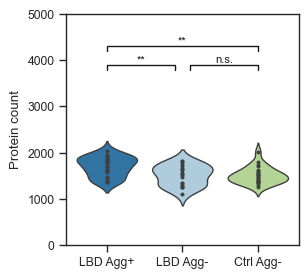

In [ ]:
plot_df = pdata_directinject.summary

type_order = ['LBD Agg+', 'LBD Agg-','Ctrl Agg-']

# make color palette for Ab and PBS
colors = sns.color_palette("Paired")[0:3]
colors[0], colors[1] = colors[1], colors[0]
color_dict = dict(zip(type_order, colors))

# Plot
fig, ax = plt.subplots(figsize=(3, 3))
sns.violinplot(data=plot_df, x="type", y="protein_count", ax=ax, alpha=1, inner='points', palette=color_dict)

from scipy.stats import ttest_ind
ctrlaggN = plot_df[plot_df['type'] == 'Ctrl Agg-']['protein_count']
LBDaggN = plot_df[plot_df['type'] == 'LBD Agg-']['protein_count']
aggY = plot_df[plot_df['type'] == 'LBD Agg+']['protein_count']

scplt.plot_significance(ax, 3800, 100, pval=ttest_ind(aggY, LBDaggN).pvalue, fontsize=8, x1=0, x2=0.9)
scplt.plot_significance(ax, 4200, 100, pval=ttest_ind(aggY, ctrlaggN).pvalue, fontsize=8, x1=0, x2=2)
scplt.plot_significance(ax, 3800, 100, pval=ttest_ind(LBDaggN, ctrlaggN).pvalue, fontsize=8, x1=1.1, x2=2)

# Add significance
plt.ylabel('Protein count')
# remove xlabel
plt.xlabel('')
# plt.xlabel('Ab Treatment')

plt.ylim(0, 5000)
# plt.show()
plt.savefig('sc_ab_pbs_protein_count.svg', bbox_inches='tight')

[get_abundance] 199 peptides could not be mapped to genes: ['AAAIGIDLGTTYSC(UniMod:4)VGVFQHGK3', 'AEDEVQR2', 'AFYPEEISSMVLTK3', 'AGVETTTPSK2', 'AIAEAIKK2', 'ALWEDEGVR2', 'AMGIMNSFVNDIFER3', 'AQIHDLVLVGGSTR2', 'AQIHDLVLVGGSTR3', 'ASGVPDRFSGSGSGTDFTLK3', 'ATEGAIHAVEEVVK2', 'ATEGAIHAVEEVVK3', 'ATIAGGGVIPHIHK2', 'ATIAGGGVIPHIHK3', 'ATITSLWGK2', 'AYALAGVSFEIK2', 'C(UniMod:4)ILQDGR2', 'C(UniMod:4)LVFSLIGLHFK3', 'DAGVIAGLNVLR2', 'DGDGTITTK2', 'DGENYVVLLDSTLPR3', 'DGNGYISAAELR2', 'DIDPQNDLTFLR2', 'DIELVMSQANVSR2', 'DLYANTVLSGGTTMYPGIADR3', 'DLYANTVLSGGTTMYPGIADR4', 'DLYANTVLSGGTTMYPGIADRMQK4', 'DTDSEEEIR2', 'DTDSEEEIREAFR2', 'DTDSEEEIREAFR3', 'DTDSEEEIREAFRVFDK3', 'DTDSEEEIREAFRVFDK4', 'EAFNMIDQNR2', 'EAFSLFDKDGDGTITTK3', 'EDLHDMLASLGK3', 'EHLYFETVTIK2', 'EHLYFETVTIK3', 'EIAQDFK2', 'EIAQDFKTDLR2', 'EIAQDFKTDLR3', 'EIQTAVR2', 'EIQTAVRLLLPGELAK3', 'ELLTTMGDR2', 'EQQLAEIEAR2', 'ESYSVYVYK2', 'ESYSVYVYKVLK3', 'EVVEAHVDQK2', 'FGDPVVQSDMK2', 'FGHEFLEFEFRPDGK3', 'FGHEFLEFEFRPDGK4', 'FLLFSSLVTK2', 'FSG

C:\Users\srpang\AppData\Local\Temp\ipykernel_6996\2122603239.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


Peptide abundance: LBD Agg+ median=5.747 (n=25), LBD Agg- median=5.721 (n=19), t=0.333, p=0.7407
[get_abundance] 199 peptides could not be mapped to genes: ['AAAIGIDLGTTYSC(UniMod:4)VGVFQHGK3', 'AEDEVQR2', 'AFYPEEISSMVLTK3', 'AGVETTTPSK2', 'AIAEAIKK2', 'ALWEDEGVR2', 'AMGIMNSFVNDIFER3', 'AQIHDLVLVGGSTR2', 'AQIHDLVLVGGSTR3', 'ASGVPDRFSGSGSGTDFTLK3', 'ATEGAIHAVEEVVK2', 'ATEGAIHAVEEVVK3', 'ATIAGGGVIPHIHK2', 'ATIAGGGVIPHIHK3', 'ATITSLWGK2', 'AYALAGVSFEIK2', 'C(UniMod:4)ILQDGR2', 'C(UniMod:4)LVFSLIGLHFK3', 'DAGVIAGLNVLR2', 'DGDGTITTK2', 'DGENYVVLLDSTLPR3', 'DGNGYISAAELR2', 'DIDPQNDLTFLR2', 'DIELVMSQANVSR2', 'DLYANTVLSGGTTMYPGIADR3', 'DLYANTVLSGGTTMYPGIADR4', 'DLYANTVLSGGTTMYPGIADRMQK4', 'DTDSEEEIR2', 'DTDSEEEIREAFR2', 'DTDSEEEIREAFR3', 'DTDSEEEIREAFRVFDK3', 'DTDSEEEIREAFRVFDK4', 'EAFNMIDQNR2', 'EAFSLFDKDGDGTITTK3', 'EDLHDMLASLGK3', 'EHLYFETVTIK2', 'EHLYFETVTIK3', 'EIAQDFK2', 'EIAQDFKTDLR2', 'EIAQDFKTDLR3', 'EIQTAVR2', 'EIQTAVRLLLPGELAK3', 'ELLTTMGDR2', 'EQQLAEIEAR2', 'ESYSVYVYK2', 'ESYSVYVYK

C:\Users\srpang\AppData\Local\Temp\ipykernel_6996\2122603239.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


Peptide abundance: LBD Agg+ median=5.747 (n=25), Ctrl Agg- median=5.804 (n=23), t=-0.928, p=0.3581


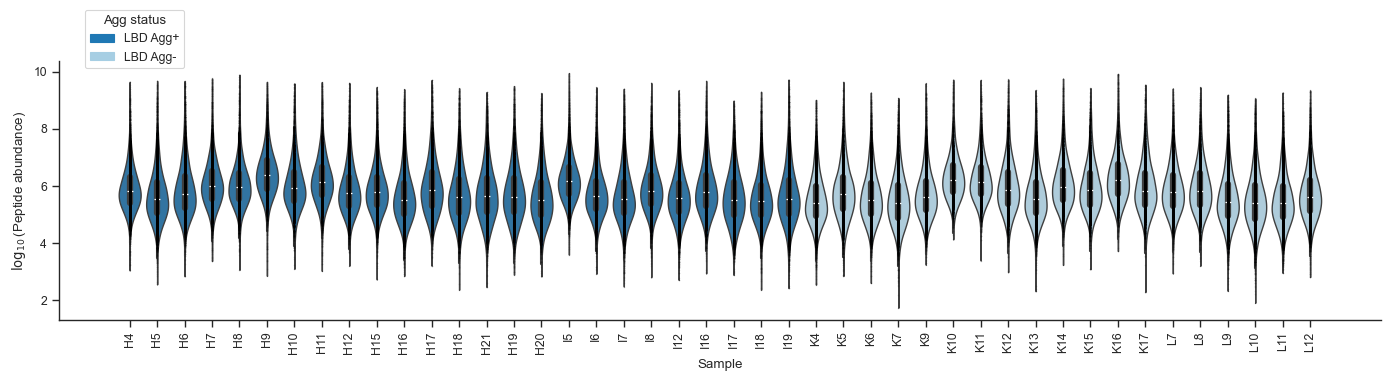

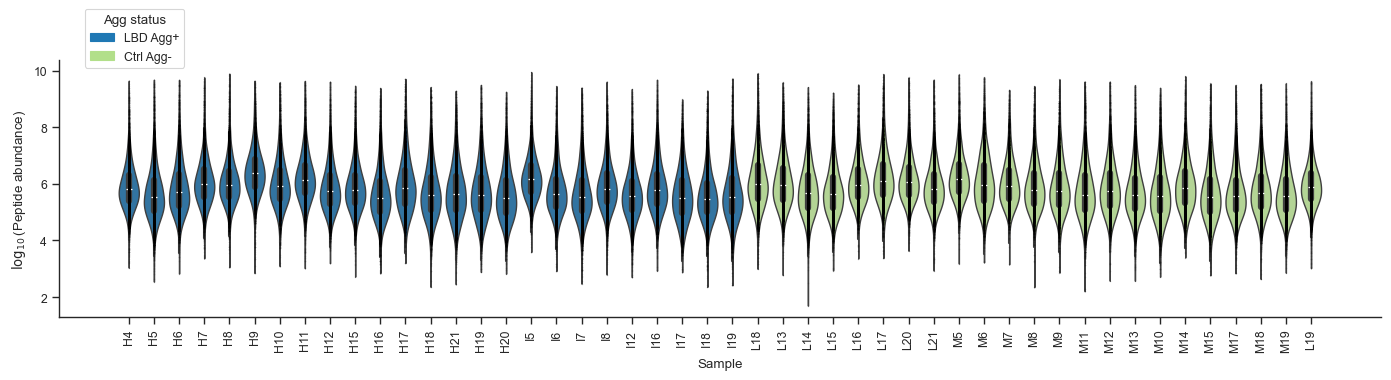

In [ ]:
# CORTEX PEPTIDE ABUNDANCE DIST

import matplotlib.patches as mpatches
from scipy import stats

agg_color_all = {"LBD Agg+": colors[0], "LBD Agg-": colors[1], "Ctrl Agg-": colors[2]}

def plot_peptide_violin(groups, fname):
    agg_color = {k: agg_color_all[k] for k in groups}

    df_raw = pdata_directinject.get_abundance(on="peptide", classes="type", log=False)
    df_raw = df_raw[df_raw["abundance"] > 0].copy()
    df_raw["log10_abundance"] = np.log10(df_raw["abundance"])
    df_raw = df_raw[df_raw["class"].isin(groups)]  # keep only the two groups being compared

    sample_meta = df_raw.groupby("cell")["class"].first()
    sample_order = [c for g in groups for c in sample_meta[sample_meta == g].index.tolist()]
    short_labels = [s.split("_")[-1] for s in sample_order]
    violin_colors = [agg_color[sample_meta[s]] for s in sample_order]

    fig, ax = plt.subplots(figsize=(14, 4))
    sns.violinplot(
        data=df_raw, x="cell", y="log10_abundance", order=sample_order,
        palette=violin_colors, inner="box", cut=0, linewidth=1,
        bw_adjust=1.5, gridsize=200, ax=ax,
    )
    xs = [sample_order.index(c) for c in df_raw["cell"]]
    ax.scatter(xs, df_raw["log10_abundance"], color="black", s=1.3**2, alpha=0.12, linewidths=0, zorder=3)

    ax.set_xlabel("Sample")
    ax.set_ylabel(r"$\log_{10}$(Peptide abundance)")
    ax.set_xticks(range(len(sample_order)))
    ax.set_xticklabels(short_labels, rotation=90)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    handles = [mpatches.Patch(color=agg_color[k], label=k) for k in groups]
    ax.legend(handles=handles, title="Agg status", frameon=True,
              bbox_to_anchor=(0.02, 1.2), loc="upper left", borderaxespad=0)

    plt.tight_layout()
    plt.savefig(fname, bbox_inches="tight", pad_inches=0.1)

    medians = df_raw.groupby("cell")["log10_abundance"].median()
    g1 = medians[sample_meta[medians.index] == groups[0]]
    g2 = medians[sample_meta[medians.index] == groups[1]]
    t, p = stats.ttest_ind(g1, g2)
    print(f"Peptide abundance: {groups[0]} median={g1.mean():.3f} (n={len(g1)}), "
          f"{groups[1]} median={g2.mean():.3f} (n={len(g2)}), t={t:.3f}, p={p:.4f}")

plot_peptide_violin(["LBD Agg+", "LBD Agg-"],
                     "MANUSCRIPT_revision/REVISION_FigX-Human-LBDvsLBD-Abundance_Peptide_Violin.svg")
plot_peptide_violin(["LBD Agg+", "Ctrl Agg-"],
                     "MANUSCRIPT_revision/REVISION_FigX-Human-LBDvsCtrl-Abundance_Peptide_Violin.svg")


Raw (pre-normalization): LBD Agg+ median=5.642 (n=25 cells), LBD Agg- median=5.604 (n=19 cells), t=0.600, p=0.5517
Normalized: LBD Agg+ median=6.698 (n=25 cells), LBD Agg- median=6.629 (n=19 cells), t=1.044, p=0.3025
Raw (pre-normalization): LBD Agg+ median=5.642 (n=25 cells), Ctrl Agg- median=5.693 (n=23 cells), t=-0.935, p=0.3547
Normalized: LBD Agg+ median=6.698 (n=25 cells), Ctrl Agg- median=6.683 (n=23 cells), t=0.255, p=0.7999


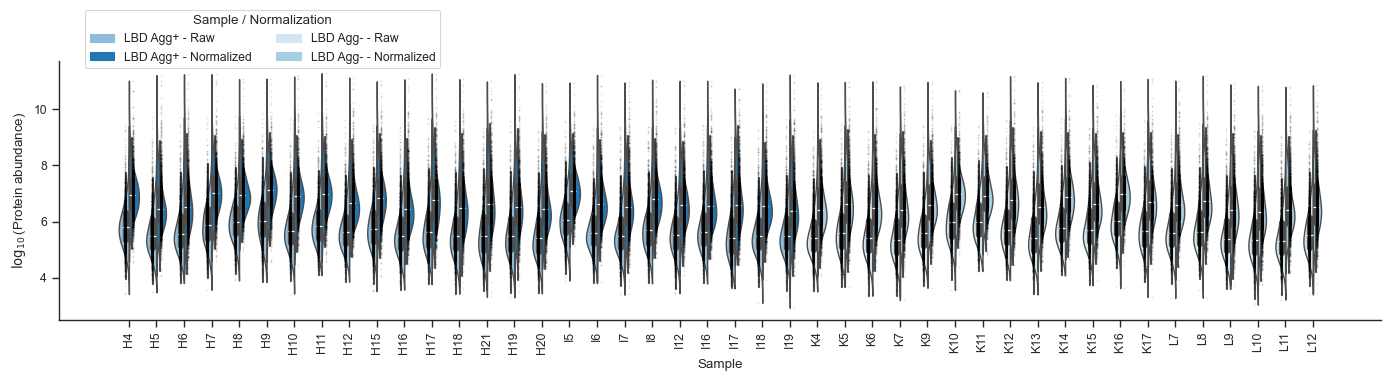

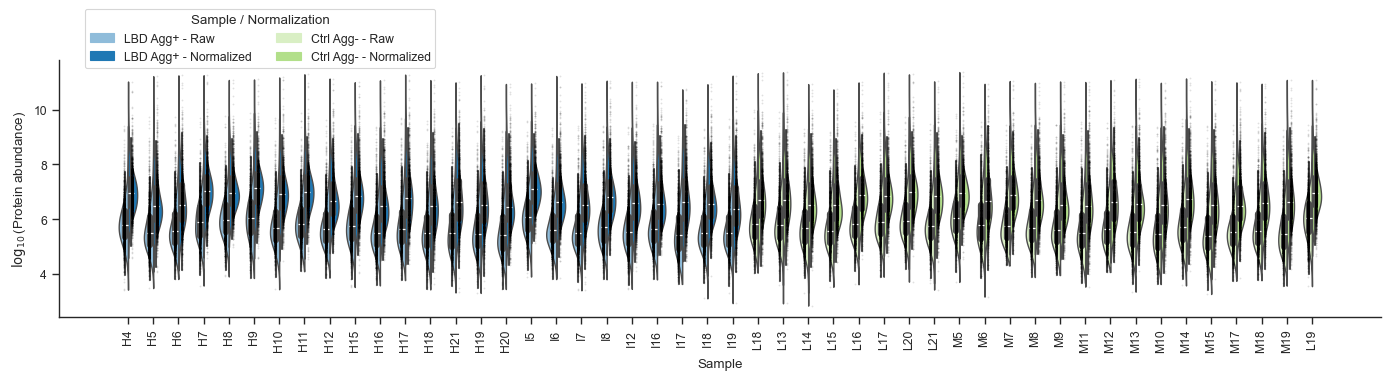

In [17]:
# CORTEX PROTEIN ABUNDANCE DIST (directLFQ) — human LBD/Ctrl

import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from scipy import stats

def lighten(color, amount=0.5):
    c = np.array(mcolors.to_rgb(color))
    return tuple(c + (1 - c) * amount)

agg_color_all = {"LBD Agg+": colors[0], "LBD Agg-": colors[1], "Ctrl Agg-": colors[2]}
agg_color_raw_all = {k: lighten(v) for k, v in agg_color_all.items()}

def plot_protein_split_violin(groups, fname):
    agg_color = {k: agg_color_all[k] for k in groups}
    agg_color_raw = {k: agg_color_raw_all[k] for k in groups}
    agg_order = groups

    # --- load both datasets, tag them, and restrict to the two groups being compared ---
    df_raw = pdata_directinject.get_abundance(on="protein", classes="type", log=False)
    df_raw = df_raw[df_raw["abundance"] > 0].copy()
    df_raw["log10_abundance"] = np.log10(df_raw["abundance"])
    df_raw["norm_status"] = "Raw"
    df_raw = df_raw[df_raw["class"].isin(groups)]

    df_norm = pdata_normDirectLFQ.get_abundance(on="protein", classes="type", log=False)
    df_norm = df_norm[df_norm["abundance"] > 0].copy()
    df_norm["log10_abundance"] = np.log10(df_norm["abundance"])
    df_norm["norm_status"] = "Normalized"
    df_norm = df_norm[df_norm["class"].isin(groups)]

    df = pd.concat([df_raw, df_norm], ignore_index=True)

    sample_meta = df_raw.groupby("cell")["class"].first()
    sample_order = [c for g in groups for c in sample_meta[sample_meta == g].index.tolist()]

    fig, ax = plt.subplots(figsize=(14, 4))

    sns.violinplot(
        data=df,
        x="cell",
        y="log10_abundance",
        hue="norm_status",
        hue_order=["Raw", "Normalized"],
        order=sample_order,
        split=True,
        inner="box",
        cut=0,
        linewidth=1,
        bw_adjust=1.5,
        gridsize=200,
        ax=ax,
    )

    # re-color violin halves: left=Raw (light), right=Normalized (dark)
    for i, sample in enumerate(sample_order):
        agg = sample_meta[sample]
        ax.collections[i * 2].set_facecolor(agg_color_raw[agg])
        ax.collections[i * 2 + 1].set_facecolor(agg_color[agg])

    # stripplot offsets
    for norm_status, offset in [("Raw", -0.15), ("Normalized", 0.15)]:
        sub = df[df["norm_status"] == norm_status]
        xs = [sample_order.index(c) + offset for c in sub["cell"]]
        ax.scatter(xs, sub["log10_abundance"], color="black", s=1.3**2, alpha=0.12, linewidths=0, zorder=3)

    short_labels = [s.split("_")[-1] for s in sample_order]
    ax.set_xlabel("Sample")
    ax.set_ylabel(r"$\log_{10}$(Protein abundance)")
    ax.set_xticks(range(len(sample_order)))
    ax.set_xticklabels(short_labels, rotation=90)
    ax.tick_params(axis="x", rotation=90)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # legend: one row per Agg status, showing light (raw) and dark (norm) patches
    legend_handles = []
    for agg in agg_order:
        legend_handles += [
            mpatches.Patch(color=agg_color_raw[agg], label=f"{agg} - Raw"),
            mpatches.Patch(color=agg_color[agg],     label=f"{agg} - Normalized"),
        ]

    ax.legend(
        handles=legend_handles,
        title="Sample / Normalization",
        frameon=True,
        ncol=2,
        bbox_to_anchor=(0.02, 1.2),
        loc="upper left",
        borderaxespad=0,
    )

    plt.tight_layout()
    plt.savefig(fname, bbox_inches="tight", pad_inches=0.1)

    for label, data in [("Raw (pre-normalization)", df_raw), ("Normalized", df_norm)]:
        medians = data.groupby("cell")["log10_abundance"].median()
        g1 = medians[sample_meta[medians.index] == groups[0]]
        g2 = medians[sample_meta[medians.index] == groups[1]]
        t, p = stats.ttest_ind(g1, g2)
        print(f"{label}: {groups[0]} median={g1.mean():.3f} (n={len(g1)} cells), "
              f"{groups[1]} median={g2.mean():.3f} (n={len(g2)} cells), t={t:.3f}, p={p:.4f}")

plot_protein_split_violin(
    ["LBD Agg+", "LBD Agg-"],
    "MANUSCRIPT_revision/REVISION_FigX-HumanLBDvsLBD-Abundance_SplitViolin.svg",
)
plot_protein_split_violin(
    ["LBD Agg+", "Ctrl Agg-"],
    "MANUSCRIPT_revision/REVISION_FigX-HumanLBDvsCtrl-Abundance_SplitViolin.svg",
)


### DEs

     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=2.18e+06). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: LBD Agg+ vs LBD Agg-
   🔸 Group sizes: 25 vs 19 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 P-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 83 proteins were not comparable (zero or NaN mean in one group).
     ✅ DE complete. Results stored in:
       • .stats["LBD Agg+ vs LBD Agg-"]
       • Columns: log2fc, p_value, significance, etc.
       • Upregulated: 436 | Downregulated: 22 | Not significant: 1742 | Not comparable: 83


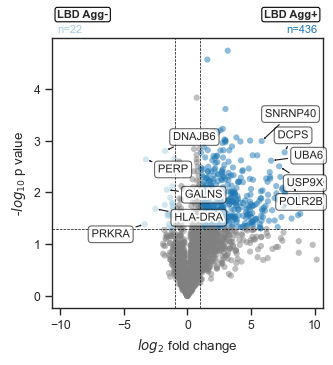

In [17]:
classes='type'
values=['LBD Agg+','LBD Agg-']

colors = sns.color_palette("Paired")[0:2]
vol_color_dict = dict(zip(['downregulated', 'upregulated'], colors))

fig, ax = plt.subplots(1,1, figsize = (3.5,3.5))
ax, df_fcmean = scplt.plot_volcano(ax, pdata_normDirectLFQ, classes=classes, values=values, log2fc=1, pval=0.05, color=vol_color_dict, return_df=True, fold_change_mode='mean')
# scplt.mark_volcano(ax, df, label = ['Anxa1', 'Aldh1a1'])

# plt.savefig("MANUSCRIPT_revision/REVISION_FigX-humanYNCortex_VOLCANO-directlfq.svg", bbox_inches="tight", pad_inches=0.1)
# volcano_df.to_csv("MANUSCRIPT_revision/REVISION_FigX-humanYNCortex-DE-directlfq.csv")

     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=2.18e+06). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: LBD Agg+ vs LBD Agg-
   🔸 Group sizes: 25 vs 19 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 P-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 83 proteins were not comparable (zero or NaN mean in one group).
     ✅ DE complete. Results stored in:
       • .stats["LBD Agg+ vs LBD Agg-"]
       • Columns: log2fc, p_value, significance, etc.
       • Upregulated: 436 | Downregulated: 22 | Not significant: 1742 | Not comparable: 83
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=2.18e+06). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups

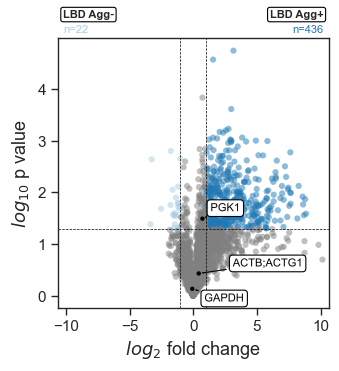

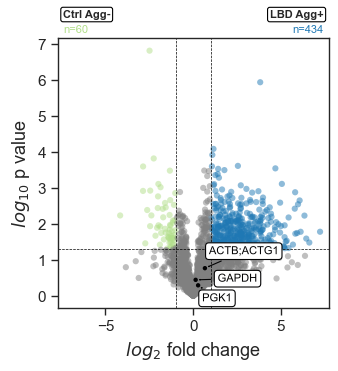

In [6]:
classes='type'
values=['LBD Agg+','LBD Agg-']

colors = sns.color_palette("Paired")[0:2]
vol_color_dict = dict(zip(['downregulated', 'upregulated'], colors))

fig, ax = plt.subplots(1,1, figsize = (3.5,3.5))
ax, volcano_df = scplt.plot_volcano(ax, pdata_normDirectLFQ, 
                                    classes=classes, values=values, 
                                    color=vol_color_dict, return_df=True, label=[0,0])

scplt.mark_volcano(ax, volcano_df, label=['GAPDH','TUBB5','ACTB;ACTG1','PGK1'], label_color="#030304")

ax.set_ylabel('$log_{10}$ p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# plt.show()
plt.savefig("MANUSCRIPT_revision/REVISION_FigX-Human-LBDvsLBD_VOLCANO-directlfq-Housekeeping.svg", bbox_inches="tight", pad_inches=0.1)

#### And for ctrl

classes='type'
values=['LBD Agg+','Ctrl Agg-']

colors = sns.color_palette("Paired")[0:3]
colors.pop(0)
vol_color_dict = dict(zip(['upregulated', 'downregulated'], colors))

fig, ax = plt.subplots(1,1, figsize = (3.5,3.5))
ax, volcano_df = scplt.plot_volcano(ax, pdata_normDirectLFQ, 
                                    classes=classes, values=values, 
                                    color=vol_color_dict, return_df=True, label=[0,0])

scplt.mark_volcano(ax, volcano_df, label=['GAPDH','TUBB5','ACTB;ACTG1','PGK1'], label_color="#030304")

ax.set_ylabel('$log_{10}$ p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# plt.show()
plt.savefig("MANUSCRIPT_revision/REVISION_FigX-Human-LBDvsCtrl_VOLCANO-directlfq-Housekeeping.svg", bbox_inches="tight", pad_inches=0.1)

c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxpl

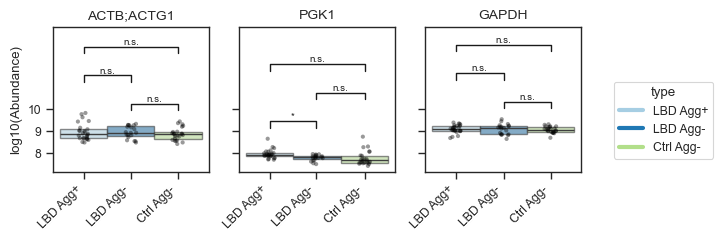

In [5]:

colors = sns.color_palette("Paired")[0:3]
agg_color_all = {"LBD Agg+": colors[0], "LBD Agg-": colors[1], "Ctrl Agg-": colors[2]}

scplt.plot_abundance_boxgrid(pdata=pdata_normDirectLFQ, namelist=['ACTB;ACTG1','PGK1', 'GAPDH'], classes='type', palette=agg_color_all, sig_pairs=True, figsize=(2,2.5), sig_kwargs={"fontsize":7}, log_scale=True)
plt.savefig("MANUSCRIPT_revision/REVISION_FigX_human_ABUNDANCE-Housekeeping.svg", bbox_inches="tight", pad_inches=0.1)


In [54]:
vol_list = df_fcmean[df_fcmean['significance'].isin(["upregulated", "downregulated","not comparable"])].Genes.to_list()

humanYN_sample = pd.read_csv("MANUSCRIPT_revision/REVISION_FigX-humanYNHC_normalized.csv")
humanYN_sample_filtered = humanYN_sample[humanYN_sample['Genes'].isin(vol_list)].copy()

values=['LBD-aggY','LBD-aggN']
humanYN_sample_filtered = humanYN_sample_filtered.filter(regex='LBD-aggY|LBD-aggN|^Genes$')

# map significance from df_fcmean onto the filtered df via Genes
sig_map = df_fcmean.set_index('Genes')['significance']
humanYN_sample_filtered['significance'] = humanYN_sample_filtered['Genes'].map(sig_map)

# sort columns, keeping the first column first and significance last
first_col = humanYN_sample_filtered.columns[0]
other_cols = sorted(c for c in humanYN_sample_filtered.columns if c not in [first_col, 'significance'])
humanYN_sample_filtered = humanYN_sample_filtered[[first_col] + other_cols + ['significance']]

humanYN_sample_filtered.to_csv("MANUSCRIPT_revision/REVISION_FigX-humanYNCortex_volcano-only.csv", index=False)

rpl_list:  18
rps_list:  15
     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=2.18e+06). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: [{'type': 'LBD-aggY'}] vs [{'type': 'LBD-aggN'}]
   🔸 Group sizes: 25 vs 19 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 P-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 83 proteins were not comparable (zero or NaN mean in one group).
     ✅ DE complete. Results stored in:
       • .stats["[{'type': 'LBD-aggY'}] vs [{'type': 'LBD-aggN'}]"]
       • Columns: log2fc, p_value, significance, etc.
       • Upregulated: 436 | Downregulated: 22 | Not significant: 1742


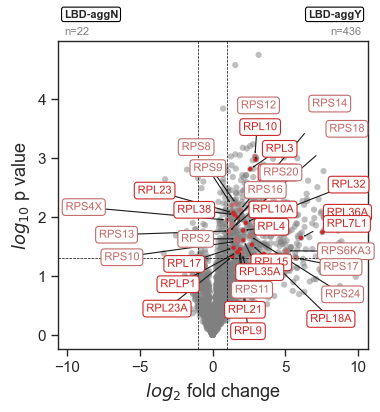

In [79]:
## RPL/RPS
rpl_list, rpl_top5, rpl_others = extract_gene_group(df_fcmean, prefixes=["rpl"])
rps_list, rps_top5, rps_others = extract_gene_group(df_fcmean, prefixes=["rps"])

print("rpl_list: ", len(rpl_list))
print("rps_list: ", len(rps_list))

case_values = [{'type': 'LBD-aggY'}, {'type': 'LBD-aggN'}]

color_dict={'upregulated':"#C64D4A", 'downregulated': "#293DF5",'not_significant': "#FFFFFF6A"}
rps_dict={'downregulated': '#5166FF', 'upregulated': "#C26A69"}
rpl_dict={'downregulated': '#1F2CCF', 'upregulated': "#CA2927"}

fig, ax = plt.subplots(figsize=(4, 4))
ax, df_fcmean = scplt.plot_volcano(ax, pdata_normDirectLFQ,
                                    values=case_values,
                                    pval=0.05, return_df=True,
                                    fold_change_mode='mean', no_marks=True)

texts = []
ax, t = scplt.mark_volcano_by_significance(ax, df_fcmean, label=rpl_list, color=rpl_dict,return_texts=True)
texts.extend(t)
ax, t = scplt.mark_volcano_by_significance(ax, df_fcmean, label=rps_list, color=rps_dict,return_texts=True)
texts.extend(t)

scplt.volcano_adjust_and_outline_texts(texts, expand=(2,2))

ax.set_ylabel('$log_{10}$ p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# plt.show()
plt.savefig("MANUSCRIPT_revision/REVISION_FigXHumanCortex_VOLCANO-directlfq-RplRps.svg", bbox_inches="tight", pad_inches=0.1)

proteasome_list:  13
     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=2.18e+06). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: [{'type': 'LBD-aggY'}] vs [{'type': 'LBD-aggN'}]
   🔸 Group sizes: 25 vs 19 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 P-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 83 proteins were not comparable (zero or NaN mean in one group).
     ✅ DE complete. Results stored in:
       • .stats["[{'type': 'LBD-aggY'}] vs [{'type': 'LBD-aggN'}]"]
       • Columns: log2fc, p_value, significance, etc.
       • Upregulated: 436 | Downregulated: 22 | Not significant: 1742


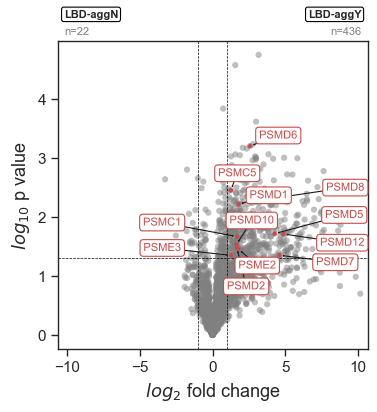

In [80]:
## Proteasome
proteasome_list, proteasome_top5, proteasome_others = extract_gene_group(df_fcmean, prefixes=["psm"])
proteasome_list.append('Uchl1')

print("proteasome_list: ", len(proteasome_list))

case_values = [{'type': 'LBD-aggY'}, {'type': 'LBD-aggN'}]

color_dict={'upregulated':"#C64D4A", 'downregulated': "#293DF5",'not_significant': "#FFFFFF6A"}

fig, ax = plt.subplots(figsize=(4, 4))
ax, volcano_df = scplt.plot_volcano(ax, pdata_normDirectLFQ,
                                    values=case_values,
                                    pval=0.05, return_df=True,
                                    fold_change_mode='mean', no_marks=True)

texts = []
ax, t = scplt.mark_volcano_by_significance(ax, df_fcmean, label=proteasome_list, color=color_dict, return_texts=True)
texts.extend(t)
scplt.volcano_adjust_and_outline_texts(texts, expand=(2, 2))
# scplt.mark_volcano_by_significance(ax, volcano_df, label=proteasome_top5, color=color_dict)
# scplt.mark_volcano_by_significance(ax, volcano_df, label=proteasome_others, color=color_dict, show_names=False)

ax.set_ylabel('$log_{10}$ p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

plt.savefig("MANUSCRIPT_revision/REVISION_FigXHumanCortex_VOLCANO-directlfq-Proteasome.svg", bbox_inches="tight", pad_inches=0.1)

     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=2.18e+06). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: [{'type': 'LBD-aggY'}] vs [{'type': 'LBD-aggN'}]
   🔸 Group sizes: 25 vs 19 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 P-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 83 proteins were not comparable (zero or NaN mean in one group).
     ✅ DE complete. Results stored in:
       • .stats["[{'type': 'LBD-aggY'}] vs [{'type': 'LBD-aggN'}]"]
       • Columns: log2fc, p_value, significance, etc.
       • Upregulated: 436 | Downregulated: 22 | Not significant: 1742


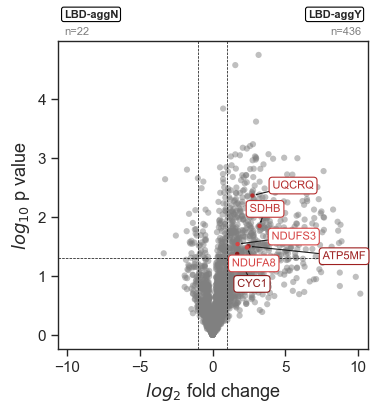

In [81]:
## Mitochondria

mito_groups = {
    "complex5":   ["atp5"],
    "complex4":   ["cox"],
    "complex1":   ["nduf"],
    "complex2":   ["sdh"],
    "complex3":   ["uqcr"],
    "mito_other": ["cyc1", "cycs", "pgk", "vdac"],
}

mito_results = {}

for group_name, prefixes in mito_groups.items():
    gene_list, top5, others = extract_gene_group(df_fcmean, prefixes)
    mito_results[group_name] = {
        "list": gene_list,
        "top5": top5,
        "others": others,
    }

mito_color_dict = {
    "complex1": {     # NDUF*
        "upregulated":   "#D64545",   # strong red
        "downregulated": "#1E3A8A",   # deep indigo blue
    },
    "complex2": {     # SDH*
        "upregulated":   "#C03636",   # darker red
        "downregulated": "#1F4DA0",   # strong royal blue
    },
    "complex3": {     # UQCR*
        "upregulated":   "#B42E2E",   # deep cherry
        "downregulated": "#2665C2",   # vivid blue
    },
    "complex4": {     # COX*
        "upregulated":   "#A82828",   # wine red
        "downregulated": "#2D7AE6",   # bright azure
    },
    "complex5": {     # ATP5*
        "upregulated":   "#9E2020",   # maroon
        "downregulated": "#3D8BFF",   # clear blue
    },
    "mito_other": {
        "upregulated":   "#8C1A1A",   # dark brick red
        "downregulated": "#4C9CFF",   # lighter but still strong blue
    },
}

## Mitochondria, all together

case_values = [{'type': 'LBD-aggY'}, {'type': 'LBD-aggN'}]

color_dict={'upregulated':"#C64D4A", 'downregulated': "#293DF5",'not_significant': "#FFFFFF6A"}

fig, ax = plt.subplots(figsize=(4, 4))
ax, df_fcmean = scplt.plot_volcano(ax, pdata_normDirectLFQ,
                                    values=case_values,
                                    pval=0.05, return_df=True,
                                    fold_change_mode='mean', no_marks=True)

texts = []
for group_name, d in mito_results.items():
    colors = mito_color_dict[group_name]

    if len(d["top5"]) > 0:
        # highlight top 5 (with names)
        ax, t = scplt.mark_volcano_by_significance(
            ax, df_fcmean,
            label=d["top5"],
            color=colors,
            return_texts=True,
        )

        texts.extend(t)

    if len(d["others"]) > 0:
        # highlight the others (no names)
        scplt.mark_volcano_by_significance(
            ax, df_fcmean,
            label=d["others"],
            color=colors,
            show_names=False,
        )

scplt.volcano_adjust_and_outline_texts(texts, expand=(2,2))

ax.set_ylabel('$log_{10}$ p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

plt.savefig("MANUSCRIPT_revision/REVISION_FigXHumanCortex_VOLCANO-directlfq-MitoAll.svg", bbox_inches="tight", pad_inches=0.1)

     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=2.18e+06). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: [{'type': 'LBD-aggY'}] vs [{'type': 'Ctrl-aggN'}]
   🔸 Group sizes: 25 vs 23 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 P-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 30 proteins were not comparable (zero or NaN mean in one group).
     ✅ DE complete. Results stored in:
       • .stats["[{'type': 'LBD-aggY'}] vs [{'type': 'Ctrl-aggN'}]"]
       • Columns: log2fc, p_value, significance, etc.
       • Upregulated: 434 | Downregulated: 60 | Not significant: 1759


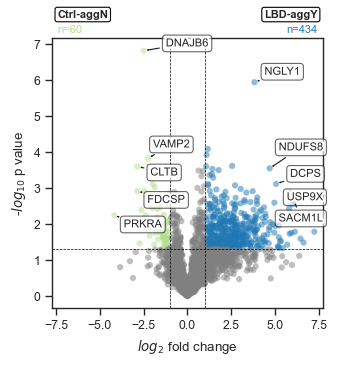

In [ ]:
classes='type'
values=['LBD Agg+','Ctrl Agg-']

colors = sns.color_palette("Paired")[0:3]
colors.pop(0)
vol_color_dict = dict(zip(['upregulated', 'downregulated'], colors))

fig, ax = plt.subplots(1,1, figsize = (3.5,3.5))
ax, df_YHC = scplt.plot_volcano(ax, pdata_normDirectLFQ, classes=classes, values=values, log2fc=1, pval=0.05, color=vol_color_dict, return_df=True, fold_change_mode='mean')
# scplt.mark_volcano(ax, df, label = ['Anxa1', 'Aldh1a1'])

plt.savefig("MANUSCRIPT_revision/REVISION_FigX-humanYHCCortex_VOLCANO-directlfq.svg", bbox_inches="tight", pad_inches=0.1)
volcano_df.to_csv("MANUSCRIPT_revision/REVISION_FigX-humanYHCCortex-DE-directlfq.csv")

In [52]:
vol_list = df_YHC[df_YHC['significance'].isin(["upregulated", "downregulated","not comparable"])].Genes.to_list()

humanYHC_sample = pd.read_csv("MANUSCRIPT_revision/REVISION_FigX-humanYNHC_normalized.csv")
humanYHC_sample_filtered = humanYHC_sample[humanYHC_sample['Genes'].isin(vol_list)].copy()

values=['LBD-aggY','Ctrl-aggN']
humanYHC_sample_filtered = humanYHC_sample_filtered.filter(regex='LBD-aggY|Ctrl-aggN|^Genes$')

# map significance from df_YHC onto the filtered df via Genes
sig_map = df_YHC.set_index('Genes')['significance']
humanYHC_sample_filtered['significance'] = humanYHC_sample_filtered['Genes'].map(sig_map)

# sort columns, keeping the first column first and significance last
first_col = humanYHC_sample_filtered.columns[0]
other_cols = sorted(c for c in humanYHC_sample_filtered.columns if c not in [first_col, 'significance'])
humanYHC_sample_filtered = humanYHC_sample_filtered[[first_col] + other_cols + ['significance']]

humanYHC_sample_filtered.to_csv("MANUSCRIPT_revision/REVISION_FigX-humanYHCCortex_volcano-only.csv", index=False)

### heatmap 

In [25]:
type_order = ['LBD Agg+', 'LBD Agg-','Ctrl Agg-']

# make color palette for Ab and PBS
colors = sns.color_palette("Paired")[0:3]
colors[0], colors[1] = colors[1], colors[0]
color_dict = dict(zip(type_order, colors))

     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=2.18e+06). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: LBD Agg+ vs Ctrl Agg-
   🔸 Group sizes: 25 vs 23 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 P-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 30 proteins were not comparable (zero or NaN mean in one group).
     ✅ DE complete. Results stored in:
       • .stats["LBD Agg+ vs Ctrl Agg-"]
       • Columns: log2fc, p_value, significance, etc.
       • Upregulated: 434 | Downregulated: 60 | Not significant: 1759 | Not comparable: 30
     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensit

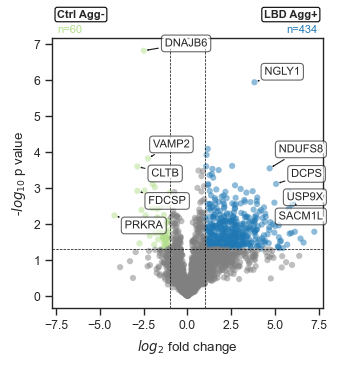

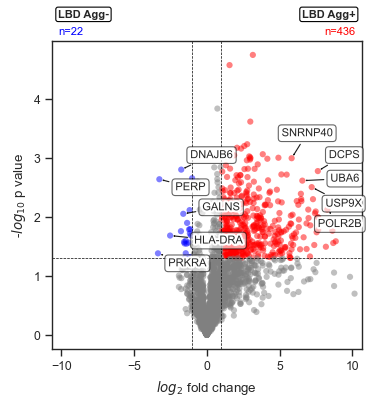

In [18]:
classes='type'
values=['LBD Agg+','Ctrl Agg-']

colors = sns.color_palette("Paired")[0:3]
colors.pop(0)
vol_color_dict = dict(zip(['upregulated', 'downregulated'], colors))

fig, ax = plt.subplots(1,1, figsize = (3.5,3.5))
ax, df_YHC = scplt.plot_volcano(ax, pdata_normDirectLFQ, classes=classes, values=values, log2fc=1, pval=0.05, color=vol_color_dict, return_df=True, fold_change_mode='mean')

case_values = [{'type': 'LBD Agg+'}, {'type': 'LBD Agg-'}]

color_dict={'upregulated':"#C64D4A", 'downregulated': "#293DF5",'not_significant': "#FFFFFF6A"}

fig, ax = plt.subplots(figsize=(4, 4))
ax, df_YNC = scplt.plot_volcano(ax, pdata_normDirectLFQ,
                                    values=case_values,
                                    pval=0.05, return_df=True,
                                    fold_change_mode='mean')


In [23]:
combined_df = pd.concat([df_YHC, df_YNC], ignore_index=True)

def extract_gene_group(volcano_df, prefixes, top_n=5):
    """prefixes: list of lowercase prefixes, e.g. ['atp5']"""
    mask_prefix = volcano_df["Genes"].str.lower().str.startswith(tuple(prefixes), na=False)
    sig_mask = volcano_df["significance"].isin(["upregulated", "downregulated"])

    gene_list = volcano_df.loc[mask_prefix & sig_mask, "Genes"].unique().tolist()
    if not gene_list:
        return [], [], []

    top = (
        volcano_df[volcano_df["Genes"].isin(gene_list)]
        .sort_values("significance_score", ascending=True)
        .drop_duplicates("Genes")
        .head(top_n)["Genes"]
        .tolist()
    )
    others = [g for g in gene_list if g not in top]
    return gene_list, top, others

In [26]:
rpl_list, rpl_top5, rpl_others = extract_gene_group(combined_df, prefixes=["rpl"])
rps_list, rps_top5, rps_others = extract_gene_group(combined_df, prefixes=["rps"])

proteasome_list, proteasome_top5, proteasome_others = extract_gene_group(combined_df, prefixes=["psm"])
proteasome_list.append('Uchl1')

mito_groups = {
    "complex5":   ["atp5"],
    "complex4":   ["cox"],
    "complex1":   ["nduf"],
    "complex2":   ["sdh"],
    "complex3":   ["uqcr"],
    "mito_other": ["cyc1", "cycs", "pgk", "vdac"],
}

mito_results = {}
for group_name, prefixes in mito_groups.items():
    gene_list, top5, others = extract_gene_group(combined_df, prefixes)
    mito_results[group_name] = {
        "list": gene_list,
        "top5": top5,
        "others": others,
    }

print(len(rpl_list))
print(len(rps_list))
print(len(proteasome_list))
for group_name, d in mito_results.items():
    print(len(d['list']))


protein_groups = {
    "Ribosome": rpl_list + rps_list, 
    "Proteasome": proteasome_list,
    "Mitochondria": [gene for d in mito_results.values() for gene in d["list"]]
    }

proteins=rpl_list + rps_list + proteasome_list + [gene for d in mito_results.values() for gene in d["list"]]
print(len(proteins))

18
15
16
3
0
4
1
3
1
61


     ℹ️ [INFO] display_scale='zscore' (auto: default (explicit protein list / no DE stats_key)).
     ⚠️ [WARN] A match was not found for the following:
  - Uchl1
     ⚠️ [WARN] protein 'Uchl1' not found in this pAnnData — excluded from clustered heatmap
     ⚠️ [WARN] Layer 'X' appears non-log (median=1.5e+06). Applying log2(x + 1.0) in memory for this heatmap only. To persist: `pdata.log_transform(layer='X', base=2)` then `layer='X_log2'`.


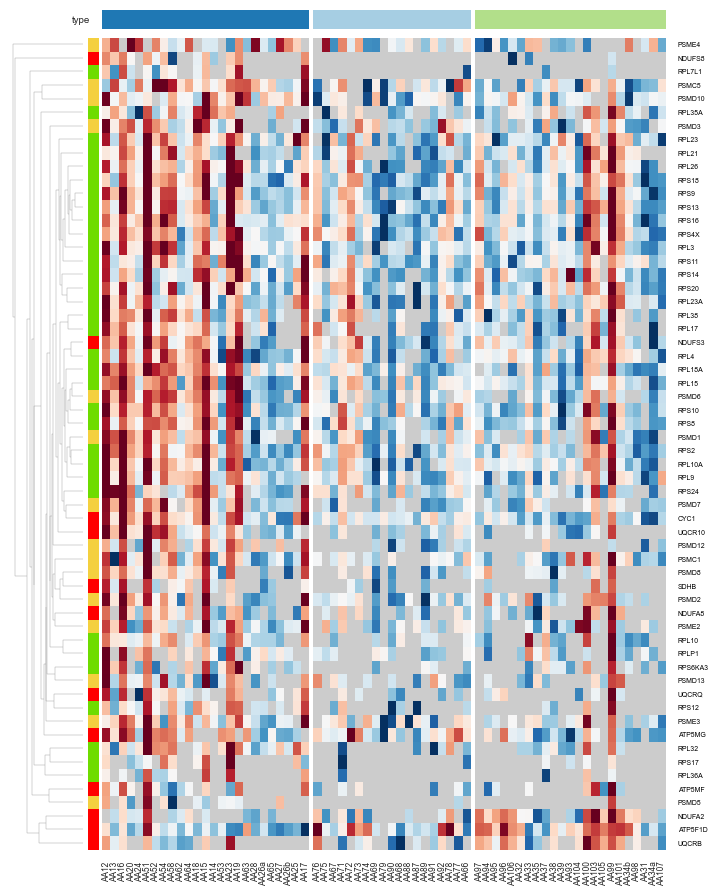

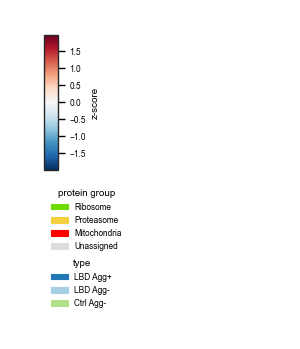

In [35]:
fig, fig_legend = pdata_normDirectLFQ.plot_clustered_heatmap(
    classes=["type"],
    proteins=proteins,
    sort_by={"type": ["LBD Agg+", "LBD Agg-", "Ctrl Agg-"]},
    # optional annotation overlay:
    protein_groups=protein_groups,
    group_colors={"Ribosome": "#6EDC00", "Proteasome": "#F4D03F", "Mitochondria": "#FF0000",},
    header_colors=color_dict,
    show_unassigned=False,
    sample_label_col="sample_id",
    label_color="Black",
    header_spacing=0.02,
    text_size=7,
    separate_legend=True,
    figsize=(8,10),
    dendrogram_linewidth=0.3
)

fig.savefig("MANUSCRIPT_revision/REVISION_FigX_Human-Heatmap.svg", bbox_inches="tight", pad_inches=0.1)
fig_legend.savefig("MANUSCRIPT_revision/REVISION_FigX_Human-Heatmap_legend.svg", bbox_inches="tight", pad_inches=0.1)


     ℹ️ [INFO] display_scale='zscore' (auto: default (explicit protein list / no DE stats_key)).
     ⚠️ [WARN] Layer 'X' appears non-log (median=1.5e+06). Applying log2(x + 1.0) in memory for this heatmap only. To persist: `pdata.log_transform(layer='X', base=2)` then `layer='X_log2'`.
     ⚠️ [WARN] protein 'Uchl1' not found in this pAnnData — row shown empty
     ℹ️ [INFO] Row 'Uchl1' is missing from data (all cells grey).


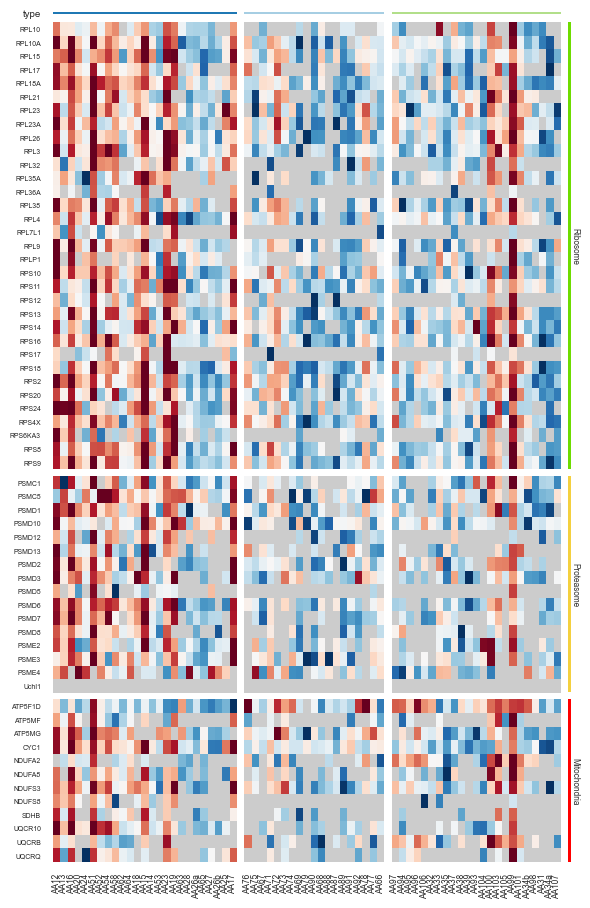

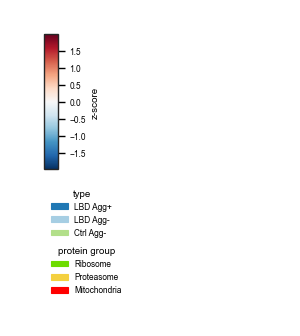

In [42]:
fig, fig_legend = pdata_normDirectLFQ.plot_grouped_heatmap(
    classes=["type"],
    protein_groups=protein_groups,
    sort_by={"type": ["LBD Agg+", "LBD Agg-", "Ctrl Agg-"]},
    # optional annotation overlay:
    group_colors={"Ribosome": "#6EDC00", "Proteasome": "#F4D03F", "Mitochondria": "#FF0000",},
    header_colors=color_dict,
    sample_label_col="sample_id",
    label_color="Black",
    header_spacing=0.02,
    group_bar_pad=1,
    column_spacing=2,
    row_spacing=1,
    text_size=7,
    separate_legend=True,
    figsize=(8,10),
)

fig.savefig("MANUSCRIPT_revision/REVISION_FigX_Human-GroupedHeatmap.svg", bbox_inches="tight", pad_inches=0.1)
fig_legend.savefig("MANUSCRIPT_revision/REVISION_FigX_Human-GroupedHeatmap_legend.svg", bbox_inches="tight", pad_inches=0.1)


## cc

In [25]:
import re

# (plasma membrane separate; organelle membranes go with organelle)
selected_components = [
    "cytoplasm",
    "plasma membrane",
    "extracellular region",
    "mitochondrion",
    "nucleus",
    "endoplasmic reticulum",
    "golgi apparatus",
    "cytoskeleton",
]

label_map = {
    "cytoplasm": "Cytoplasm",
    "plasma membrane": "Plasma membrane",
    "extracellular region": "Extracellular region",
    "mitochondrion": "Mitochondria",
    "nucleus": "Nucleus",
    "endoplasmic reticulum": "ER",
    "golgi apparatus": "Golgi apparatus",
    "cytoskeleton": "Cytoskeleton",
    "others": "Others",
}

plot_order = selected_components + ["others"]

def _clean_cc_term(s: str) -> str:
    if pd.isna(s):
        return ""
    s = str(s).strip()
    s = re.sub(r"\[.*?\]", "", s).strip()
    return s

def map_cc_term(term: str) -> str:
    t = term.lower()

    # cytoskeleton (keep separate)
    if "cytoskeleton" in t:
        return "cytoskeleton"

    # nucleus
    if re.search(r"\bnucleus\b|nucleoplasm|nuclear", t):
        return "nucleus"

    # cytoplasm (cytosol/cytoplasmic included)
    if re.search(r"cytosol|cytoplasm|cytoplasmic", t):
        return "cytoplasm"

    # extracellular
    if "extracellular" in t:
        return "extracellular region"

    # ER (includes ER membrane etc.)
    if "endoplasmic reticulum" in t:
        return "endoplasmic reticulum"

    # Golgi
    if "golgi" in t:
        return "golgi apparatus"

    # mitochondrion (includes mitochondrial membrane etc.)
    if "mitochondri" in t:
        return "mitochondrion"

    # plasma membrane (keep separate from generic "membrane")
    if "plasma membrane" in t:
        return "plasma membrane"

    # everything else
    return "others"

def build_cc_df(df, cc_col="gene_ontology_cellular_component", protein_col=None, source_name=None):
    prot = df.index.to_series() if protein_col is None else df[protein_col]
    out = df[[cc_col]].copy()
    out["protein"] = prot.values
    out = out.rename(columns={cc_col: "cc_raw"})
    if source_name is not None:
        out["source"] = source_name

    out["cc_raw"] = out["cc_raw"].astype(str).str.split(";")
    out = out.explode("cc_raw", ignore_index=True)

    out["cc_clean"] = out["cc_raw"].map(_clean_cc_term)
    out = out[out["cc_clean"].ne("") & out["cc_clean"].ne("nan")].copy()

    out["cc_mapped"] = out["cc_clean"].map(map_cc_term)
    out["in_selected"] = out["cc_mapped"].isin(selected_components)
    return out

def counts_from_cc_df(cc_df):
    return cc_df["cc_mapped"].value_counts()

In [26]:
human_upset = scutils.get_upset_contents(pdata_directinject, classes = ['type'])
human_cntrl_all = scutils.get_upset_query(human_upset, present='Ctrl Agg-', absent=[], fetch_uniprot=True)

Classes: type, Values: LBD Agg+
Filter query: ((adata.obs['type'] == 'LBD Agg+'))
Classes: type, Values: LBD Agg-
Filter query: ((adata.obs['type'] == 'LBD Agg-'))
Classes: type, Values: Ctrl Agg-
Filter query: ((adata.obs['type'] == 'Ctrl Agg-'))


In [ ]:
human_cntrl_all.to_csv('human_cc_cntrl.csv')

In [31]:
human_cntrl_all

,accession,id,protein_names,gene_primary,gene_names,organism_id,gene_ontology_go,gene_ontology_molecular_function,gene_ontology_cellular_component,gene_ontology_biological_process,interacts_with,xref_string
0,O14744,ANM5_HUMAN,Protein arginine N-methyltransferase 5 (PRMT5)...,PRMT5,PRMT5 HRMT1L5 IBP72 JBP1 SKB1,9606,chromatin [GO:0000785]; cytoplasm [GO:0005737]...,E-box binding [GO:0070888]; histone H3 methylt...,chromatin [GO:0000785]; cytoplasm [GO:0005737]...,chromatin remodeling [GO:0006338]; circadian r...,P01019; Q9NX04; Q8WUW1; Q08289; P78371; Q16543...,9606.ENSP00000319169
1,O43747,AP1G1_HUMAN,AP-1 complex subunit gamma-1 (Adaptor protein ...,AP1G1,AP1G1 ADTG CLAPG1,9606,AP-1 adaptor complex [GO:0030121]; clathrin-co...,clathrin adaptor activity [GO:0035615]; GTP-de...,AP-1 adaptor complex [GO:0030121]; clathrin-co...,basolateral protein secretion [GO:0110010]; en...,P56377; Q15276; Q6PD74; P56377; P54253; Q96S82,9606.ENSP00000377148
2,O43837,IDH3B_HUMAN,"Isocitrate dehydrogenase [NAD] subunit beta, m...",IDH3B,IDH3B,9606,isocitrate dehydrogenase complex (NAD+) [GO:00...,electron transfer activity [GO:0009055]; isoci...,isocitrate dehydrogenase complex (NAD+) [GO:00...,isocitrate metabolic process [GO:0006102]; tri...,PRO_0000014436 [P50213],9606.ENSP00000482773
3,O60716,CTND1_HUMAN,Catenin delta-1 (Cadherin-associated Src subst...,CTNND1,CTNND1 KIAA0384,9606,adherens junction [GO:0005912]; catenin comple...,cadherin binding [GO:0045296]; cell-cell adhes...,adherens junction [GO:0005912]; catenin comple...,cell migration involved in sprouting angiogene...,P12830; P19022; P00533; Q7Z6J6; P08581; O14495...,9606.ENSP00000382004
4,O75369,FLNB_HUMAN,Filamin-B (FLN-B) (ABP-278) (ABP-280 homolog) ...,FLNB,FLNB FLN1L FLN3 TABP TAP,9606,actin cytoskeleton [GO:0015629]; brush border ...,actin binding [GO:0003779]; actin filament bin...,actin cytoskeleton [GO:0015629]; brush border ...,actin cytoskeleton organization [GO:0030036]; ...,P21333; O75369; P62993; P05161; Q13233; Q9Y6R4...,9606.ENSP00000420213
...,...,...,...,...,...,...,...,...,...,...,...,...
2253,Q9H0I9,TKTL2_HUMAN,Transketolase-like protein 2 (EC 2.2.1.1),TKTL2,TKTL2,9606,cytoplasm [GO:0005737]; cytosol [GO:0005829]; ...,metal ion binding [GO:0046872]; thiamine pyrop...,cytoplasm [GO:0005737]; cytosol [GO:0005829],NaN,NaN,9606.ENSP00000280605
2254,A0A0C4DH41,HV461_HUMAN,Immunoglobulin heavy variable 4-61,IGHV4-61,IGHV4-61,9606,extracellular region [GO:0005576]; immunoglobu...,antigen binding [GO:0003823],extracellular region [GO:0005576]; immunoglobu...,immunoglobulin mediated immune response [GO:00...,NaN,NaN
2255,Q13296,SG2A2_HUMAN,Mammaglobin-A (Mammaglobin-1) (Secretoglobin f...,SCGB2A2,SCGB2A2 MGB1 UGB2,9606,extracellular space [GO:0005615]; androgen rec...,NaN,extracellular space [GO:0005615],androgen receptor signaling pathway [GO:0030521],P50552,9606.ENSP00000227918
2256,Q9UJC5,SH3L2_HUMAN,SH3 domain-binding glutamic acid-rich-like pro...,SH3BGRL2,SH3BGRL2 FASH3,9606,nucleoplasm [GO:0005654]; nucleus [GO:0005634]...,protein-macromolecule adaptor activity [GO:003...,nucleoplasm [GO:0005654]; nucleus [GO:0005634],NaN,NaN,9606.ENSP00000358853


In [28]:
df_human_proteome = pd.read_csv("MANUSCRIPT_revision/uniprotkb_taxonomy_id_9606_AND_reviewed_2026_08_19.tsv", delimiter='\t')
df_human_proteome

,Entry,Reviewed,Entry Name,Protein names,Gene Names,Gene Ontology (cellular component)
0,A0A087X1C5,reviewed,CP2D7_HUMAN,Cytochrome P450 2D7 (EC 1.14.14.1),CYP2D7,cytoplasm [GO:0005737]; membrane [GO:0016020];...
1,A0A096LP01,reviewed,SIM26_HUMAN,Small integral membrane protein 26,SMIM26 LINC00493,mitochondrial outer membrane [GO:0005741]; mit...
2,A0A0B4J2F0,reviewed,PIOS1_HUMAN,Protein PIGBOS1 (PIGB opposite strand protein 1),PIGBOS1,mitochondrial outer membrane [GO:0005741]; mit...
3,A0A0C5B5G6,reviewed,MOTSC_HUMAN,Mitochondrial-derived peptide MOTS-c (Mitochon...,MT-RNR1,extracellular space [GO:0005615]; mitochondrio...
4,A0A0K2S4Q6,reviewed,CD3CH_HUMAN,Protein CD300H (CD300 antigen-like family memb...,CD300H,extracellular region [GO:0005576]; plasma memb...
...,...,...,...,...,...,...
20427,Q9UI25,reviewed,YP002_HUMAN,Putative uncharacterized protein PRO0461,PRO0461,NaN
20428,Q9UI54,reviewed,YT001_HUMAN,Putative uncharacterized protein PRO0628,PRO0628,NaN
20429,Q9UI72,reviewed,YE014_HUMAN,Putative uncharacterized protein PRO0255,PRO0255,NaN
20430,Q9Y3F1,reviewed,TA6P_HUMAN,Putative TAP2-associated 6.5 kDa polypeptide,NaN,NaN


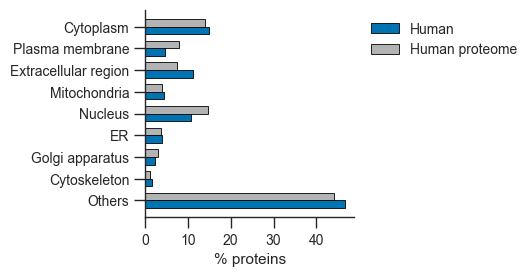

In [37]:
# check df
cntrl_cc_df = build_cc_df(human_cntrl_all, protein_col=None, source_name="pos")
human_cc_df  = build_cc_df(df_human_proteome, protein_col="Entry Name",
                           cc_col="Gene Ontology (cellular component)", source_name="human")

# counts 
cntrl_counts = counts_from_cc_df(cntrl_cc_df).reindex(plot_order, fill_value=0)
human_counts  = counts_from_cc_df(human_cc_df).reindex(plot_order, fill_value=0)


# convert to %
cntrl_pct = cntrl_counts / cntrl_counts.sum() * 100
human_pct  = human_counts  / human_counts.sum()  * 100

# order top→bottom like your plot
labels = plot_order[::-1]
display_labels = [label_map[l] for l in labels]
cntrl_pct = cntrl_pct.reindex(labels)
human_pct  = human_pct.reindex(labels)

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})



# bar chart
fig, ax = plt.subplots(figsize=(2.7, 2.7))

y = np.arange(len(labels))
h = 0.35

ax.barh(y - h/2, cntrl_pct.values,   height=h, label="Human",
        color=(0.00, 0.45, 0.70), edgecolor="black", linewidth=0.6)
ax.barh(y + h/2, human_pct.values, height=h, label="Human proteome",
        color=(0.70, 0.70, 0.70), edgecolor="black", linewidth=0.6)

ax.set_yticks(y)
ax.set_yticklabels(display_labels)
ax.set_xlabel("% proteins")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", width=1.0, length=8)

ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.show()
# plt.savefig("MANUSCRIPT/MANUSCRIPT_FigS1-FF_CC.svg", bbox_inches="tight")


# Fig X - NHP

In [2]:
obs_columns = ['date', 'acquisition', 'sample_id','size','confirmation','thickness','type','organism','region','well_position']

pdata = pAnnData.import_data(source_type='diann',report_file = 'data/2509_NHP/human_fasta/report.parquet', obs_columns=obs_columns)


🧭 [USER] Importing data of type [diann]
--------------------------
Starting import [DIA-NN]

Source file: data/2509_NHP/human_fasta/report.parquet
Number of files: 44
Proteins: 6777
Peptides: 53936

     ℹ️ [INFO] Using sample-specific q-values for 'prot' significance annotation.
     ℹ️ [INFO] Using sample-specific q-values for 'pep' significance annotation.

ℹ️ RS matrix: (6777, 53936) (proteins × peptides), sparsity: 99.99%
   - Proteins with ≥2 *unique* linked peptides: 4997/6777
   - Peptides linked to ≥2 proteins: 281/53936
   - Mean peptides per protein: 8.03
   - Mean proteins per peptide: 1.01
     ✅ [OK] pAnnData object is valid.
     ✅ [OK] Import complete. Use `print(pdata)` to view the object.
--------------------------


In [4]:
pd.DataFrame(pdata.summary)

[summary] ⚠️ Warning: .summary has been modified. Run `(pdata).update_summary()` to sync changes back to .obs.


,date,acquisition,sample_id,size,confirmation,thickness,type,organism,region,well_position,protein_quant,protein_count,protein_abundance_sum,peptide_quant,peptide_count,peptide_abundance_sum,unique_pep2_protein_count
20250930_Aur25minDIA_NP2_1200-2400_Y1_40um_aggY_NHP_SNpc_D5desalt,20250930,Aur25minDIA,NP2,1200-2400,Y1,40um,aggY,NHP,SNpc,D5desalt,0.797255,5403,1.210358e+09,0.687278,37069,5.375216e+09,4526
20250930_Aur25minDIA_NP1_1200-2400_Y1_40um_aggY_NHP_SNpc_D4desalt,20250930,Aur25minDIA,NP1,1200-2400,Y1,40um,aggY,NHP,SNpc,D4desalt,0.758743,5142,2.131074e+09,0.692265,37338,9.631304e+09,4309
20250930_Aur25minDIA_NC23_1200-2400_Y1_40um_aggN_NHP_SNpc_F12desalt,20250930,Aur25minDIA,NC23,1200-2400,Y1,40um,aggN,NHP,SNpc,F12desalt,0.298215,2021,2.682768e+09,0.185794,10021,1.333457e+10,1812
20250930_Aur25minDIA_NP22_1200-2400_Y1_40um_aggY_NHP_SNpc_E7desalt,20250930,Aur25minDIA,NP22,1200-2400,Y1,40um,aggY,NHP,SNpc,E7desalt,0.232699,1577,3.849815e+09,0.128300,6920,1.756571e+10,1436
20250930_Aur25minDIA_NP18_1200-2400_Y1_40um_aggY_NHP_SNpc_D21desalt,20250930,Aur25minDIA,NP18,1200-2400,Y1,40um,aggY,NHP,SNpc,D21desalt,0.329792,2235,2.122590e+09,0.197438,10649,9.749032e+09,1994
20250930_Aur25minDIA_NC14_1200-2400_Y1_40um_aggN_NHP_SNpc_E21desalt,20250930,Aur25minDIA,NC14,1200-2400,Y1,40um,aggN,NHP,SNpc,E21desalt,0.166740,1130,2.051710e+09,0.096985,5231,1.002059e+10,1026
20250930_Aur25minDIA_NP15_1200-2400_Y1_40um_aggY_NHP_SNpc_D18desalt,20250930,Aur25minDIA,NP15,1200-2400,Y1,40um,aggY,NHP,SNpc,D18desalt,0.245094,1661,1.976974e+09,0.148732,8022,9.595678e+09,1483
20250930_Aur25minDIA_NC8_1200-2400_Y1_40um_aggN_NHP_SNpc_E15desalt,20250930,Aur25minDIA,NC8,1200-2400,Y1,40um,aggN,NHP,SNpc,E15desalt,0.397226,2692,2.145463e+09,0.255989,13807,9.575919e+09,2410
20250930_Aur25minDIA_NP10_1200-2400_Y1_40um_aggY_NHP_SNpc_D13desalt,20250930,Aur25minDIA,NP10,1200-2400,Y1,40um,aggY,NHP,SNpc,D13desalt,0.367124,2488,2.498672e+09,0.206374,11131,1.148085e+10,2265
20250930_Aur25minDIA_NP9_1200-2400_Y1_40um_aggY_NHP_SNpc_D12desalt,20250930,Aur25minDIA,NP9,1200-2400,Y1,40um,aggY,NHP,SNpc,D12desalt,0.576509,3907,2.590962e+09,0.354958,19145,1.246926e+10,3405


In [5]:
pdata_nhp = pdata.filter_prot_significant()
pdata_nhp = pdata_nhp.filter_sample(min_prot=1000)

pdata_nhp.summary["type"] = pdata_nhp.summary["type"].map({"aggY": "Agg+", "aggN": "Agg-"})
pdata_nhp.update_summary()

# pdata_nhp=pdata_nhp.filter_sample(values="sample_id not in ['NC2','NC1','NC4']", query_mode=True)

pdata_nhp = pdata_nhp.filter_prot_found(min_ratio=0.4, group=['type'],match_any=True)
pdata_nhp = pdata_nhp.filter_prot(valid_genes=True, unique_profiles=True)

🧭 [USER] Filtering proteins [Significance|File-mode]:
     ℹ️ [INFO] No group provided. Defaulting to sample-level significance filtering.
    Returning a copy of protein data based on significance thresholds:
     🔸 Files requested: All
     🔸 FDR threshold: 0.01
     🔸 Logic: any (protein must be significant in ≥1 file(s))
    → Proteins kept: 6257, Proteins dropped: 520
     ✅ [OK] RS matrix filtered: 6257 proteins, 53419 peptides retained.

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: protein_count >= 1000
     ℹ️ Auto-cleanup: No empty proteins found (all-NaN or all-zero).
    → Samples kept: 39, Samples dropped: 5
    → Proteins kept: 6257

🔄 [UPDATE] Updating summary [sync_back]: pushed edits from `.summary` to `.obs` (marked stale).
      Columns updated: type.
🧭 [USER] Filtering proteins [Found|Group-mode|ANY]:
     ℹ️ [INFO] Found matching groups(s): ['Agg+', 'Agg-']. Automatically annotating detection by gr

In [7]:
pdata_nhp_norm = pdata_nhp.copy()
pdata_nhp_norm.normalize(method='directlfq')

🧭 [USER] Running directlfq normalization on peptide-level data.
     ℹ️ Note: please be patient, directlfq can take a minute to run depending on data size. Output files will be produced.
     ℹ️ [INFO] Expanded multi-protein peptide groups: 32228 → 32574 rows.


2026-08-16 01:44:16,144 - directlfq.lfq_manager - INFO - Starting directLFQ analysis.
2026-08-16 01:44:16,351 - directlfq.lfq_manager - INFO - Performing sample normalization.
2026-08-16 01:44:16,355 - directlfq.normalization - INFO - to few values for normalization without missing values. Including missing values
2026-08-16 01:44:16,823 - directlfq.lfq_manager - INFO - Estimating lfq intensities.
2026-08-16 01:44:16,826 - directlfq.protein_intensity_estimation - INFO - 2342 lfq-groups total
2026-08-16 01:44:17,654 - directlfq.protein_intensity_estimation - INFO - using 16 processes
2026-08-16 01:44:28,047 - directlfq.lfq_manager - INFO - Could not add additional columns to protein table, printing without additional columns.
2026-08-16 01:44:28,047 - directlfq.lfq_manager - INFO - Writing results files.
2026-08-16 01:44:28,741 - directlfq.lfq_manager - INFO - Analysis finished!


     ℹ️ Set protein data to layer X_norm_directlfq.
     ✅ directlfq normalization complete. Results are stored in layer 'X_norm_directlfq'.
          ⚠️ Downstream imputation should be performed with the flag `use_zeros_as_nan` set to True due to directlfq output format returning NaNs as 0s.


In [13]:
pdata_nhp_norm.export_layer("X", f"MANUSCRIPT_revision/REVISION_FigX-NHP_normalized.csv", transpose=True, var_names='Genes', obs_names=['type','sample_id'])

     ⚠️ [WARN] `pval` is deprecated in plot_volcano(); use `threshold` instead (applied pval=0.05).
     ⚠️ [WARN] Layer 'X' appears to contain non-log intensities (median=5.67e+04). Statistical tests assume approximately normal distributions — consider log_transform() before DE analysis.
🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: Agg+ vs Agg-
   🔸 Group sizes: 20 vs 19 samples
   🔸 Layer: X (non-log)
   🔸 Method: ttest | Fold Change: mean
   🔸 P-value threshold: 0.05 | Log2FC threshold: 1
     ✅ DE complete. Results stored in:
       • .stats["Agg+ vs Agg-"]
       • Columns: log2fc, p_value, significance, etc.
       • Upregulated: 113 | Downregulated: 47 | Not significant: 2182 | Not comparable: 0


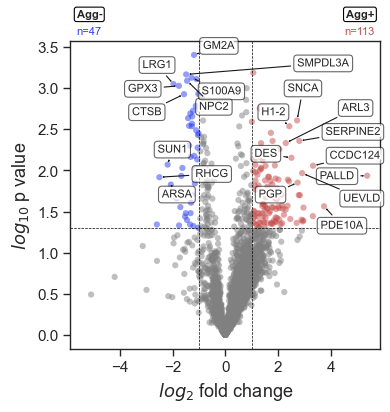

In [8]:
case_values = [{'type': 'Agg+'}, {'type': 'Agg-'}]

color_dict={'upregulated':"#C64D4A", 'downregulated': "#293DF5",'not_significant': "#FFFFFF6A"}

fig, ax = plt.subplots(figsize=(4, 4))
ax, volcano_df = scplt.plot_volcano(ax, pdata_nhp_norm,
                                    values=case_values,
                                    pval=0.05, return_df=True,
                                    fold_change_mode='mean', color=color_dict, label=[10,10])

ax.set_ylabel('$log_{10}$ p value',fontsize=13, labelpad=4)
ax.set_xlabel('$log_{2}$ fold change', fontsize=13, labelpad=4)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# plt.show()
plt.savefig("MANUSCRIPT_revision/REVISION_FigX-NHP_VOLCANO-directlfq.svg", bbox_inches="tight", pad_inches=0.1)
volcano_df.to_csv("MANUSCRIPT_revision/REVISION_FigX-NHP-DE-directlfq.csv")

In [15]:
pdata_nhp_norm.enrichment_functional(from_de=True, de_key="Agg+ vs Agg-")


🧭 [USER] Running STRING enrichment [DE-based: Agg+ vs Agg-]

🔹 Up-regulated proteins
     ℹ️ Found 0 cached STRING IDs. 150 need lookup.
     🌐 [API] UniProt mapped: 148 / 150
     🌐 [API] STRING mapped: 2 / 2 (missing after UniProt)
          ℹ️ Cached 150 STRING ID mappings.
   🔸 Proteins: 150 → STRING IDs: 150
   🔸 Species: 9606 | Background: None
     ✅ [OK] Enrichment complete (3.58s)
   • Access result: pdata.stats['functional']["Agg+ vs Agg-_up"]["result"]
   • Plot command : pdata.plot_enrichment_svg("Agg+ vs Agg-", direction="up")
   • View online  : https://string-db.org/cgi/network?identifiers=9606.ENSP00000264954%0d9606.ENSP00000223029%0d9606.ENSP00000364721%0d9606.ENSP00000378046%0d9606.ENSP00000216218%0d9606.ENSP00000370010%0d9606.ENSP00000273130%0d9606.ENSP00000251968%0d9606.ENSP00000380702%0d9606.ENSP00000359025%0d9606.ENSP00000446828%0d9606.ENSP00000468424%0d9606.ENSP00000364805%0d9606.ENSP00000351589%0d9606.ENSP00000354961%0d9606.ENSP00000363041%0d9606.ENSP00000376475

In [23]:
pdata_nhp_norm.stats['functional']["Agg+ vs Agg-_down"]["result"]

,category,term,number_of_genes,number_of_genes_in_background,ncbiTaxonId,inputGenes,preferredNames,p_value,fdr,description
0,COMPARTMENTS,GOCC:0005775,11,168,9606,"[9606.ENSP00000216124, 9606.ENSP00000225927, 9...","[ARSA, NAGLU, CTSC, GALC, GUSB, CTSB, GM2A, PL...",3.270000e-13,7.530000e-10,Vacuolar lumen
1,COMPARTMENTS,GOCC:0043202,9,90,9606,"[9606.ENSP00000216124, 9606.ENSP00000225927, 9...","[ARSA, NAGLU, GALC, GUSB, CTSB, GM2A, PLD3, NP...",1.610000e-12,1.850000e-09,Lysosomal lumen
2,COMPARTMENTS,GOCC:0005615,17,1027,9606,"[9606.ENSP00000216117, 9606.ENSP00000225927, 9...","[HMOX1, NAGLU, CDH1, LRG1, GUSB, CALML3, APOD,...",1.050000e-10,8.090000e-08,Extracellular space
3,COMPARTMENTS,GOCC:0043230,13,524,9606,"[9606.ENSP00000225927, 9606.ENSP00000227266, 9...","[NAGLU, CTSC, CDH1, LRG1, CALML3, APOD, CTSB, ...",2.330000e-10,1.340000e-07,Extracellular organelle
4,COMPARTMENTS,GOCC:0005576,22,2079,9606,"[9606.ENSP00000216117, 9606.ENSP00000225927, 9...","[HMOX1, NAGLU, CTSC, CDH1, SIAE, LRG1, GUSB, C...",3.720000e-10,1.710000e-07,Extracellular region
...,...,...,...,...,...,...,...,...,...,...
168,NetworkNeighborAL,CL:28357,7,113,9606,"[9606.ENSP00000216124, 9606.ENSP00000225927, 9...","[ARSA, NAGLU, GALC, GM2A, SGPL1, NAGA, HEXA]",1.320000e-08,1.780000e-05,"Sphingolipid metabolism, and Lysosomal storage..."
169,NetworkNeighborAL,CL:19234,5,43,9606,"[9606.ENSP00000296370, 9606.ENSP00000357709, 9...","[S100P, S100A6, S100A8, S100A9, S100A2]",9.730000e-08,8.910000e-05,"Mixed, incl. S100/CaBP-9k-type, calcium bindin..."
170,NetworkNeighborAL,CL:19236,4,30,9606,"[9606.ENSP00000357709, 9606.ENSP00000357721, 9...","[S100A6, S100A8, S100A9, S100A2]",1.240000e-06,9.500000e-04,"S100/CaBP-9k-type, calcium binding, subdomain,..."
171,NetworkNeighborAL,CL:19238,3,16,9606,"[9606.ENSP00000357721, 9606.ENSP00000357727, 9...","[S100A8, S100A9, S100A2]",1.190000e-05,7.800000e-03,S-100/ICaBP type calcium binding domain


🧭 [USER] Fetching STRING SVG for key 'Agg+ vs Agg-_up' (n=112)...


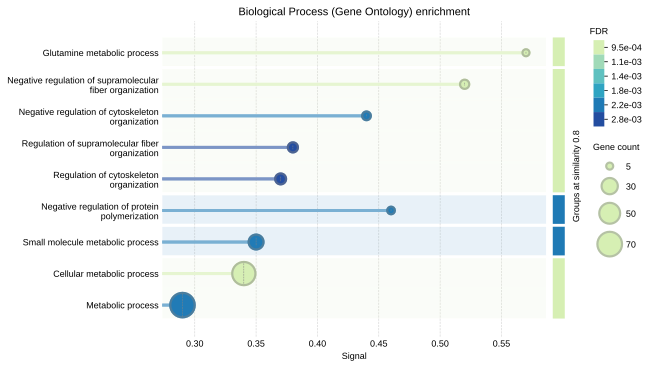

In [ ]:
pdata_nhp_norm.plot_enrichment_svg("Agg+ vs Agg-", direction="up")



🧭 [USER] Fetching STRING SVG for key 'Agg+ vs Agg-_down' (n=47)...


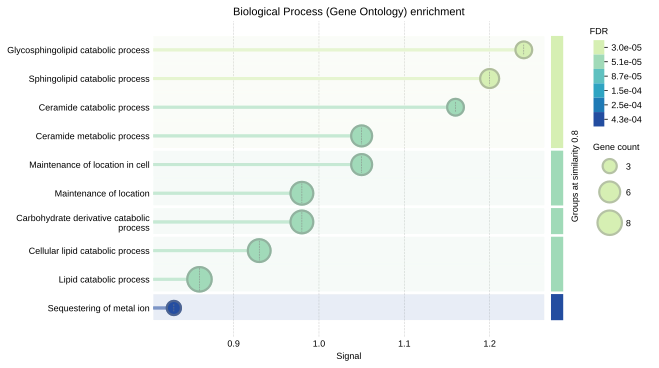

In [22]:
pdata_nhp_norm.plot_enrichment_svg("Agg+ vs Agg-", direction="down")

## CC

In [13]:
import re

# (plasma membrane separate; organelle membranes go with organelle)
selected_components = [
    "cytoplasm",
    "plasma membrane",
    "extracellular region",
    "mitochondrion",
    "nucleus",
    "endoplasmic reticulum",
    "golgi apparatus",
    "cytoskeleton",
]

label_map = {
    "cytoplasm": "Cytoplasm",
    "plasma membrane": "Plasma membrane",
    "extracellular region": "Extracellular region",
    "mitochondrion": "Mitochondria",
    "nucleus": "Nucleus",
    "endoplasmic reticulum": "ER",
    "golgi apparatus": "Golgi apparatus",
    "cytoskeleton": "Cytoskeleton",
    "others": "Others",
}

plot_order = selected_components + ["others"]

def _clean_cc_term(s: str) -> str:
    if pd.isna(s):
        return ""
    s = str(s).strip()
    s = re.sub(r"\[.*?\]", "", s).strip()
    return s

def map_cc_term(term: str) -> str:
    t = term.lower()

    # cytoskeleton (keep separate)
    if "cytoskeleton" in t:
        return "cytoskeleton"

    # nucleus
    if re.search(r"\bnucleus\b|nucleoplasm|nuclear", t):
        return "nucleus"

    # cytoplasm (cytosol/cytoplasmic included)
    if re.search(r"cytosol|cytoplasm|cytoplasmic", t):
        return "cytoplasm"

    # extracellular
    if "extracellular" in t:
        return "extracellular region"

    # ER (includes ER membrane etc.)
    if "endoplasmic reticulum" in t:
        return "endoplasmic reticulum"

    # Golgi
    if "golgi" in t:
        return "golgi apparatus"

    # mitochondrion (includes mitochondrial membrane etc.)
    if "mitochondri" in t:
        return "mitochondrion"

    # plasma membrane (keep separate from generic "membrane")
    if "plasma membrane" in t:
        return "plasma membrane"

    # everything else
    return "others"

def build_cc_df(df, cc_col="gene_ontology_cellular_component", protein_col=None, source_name=None):
    prot = df.index.to_series() if protein_col is None else df[protein_col]
    out = df[[cc_col]].copy()
    out["protein"] = prot.values
    out = out.rename(columns={cc_col: "cc_raw"})
    if source_name is not None:
        out["source"] = source_name

    out["cc_raw"] = out["cc_raw"].astype(str).str.split(";")
    out = out.explode("cc_raw", ignore_index=True)

    out["cc_clean"] = out["cc_raw"].map(_clean_cc_term)
    out = out[out["cc_clean"].ne("") & out["cc_clean"].ne("nan")].copy()

    out["cc_mapped"] = out["cc_clean"].map(map_cc_term)
    out["in_selected"] = out["cc_mapped"].isin(selected_components)
    return out

def counts_from_cc_df(cc_df):
    return cc_df["cc_mapped"].value_counts()

In [7]:
nhp_upset = scutils.get_upset_contents(pdata_nhp, classes = ['type'])
nhp_neg_all = scutils.get_upset_query(nhp_upset, present='Agg-', absent=[], fetch_uniprot=True)
nhp_pos_all = scutils.get_upset_query(nhp_upset, present='Agg+', absent=[], fetch_uniprot=True)

Classes: type, Values: Agg+
Filter query: ((adata.obs['type'] == 'Agg+'))
Classes: type, Values: Agg-
Filter query: ((adata.obs['type'] == 'Agg-'))


In [ ]:
nhp_pos_all.to_csv('nhp_cc_pos.csv')
nhp_neg_all.to_csv('nhp_cc_pos.csv')

In [36]:
nhp_neg_all

,accession,id,protein_names,gene_primary,gene_names,organism_id,gene_ontology_go,gene_ontology_molecular_function,gene_ontology_cellular_component,gene_ontology_biological_process,interacts_with,xref_string
0,O00139,KIF2A_HUMAN,Kinesin-like protein KIF2A (Kinesin-2) (hK2),KIF2A,KIF2A KIF2 KNS2,9606,centriolar subdistal appendage [GO:0120103]; c...,ATP binding [GO:0005524]; ATP hydrolysis activ...,centriolar subdistal appendage [GO:0120103]; c...,cell differentiation [GO:0030154]; cell divisi...,Q5SW79; Q8NE31; Q659C4; Q96EL3; P25791-3; Q8TA...,9606.ENSP00000385000
1,O14744,ANM5_HUMAN,Protein arginine N-methyltransferase 5 (PRMT5)...,PRMT5,PRMT5 HRMT1L5 IBP72 JBP1 SKB1,9606,chromatin [GO:0000785]; cytoplasm [GO:0005737]...,E-box binding [GO:0070888]; histone H3 methylt...,chromatin [GO:0000785]; cytoplasm [GO:0005737]...,chromatin remodeling [GO:0006338]; circadian r...,P01019; Q9NX04; Q8WUW1; Q08289; P78371; Q16543...,9606.ENSP00000319169
2,O15042,SR140_HUMAN,U2 snRNP-associated SURP motif-containing prot...,U2SURP,U2SURP KIAA0332 SR140,9606,nucleoplasm [GO:0005654]; nucleus [GO:0005634]...,RNA binding [GO:0003723],nucleoplasm [GO:0005654]; nucleus [GO:0005634]...,RNA processing [GO:0006396],Q8IWX8; P98175; Q96I25; P52756,9606.ENSP00000418563
3,O60716,CTND1_HUMAN,Catenin delta-1 (Cadherin-associated Src subst...,CTNND1,CTNND1 KIAA0384,9606,adherens junction [GO:0005912]; catenin comple...,cadherin binding [GO:0045296]; cell-cell adhes...,adherens junction [GO:0005912]; catenin comple...,cell migration involved in sprouting angiogene...,P12830; P19022; P00533; Q7Z6J6; P08581; O14495...,9606.ENSP00000382004
4,O75061,AUXI_HUMAN,Auxilin (EC 3.1.3.-) (DnaJ homolog subfamily C...,DNAJC6,DNAJC6 KIAA0473,9606,clathrin-coated vesicle [GO:0030136]; cytoplas...,clathrin binding [GO:0030276]; clathrin heavy ...,clathrin-coated vesicle [GO:0030136]; cytoplas...,clathrin coat disassembly [GO:0072318]; clathr...,NaN,9606.ENSP00000360108
...,...,...,...,...,...,...,...,...,...,...,...,...
2336,Q15847,ADIRF_HUMAN,Adipogenesis regulatory factor (Adipogenesis f...,ADIRF,ADIRF AFRO APM2 C10orf116,9606,extracellular exosome [GO:0070062]; nucleoplas...,NaN,extracellular exosome [GO:0070062]; nucleoplas...,cell differentiation [GO:0030154]; DNA-templat...,Q14116,9606.ENSP00000361083
2337,Q8IUR0,TPPC5_HUMAN,Trafficking protein particle complex subunit 5,TRAPPC5,TRAPPC5,9606,cytoplasm [GO:0005737]; cytosol [GO:0005829]; ...,NaN,cytoplasm [GO:0005737]; cytosol [GO:0005829]; ...,COPII vesicle coating [GO:0048208]; endoplasmi...,O95273; Q9NP66; P0DI81-3; O43617,9606.ENSP00000470262
2338,Q8TBQ9,KISHA_HUMAN,Protein kish-A (Transmembrane protein 167) (Tr...,TMEM167A,TMEM167A TMEM167,9606,Golgi apparatus [GO:0005794]; Golgi membrane [...,NaN,Golgi apparatus [GO:0005794]; Golgi membrane [...,constitutive secretory pathway [GO:0045054]; p...,Q9Y5U9,9606.ENSP00000424707
2339,Q13296,SG2A2_HUMAN,Mammaglobin-A (Mammaglobin-1) (Secretoglobin f...,SCGB2A2,SCGB2A2 MGB1 UGB2,9606,extracellular space [GO:0005615]; androgen rec...,NaN,extracellular space [GO:0005615],androgen receptor signaling pathway [GO:0030521],P50552,9606.ENSP00000227918


In [10]:
df_human_proteome = pd.read_csv("MANUSCRIPT_revision/uniprotkb_taxonomy_id_9606_AND_reviewed_2026_08_19.tsv", delimiter='\t')
df_human_proteome

,Entry,Reviewed,Entry Name,Protein names,Gene Names,Gene Ontology (cellular component)
0,A0A087X1C5,reviewed,CP2D7_HUMAN,Cytochrome P450 2D7 (EC 1.14.14.1),CYP2D7,cytoplasm [GO:0005737]; membrane [GO:0016020];...
1,A0A096LP01,reviewed,SIM26_HUMAN,Small integral membrane protein 26,SMIM26 LINC00493,mitochondrial outer membrane [GO:0005741]; mit...
2,A0A0B4J2F0,reviewed,PIOS1_HUMAN,Protein PIGBOS1 (PIGB opposite strand protein 1),PIGBOS1,mitochondrial outer membrane [GO:0005741]; mit...
3,A0A0C5B5G6,reviewed,MOTSC_HUMAN,Mitochondrial-derived peptide MOTS-c (Mitochon...,MT-RNR1,extracellular space [GO:0005615]; mitochondrio...
4,A0A0K2S4Q6,reviewed,CD3CH_HUMAN,Protein CD300H (CD300 antigen-like family memb...,CD300H,extracellular region [GO:0005576]; plasma memb...
...,...,...,...,...,...,...
20427,Q9UI25,reviewed,YP002_HUMAN,Putative uncharacterized protein PRO0461,PRO0461,NaN
20428,Q9UI54,reviewed,YT001_HUMAN,Putative uncharacterized protein PRO0628,PRO0628,NaN
20429,Q9UI72,reviewed,YE014_HUMAN,Putative uncharacterized protein PRO0255,PRO0255,NaN
20430,Q9Y3F1,reviewed,TA6P_HUMAN,Putative TAP2-associated 6.5 kDa polypeptide,NaN,NaN


In [22]:
df_nhp_proteome = pd.read_csv("MANUSCRIPT_revision/uniprotkb_taxonomy_id_9541_2026_08_19.tsv", delimiter='\t')
df_nhp_proteome

,Entry,Reviewed,Entry Name,Protein names,Gene Names,Gene Ontology (cellular component)
0,A0A2K5TJ09,unreviewed,A0A2K5TJ09_MACFA,Histone acetyltransferase (EC 2.3.1.48),NaN,"chromosome, centromeric region [GO:0000775]; c..."
1,A0A2K5TJ58,unreviewed,A0A2K5TJ58_MACFA,Slit homolog 2 protein,NaN,cytoplasm [GO:0005737]; extracellular space [G...
2,A0A2K5TJ71,unreviewed,A0A2K5TJ71_MACFA,Histone deacetylase 2 (HD2) (EC 3.5.1.98),NaN,"chromosome, telomeric region [GO:0000781]; cyt..."
3,A0A2K5TJB2,unreviewed,A0A2K5TJB2_MACFA,Transforming growth factor beta,NaN,cell surface [GO:0009986]; cytoplasm [GO:00057...
4,A0A2K5TJC6,unreviewed,A0A2K5TJC6_MACFA,DNA repair protein RAD51 homolog 4 (EC 2.3.2.2...,NaN,"chromosome, telomeric region [GO:0000781]; cyt..."
...,...,...,...,...,...,...
62221,S4UCH9,unreviewed,S4UCH9_MACFA,Complement factor H-like protein,CFH-L,extracellular space [GO:0005615]
62222,S4UEI8,unreviewed,S4UEI8_MACFA,Complement factor H-like protein,CFH-L,extracellular space [GO:0005615]
62223,S4UGQ3,unreviewed,S4UGQ3_MACFA,Complement factor H-like protein,CFH-L,extracellular space [GO:0005615]
62224,U3N172,unreviewed,U3N172_MACFA,ATP synthase complex subunit 8,ATP8,mitochondrial membrane [GO:0031966]; proton-tr...


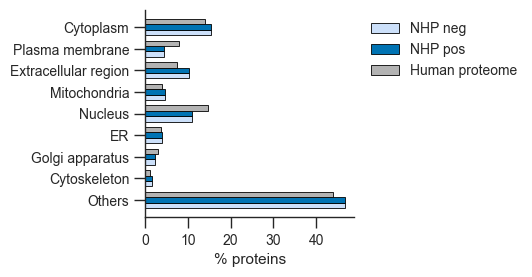

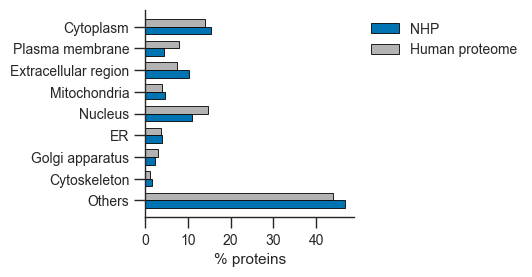

In [38]:
# check df
neg_cc_df  = build_cc_df(nhp_neg_all,  protein_col=None, source_name="neg")
pos_cc_df = build_cc_df(nhp_pos_all, protein_col=None, source_name="pos")
human_cc_df  = build_cc_df(df_human_proteome, protein_col="Entry Name",
                           cc_col="Gene Ontology (cellular component)", source_name="human")

# counts 
neg_counts  = counts_from_cc_df(neg_cc_df).reindex(plot_order, fill_value=0)
pos_counts = counts_from_cc_df(pos_cc_df).reindex(plot_order, fill_value=0)
human_counts  = counts_from_cc_df(human_cc_df).reindex(plot_order, fill_value=0)


# convert to %
neg_pct  = neg_counts  / neg_counts.sum()  * 100
pos_pct = pos_counts / pos_counts.sum() * 100
human_pct  = human_counts  / human_counts.sum()  * 100

# order top→bottom like your plot
labels = plot_order[::-1]
display_labels = [label_map[l] for l in labels]
neg_pct  = neg_pct.reindex(labels)
pos_pct = pos_pct.reindex(labels)
human_pct  = human_pct.reindex(labels)

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})


# bar chart
fig, ax = plt.subplots(figsize=(2.7, 2.7))

y = np.arange(len(labels))
h = 0.25  # height of each bar

ax.barh(y - h, neg_pct.values,   height=h, label="NHP neg",
        color=(0.80, 0.88, 0.98), edgecolor="black", linewidth=0.6)
ax.barh(y,     pos_pct.values,   height=h, label="NHP pos",
        color=(0.00, 0.45, 0.70), edgecolor="black", linewidth=0.6)
ax.barh(y + h, human_pct.values, height=h, label="Human proteome",
        color=(0.70, 0.70, 0.70), edgecolor="black", linewidth=0.6)

ax.set_yticks(y)
ax.set_yticklabels(display_labels)
ax.set_xlabel("% proteins")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", width=1.0, length=8)

ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.show()
# plt.savefig("MANUSCRIPT/MANUSCRIPT_FigS1-FF_CC.svg", bbox_inches="tight")

# bar chart
fig, ax = plt.subplots(figsize=(2.7, 2.7))

y = np.arange(len(labels))
h = 0.35

ax.barh(y - h/2, pos_pct.values,   height=h, label="NHP",
        color=(0.00, 0.45, 0.70), edgecolor="black", linewidth=0.6)
ax.barh(y + h/2, human_pct.values, height=h, label="Human proteome",
        color=(0.70, 0.70, 0.70), edgecolor="black", linewidth=0.6)

ax.set_yticks(y)
ax.set_yticklabels(display_labels)
ax.set_xlabel("% proteins")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", width=1.0, length=8)

ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.show()
# plt.savefig("MANUSCRIPT/MANUSCRIPT_FigS1-FF_CC.svg", bbox_inches="tight")
